# Model Definition and Evaluation
## Table of Contents
1. [Model Selection](#model-selection)
2. [Feature Engineering](#feature-engineering)
3. [Hyperparameter Tuning](#hyperparameter-tuning)
4. [Implementation](#implementation)
5. [Evaluation Metrics](#evaluation-metrics)
6. [Comparative Analysis](#comparative-analysis)


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report
# Import models you're considering


## Model Selection
Our oceanographic profiles have two dimensions (depth x size bin), where Biovolume values in neighboring depths and size bins are correlated. This suggests that the 2D pattern of Biovolume is of importance.
By visualizing these 2D patterns as heatmaps, we aim to classify Profiles using convolutional neural networks (CNN). 
- We start by testing a simple CNN and low-resolution heatmaps (with only 45 x 45 pixels)
- We aim to progress towards createing higher-resolution heatmaps with interpolation between data points which we aim to use for transfer learning.

## Feature Engineering

Beyond the baseline preprocessing, our feature engineering focused on preparing the UVP particle-biovolume profiles for convolution-based classification. First, all biovolume values were normalized on a per-profile basis to reduce the influence of varying absolute particle concentrations and highlight relative vertical distribution patterns. Each profile was then reshaped into a structured 40×17 depth–size matrix, effectively forming a 2D heatmap representation. This transformation converts the raw measurements into spatially coherent feature maps suitable for convolutional neural networks. We deliberately refrained from introducing aggregated or hand-crafted features, as CNNs are expected to extract relevant spatial and multiscale patterns directly from the heatmaps.

- adding labels
- adding squared transformation

### Defining Functions

In [1]:
# TODO  :   Function Declaration Cell

import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.ndimage import gaussian_filter
from matplotlib.colors import PowerNorm, LogNorm

heatmap_data = []

## --------------------------------------------------------- ##

def pad_heatmap(
    arr: np.ndarray,
    pad_top: int = 4,
    pad_bottom: int = 4,
    pad_left: int = 1,
    pad_right: int = 1,
    value: float = 0.0,
) -> np.ndarray:
    """
    Pad ein 2D-Array (Heatmap) mit Konstanten (default: 0).

    arr:       2D-Array (H, W)
    pad_top:   zusätzliche Zeilen oben
    pad_bottom:zusätzliche Zeilen unten
    pad_left:  zusätzliche Spalten links
    pad_right: zusätzliche Spalten rechts
    value:     Füllwert (Standard: 0.0)
    """
    return np.pad(
        arr,
        pad_width=((pad_top, pad_bottom), (pad_left, pad_right)),
        mode="constant",
        constant_values=value,
    )

## --------------------------------------------------------- ##

def crop_figure(fig, trim_px=0):
    """
    Converts a Matplotlib Figure into an RGB NumPy array and crops pixels
    at all edges. Compatible with Matplotlib 3.8+.
    """
    fig.canvas.draw()
    # Try new API first (Matplotlib 3.8+)
    try:
        buf = fig.canvas.buffer_rgba()
        img = np.asarray(buf)
        # buffer_rgba() liefert ARGB → zu RGB konvertieren
        img = img[..., :3]  
    except AttributeError:
        # Fallback: ältere Matplotlib-Versionen
        w, h = fig.canvas.get_width_height()
        buf = fig.canvas.tostring_rgb()
        img = np.frombuffer(buf, dtype=np.uint8).reshape((h, w, 3))

    if trim_px != 0:
        # Pixel abschneiden
        return img[trim_px:-trim_px, trim_px:-trim_px, :]
    else:
        return img

## --------------------------------------------------------- ##

# save_all_profiles(df, size_cols[:-3], pixels=45, trim_px=0, max_profiles=15, padding=[2,2,1,3], mp="inferno", intrpl="bilinear", gamma=1, sig=0.1)
def create_profile_heatmap(df, profile_id, size_cols, out_dir, pixels=144, trim_px=0, padding=[0,0,0,0], mp=None, intrpl=None, gam=1, sig=0.1):
    """
    Save a square heatmap for a single profile as a PNG file.
    Only the heatmap is saved — no axes, labels, or surrounding whitespace.
    Now includes pixel-exact border cropping.
    """

    # 1. Profil auswählen
    prof = df[df["Profile_id"] == profile_id].copy()
    if prof.empty:
        return

    # 2. Nach Tiefe sortieren
    prof = prof.sort_values("depth_bin")

    # 3. Heatmap-Matrix generieren (z.B. 40×14 → gepaddet)
    heatmap_data = pad_heatmap(prof[size_cols].to_numpy(), pad_top=padding[0], pad_bottom=padding[1], pad_left=padding[2], pad_right=padding[3])

    # 4. Eine quadratische Figure erzeugen
    fig = plt.figure(figsize=(1, 1), dpi=pixels)
    ax = fig.add_axes([0, 0, 1, 1])   # axes füllt alles

    # 5. Heatmap plotten
    heatmap_smooth = gaussian_filter(heatmap_data, sigma=sig)

    if intrpl == None:
        intrpl = "nearest"
    else:
        intrpl=intrpl

    ax.imshow(
        heatmap_smooth,
        cmap=mp,                          # 'gray' 'inferno' 'turbo' 'magma'
        origin="upper",
        aspect="auto",
        interpolation=intrpl,               # 'nearest' 'bilinear' 'bicubic' 'lanczos' 'spline16' 'spline36'
        # vmin=np.percentile(heatmap_data, 2),
        # vmax=np.percentile(heatmap_data, 99),
        # norm=LogNorm(),
        norm=PowerNorm(gamma=gam),
    )
    
    # alles ausblenden
    ax.axis("off")

    # 6. In Array rendern → Pixel exakt abschneiden
    cropped = crop_figure(fig, trim_px=trim_px)

    plt.close(fig)  # Original-Figure schließen

    # 7. Ordner anlegen
    os.makedirs(out_dir, exist_ok=True)

    # 8. Output-Dateinamen
    safe_id = str(profile_id)
    for ch in ['/', '\\', ':', ';', ' ']:
        safe_id = safe_id.replace(ch, '_')

    filepath = os.path.join(out_dir, f"{safe_id}.png")

    # 9. Als PNG speichern
    import imageio
    imageio.imwrite(filepath, cropped)


## --------------------------------------------------------- ##

# save_all_profiles(df, size_cols[:-3], pixels=45, trim_px=0, max_profiles=15, padding=[2,2,1,3], mp="inferno", intrpl="bilinear", gamma=1, sig=0.1)
def save_all_profiles(df, size_cols, out_dir="../Data/heatmaps", pixels=144, trim_px=0, max_profiles=None, padding=None, mp=None, intrpl=None, gamma=1, sig=0.1):
    """
    Ruft create_profile_heatmap() für viele Profile auf.
    - max_profiles = None  → alle Profile
    - max_profiles = 10    → nur die ersten 10 Profile
    """
    os.makedirs(out_dir, exist_ok=True)

    profile_ids = df["Profile_id"].unique()

    # Wenn max_profiles gesetzt ist, nur die ersten N
    if max_profiles is not None:
        profile_ids = profile_ids[:max_profiles]

    for pid in profile_ids:
        create_profile_heatmap(df, pid, size_cols, out_dir, pixels=pixels, trim_px=trim_px, padding=padding, mp=mp, intrpl=intrpl, gam=gamma, sig=sig)

## --------------------------------------------------------- ##

def normalize_by_profile_global_max(df, group_col, columns):
    """
    Normalisiert die angegebenen Spalten so, dass:
    - pro Gruppe (group_col, z.B. 'Profile-ID') genau EIN globales Maximum
      über alle angegebenen Spalten und alle Zeilen gesucht wird
    - alle Werte der Gruppe durch dieses globale Maximum geteilt werden
    - 0 bleibt 0
    """

    # 1. Relevante Spalten extrahieren
    sub = df[columns]

    # 2. Pro Gruppe (Profile) das Spaltenmaximum bestimmen
    #    → ergibt für jede Zeile einer Gruppe dieselben Spaltenmaxima
    group_col_max = df.groupby(group_col)[columns].transform("max")

    # 3. Aus diesen Spaltenmaxima das globale Maximum pro Gruppe ableiten
    #    → für jede Zeile einer Gruppe derselbe Skalar
    profile_max = group_col_max.max(axis=1)

    # 4. Division durch 0 vermeiden (Profil komplett 0)
    denom = profile_max.replace(0, 1)

    # 5. Alles durch diesen Skalar teilen
    normalized = sub.div(denom, axis=0)

    # 6. Zurück ins Original-DataFrame schreiben
    df_norm = df.copy()
    df_norm[columns] = normalized

    return df_norm

### Loading Dataset for Plotting Heatmpas

This plot shows all 40 depth bins over 14 instead of 17 size classes of bio volume,
hence the baselinemodel evaluated those classes 15-17 as insignificant.
Each square represents a real datapoint.

*****

WE WILL HAVE TO DISTORED THIS PLOT INTO A SQUARE IMAGE WITHOUT LOSING DATA OR ROUNDING ERRORS.
A 3:1 RATIO BETWEEN 'DEPTH BINS' AND 'SIZE CLASSES SHOULD DELIVER SUFFICIENT SQUARITY,
WHILE 'ZERO'-PADDING ROWS AND COLUMNS TO REACH A PIXELPERFECT RESULT.


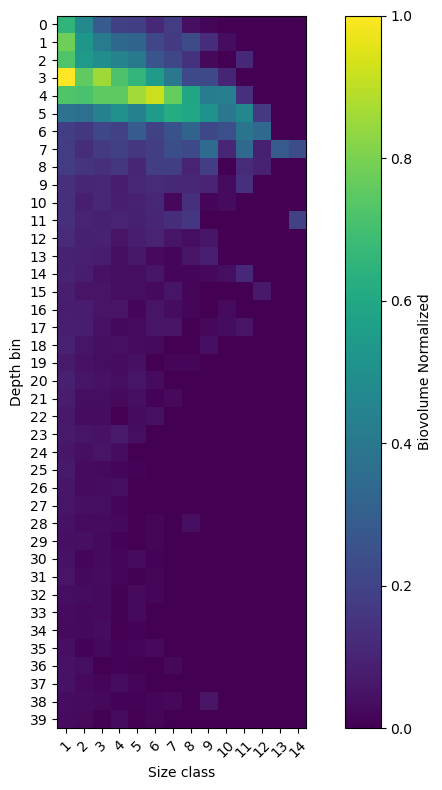

This is a sample of a padded Bioprofile, the way it gets put into the plot function.
⬇︎ This particular padding is static and only an example. ⬇︎


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
3,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
4,0.0,0.653745,0.470178,0.287066,0.188709,0.185985,0.113002,0.179574,0.041313,0.017411,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
5,0.0,0.780362,0.530190,0.415375,0.334251,0.323694,0.213776,0.168894,0.228241,0.126525,0.034254,0.000000,0.000000,0.000000,0.000000,0.0
6,0.0,0.725989,0.536002,0.490964,0.447350,0.403615,0.263119,0.212265,0.147485,0.022054,0.000000,0.112848,0.000000,0.000000,0.000000,0.0
7,0.0,1.000000,0.755412,0.859124,0.719881,0.659883,0.553178,0.400242,0.219777,0.220892,0.103590,0.000000,0.000000,0.000000,0.000000,0.0
8,0.0,0.724283,0.711253,0.750594,0.750754,0.860820,0.921165,0.763016,0.591890,0.425577,0.428972,0.139844,0.000000,0.000000,0.000000,0.0
9,0.0,0.379674,0.364668,0.437849,0.500825,0.439851,0.548332,0.618897,0.596689,0.508930,0.395237,0.467939,0.164274,0.000000,0.000000,0.0


In [5]:
# TODO  :   Load the dataset
# Replace 'your_dataset.csv' with the path to your actual dataset
import pandas as pd

df = pd.read_pickle('../Data/Biovolume_per_size_class_and_depth_updated.pkl')

# Perform any feature engineering steps
# Example: df['new_feature'] = df['feature1'] + df['feature2']

import matplotlib.pyplot as plt
import numpy as np

# 1. Biovolume-Spalten auswählen
size_cols = [col for col in df.columns if col.startswith("Biovolume ")]
# Remove three of the largest size bins
size_cols = size_cols[:-3]

# Normalisierung – kann man machen wird grafisch aber schon automatisch vom plot erledigt
df = normalize_by_profile_global_max(df, "Profile_id", size_cols)
# display(df.head(40))

# 2. Ein Profil auswählen
pid = "0000a_WMO5906623_recovery_profiles"   # hier deine echte Profile_id einsetzen
df_prof = df[df["Profile_id"] == pid].copy()

# 3. Nach Tiefe sortieren (wichtig für "saubere" y-Achse)
df_prof = df_prof.sort_values("depth_bin")

# 4. 2D-Array für die Heatmap bauen: (n_depth_bins x n_size_classes)
heatmap_data = df_prof[size_cols].to_numpy()  # Shape ~ (40, 17)

# 5. Plotten
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(
    heatmap_data,
    aspect="equal",      # oder "equal" wenn du willst
    origin="upper"      # Tiefen von unten nach oben
)

# Achsen-Beschriftungen
ax.set_xlabel("Size class")
ax.set_ylabel("Depth bin")

# Optional: Ticks mit Spaltennamen
ax.set_xticks(np.arange(len(size_cols)))
ax.set_xticklabels(range(1, len(size_cols)+1), rotation=45)

ax.set_yticks(np.arange(len(df_prof["depth_bin"].unique())))
ax.set_yticklabels(sorted(df_prof["depth_bin"].unique()))

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Biovolume Normalized")

plt.tight_layout()

print(f"="*100)
print("This plot shows all 40 depth bins over 14 instead of 17 size classes of bio volume,\nhence the baselinemodel evaluated those classes 15-17 as insignificant.\nEach square represents a real datapoint.")
print("\n"+f"*"*5+"\n")
print("WE WILL HAVE TO DISTORED THIS PLOT INTO A SQUARE IMAGE WITHOUT LOSING DATA OR ROUNDING ERRORS.")
print("A 3:1 RATIO BETWEEN 'DEPTH BINS' AND 'SIZE CLASSES SHOULD DELIVER SUFFICIENT SQUARITY,\nWHILE 'ZERO'-PADDING ROWS AND COLUMNS TO REACH A PIXELPERFECT RESULT.")
print(f"="*100)

plt.show()

print(f"="*100)
print("This is a sample of a padded Bioprofile, the way it gets put into the plot function.\n⬇︎ This particular padding is static and only an example. ⬇︎")
print(f"="*100)
pd.DataFrame(pad_heatmap(heatmap_data))

### Creating Heatmap Plots and Saving them to Files 

In [ ]:
# TODO  :   Converting our input features into heatmaps and export them as an image dataset.

# Normalizing the size columns.
size_cols = [col for col in df.columns if col.startswith("Biovolume ")]
df = normalize_by_profile_global_max(df, "Profile_id", size_cols)

"""
This first part is for redundancy only.
It has been done in a differnet cell before but doesn't always travel.
So we keep it here for 'ease of use'.
"""

## --------------------------------------------------------- ##

# Creating and storing the feature-heatmaps in a directory of your choice (default: '/Data/heatmaps').
# save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples", pixels=240, trim_px=2, max_profiles=15, sig=0.1)

save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_00", pixels=45, trim_px=0, max_profiles=3, padding=[2,3,1,0])
save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_01", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1])
save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_02", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], intrpl="bilinear")
save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_03", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], intrpl="bicubic")

save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_10", pixels=45, trim_px=0, max_profiles=3, padding=[2,3,1,0], mp="gray")
save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_11", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="gray")
save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_12", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="gray", intrpl="bilinear")
save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_13", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="gray", intrpl="bicubic")

save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_20", pixels=45, trim_px=0, max_profiles=3, padding=[2,3,1,0], mp="inferno")
save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_21", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="inferno")
save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_22", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="inferno", intrpl="bilinear")
save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_23", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="inferno", intrpl="bicubic")

save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_30", pixels=45, trim_px=0, max_profiles=3, padding=[2,3,1,0], mp="turbo")
save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_31", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="turbo")
save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_32", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="turbo", intrpl="bilinear")
save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_33", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="turbo", intrpl="bicubic")

"""
Here you are able to create the heatmap image output.
    pixels = [48, 144, 240] – are good choices and multiples of 16 (Columns/ Features)
            → 0·1·1·1·1·1·1·1·1·1·1·1·1·1·1·0 (one column padding on either side)

    - df: your dataframe
    - size_cols: how many biovolume size columns should be accounted for
    - out_dir: pick your output dir, this is more for putting out sample data so you don't overwrite your main dataset.
    - pixels: image square size
    - trim_px: cropping image by removing pixels along each side of the square → here you choose how many (by default there is always one line of pixels removed)
    - max_profiles: also more for test purposes
    - sig: sigma parameter of the gaussian filter of the cubic interpolation function

The full ⬇︎ image set creator uses a 240px square with 1px trim resulting in a 238px square heatmap.
The output you find in your '/Data/heatmaps/' directory. 
"""

# TODO : Uncomment for final outpput!! ⬇︎

#save_all_profiles(df, size_cols[:-3])                             # save all profile heatmaps
#save_all_profiles(df, size_cols[:-3], pixels=48, trim_px=1, max_profiles=None, padding=[4,4,1,1], mp="turbo", intrpl="bicubic")
#save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_03", pixels=48, trim_px=1, max_profiles=15, padding=[4,4,1,1], mp="inferno", intrpl="bilinear", gamma=1, sig=0.1)

# final version of heatmaps:
save_all_profiles(df, size_cols[:-3], out_dir="../Data/heatmaps", pixels=48, trim_px=1, max_profiles=None, padding=[4,4,1,1], intrpl="bilinear", gamma=0.8)


## First CNN: small heatmaps
-  workflow with small heatmaps & geographical & clster-stratified split

In [ ]:
# install if necessary:
#pip install imbalanced-learn pillow

In [2]:
## install if necessary:
#pip install imbalanced-learn pillow

import numpy as np
import pandas as pd
import pickle
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GaussianNoise
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from PIL import Image
import warnings
warnings.filterwarnings('ignore')


# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Path attributes

DATA_DIR = Path("../Data")
HEATMAP_DIR = DATA_DIR / "heatmaps"

### Functions for: data & heatmap loading, train/test splitting, balancing training data & scaling heatmap pixels

In [3]:

######################## initialize a class with attributes = data directories and files ###############################
# add every new function to this class

class HeatmapCNNClassifier:
    def __init__(self, data_dir=DATA_DIR, heatmap_dir=HEATMAP_DIR):
            self.data_dir = Path(data_dir)
            self.heatmap_dir = Path(heatmap_dir)
            self.train_test_file = self.data_dir / "Profile_id_to_train_test_cross_val_v2.pkl"
            self.clusters_file = self.data_dir / "Profile_id_to_clusters_4_and_6.pkl"
            self.scaler = StandardScaler()
            self.label_encoder = LabelEncoder()
        
######################## Load data assignments ###############################

def load_data_assignments(self):
    """Load data assignments from pickle files"""
    print("Loading data assignments...")
    
    # Load train/test and cross-validation assignments (DataFrame)
    with open(self.train_test_file, 'rb') as f:
        train_test_df = pickle.load(f)
    
    # Load cluster assignments (DataFrame)
    with open(self.clusters_file, 'rb') as f:
        clusters_df = pickle.load(f)
        clusters_df['cluster'] = clusters_df['cluster_4']       ######## change the number of clusters here as needed
    
    print(f"Train/test DataFrame shape: {train_test_df.shape}")
    print(f"Clusters DataFrame shape: {clusters_df.shape}")
    print(f"Train/test columns: {train_test_df.columns.tolist()}")
    print(f"Clusters columns:  {clusters_df.columns.tolist()}")
    
    # Convert DataFrames to dictionaries for easier lookup
    # Assuming Profile_id is the key column
    self.train_test_cv = {}
    for _, row in train_test_df.iterrows():
        profile_id = row['Profile_id']
        # Create dictionary with remaining columns
        self.train_test_cv[profile_id] = {col: row[col] for col in train_test_df.columns if col != 'Profile_id'}
    
    self.clusters = {}
    for _, row in clusters_df.iterrows():
        profile_id = row['Profile_id']
        # Assuming there's a cluster column - let's find it
        cluster_cols = [col for col in clusters_df.columns if col != 'Profile_id']
        if len(cluster_cols) == 1:
            self.clusters[profile_id] = row[cluster_cols[0]]
        else:
            # If multiple columns, store as dictionary
            self.clusters[profile_id] = {col: row[col] for col in cluster_cols}
    
    print(f"Loaded assignments for {len(self.train_test_cv)} profiles")
    print(f"Loaded cluster assignments for {len(self.clusters)} profiles")
    
    # Show sample data structure
    sample_profile = list(self.train_test_cv.keys())[0]
    print(f"Sample train/test data for profile {sample_profile}:  {self.train_test_cv[sample_profile]}")
    print(f"Sample cluster data for profile {sample_profile}:  {self.clusters[sample_profile]}")

# add the function to the class
HeatmapCNNClassifier.load_data_assignments = load_data_assignments

######################## Load heatmaps ###############################

def load_heatmaps(self):
    """Load heatmap images and create feature matrices"""
    print("Loading heatmap images...")
    
    # Get list of available heatmap files
    heatmap_files = list(self.heatmap_dir.glob("*.png"))
    print(f"Found {len(heatmap_files)} PNG files in {self.heatmap_dir}")
    
    if len(heatmap_files) == 0:
        raise FileNotFoundError(f"No PNG files found in {self.heatmap_dir}")
    
    # Extract profile IDs from filenames (remove .png extension)
    available_profile_ids = [f.stem for f in heatmap_files]
    
    # Debug: Show sample filenames and extracted profile IDs
    sample_files = heatmap_files[:5]
    sample_ids = [f.stem for f in sample_files]
    print(f"Sample filenames: {[f.name for f in sample_files]}")
    print(f"Sample extracted profile IDs: {sample_ids}")
    
    # Convert profile IDs to consistent format (strings)
    train_test_ids = set(str(k) for k in self.train_test_cv.keys())
    cluster_ids = set(str(k) for k in self.clusters.keys())
    filename_ids = set(str(id_) for id_ in available_profile_ids)
    
    print(f"Available profile IDs from filenames: {len(filename_ids)}")
    print(f"Profile IDs with train/test data: {len(train_test_ids)}")
    print(f"Profile IDs with cluster data:  {len(cluster_ids)}")
    
    # Find common profile IDs across all data sources
    common_with_train_test = filename_ids & train_test_ids
    common_with_clusters = filename_ids & cluster_ids
    common_all = filename_ids & train_test_ids & cluster_ids
    
    print(f"Files matching train/test IDs: {len(common_with_train_test)}")
    print(f"Files matching cluster IDs: {len(common_with_clusters)}")
    print(f"Files matching all data sources: {len(common_all)}")
    
    if len(common_all) == 0:
        print("\nDEBUGGING: No matching profile IDs found!")
        print("Sample IDs from each source:")
        print(f"Filenames: {list(filename_ids)[:5]}")
        print(f"Train/test:  {list(train_test_ids)[:5]}")
        print(f"Clusters: {list(cluster_ids)[:5]}")
        raise ValueError("No matching profile IDs found between files and metadata")
    
    common_ids = list(common_all)
    print(f"Found {len(common_ids)} profiles with complete data")
    
    # Load images and extract data
    X_data = []
    y_data = []
    profile_ids = []
    data_types = []
    cv_folds = []
    
    # Load a sample image to get dimensions
    sample_profile_id = common_ids[0]
    sample_img_path = self.heatmap_dir / f"{sample_profile_id}.png"
    sample_img = Image.open(sample_img_path)
    sample_array = np.array(sample_img)
    img_shape = sample_array.shape
    print(f"Image dimensions: {img_shape}")
    
    for profile_id_str in common_ids:
        # Convert string back to original type for dictionary lookup
        # Try both string and original type
        lookup_id = profile_id_str
        for original_id in self.train_test_cv.keys():
            if str(original_id) == profile_id_str:
                lookup_id = original_id
                break
        
        # Load image
        img_path = self.heatmap_dir / f"{profile_id_str}.png"
        img = Image.open(img_path)
        img_array = np.array(img)
        
        # Normalize pixel values to [0, 1]
        if img_array.dtype == np.uint8:
            img_array = img_array.astype(np.float32) / 255.0
        
        X_data.append(img_array)
        
        # Extract cluster assignment
        cluster_data = self.clusters[lookup_id]
        if isinstance(cluster_data, dict):
            # If cluster data is a dictionary, assume first value is the cluster
            y_data.append(list(cluster_data.values())[0])
        else:
            y_data.append(cluster_data)
        
        profile_ids.append(profile_id_str)
        data_types.append(self.train_test_cv[lookup_id]['data_type'])
        cv_folds.append(self.train_test_cv[lookup_id]['CV_fold'])
    
    self.X_data = np.array(X_data)
    self.y_data = np.array(y_data)
    self.profile_ids = np.array(profile_ids)
    self.data_types = np.array(data_types)
    self.cv_folds = np.array(cv_folds)
    
    print(f"Loaded {len(self.X_data)} heatmaps with shape {self.X_data.shape}")
    print(f"Unique clusters found: {np.unique(self.y_data)}")
    print(f"Data types found: {np.unique(self.data_types)}")
    print(f"CV folds found: {np.unique(self.cv_folds)}")

# add the function to the class
HeatmapCNNClassifier.load_heatmaps = load_heatmaps


######################## Train/test split ###############################

def split_train_test(self):
    """Split data into train and test sets based on pre-defined assignments"""
    print("Splitting data into train and test sets...")
    
    train_mask = self.data_types == 'train'
    test_mask = self.data_types == 'test'
    
    self.X_train = self.X_data[train_mask]
    self.y_train = self.y_data[train_mask]
    self.train_profile_ids = self.profile_ids[train_mask]
    self.train_cv_folds = self.cv_folds[train_mask]
    
    self.X_test = self.X_data[test_mask]
    self.y_test = self.y_data[test_mask]
    self.test_profile_ids = self.profile_ids[test_mask]
    
    print(f"Training set:  {len(self.X_train)} samples")
    print(f"Test set: {len(self.X_test)} samples")
    
    # Encode labels
    self.y_train_encoded = self.label_encoder.fit_transform(self.y_train)
    self.y_test_encoded = self.label_encoder.transform(self.y_test)
    self.n_classes = len(self.label_encoder.classes_)
    
    print(f"Number of classes: {self.n_classes}")
    print(f"Classes: {self.label_encoder.classes_}")

# add the function to the class
HeatmapCNNClassifier.split_train_test = split_train_test


######################## Balance classes per fold - SMOTE Tomek link ###############################

def balance_classes_per_fold_SMOTETomek(self):
    """Apply balancing within each CV fold separately"""
    print("Balancing classes per fold using SMOTETomek (SMOTE + Tomek links)...")
    
    unique_folds = np.unique(self.train_cv_folds)
    print(f"Processing {len(unique_folds)} folds:  {unique_folds}")
    
    # Store balanced data for each fold
    self.fold_balanced_data = {}
    
    for fold in unique_folds:
        print(f"\nBalancing fold:  {fold}")
        
        # Get training data for this fold (all other folds)
        val_mask = self.train_cv_folds == fold
        train_mask = ~val_mask
        
        X_train_fold = self.X_train[train_mask]
        y_train_fold = self.y_train_encoded[train_mask]
        
        print(f"Original fold {fold} training size: {len(X_train_fold)}")
        
        # Check if balancing is needed for this fold
        fold_counts = Counter(y_train_fold)
        min_count = min(fold_counts.values())
        max_count = max(fold_counts.values())
        
        if max_count / min_count > 1.5:  # Apply balancing if imbalanced
            # Reshape data for resampling (flatten images)
            X_train_fold_flat = X_train_fold.reshape(len(X_train_fold), -1)
            
            # Apply SMOTETomek
            smote_tomek = SMOTETomek(
                smote=SMOTE(random_state=42, k_neighbors=min(3, min_count-1)),
                tomek=TomekLinks(),
                random_state=42
            )
            
            X_train_balanced, y_train_balanced = smote_tomek.fit_resample(X_train_fold_flat, y_train_fold)
            
            # Reshape back to image format
            X_train_balanced = X_train_balanced.reshape((-1,) + X_train_fold.shape[1:])
            
            print(f"Balanced fold {fold} training size: {len(X_train_balanced)}")
            
            # Show distribution after balancing
            balanced_counts = Counter(y_train_balanced)
            for cluster_idx, count in sorted(balanced_counts.items()):
                cluster_name = self.label_encoder.classes_[cluster_idx]
                print(f"  Cluster {cluster_name}: {count} samples")
                
        else:
            print(f"Fold {fold} is already balanced, no resampling needed")
            X_train_balanced = X_train_fold
            y_train_balanced = y_train_fold
        
        # Store balanced data for this fold
        self.fold_balanced_data[fold] = {
            'X_train': X_train_balanced,
            'y_train': y_train_balanced,
            'X_val': self.X_train[val_mask],
            'y_val': self.y_train_encoded[val_mask]
        }

# add the function to the class
HeatmapCNNClassifier.balance_classes_per_fold_SMOTETomek = balance_classes_per_fold_SMOTETomek


######################## Balance classes per fold - Oversampling and undersampling ###############################

def balance_classes_per_fold_simple(self):
    """Apply simple over/undersampling to mean cluster size within each CV fold"""
    print("Balancing classes per fold using simple over/undersampling to mean...")
    
    unique_folds = np.unique(self.train_cv_folds)
    print(f"Processing {len(unique_folds)} folds: {unique_folds}")
    
    # Store balanced data for each fold
    self.fold_balanced_data = {}
    
    for fold in unique_folds: 
        print(f"\nBalancing fold: {fold}")
        
        # Get training data for this fold (all other folds)
        val_mask = self.train_cv_folds == fold
        train_mask = ~val_mask
        
        X_train_fold = self.X_train[train_mask]
        y_train_fold = self.y_train_encoded[train_mask]
        
        print(f"Original fold {fold} training size: {len(X_train_fold)}")
        
        # Calculate cluster distribution
        fold_counts = Counter(y_train_fold)
        total_samples = len(y_train_fold)
        n_clusters = len(fold_counts)
        target_per_cluster = total_samples // n_clusters  # Mean number per cluster
        
        print(f"Target samples per cluster: {target_per_cluster}")
        print("Original distribution:", dict(fold_counts))
        
        # Check if balancing is needed
        min_count = min(fold_counts.values())
        max_count = max(fold_counts.values())
        
        if max_count / min_count > 1.5:  # Apply balancing if imbalanced
            X_balanced_list = []
            y_balanced_list = []
            
            for cluster_idx in sorted(fold_counts.keys()):
                # Get all samples for this cluster
                cluster_mask = y_train_fold == cluster_idx
                X_cluster = X_train_fold[cluster_mask]
                y_cluster = y_train_fold[cluster_mask]
                
                current_count = len(X_cluster)
                cluster_name = self.label_encoder.classes_[cluster_idx]
                
                if current_count < target_per_cluster:
                    # OVERSAMPLE:  randomly duplicate samples to reach target
                    n_to_add = target_per_cluster - current_count
                    print(f"  Oversampling Cluster {cluster_name}:  {current_count} -> {target_per_cluster} (+{n_to_add})")
                    
                    # Randomly sample with replacement
                    oversample_indices = np.random.choice(len(X_cluster), 
                                                        size=n_to_add, 
                                                        replace=True)
                    X_oversampled = X_cluster[oversample_indices]
                    y_oversampled = y_cluster[oversample_indices]
                    
                    # Combine original + oversampled
                    X_cluster_balanced = np.vstack([X_cluster, X_oversampled])
                    y_cluster_balanced = np.concatenate([y_cluster, y_oversampled])
                    
                elif current_count > target_per_cluster:
                    # UNDERSAMPLE: randomly select subset to reach target
                    print(f"  Undersampling Cluster {cluster_name}: {current_count} -> {target_per_cluster} (-{current_count - target_per_cluster})")
                    
                    # Randomly sample without replacement
                    undersample_indices = np.random.choice(len(X_cluster), 
                                                        size=target_per_cluster, 
                                                        replace=False)
                    X_cluster_balanced = X_cluster[undersample_indices]
                    y_cluster_balanced = y_cluster[undersample_indices]
                    
                else:
                    # Already at target size
                    print(f"  Cluster {cluster_name}:  {current_count} (no change needed)")
                    X_cluster_balanced = X_cluster
                    y_cluster_balanced = y_cluster
                
                X_balanced_list.append(X_cluster_balanced)
                y_balanced_list.append(y_cluster_balanced)
            
            # Combine all balanced clusters
            X_train_balanced = np.vstack(X_balanced_list)
            y_train_balanced = np.concatenate(y_balanced_list)
            
            # Shuffle the balanced data
            shuffle_indices = np.random.permutation(len(X_train_balanced))
            X_train_balanced = X_train_balanced[shuffle_indices]
            y_train_balanced = y_train_balanced[shuffle_indices]
            
            print(f"Balanced fold {fold} training size: {len(X_train_balanced)}")
            
            # Show final distribution
            final_counts = Counter(y_train_balanced)
            for cluster_idx, count in sorted(final_counts.items()):
                cluster_name = self.label_encoder.classes_[cluster_idx]
                print(f"  Final Cluster {cluster_name}: {count} samples")
                
        else:
            print(f"Fold {fold} is already balanced, no resampling needed")
            X_train_balanced = X_train_fold
            y_train_balanced = y_train_fold
        
        # Store balanced data for this fold
        self.fold_balanced_data[fold] = {
            'X_train': X_train_balanced,
            'y_train': y_train_balanced,
            'X_val': self.X_train[val_mask],
            'y_val': self.y_train_encoded[val_mask]
        }
        
    print("\nSimple balancing complete!")

# add the function to the class
HeatmapCNNClassifier.balance_classes_per_fold_simple = balance_classes_per_fold_simple


######################## Scale heatmap pixel data ###############################

def scale_data(self):
    """Scale the heatmap pixel data"""
    print("Scaling heatmap pixel data...")
    
    # Scale original training data for test set evaluation
    original_shape = self.X_train.shape
    X_train_flat = self.X_train.reshape(len(self.X_train), -1)
    X_test_flat = self.X_test.reshape(len(self.X_test), -1)
    
    # Fit scaler on original training data
    X_train_scaled = self.scaler.fit_transform(X_train_flat)
    X_test_scaled = self.scaler.transform(X_test_flat)
    
    # Reshape back to image format
    self.X_train_scaled = X_train_scaled.reshape(original_shape)
    self.X_test_scaled = X_test_scaled.reshape(self.X_test.shape)
    
    print(f"Scaled training data shape: {self.X_train_scaled.shape}")
    print(f"Scaled test data shape: {self.X_test_scaled.shape}")
    
    # Scale balanced data for each fold
    if hasattr(self, 'fold_balanced_data'):
        print("Scaling balanced fold data...")
        for fold in self.fold_balanced_data.keys():
            fold_data = self.fold_balanced_data[fold]
            
            # Scale training data for this fold
            X_train_fold_flat = fold_data['X_train'].reshape(len(fold_data['X_train']), -1)
            X_val_fold_flat = fold_data['X_val'].reshape(len(fold_data['X_val']), -1)
            
            # Use same scaler fitted on original training data
            X_train_fold_scaled = self.scaler.transform(X_train_fold_flat)
            X_val_fold_scaled = self.scaler.transform(X_val_fold_flat)
            
            # Reshape back to image format
            self.fold_balanced_data[fold]['X_train_scaled'] = X_train_fold_scaled.reshape((-1,) + fold_data['X_train'].shape[1:])
            self.fold_balanced_data[fold]['X_val_scaled'] = X_val_fold_scaled.reshape((-1,) + fold_data['X_val'].shape[1:])

# add the function to the class
HeatmapCNNClassifier.scale_data = scale_data
    

### Function for data augmentation with Gaussian Noise in 1 x 3 pixel-blocks (like the data points)

Found 5619 PNG heatmap files
Loaded solace_026_0.png:  shape (46, 46, 3)
  With block_size=3, this represents 15 datapoints along x-axis
Loaded ctd078_0_new.png:  shape (46, 46, 3)
  With block_size=3, this represents 15 datapoints along x-axis
Loaded 0131a_WMO6903095.png:  shape (46, 46, 3)
  With block_size=3, this represents 15 datapoints along x-axis
Loaded e1s21_4.png:  shape (46, 46, 3)
  With block_size=3, this represents 15 datapoints along x-axis


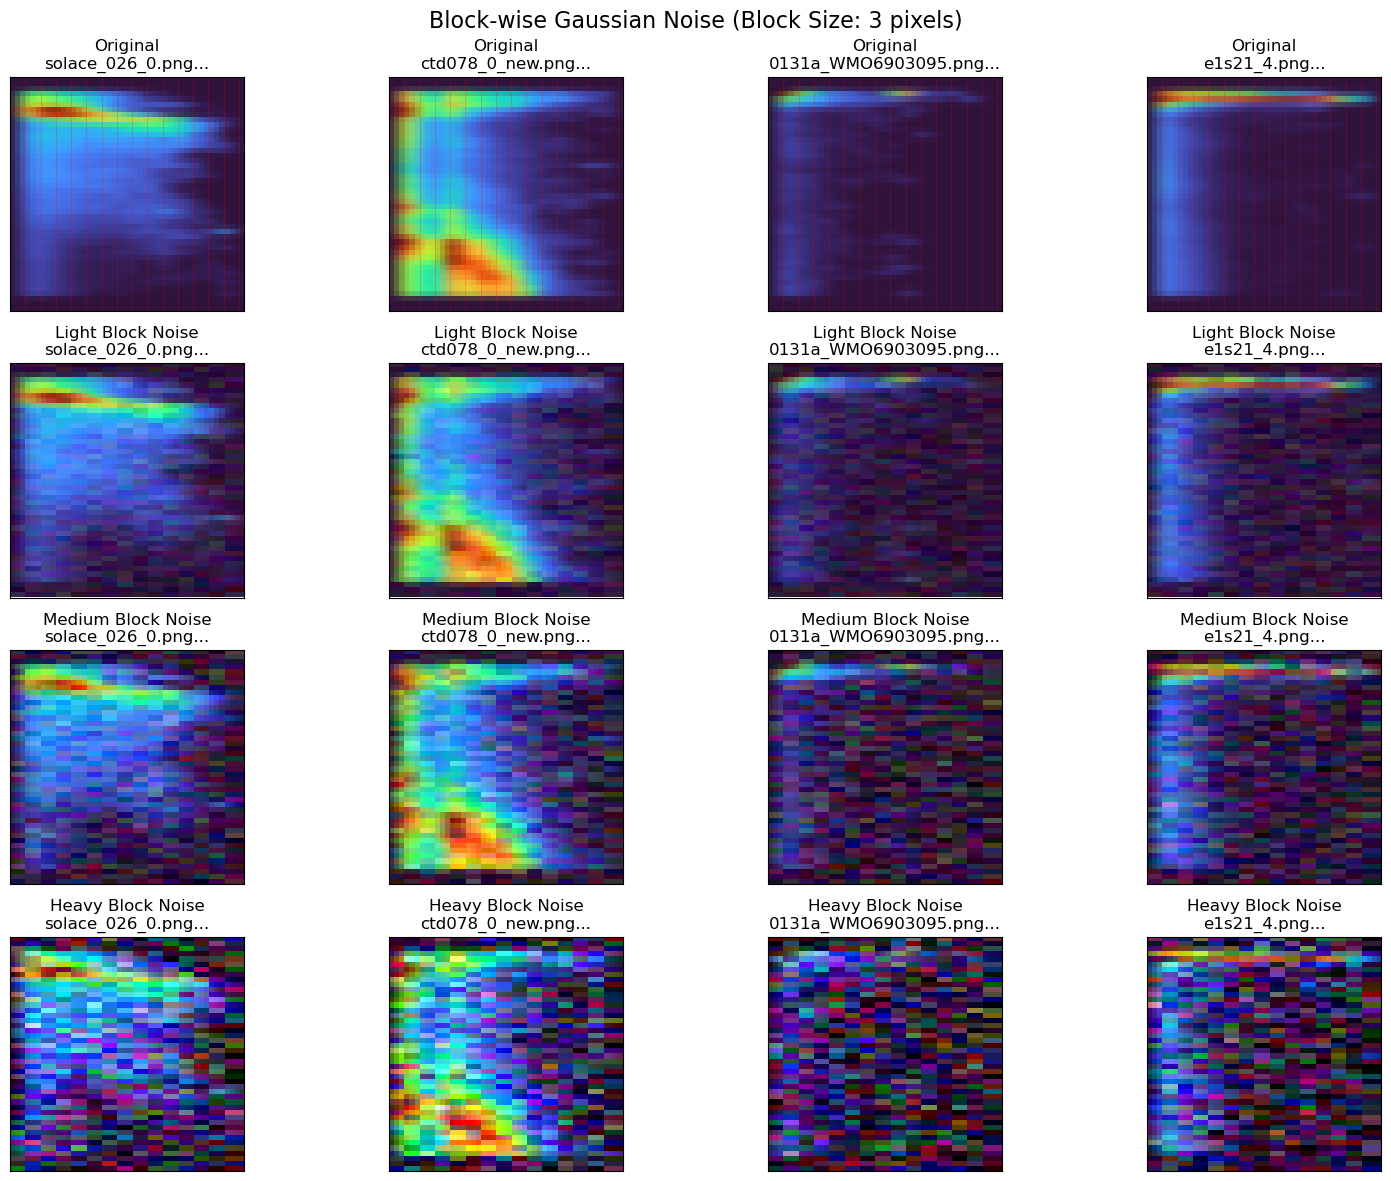


BLOCK-WISE NOISE ANALYSIS
Block size: 3 pixels per datapoint
Number of datapoints along x-axis: 15

Light Block Noise (σ = 0.05):
  Mean absolute difference: 0.0391
  Max absolute difference: 0.1608
  Within-block correlation: 1.000

Medium Block Noise (σ = 0.1):
  Mean absolute difference: 0.0772
  Max absolute difference: 0.3692
  Within-block correlation: 0.999

Heavy Block Noise (σ = 0.2):
  Mean absolute difference: 0.1446
  Max absolute difference: 0.7066
  Within-block correlation: 0.999


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import random
import os
from PIL import Image
import tensorflow as tf

def add_block_gaussian_noise(image, noise_level, block_size=3):
    """
    Add Gaussian noise in blocks of pixels along x-axis
    
    Parameters: 
    image (np.array): Input image 
    noise_level (float): Standard deviation of noise
    block_size (int): Number of pixels per block (default 3)
    """
    if noise_level == 0.0:
        return image
    
    height, width = image.shape[: 2]
    n_channels = image.shape[2] if len(image.shape) == 3 else 1
    
    # Calculate number of complete blocks along x-axis
    n_blocks = width // block_size
    effective_width = n_blocks * block_size
    
    # Create noise at the block level (one noise value per block)
    block_noise_shape = (height, n_blocks) + ((n_channels,) if n_channels > 1 else ())
    block_noise = np.random.normal(0, noise_level, block_noise_shape)
    
    # Expand each noise value to fill the entire block (repeat 3 times along x-axis)
    if n_channels > 1:
        # Multi-channel image
        pixel_noise = np.repeat(block_noise, block_size, axis=1)
        # Handle any remaining pixels if width is not divisible by block_size
        if effective_width < width:
            remaining_pixels = width - effective_width
            last_block_noise = block_noise[: , -1: , : ] 
            last_block_expanded = np.repeat(last_block_noise, remaining_pixels, axis=1)
            pixel_noise = np.concatenate([pixel_noise, last_block_expanded], axis=1)
    else:
        # Grayscale image
        pixel_noise = np.repeat(block_noise, block_size, axis=1)
        if effective_width < width:
            remaining_pixels = width - effective_width
            last_block_noise = block_noise[:, -1:]
            last_block_expanded = np.repeat(last_block_noise, remaining_pixels, axis=1)
            pixel_noise = np.concatenate([pixel_noise, last_block_expanded], axis=1)
    
    # Add noise to image and clip to valid range
    noisy_image = image + pixel_noise
    return np.clip(noisy_image, 0, 1)

def test_block_gaussian_noise(heatmap_dir="../Data/heatmaps", block_size=3):
    """
    Test block-wise Gaussian noise on PNG heatmap files
    """
    # Set random seed for reproducibility
    random.seed(42)
    np.random.seed(42)
    
    # Get random heatmap files
    heatmap_files = [f for f in os.listdir(heatmap_dir) if f.endswith('.png')]
    
    if len(heatmap_files) == 0:
        print(f"No .png files found in {heatmap_dir}")
        return
    
    print(f"Found {len(heatmap_files)} PNG heatmap files")
    selected_files = random.sample(heatmap_files, min(4, len(heatmap_files)))
    
    # Load and prepare heatmaps
    heatmaps = []
    for filename in selected_files:
        img_path = os.path.join(heatmap_dir, filename)
        img = Image.open(img_path)
        heatmap = np.array(img).astype(np.float32) / 255.0
        
        # Handle RGBA by removing alpha channel
        if len(heatmap.shape) == 3 and heatmap.shape[2] == 4:
            heatmap = heatmap[: , :, :3]
        
        print(f"Loaded {filename}:  shape {heatmap.shape}")
        print(f"  With block_size={block_size}, this represents {heatmap.shape[1]//block_size} datapoints along x-axis")
        heatmaps.append(heatmap)
    
    # Define noise levels
    noise_configs = [
        (0.0, "Original"),
        (0.05, "Light Block Noise"),  
        (0.1, "Medium Block Noise"),
        (0.2, "Heavy Block Noise")
    ]
    
    # Create plot
    fig, axes = plt.subplots(4, len(selected_files), figsize=(4*len(selected_files), 12))
    
    # Handle single file case
    if len(selected_files) == 1:
        axes = axes.reshape(-1, 1)
    
    for row, (noise_level, label) in enumerate(noise_configs):
        for col in range(len(selected_files)):
            # Apply block-wise noise
            display_data = add_block_gaussian_noise(heatmaps[col], noise_level, block_size)
            
            # Display the heatmap
            if len(display_data.shape) == 3 and display_data.shape[2] == 3:
                # RGB image
                axes[row, col].imshow(display_data)
            elif len(display_data.shape) == 3:
                # Multi-channel - average for display
                axes[row, col].imshow(np.mean(display_data, axis=-1), cmap='viridis')
            else:
                # Grayscale
                axes[row, col].imshow(display_data, cmap='viridis')
            
            axes[row, col].set_title(f"{label}\n{selected_files[col][:20]}...")
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
            
            # Add grid lines to show block structure (optional)
            if row == 0:  # Only on original images
                width = display_data.shape[1]
                for x in range(0, width, block_size):
                    axes[row, col].axvline(x - 0.5, color='red', alpha=0.3, linewidth=0.5)
    
    plt.suptitle(f'Block-wise Gaussian Noise (Block Size: {block_size} pixels)', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Print noise statistics
    print("\n" + "="*60)
    print("BLOCK-WISE NOISE ANALYSIS")
    print("="*60)
    print(f"Block size: {block_size} pixels per datapoint")
    
    original = heatmaps[0]
    n_datapoints = original.shape[1] // block_size
    print(f"Number of datapoints along x-axis: {n_datapoints}")
    
    for noise_level, label in noise_configs[1:]:
        noisy = add_block_gaussian_noise(original, noise_level, block_size)
        
        mean_diff = np.mean(np.abs(noisy - original))
        max_diff = np.max(np.abs(noisy - original))
        
        # Calculate noise correlation within blocks
        block_correlation = analyze_block_structure(original, noisy, block_size)
        
        print(f"\n{label} (σ = {noise_level}):")
        print(f"  Mean absolute difference: {mean_diff:.4f}")
        print(f"  Max absolute difference: {max_diff:.4f}")
        print(f"  Within-block correlation: {block_correlation:.3f}")

def analyze_block_structure(original, noisy, block_size):
    """Analyze correlation within blocks to verify block structure"""
    height, width = original.shape[:2]
    n_blocks = width // block_size
    
    correlations = []
    noise_diff = noisy - original
    
    for block_idx in range(n_blocks):
        start_x = block_idx * block_size
        end_x = start_x + block_size
        
        if end_x <= width:
            block_noise = noise_diff[:, start_x:end_x]
            
            # Calculate correlation between adjacent pixels in the block
            if block_size > 1:
                pixel1 = block_noise[:, 0].flatten()
                pixel2 = block_noise[:, 1].flatten()
                if len(pixel1) > 0 and len(pixel2) > 0:
                    correlation = np.corrcoef(pixel1, pixel2)[0, 1]
                    if not np.isnan(correlation):
                        correlations.append(correlation)
    
    return np.mean(correlations) if correlations else 0.0

# Test the block-wise noise
test_block_gaussian_noise(heatmap_dir=HEATMAP_DIR, block_size=3)

- noise of 0.05 looks good, the higher levels are too much
- note that noise is added in 3-pixel blocks, same as the datapoint representation

In [5]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class BlockGaussianNoise(Layer):
    """Custom layer for block-wise Gaussian noise augmentation"""
    
    def __init__(self, noise_level, block_size=3, seed=None, **kwargs):
        super(BlockGaussianNoise, self).__init__(**kwargs)
        self.noise_level = noise_level
        self.block_size = block_size
        self.seed = seed
        self.supports_masking = True
    
    def build(self, input_shape):
        super(BlockGaussianNoise, self).build(input_shape)
    
    def call(self, inputs, training=None):
        if training is None:
            training = tf.keras.backend.learning_phase()
        
        def apply_noise():
            # Get input shape
            input_shape = tf.shape(inputs)
            batch_size = input_shape[0]
            height = input_shape[1]
            width = input_shape[2]
            channels = input_shape[3]
            
            # Calculate number of blocks
            n_blocks = width // self.block_size
            effective_width = n_blocks * self.block_size
            
            # Generate noise at block level
            block_noise = tf.random.normal(
                shape=[batch_size, height, n_blocks, channels],
                stddev=self.noise_level,
                seed=self.seed
            )
            
            # Repeat noise for each pixel in the block
            pixel_noise = tf.repeat(block_noise, self.block_size, axis=2)
            
            # Handle remaining pixels if width not divisible by block_size
            if effective_width < width:
                remaining = width - effective_width
                last_block = block_noise[: , :, -1:, :]
                last_expanded = tf.repeat(last_block, remaining, axis=2)
                pixel_noise = tf.concat([pixel_noise, last_expanded], axis=2)
            else:
                # Ensure pixel_noise has the correct width
                pixel_noise = pixel_noise[:, :, :width, :]
            
            # Add noise to inputs
            return inputs + pixel_noise
        
        def no_noise():
            return inputs
        
        return tf.cond(tf.cast(training, tf.bool), apply_noise, no_noise)
    
    def compute_output_shape(self, input_shape):
        return input_shape
    
    def compute_output_spec(self, input_spec):
        return input_spec
    
    def get_config(self):
        config = {
            'noise_level': self.noise_level,
            'block_size': self.block_size,
            'seed': self.seed,
        }
        base_config = super(BlockGaussianNoise, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))

# Add this to your class
HeatmapCNNClassifier.BlockGaussianNoise = BlockGaussianNoise


### Functions for: CNN model creation, compiling, cross-validation with pre-defined folds

In [6]:
######################## Create CNN model - tune model architecture here ###############################
#######################

# Adjust hyperparameters
learning_rate = 0.001
dropout_rate_conv = 0.25
dropout_rate_dense = 0.5
batch_size = 32
epochs = 100
patience = 10 # patience of early stopping callback
verbose_val = 1 # no output during training
k = 4 # number of folds for cross-validation
metrics_to_monitor = ['accuracy', ]

# augmentation parameters
noise_level = 0.075 # Gaussian noise level - data augmentation
block_size = 3 # Block size for block-wise noise

######################## Create CNN model architecture ###############################

def create_cnn_model(self, input_shape):
    """Create CNN model architecture"""
    print(f"Creating CNN model for input shape: {input_shape}")
    
    model = Sequential([

        # Input layer with block-wise Gaussian noise augmentation
        BlockGaussianNoise(noise_level, block_size, seed=42, input_shape=input_shape),

        # First convolutional block
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(dropout_rate_conv),
        
        # Second convolutional block
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(dropout_rate_conv),
        
        # Third convolutional block
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(dropout_rate_conv),
        
        # Fully connected layers
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate_dense),

        Dense(256, activation='relu'),
        Dropout(dropout_rate_dense),

        Dense(self.n_classes, activation='softmax')         # Output layer for multi-class classification
    ])
    
    return model

# add the function to the class
HeatmapCNNClassifier.create_cnn_model = create_cnn_model


######################## Compile model ###############################

def compile_model(self, model):
    """Compile the CNN model"""
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=metrics_to_monitor
    )
    return model

# add the function to the class
HeatmapCNNClassifier.compile_model = compile_model


######################## Fit model once to each fold - cross-validate ###############################
def cross_validate(self):
    """Perform cross-validation using pre-defined folds with balanced data"""
    print("Starting cross-validation with balanced data...")
        
    unique_folds = list(self.fold_balanced_data.keys())
    print(f"Cross-validation folds: {unique_folds}")
    
    cv_results = {
        'balanced_accuracy': [],
        'macro_f1':  [],
        'fold_predictions':  [],
        'fold_true_labels': [],
        # Add training metrics tracking
        'train_loss': [],
        'train_accuracy': [],
        'val_loss': [],
        'val_accuracy': []
    }
    
    # Store individual fold results for confusion matrices
    self.cv_fold_results = []
    
    for fold in unique_folds:                            ### for-loop over folds
        print(f"\nProcessing fold:  {fold}")
        
        # Get balanced data for this fold
        fold_data = self.fold_balanced_data[fold]
        X_train_fold = fold_data['X_train_scaled']
        y_train_fold = fold_data['y_train']
        X_val_fold = fold_data['X_val_scaled']
        y_val_fold = fold_data['y_val']
        
        print(f"Fold {fold} - Train:  {len(X_train_fold)}, Val: {len(X_val_fold)}")
        
        # Convert to categorical: one-hot encoding of clusters for keras
        y_train_fold_cat = to_categorical(y_train_fold, self.n_classes)
        y_val_fold_cat = to_categorical(y_val_fold, self.n_classes)
        
        # Create and compile model
        model = self.create_cnn_model(X_train_fold.shape[1:])
        model = self.compile_model(model)
        
        # Set up callbacks
        early_stopping = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7) # reduce learning rate if no improvement (on plateau)
        
        # Train model
        history = model.fit(
            X_train_fold, y_train_fold_cat,
            validation_data=(X_val_fold, y_val_fold_cat),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stopping, reduce_lr],
            verbose=verbose_val
        )
        
        # Extract final training metrics from history
        final_train_loss = history.history['loss'][-1]
        final_train_accuracy = history.history['accuracy'][-1]
        final_val_loss = history.history['val_loss'][-1]
        final_val_accuracy = history.history['val_accuracy'][-1]
        
        # Store training metrics
        cv_results['train_loss'].append(final_train_loss)
        cv_results['train_accuracy'].append(final_train_accuracy)
        cv_results['val_loss'].append(final_val_loss)
        cv_results['val_accuracy'].append(final_val_accuracy)
        
        # Make predictions for additional metrics
        y_pred_proba = model.predict(X_val_fold, verbose=verbose_val)
        y_pred = np.argmax(y_pred_proba, axis=1)
        
        # Calculate additional validation metrics
        bal_acc = balanced_accuracy_score(y_val_fold, y_pred)
        macro_f1 = f1_score(y_val_fold, y_pred, average='macro')
        
        cv_results['balanced_accuracy'].append(bal_acc)
        cv_results['macro_f1'].append(macro_f1)
        cv_results['fold_predictions'].extend(y_pred)
        cv_results['fold_true_labels'].extend(y_val_fold)
        
        # Calculate training metrics on training data
        y_train_pred_proba = model.predict(X_train_fold, verbose=verbose_val)
        y_train_pred = np.argmax(y_train_pred_proba, axis=1)
        train_bal_acc = balanced_accuracy_score(y_train_fold, y_train_pred)
        train_macro_f1 = f1_score(y_train_fold, y_train_pred, average='macro')
        
        # Store individual fold results for confusion matrices
        fold_result = {
            'fold_name': fold,
            'y_true': y_val_fold,
            'y_pred': y_pred,
            'balanced_accuracy': bal_acc,
            'macro_f1':  macro_f1,
            'n_samples': len(y_val_fold),
            # Add training metrics to fold results
            'train_loss':  final_train_loss,
            'train_accuracy': final_train_accuracy,
            'train_balanced_accuracy': train_bal_acc,
            'train_macro_f1': train_macro_f1,
            'val_loss': final_val_loss,
            'val_accuracy': final_val_accuracy
        }
        self.cv_fold_results.append(fold_result)
        
        # Print comprehensive fold results
        print(f"Fold {fold} Results:")
        print(f"  Training   - Loss: {final_train_loss:.4f}, Accuracy: {final_train_accuracy:.4f}, Bal. Acc: {train_bal_acc:.4f}, F1: {train_macro_f1:.4f}")
        print(f"  Validation - Loss: {final_val_loss:.4f}, Accuracy: {final_val_accuracy:.4f}, Bal.Acc: {bal_acc:.4f}, F1: {macro_f1:.4f}")
        
    self.cv_results = cv_results
    self.print_cv_results()

# Add the updated function to the class
HeatmapCNNClassifier.cross_validate = cross_validate

######################## Print CV results (integrated in cross_validate) ###############################

def print_cv_results(self):
    """Print comprehensive cross-validation results including training metrics"""
    
    print("\n" + "="*80)
    print("CROSS-VALIDATION RESULTS SUMMARY")
    print("="*80)
    
    # Validation metrics
    bal_acc_mean = np.mean(self.cv_results['balanced_accuracy'])
    bal_acc_std = np.std(self.cv_results['balanced_accuracy'])
    f1_mean = np.mean(self.cv_results['macro_f1'])
    f1_std = np.std(self.cv_results['macro_f1'])
    val_loss_mean = np.mean(self.cv_results['val_loss'])
    val_loss_std = np.std(self.cv_results['val_loss'])
    val_acc_mean = np.mean(self.cv_results['val_accuracy'])
    val_acc_std = np.std(self.cv_results['val_accuracy'])
    
    # Training metrics
    train_loss_mean = np.mean(self.cv_results['train_loss'])
    train_loss_std = np.std(self.cv_results['train_loss'])
    train_acc_mean = np.mean(self.cv_results['train_accuracy'])
    train_acc_std = np.std(self.cv_results['train_accuracy'])
    
    # Calculate training balanced accuracy and F1 from fold results
    train_bal_accs = [fold['train_balanced_accuracy'] for fold in self.cv_fold_results]
    train_f1s = [fold['train_macro_f1'] for fold in self.cv_fold_results]
    train_bal_acc_mean = np.mean(train_bal_accs)
    train_bal_acc_std = np.std(train_bal_accs)
    train_f1_mean = np.mean(train_f1s)
    train_f1_std = np.std(train_f1s)
    
    print("TRAINING METRICS (average across folds):")
    print(f"  Loss:                 {train_loss_mean:.4f} ± {train_loss_std:.4f}")
    print(f"  Accuracy:            {train_acc_mean:.4f} ± {train_acc_std:.4f}")
    print(f"  Balanced Accuracy:   {train_bal_acc_mean:.4f} ± {train_bal_acc_std:.4f}")
    print(f"  Macro F1 Score:      {train_f1_mean:.4f} ± {train_f1_std:.4f}")
    
    print("\nVALIDATION METRICS (average across folds):")
    print(f"  Loss:                {val_loss_mean:.4f} ± {val_loss_std:.4f}")
    print(f"  Accuracy:            {val_acc_mean:.4f} ± {val_acc_std:.4f}")
    print(f"  Balanced Accuracy:   {bal_acc_mean:.4f} ± {bal_acc_std:.4f}")
    print(f"  Macro F1 Score:      {f1_mean:.4f} ± {f1_std:.4f}")
    
    # Calculate overfitting indicators
    accuracy_gap = train_acc_mean - val_acc_mean
    loss_gap = val_loss_mean - train_loss_mean  # Higher validation loss indicates overfitting
    bal_acc_gap = train_bal_acc_mean - bal_acc_mean
    
    print("\nOVERFITTING ANALYSIS:")
    print(f"  Accuracy Gap (train - val):     {accuracy_gap:.4f}")
    print(f"  Loss Gap (val - train):         {loss_gap:.4f}")
    print(f"  Bal. Accuracy Gap (train - val): {bal_acc_gap:.4f}")
    
    if accuracy_gap > 0.1:
        print("  ⚠️  Large accuracy gap suggests overfitting")
    elif accuracy_gap < 0.02:
        print("  ✅ Good generalization (low accuracy gap)")
    else:
        print("  ➡️  Moderate accuracy gap")
    
    print("\nPER-FOLD BREAKDOWN:")
    print("Fold      | Train Acc | Val Acc | Train F1 | Val F1  | Train Loss | Val Loss")
    print("-"*75)
    for i, fold_result in enumerate(self.cv_fold_results):
        fold_name = fold_result['fold_name']
        train_acc = fold_result['train_accuracy']
        val_acc = fold_result['balanced_accuracy']  # Using balanced accuracy for validation
        train_f1 = fold_result['train_macro_f1']
        val_f1 = fold_result['macro_f1']
        train_loss = fold_result['train_loss']
        val_loss = fold_result['val_loss']
        
        print(f"{fold_name: <9} | {train_acc:.4f}    | {val_acc:.4f}  | {train_f1:.4f}   | {val_f1:.4f}  | {train_loss:.4f}     | {val_loss:.4f}")

# add the function to the class
HeatmapCNNClassifier.print_cv_results = print_cv_results


######################## Confusion Matrix Function ###############################

def plot_cv_fold_confusion_matrices(self, k=k):
    """
    Plot normalized confusion matrices for each CV fold
    
    Parameters:  
    k (int): Number of folds to display (default 4)
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix
    import numpy as np
    
    if not hasattr(self, 'cv_results'):
        print("Error: No cross-validation results found.  Run cross_validate() first.")
        return
    
    if not hasattr(self, 'cv_fold_results'):
        print("Error: Individual fold results not available.")
        print("Make sure you're using the updated cross_validate() method.")
        return
    
    n_folds = min(k, len(self.cv_fold_results))
    
    # Set up the subplot grid (2x2 for 4 folds)
    if n_folds <= 2:
        fig, axes = plt.subplots(1, n_folds, figsize=(7*n_folds, 6))
        if n_folds == 1:
            axes = [axes]
    else:
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        axes = axes.flatten()
    
    # Color map for consistency
    cmap = 'Blues'
    
    print("\n" + "="*60)
    print("CV FOLD CONFUSION MATRIX SUMMARY")
    print("="*60)
    
    for fold_idx in range(n_folds):
        ax = axes[fold_idx]
        
        # Get predictions and true labels for this fold
        fold_result = self.cv_fold_results[fold_idx]
        y_true_fold = fold_result['y_true']
        y_pred_fold = fold_result['y_pred']
        fold_name = fold_result['fold_name']
        
        # Calculate confusion matrix
        cm = confusion_matrix(y_true_fold, y_pred_fold)
        
        # Normalize confusion matrix (row-wise normalization)
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        # Handle any NaN values (in case a class has 0 samples)
        cm_normalized = np.nan_to_num(cm_normalized)
        
        # Create heatmap
        sns.heatmap(cm_normalized, 
                   annot=True, 
                   fmt='.2f', 
                   cmap=cmap,
                   ax=ax,
                   xticklabels=self.label_encoder.classes_,
                   yticklabels=self.label_encoder.classes_,
                   vmin=0, 
                   vmax=1,
                   cbar_kws={'label': 'Normalized Count'})
        
        # Calculate accuracy for this fold
        accuracy = fold_result['balanced_accuracy']
        macro_f1 = fold_result['macro_f1']
        
        ax.set_title(f'{fold_name}\nBal.  Acc: {accuracy:.3f}, F1: {macro_f1:.3f}')
        ax.set_xlabel('Predicted Cluster')
        ax.set_ylabel('True Cluster')
        
        # Print summary for this fold
        print(f"\n{fold_name}:")
        print(f"  Samples: {fold_result['n_samples']}")
        print(f"  Balanced Accuracy: {accuracy:.3f}")
        print(f"  Macro F1: {macro_f1:.3f}")
        
        # Per-class statistics
        print("  Per-class recall (diagonal values):")
        for class_idx, class_name in enumerate(self.label_encoder.classes_):
            if class_idx < len(cm_normalized):
                recall = cm_normalized[class_idx, class_idx]
                print(f"    Cluster {class_name}: {recall:.3f}")
    
    # Hide any unused subplots
    if n_folds < len(axes):
        for idx in range(n_folds, len(axes)):
            axes[idx].axis('off')
    
    plt.suptitle('Normalized Confusion Matrices by CV Fold', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()
    
    # Overall summary
    print(f"\n" + "="*60)
    print("OVERALL CV SUMMARY")
    print("="*60)
    all_accuracies = [fold['balanced_accuracy'] for fold in self.cv_fold_results]
    all_f1s = [fold['macro_f1'] for fold in self.cv_fold_results]
    
    print(f"Mean Balanced Accuracy: {np.mean(all_accuracies):.3f} ± {np.std(all_accuracies):.3f}")
    print(f"Mean Macro F1: {np.mean(all_f1s):.3f} ± {np.std(all_f1s):.3f}")

# Add the function to the class
HeatmapCNNClassifier.plot_cv_fold_confusion_matrices = plot_cv_fold_confusion_matrices


### Main function - full pipeline

In [7]:
def run_full_pipeline(self):
    """Run the complete pipeline"""
    print("Starting Heatmap CNN Classification Pipeline")
    print("=" * 50)
    
    # Step 1: Load data
    self.load_data_assignments()
    self.load_heatmaps()
    
    # Step 2: Split train/test
    self.split_train_test()
    
    # Step 4: Balance classes per fold
    #self.balance_classes_per_fold_SMOTETomek() # alternative: use SMOTE Tomek Link
    self.balance_classes_per_fold_simple()

    # Step 5: Scale data
    self.scale_data()
    
    # Step 6: Cross-validation
    self.cross_validate()

    # Step 7: Plot CV confusion matrices
    self.plot_cv_fold_confusion_matrices()
            
    print("\nPipeline completed successfully!")

# add the function to the class
HeatmapCNNClassifier.run_full_pipeline = run_full_pipeline


### Run pipeline

Starting Heatmap CNN Classification Pipeline
Loading data assignments...
Train/test DataFrame shape: (5619, 3)
Clusters DataFrame shape: (5619, 4)
Train/test columns: ['Profile_id', 'data_type', 'CV_fold']
Clusters columns:  ['Profile_id', 'cluster', 'cluster_4', 'cluster_6']
Loaded assignments for 5619 profiles
Loaded cluster assignments for 5619 profiles
Sample train/test data for profile s033:  {'data_type': 'test', 'CV_fold': ''}
Sample cluster data for profile s033:  {'cluster': 1, 'cluster_4': 1, 'cluster_6': 2}
Loading heatmap images...
Found 5619 PNG files in ..\Data\heatmaps
Sample filenames: ['0000a_WMO5906623_recovery_profiles.png', '0002a_WMO5906623_recovery_profiles.png', '0003a_WMO5906623_recovery_profiles.png', '0003a_WMO6904139_recovery.png', '0004a_WMO6903096.png']
Sample extracted profile IDs: ['0000a_WMO5906623_recovery_profiles', '0002a_WMO5906623_recovery_profiles', '0003a_WMO5906623_recovery_profiles', '0003a_WMO6904139_recovery', '0004a_WMO6903096']
Available pro

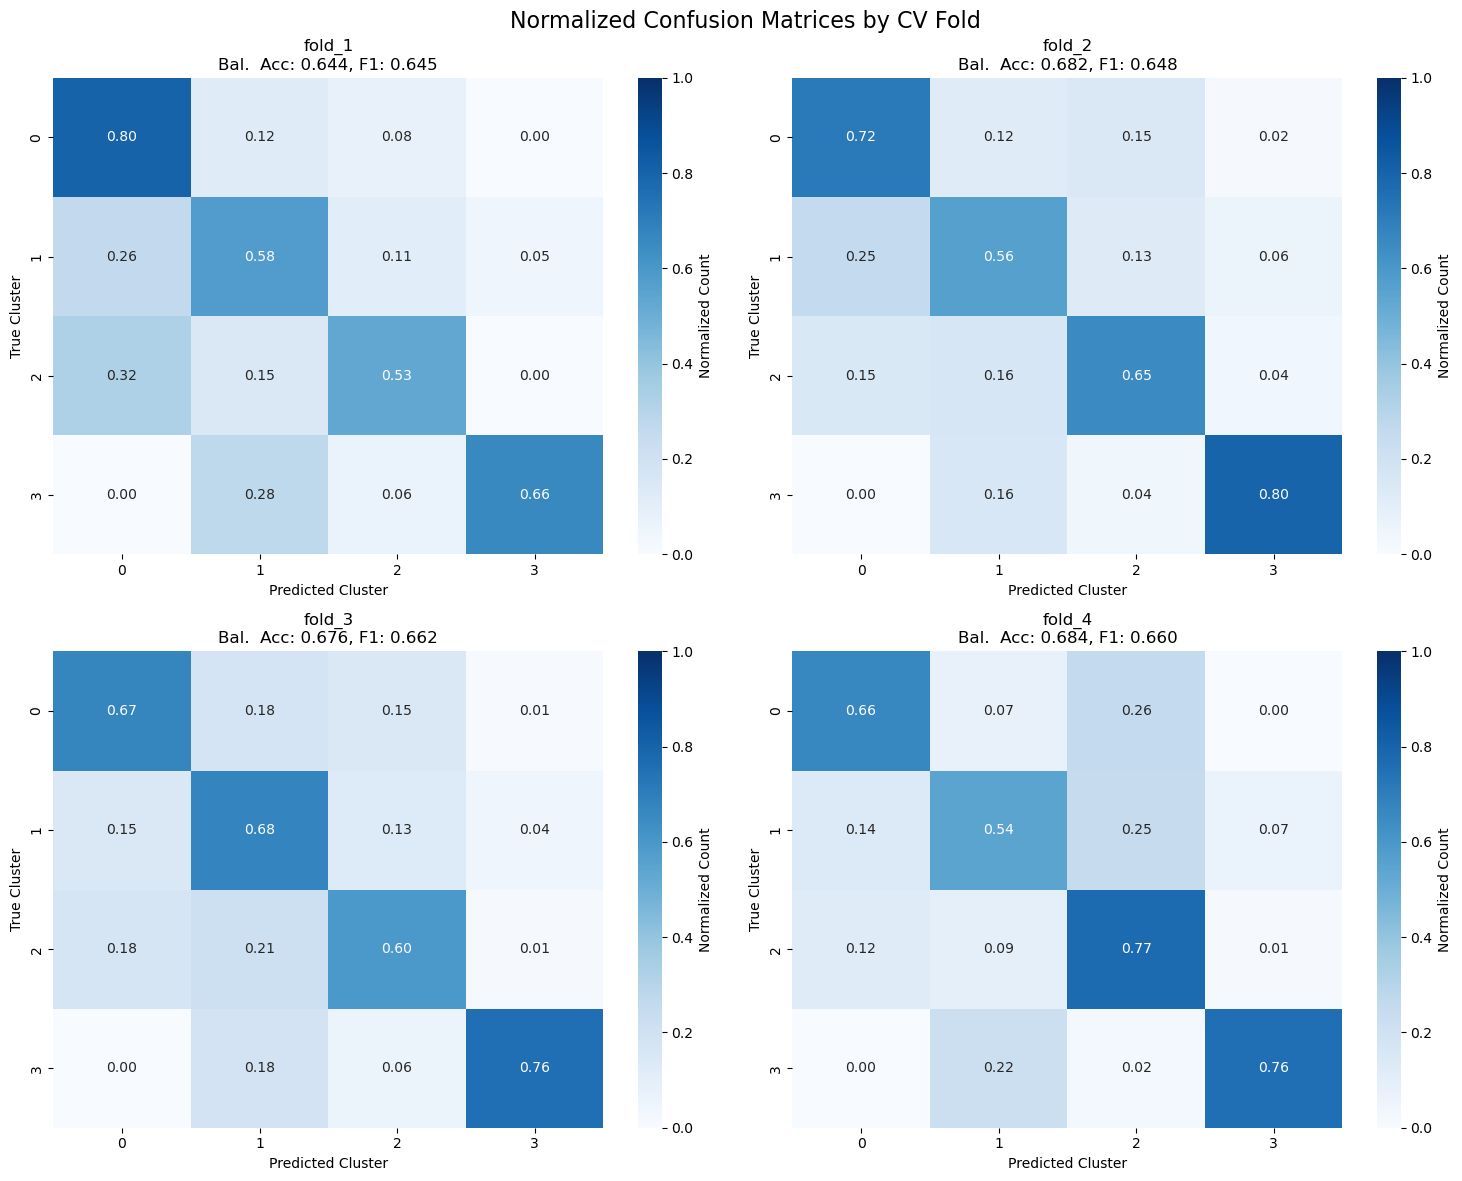


OVERALL CV SUMMARY
Mean Balanced Accuracy: 0.671 ± 0.016
Mean Macro F1: 0.654 ± 0.007

Pipeline completed successfully!


In [7]:
classifier = HeatmapCNNClassifier()
classifier.run_full_pipeline()

### Fit model on full training data (once tuning is complete) and evaluate on test data

### SHAP analysis

# Second CNN: hierarchical model

## Visualize hierarchy of clusters

Creating CORRECTED cluster similarity dendrogram...
Creating corrected dendrogram from 10 clusters
Pairwise distance range: 0.000 - 1.826
Linkage height range: 0.446 - 1.058

Corrected thresholds based on linkage heights:
  very_similar: 0.518
  moderately_similar: 0.617
  different: 0.733


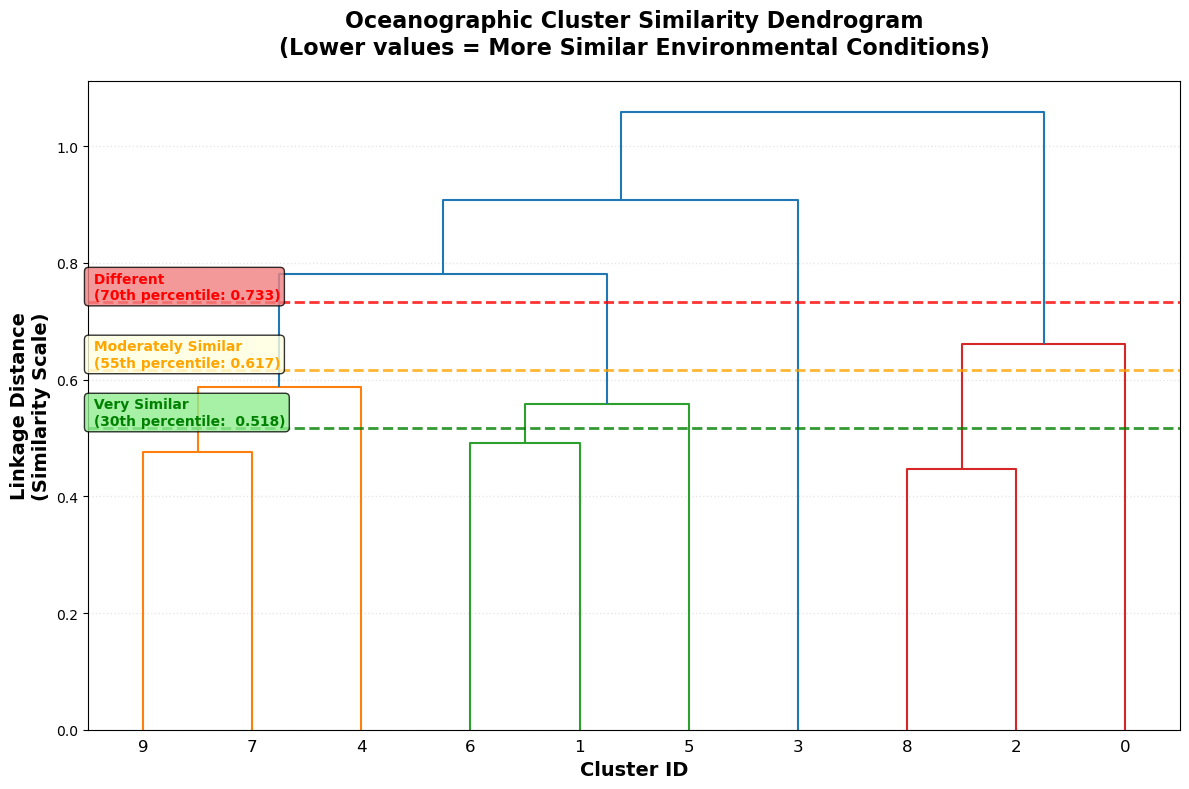


THRESHOLD ANALYSIS:  PAIRWISE vs LINKAGE DISTANCES

Original thresholds (based on pairwise distances):
very_similar: 0.601
moderately_similar: 0.857
different: 1.064

Corrected thresholds (based on linkage heights):
very_similar: 0.518
moderately_similar: 0.617
different: 0.733

Why they differ:
  • Pairwise distances: Direct distances between cluster centroids
  • Linkage heights:  Distances at which clusters merge in the dendrogram
  • Linkage method affects how clusters merge (single/complete/average/ward)
  • Linkage heights represent hierarchical structure, not just pairwise similarity

Linkage height statistics:
  Range: 0.000 - 17.000
  Mean: 5.471
  Std: 5.098


In [8]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

def plot_cluster_similarity_dendrogram_corrected(hierarchy_config_path="../Data/cluster_hierarchy.pkl", 
                                               method='average', figsize=(12, 8)):
    """
    Plot dendrogram with thresholds based on LINKAGE HEIGHTS rather than pairwise distances
    """
    
    # Load hierarchy information
    with open(hierarchy_config_path, 'rb') as f:
        hierarchy_info = pickle.load(f)
    
    distance_matrix = hierarchy_info['distance_matrix']
    cluster_labels = hierarchy_info['cluster_labels']
    
    print(f"Creating corrected dendrogram from {len(cluster_labels)} clusters")
    print(f"Pairwise distance range: {distance_matrix.min():.3f} - {distance_matrix.max():.3f}")
    
    # Convert distance matrix to condensed form for linkage
    condensed_distances = squareform(distance_matrix, checks=False)
    
    # Perform hierarchical clustering
    linkage_matrix = linkage(condensed_distances, method=method)
    
    # Extract linkage heights (these are the actual dendrogram y-values)
    linkage_heights = linkage_matrix[: , 2]
    print(f"Linkage height range: {linkage_heights.min():.3f} - {linkage_heights.max():.3f}")
    
    # Calculate thresholds based on LINKAGE HEIGHTS (not pairwise distances)
    linkage_percentiles = np.percentile(linkage_heights, [30, 55, 70])
    linkage_thresholds = {
        'very_similar': linkage_percentiles[0],     # 30th percentile of linkage heights
        'moderately_similar': linkage_percentiles[1], # 55th percentile of linkage heights  
        'different': linkage_percentiles[2]         # 70th percentile of linkage heights
    }
    
    print(f"\nCorrected thresholds based on linkage heights:")
    for name, threshold in linkage_thresholds.items():
        print(f"  {name}: {threshold:.3f}")
    
    # Create the dendrogram
    plt.figure(figsize=figsize)
    
    # Plot dendrogram
    dendro = dendrogram(
        linkage_matrix,
        labels=cluster_labels,
        orientation='top',
        distance_sort='descending',
        show_leaf_counts=True,
        leaf_rotation=0,
        leaf_font_size=12,
        color_threshold=0.7 * max(linkage_heights),
    )
    
    # Get the actual y-limits from the dendrogram
    y_min, y_max = plt.ylim()
    
    # Customize the plot
    plt.title('Oceanographic Cluster Similarity Dendrogram\n(Lower values = More Similar Environmental Conditions)', 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Cluster ID', fontsize=14, fontweight='bold')
    plt.ylabel('Linkage Distance\n(Similarity Scale)', fontsize=14, fontweight='bold')
    
    # Add horizontal lines for CORRECTED tolerance thresholds
    # Very similar threshold
    if linkage_thresholds['very_similar'] <= y_max:
        plt.axhline(y=linkage_thresholds['very_similar'], color='green', linestyle='--', alpha=0.8, linewidth=2)
        plt.text(0.02, linkage_thresholds['very_similar'], 
                 f' Very Similar\n (30th percentile:  {linkage_thresholds["very_similar"]:.3f})', 
                 verticalalignment='bottom', fontsize=10, color='green', fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.8))
    
    # Moderately similar threshold  
    if linkage_thresholds['moderately_similar'] <= y_max:
        plt.axhline(y=linkage_thresholds['moderately_similar'], color='orange', linestyle='--', alpha=0.8, linewidth=2)
        plt.text(0.02, linkage_thresholds['moderately_similar'], 
                 f' Moderately Similar\n (55th percentile: {linkage_thresholds["moderately_similar"]:.3f})', 
                 verticalalignment='bottom', fontsize=10, color='orange', fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
    
    # Different threshold
    if linkage_thresholds['different'] <= y_max:
        plt.axhline(y=linkage_thresholds['different'], color='red', linestyle='--', alpha=0.8, linewidth=2)
        plt.text(0.02, linkage_thresholds['different'], 
                 f' Different\n (70th percentile: {linkage_thresholds["different"]:.3f})', 
                 verticalalignment='bottom', fontsize=10, color='red', fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcoral', alpha=0.8))
    
    # Add grid for better readability
    plt.grid(axis='y', alpha=0.3, linestyle=':', linewidth=1)
    
    # DON'T invert y-axis - keep it as is for proper interpretation
    
    # Adjust layout
    plt.tight_layout()
    plt.show()
    
    # Return both original and corrected thresholds for comparison
    return dendro, linkage_matrix, linkage_thresholds, hierarchy_info['distance_thresholds']

def analyze_threshold_differences(original_thresholds, linkage_thresholds, linkage_heights):
    """Analyze why the thresholds differ between pairwise distances and linkage heights"""
    
    print(f"\n{'='*80}")
    print("THRESHOLD ANALYSIS:  PAIRWISE vs LINKAGE DISTANCES")
    print(f"{'='*80}")
    
    print(f"\nOriginal thresholds (based on pairwise distances):")
    for name, threshold in original_thresholds.items():
        print(f"{name}: {threshold:.3f}")

    print(f"\nCorrected thresholds (based on linkage heights):")
    for name, threshold in linkage_thresholds.items():
        print(f"{name}: {threshold:.3f}")
    
    print(f"\nWhy they differ:")
    print(f"  • Pairwise distances: Direct distances between cluster centroids")
    print(f"  • Linkage heights:  Distances at which clusters merge in the dendrogram")
    print(f"  • Linkage method affects how clusters merge (single/complete/average/ward)")
    print(f"  • Linkage heights represent hierarchical structure, not just pairwise similarity")
    
    print(f"\nLinkage height statistics:")
    print(f"  Range: {linkage_heights.min():.3f} - {linkage_heights.max():.3f}")
    print(f"  Mean: {linkage_heights.mean():.3f}")
    print(f"  Std: {linkage_heights.std():.3f}")


# ============================================================================
# Execute Corrected Analysis
# ============================================================================


print("Creating CORRECTED cluster similarity dendrogram...")
dendro, linkage_matrix, corrected_thresholds, original_thresholds = plot_cluster_similarity_dendrogram_corrected()

analyze_threshold_differences(original_thresholds, corrected_thresholds, linkage_matrix)

## Functions for including cluster hierarchy

In [9]:
import pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Layer
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# CONFIGURATION SECTION - Tune hyperparameters here
# ============================================================================

HIERARCHY_CONFIG = {
    # File path
    'hierarchy_config_path':   "../Data/cnn_hierarchy_config.pkl",
    
    # Model architecture
    'conv_filters': [32, 64, 128],  # Number of filters for each conv block
    'conv_kernel_size': (3, 3),
    'dense_units': [512, 256, 128],  # Units for shared, fine, coarse branches
    'dropout_rates': [0.25, 0.25, 0.25, 0.5, 0.5],  # After each conv block, fine branch, coarse branch
    
    # Block Gaussian Noise
    'use_block_noise': True,
    'noise_level': 0.01,  # Standard deviation of noise
    'block_size': 3,      # Size of noise blocks
    
    # Training parameters
    'learning_rate': 0.001,
    'batch_size': 32,
    'epochs': 100,
    'early_stopping_patience': 15,
    'reduce_lr_patience': 7,
    'min_lr': 1e-7,
    
    # Loss weights
    'fine_loss_weight': 1.0,      # Weight for fine-grained loss
    'level_1_weight': 3.0,        # Weight for level 1 (2 groups)
    'level_2_weight': 2.5,        # Weight for level 2 (4 groups)  
    'level_3_weight': 2.0,        # Weight for level 3 (6 groups)
    'hierarchical_loss_multiplier': 1.5,  # Multiplier for distance-based weighting
    
    # Evaluation
    'hierarchy_levels': ['level_1_groups', 'level_2_groups', 'level_3_groups', 'level_4_groups'],
    'tolerance_levels': ['very_similar', 'moderately_similar', 'different'],
    
    # Visualization
    'confusion_matrix_format': 'percentage',  # 'percentage' or 'counts' 
    'show_counts_and_percentages': True,      # Show both counts and percentages
    'normalize_confusion_matrix': True        # Normalize by true class (row-wise)
}

# ============================================================================
# Hierarchical CNN Functions Class
# ============================================================================

class HierarchicalCNNFunctions:
    """Class containing all hierarchy-related functions for CNN"""
    
    def __init__(self, config=HIERARCHY_CONFIG):
        """Initialize with hierarchy configuration"""
        self.config = config
        self.hierarchy_info = None
        self.load_hierarchy_info()
    
    # ========================================================================
    # Configuration and Data Loading
    # ========================================================================
    
    def load_hierarchy_info(self):
        """Load hierarchical cluster information"""
        hierarchy_path = self.config['hierarchy_config_path']
        print(f"Loading hierarchy configuration from: {hierarchy_path}")
        
        with open(hierarchy_path, 'rb') as f:
            self.hierarchy_info = pickle.load(f)
        
        print("Hierarchy configuration loaded:")
        print(f"  Distance matrix shape: {self.hierarchy_info['distance_matrix'].shape}")
        print(f"  Available hierarchy levels: {list(self.hierarchy_info['level_mappings'].keys())}")
        print(f"  Number of clusters: {len(self.hierarchy_info['cluster_labels'])}")
        
        # Convert numpy int32 types to regular ints for easier handling
        self._convert_numpy_types()
        
        return self.hierarchy_info
    
    def _convert_numpy_types(self):
        """Convert numpy int32 types to regular ints for easier handling"""
        
        for level_key in self.hierarchy_info['level_mappings']: 
            mapping = self.hierarchy_info['level_mappings'][level_key]
            
            # Convert to regular Python ints
            converted_mapping = {}
            for k, v in mapping.items():
                converted_mapping[int(k)] = int(v)
            
            self.hierarchy_info['level_mappings'][level_key] = converted_mapping
        
        # Also convert cluster_labels if needed
        if hasattr(self.hierarchy_info['cluster_labels'], 'dtype'):
            self.hierarchy_info['cluster_labels'] = [int(x) for x in self.hierarchy_info['cluster_labels']]
    
    # ========================================================================
    # Label Mapping and Preparation
    # ========================================================================
    
    def map_fine_to_coarse_labels(self, fine_labels, level):
        """Map fine-grained to coarse-grained labels"""
        hierarchy_mapping = self.hierarchy_info['level_mappings'][level]
        
        coarse_labels = []
        for label in fine_labels:
            label_key = int(label) if hasattr(label, 'item') else label
            
            mapped_value = None
            for k, v in hierarchy_mapping.items():
                if int(k) == label_key:
                    mapped_value = int(v)
                    break
            
            if mapped_value is not None:
                coarse_labels.append(mapped_value)
            else:
                print(f"Warning: Could not find mapping for label {label_key} in level {level}")
                coarse_labels.append(0)  # Fallback to group 0
        
        return np.array(coarse_labels)
    
    def get_n_classes_at_level(self, level):
        """Get number of classes at specified hierarchy level"""
        level_key = level.replace('_groups', '')
        return self.hierarchy_info['n_groups_per_level'][level_key]
    
    def prepare_all_hierarchical_labels(self, y_fine):
        """Prepare labels for all hierarchy levels"""
        labels_dict = {}
        raw_labels_dict = {}
        
        # Level 4 (finest - original 10 clusters)
        fine_classes = len(self.hierarchy_info['cluster_labels'])
        labels_dict['level_4'] = to_categorical(y_fine, fine_classes)
        raw_labels_dict['level_4'] = y_fine
        
        # Levels 1, 2, 3 (coarser)
        for level in ['level_1_groups', 'level_2_groups', 'level_3_groups']:
            y_coarse = self.map_fine_to_coarse_labels(y_fine, level)
            n_classes = self.get_n_classes_at_level(level)
            labels_dict[level.replace('_groups', '')] = to_categorical(y_coarse, n_classes)
            raw_labels_dict[level.replace('_groups', '')] = y_coarse
        
        return labels_dict, raw_labels_dict
    
    # ========================================================================
    # Model Creation
    # ========================================================================
    
    def create_multi_level_hierarchical_cnn(self, input_shape):
        """Create CNN model with outputs for all 4 hierarchy levels"""
        config = self.config
        
        print(f"Creating multi-level hierarchical CNN:")
        print(f"  Input shape: {input_shape}")
        print(f"  Architecture: {config['conv_filters']} conv filters, {config['dense_units']} dense units")
        print(f"  Block noise:  {'Enabled' if config['use_block_noise'] else 'Disabled'}")
        
        # Input layer
        input_layer = Input(shape=input_shape)
        
        # Optional Block Gaussian Noise
        if config['use_block_noise']: 
            x = BlockGaussianNoise(
                noise_level=config['noise_level'],
                block_size=config['block_size']
            )(input_layer)
            print(f"  Added BlockGaussianNoise (level={config['noise_level']}, block_size={config['block_size']})")
        else:
            x = input_layer
        
        # Convolutional feature extraction
        for i, filters in enumerate(config['conv_filters']):
            # Two conv layers per block
            x = Conv2D(filters, config['conv_kernel_size'], activation='relu', padding='same')(x)
            x = BatchNormalization()(x)
            x = Conv2D(filters, config['conv_kernel_size'], activation='relu', padding='same')(x)
            x = MaxPooling2D((2, 2))(x)
            x = Dropout(config['dropout_rates'][i])(x)
        
        # Shared dense layers
        x = Flatten()(x)
        shared_features = Dense(config['dense_units'][0], activation='relu')(x)
        shared_features = BatchNormalization()(shared_features)
        shared_features = Dropout(config['dropout_rates'][3])(shared_features)
        
        # Multiple output heads for all hierarchy levels
        outputs = {}
        
        # Level 1: 2 groups (coarsest)
        level1_branch = Dense(config['dense_units'][2], activation='relu')(shared_features)
        level1_branch = Dropout(config['dropout_rates'][4])(level1_branch)
        outputs['level_1'] = Dense(2, activation='softmax', name='level_1')(level1_branch)
        
        # Level 2: 4 groups
        level2_branch = Dense(config['dense_units'][2], activation='relu')(shared_features)
        level2_branch = Dropout(config['dropout_rates'][4])(level2_branch)
        outputs['level_2'] = Dense(4, activation='softmax', name='level_2')(level2_branch)
        
        # Level 3: 6 groups
        level3_branch = Dense(config['dense_units'][2], activation='relu')(shared_features)
        level3_branch = Dropout(config['dropout_rates'][4])(level3_branch)
        outputs['level_3'] = Dense(6, activation='softmax', name='level_3')(level3_branch)
        
        # Level 4: 10 clusters (finest)
        level4_branch = Dense(config['dense_units'][1], activation='relu')(shared_features)
        level4_branch = Dropout(config['dropout_rates'][4])(level4_branch)
        outputs['level_4'] = Dense(10, activation='softmax', name='level_4')(level4_branch)
        
        # Create multi-output model
        model = Model(inputs=input_layer, outputs=[
            outputs['level_1'], outputs['level_2'], outputs['level_3'], outputs['level_4']
        ])
        
        print(f"  Created model with {len(outputs)} output heads")
        return model
    
    # ========================================================================
    # Custom Loss Functions
    # ========================================================================
    
    def hierarchical_categorical_crossentropy(self, y_true, y_pred):
        """Custom loss function that weights mistakes by cluster distance"""
        # Standard categorical crossentropy
        base_loss = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
        
        # Get true and predicted class indices
        y_true_classes = tf.cast(tf.argmax(y_true, axis=1), tf.int32)
        y_pred_classes = tf.cast(tf.argmax(y_pred, axis=1), tf.int32)
        
        # Get hierarchical weights for each prediction
        loss_weights_matrix = tf.constant(self.hierarchy_info['loss_weights'], dtype=tf.float32)
        indices = tf.stack([y_true_classes, y_pred_classes], axis=1)
        hierarchical_weights = tf.gather_nd(loss_weights_matrix, indices)
        
        # Apply hierarchical multiplier
        hierarchical_weights = 1.0 + (hierarchical_weights - 1.0) * self.config['hierarchical_loss_multiplier']
        
        # Weight the loss
        weighted_loss = base_loss * hierarchical_weights
        return weighted_loss
    
    def compile_multi_level_model(self, model):
        """Compile multi-level hierarchical model"""
        config = self.config
        
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=config['learning_rate']),
            loss={
                'level_1': 'categorical_crossentropy',
                'level_2': 'categorical_crossentropy', 
                'level_3': 'categorical_crossentropy',
                'level_4': self.hierarchical_categorical_crossentropy
            },
            loss_weights={
                'level_1': config['level_1_weight'],
                'level_2': config['level_2_weight'],
                'level_3': config['level_3_weight'],
                'level_4': config['fine_loss_weight']
            },
            metrics={
                'level_1': ['accuracy'],
                'level_2': ['accuracy'],
                'level_3': ['accuracy'], 
                'level_4': ['accuracy']
            }
        )
        
        print("Model compiled with multi-level losses and weights:")
        for level, weight in [('level_1', config['level_1_weight']), 
                             ('level_2', config['level_2_weight']),
                             ('level_3', config['level_3_weight']), 
                             ('level_4', config['fine_loss_weight'])]:
            print(f"  {level}: weight={weight}")
        
        return model
    
    # ========================================================================
    # Hierarchical Accuracy Functions
    # ========================================================================
    
    def map_hierarchical_to_original(self, hierarchical_class, level):
        """Map a hierarchical group back to its constituent original clusters"""
        
        if 'level_mappings' not in self.hierarchy_info:
            return [hierarchical_class]  # Fallback
        
        level_key = f'{level}_groups'  # Convert 'level_1' to 'level_1_groups'
        
        if level_key not in self.hierarchy_info['level_mappings']: 
            return [hierarchical_class]  # Fallback
        
        level_mappings = self.hierarchy_info['level_mappings'][level_key]
        
        original_clusters = []
        for orig_cluster, hier_group in level_mappings.items():
            orig_cluster = int(orig_cluster)
            hier_group = int(hier_group)
            
            if hier_group == hierarchical_class:     
                original_clusters.append(orig_cluster)
        
        if not original_clusters:
            if level == 'level_4':
                return [hierarchical_class]
            else:
                return [hierarchical_class]
        
        return original_clusters
    
    def calculate_balanced_hierarchical_accuracy(self, y_true, y_pred, level, tolerance='moderately_similar'):
        """Calculate balanced hierarchical accuracy for a specific hierarchy level"""
        
        distance_matrix = self.hierarchy_info['distance_matrix']
        thresholds = self.hierarchy_info['distance_thresholds']
        
        if tolerance in thresholds:
            threshold = thresholds[tolerance]
        else:  
            threshold = thresholds['moderately_similar']
        
        # Ensure inputs are numpy arrays
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        
        unique_classes = np.unique(y_true)
        class_recalls = []
        
        for true_class in unique_classes:  
            class_mask = y_true == true_class
            class_predictions = y_pred[class_mask]
            n_class_samples = np.sum(class_mask)
            
            if n_class_samples == 0:
                continue
                
            correct_count = 0
            for pred_class in class_predictions: 
                if level != 'level_4':  
                    true_orig_clusters = self.map_hierarchical_to_original(true_class, level)
                    pred_orig_clusters = self.map_hierarchical_to_original(pred_class, level)
                    
                    within_tolerance = False
                    for true_orig in true_orig_clusters:
                        for pred_orig in pred_orig_clusters:
                            orig_distance = distance_matrix[true_orig, pred_orig]
                            if orig_distance <= threshold:  
                                within_tolerance = True
                                break
                        if within_tolerance:
                            break
                else:
                    orig_distance = distance_matrix[true_class, pred_class]
                    within_tolerance = orig_distance <= threshold
                
                if within_tolerance:
                    correct_count += 1
            
            class_recall = correct_count / n_class_samples if n_class_samples > 0 else 0
            class_recalls.append(class_recall)
        
        balanced_hier_acc = np.mean(class_recalls) if class_recalls else 0
        return balanced_hier_acc, class_recalls, unique_classes
    
    def evaluate_all_hierarchy_levels(self, y_true_dict, y_pred_dict, data_type='validation'):
        """Evaluate predictions at all hierarchy levels with multiple metrics"""
        results = {}
        
        level_names = ['level_1', 'level_2', 'level_3', 'level_4']
        level_descriptions = ['2 groups', '4 groups', '6 groups', '10 clusters']
        tolerance_levels = ['very_similar', 'moderately_similar', 'different']
        
        for level, description in zip(level_names, level_descriptions):
            if level in y_true_dict and level in y_pred_dict:  
                y_true = y_true_dict[level]
                y_pred = y_pred_dict[level]
                
                # Standard metrics
                balanced_acc = balanced_accuracy_score(y_true, y_pred)
                macro_f1 = f1_score(y_true, y_pred, average='macro')
                
                results[level] = {
                    'description': description,
                    'balanced_accuracy': balanced_acc,
                    'macro_f1': macro_f1,
                    'hierarchical_balanced_accuracy': {}
                }
                
                # Balanced hierarchical accuracy for all levels
                for tolerance in tolerance_levels:
                    try:
                        bal_hier_acc, class_recalls, unique_classes = self.calculate_balanced_hierarchical_accuracy(
                            y_true, y_pred, level, tolerance
                        )
                        
                        results[level]['hierarchical_balanced_accuracy'][tolerance] = {
                            'score': bal_hier_acc,
                            'class_recalls': class_recalls,
                            'unique_classes': unique_classes
                        }
                    except Exception as e:
                        results[level]['hierarchical_balanced_accuracy'][tolerance] = {
                            'score': 0.0,
                            'class_recalls': [],
                            'unique_classes': []
                        }
        
        return results
    
    def print_simplified_multi_level_results(self, results):
        """Simplified results printing for each fold"""
        print(f"\n{'='*80}")
        print(f"ENHANCED MULTI-LEVEL HIERARCHICAL EVALUATION RESULTS")
        print(f"{'='*80}")
        
        for level in ['level_1', 'level_2', 'level_3', 'level_4']: 
            if level in results:
                res = results[level]
                print(f"\n{level.upper()} ({res['description']}):")
                print(f"  Standard Balanced Accuracy: {res['balanced_accuracy']:.4f}")
                print(f"  Standard Macro F1:          {res['macro_f1']:.4f}")
                
                # Balanced hierarchical accuracies
                if 'hierarchical_balanced_accuracy' in res:
                    print(f"  Balanced Hierarchical Accuracy:")
                    for tolerance in ['very_similar', 'moderately_similar', 'different']: 
                        if tolerance in res['hierarchical_balanced_accuracy']: 
                            score = res['hierarchical_balanced_accuracy'][tolerance]['score']
                            print(f"    {tolerance:>18s}: {score:.4f}")

# ============================================================================
# Integration with HeatmapCNNClassifier
# ============================================================================

def add_hierarchical_methods_to_classifier(classifier_class):
    """Add hierarchical methods to existing classifier class"""
    
    def load_hierarchy_info(self, config=HIERARCHY_CONFIG):
        """Load hierarchical cluster information"""
        if not hasattr(self, 'hierarchy_functions'):
            self.hierarchy_functions = HierarchicalCNNFunctions(config)
        return self.hierarchy_functions.hierarchy_info
    
    def balance_classes_per_fold_hierarchical(self):
        """Enhanced balancing that considers hierarchical relationships"""
        print("Balancing classes per fold with hierarchical awareness...")
        
        self.load_hierarchy_info()
        
        if hasattr(self, 'balance_classes_per_fold_simple'):
            self.balance_classes_per_fold_simple()
        else:
            print("Warning: balance_classes_per_fold_simple not found, using basic balancing")
        
        if hasattr(self, 'fold_balanced_data'):
            for fold in self.fold_balanced_data.keys():
                # Training data
                fine_labels = self.fold_balanced_data[fold]['y_train']
                train_labels_dict, train_raw_dict = self.hierarchy_functions.prepare_all_hierarchical_labels(fine_labels)
                
                # Validation data
                fine_val_labels = self.fold_balanced_data[fold]['y_val']
                val_labels_dict, val_raw_dict = self.hierarchy_functions.prepare_all_hierarchical_labels(fine_val_labels)
                
                # Store all levels
                self.fold_balanced_data[fold]['y_train_all_levels'] = train_labels_dict
                self. fold_balanced_data[fold]['y_val_all_levels'] = val_labels_dict
                self.fold_balanced_data[fold]['y_train_raw_all_levels'] = train_raw_dict
                self.fold_balanced_data[fold]['y_val_raw_all_levels'] = val_raw_dict
                
                print(f"Fold {fold}:  Added labels for all 4 hierarchy levels")
    
    def create_hierarchical_cnn_model(self, input_shape):
        """Create multi-level hierarchical CNN model"""
        return self.hierarchy_functions.create_multi_level_hierarchical_cnn(input_shape)
    
    def compile_hierarchical_model(self, model):
        """Compile multi-level hierarchical model"""
        return self.hierarchy_functions.compile_multi_level_model(model)
    
    def cross_validate_hierarchical(self):
        """Cross-validation for multi-level hierarchical model with simplified fold output"""
        print("Starting multi-level hierarchical cross-validation...")
        
        if not hasattr(self, 'fold_balanced_data'):
            print("No balanced fold data found. Run balance_classes_per_fold_hierarchical first.")
            return
        
        if not hasattr(self, 'hierarchy_functions'):
            self.load_hierarchy_info()
        
        config = self.hierarchy_functions.config
        unique_folds = list(self.fold_balanced_data.keys())
        print(f"Cross-validation folds: {unique_folds}")
        
        # Initialize results storage
        cv_results = {
            'fold_results_train': [],  # Store training results
            'fold_results_val': [],    # Store validation results
            'aggregated_results': {}
        }
        
        for fold in unique_folds:  
            print(f"\n{'='*50}")
            print(f"Processing fold:  {fold}")
            print(f"{'='*50}")
            
            # Get fold data
            fold_data = self.fold_balanced_data[fold]
            X_train_fold = fold_data['X_train_scaled']
            X_val_fold = fold_data['X_val_scaled']
            
            # Get labels for all levels
            train_labels_dict = fold_data['y_train_all_levels']
            val_labels_dict = fold_data['y_val_all_levels']
            train_raw_dict = fold_data['y_train_raw_all_levels']
            val_raw_dict = fold_data['y_val_raw_all_levels']
            
            print(f"Fold {fold} - Train: {len(X_train_fold)}, Val: {len(X_val_fold)}")
            
            # Create and compile model
            model = self.create_hierarchical_cnn_model(X_train_fold.shape[1:])
            model = self.compile_hierarchical_model(model)
            
            # Set up callbacks
            early_stopping = EarlyStopping(
                monitor='val_loss', 
                patience=config['early_stopping_patience'], 
                restore_best_weights=True
            )
            reduce_lr = ReduceLROnPlateau(
                monitor='val_loss', 
                factor=0.5, 
                patience=config['reduce_lr_patience'], 
                min_lr=config['min_lr']
            )
            
            # Train model
            print("Training model...")
            history = model.fit(
                X_train_fold,
                [train_labels_dict['level_1'], train_labels_dict['level_2'], 
                 train_labels_dict['level_3'], train_labels_dict['level_4']],
                validation_data=(
                    X_val_fold,
                    [val_labels_dict['level_1'], val_labels_dict['level_2'], 
                     val_labels_dict['level_3'], val_labels_dict['level_4']]
                ),
                epochs=config['epochs'],
                batch_size=config['batch_size'],
                callbacks=[early_stopping, reduce_lr],
                verbose=1
            )
            
            # Make predictions on validation data
            print("Making validation predictions...")
            val_predictions = model.predict(X_val_fold, verbose=0)
            
            # Convert validation predictions to class indices
            y_val_pred_dict = {}
            for i, level in enumerate(['level_1', 'level_2', 'level_3', 'level_4']):
                y_val_pred_dict[level] = np.argmax(val_predictions[i], axis=1)
            
            # Make predictions on training data
            print("Making training predictions...")
            train_predictions = model.predict(X_train_fold, verbose=0)
            
            # Convert training predictions to class indices
            y_train_pred_dict = {}
            for i, level in enumerate(['level_1', 'level_2', 'level_3', 'level_4']):
                y_train_pred_dict[level] = np.argmax(train_predictions[i], axis=1)
            
            # Evaluate on validation data
            val_results = self.hierarchy_functions.evaluate_all_hierarchy_levels(
                val_raw_dict, y_val_pred_dict, 'validation'
            )
            
            # Evaluate on training data
            train_results = self.hierarchy_functions.evaluate_all_hierarchy_levels(
                train_raw_dict, y_train_pred_dict, 'training'
            )
            
            # Store fold results
            cv_results['fold_results_val'].append(val_results)
            cv_results['fold_results_train'].append(train_results)
            
            # Print ONLY the simplified validation results
            self.hierarchy_functions.print_simplified_multi_level_results(val_results)
        
        # Calculate aggregated results for both training and validation
        self._aggregate_cv_results_enhanced(cv_results)
        
        self.cv_results = cv_results
        self.print_aggregated_hierarchical_results()
    
    def _aggregate_cv_results_enhanced(self, cv_results):
        """Aggregate results across all CV folds for both training and validation"""
        aggregated = {'training': {}, 'validation': {}}
        
        # Process both training and validation results
        for data_type in ['training', 'validation']:
            fold_key = 'fold_results_train' if data_type == 'training' else 'fold_results_val'
            
            for level in ['level_1', 'level_2', 'level_3', 'level_4']:  
                level_results = []
                
                for fold_result in cv_results[fold_key]:
                    if level in fold_result:
                        level_results.append(fold_result[level])
                
                if level_results:   
                    # Calculate means and stds for standard metrics
                    aggregated[data_type][level] = {
                        'description': level_results[0]['description'],
                        'balanced_accuracy_mean': np.mean([r['balanced_accuracy'] for r in level_results]),
                        'balanced_accuracy_std': np.std([r['balanced_accuracy'] for r in level_results]),
                        'macro_f1_mean': np.mean([r['macro_f1'] for r in level_results]),
                        'macro_f1_std': np.std([r['macro_f1'] for r in level_results])
                    }
                    
                    # Balanced hierarchical accuracies for all levels
                    if 'hierarchical_balanced_accuracy' in level_results[0]:
                        aggregated[data_type][level]['balanced_hierarchical_accuracy'] = {}
                        for tolerance in ['very_similar', 'moderately_similar', 'different']: 
                            if tolerance in level_results[0]['hierarchical_balanced_accuracy']: 
                                fold_scores = []
                                for fold_result in level_results:
                                    if (tolerance in fold_result['hierarchical_balanced_accuracy'] and
                                        'score' in fold_result['hierarchical_balanced_accuracy'][tolerance]):
                                        fold_scores.append(fold_result['hierarchical_balanced_accuracy'][tolerance]['score'])
                                
                                if fold_scores: 
                                    aggregated[data_type][level]['balanced_hierarchical_accuracy'][tolerance] = {
                                        'mean': np.mean(fold_scores),
                                        'std': np.std(fold_scores)
                                    }
        
        cv_results['aggregated_results'] = aggregated
    
    def print_aggregated_hierarchical_results(self):
        """Print comprehensive aggregated results for training and validation"""
        if not hasattr(self, 'cv_results') or 'aggregated_results' not in self.cv_results:
            print("No aggregated CV results found.")
            return
        
        aggregated = self.cv_results['aggregated_results']
        
        print(f"\n{'='*100}")
        print(f"AGGREGATED CROSS-VALIDATION RESULTS (TRAINING AND VALIDATION)")
        print(f"{'='*100}")
        
        for data_type in ['training', 'validation']:
            print(f"\n{data_type.upper()} METRICS:")
            print(f"{'-'*80}")
            
            if data_type in aggregated:
                for level in ['level_1', 'level_2', 'level_3', 'level_4']: 
                    if level in aggregated[data_type]:
                        res = aggregated[data_type][level]
                        print(f"\n{level.upper()} ({res['description']}):")
                        print(f"  Standard Balanced Accuracy: {res['balanced_accuracy_mean']:.4f} ± {res['balanced_accuracy_std']:.4f}")
                        print(f"  Standard Macro F1:          {res['macro_f1_mean']:.4f} ± {res['macro_f1_std']:.4f}")
                        
                        # Balanced hierarchical accuracy
                        if 'balanced_hierarchical_accuracy' in res:
                            print(f"  Balanced Hierarchical Accuracy:")
                            for tolerance in ['very_similar', 'moderately_similar', 'different']:
                                if tolerance in res['balanced_hierarchical_accuracy']:
                                    mean_val = res['balanced_hierarchical_accuracy'][tolerance]['mean']
                                    std_val = res['balanced_hierarchical_accuracy'][tolerance]['std']
                                    print(f"    {tolerance:>18s}: {mean_val:.4f} ± {std_val:.4f}")
    
    def run_hierarchical_full_pipeline(self):
        """Run the complete multi-level hierarchical CNN pipeline"""
        print("Starting Enhanced Multi-Level Hierarchical Heatmap CNN Classification Pipeline")
        print("=" * 80)
        
        # Print configuration
        print("\nConfiguration:")
        for key, value in HIERARCHY_CONFIG.items():
            if key != 'hierarchy_config_path':
                print(f"  {key}: {value}")
        
        # Step 1: Load data
        self.load_data_assignments()
        self.load_heatmaps()
        
        # Step 2: Split train/test
        self.split_train_test()
        
        # Step 3: Load hierarchy info
        self.load_hierarchy_info()
        print("\nLoaded cluster hierarchy information")
        
        # Step 4: Balance classes with hierarchical awareness
        self.balance_classes_per_fold_hierarchical()
        
        # Step 5: Scale data
        self.scale_data()
        
        # Step 6: Enhanced multi-level hierarchical cross-validation
        self.cross_validate_hierarchical()
        
        print("\n✅ Enhanced multi-level hierarchical pipeline completed successfully!")
        print("📊 Includes balanced hierarchical accuracy for all levels!")
        print("🎯 Accounts for class imbalance and environmental similarity!")
    
    # Add all methods to the class
    classifier_class.load_hierarchy_info = load_hierarchy_info
    classifier_class.balance_classes_per_fold_hierarchical = balance_classes_per_fold_hierarchical
    classifier_class.create_hierarchical_cnn_model = create_hierarchical_cnn_model
    classifier_class.compile_hierarchical_model = compile_hierarchical_model
    classifier_class.cross_validate_hierarchical = cross_validate_hierarchical
    classifier_class._aggregate_cv_results_enhanced = _aggregate_cv_results_enhanced
    classifier_class.print_aggregated_hierarchical_results = print_aggregated_hierarchical_results
    classifier_class.run_hierarchical_full_pipeline = run_hierarchical_full_pipeline

# ============================================================================
# Usage Instructions
# ============================================================================

# Add hierarchical methods to your existing class
add_hierarchical_methods_to_classifier(HeatmapCNNClassifier)

print("✅ Enhanced Multi-Level Hierarchical CNN functions loaded!")
print("\n🆕 PIPELINE FEATURES:")
print("  - Simplified fold output: Only 'ENHANCED MULTI-LEVEL HIERARCHICAL EVALUATION RESULTS'")
print("  - Training AND validation metrics aggregation")
print("  - Standard balanced accuracy, macro F1, and balanced hierarchical accuracy (3 tolerance levels)")
print("  - Clean aggregated results with mean ± std for all metrics")
print("\n📊 Available methods:")
print("  - run_hierarchical_full_pipeline()     # Complete pipeline")
print("  - cross_validate_hierarchical()        # Enhanced CV with simplified output")

✅ Enhanced Multi-Level Hierarchical CNN functions loaded!

🆕 PIPELINE FEATURES:
  - Simplified fold output: Only 'ENHANCED MULTI-LEVEL HIERARCHICAL EVALUATION RESULTS'
  - Training AND validation metrics aggregation
  - Standard balanced accuracy, macro F1, and balanced hierarchical accuracy (3 tolerance levels)
  - Clean aggregated results with mean ± std for all metrics

📊 Available methods:
  - run_hierarchical_full_pipeline()     # Complete pipeline
  - cross_validate_hierarchical()        # Enhanced CV with simplified output


## Run pipeline

In [28]:
# Run complete pipeline with default configuration
classifier = HeatmapCNNClassifier(data_dir="../Data") 
classifier.run_hierarchical_full_pipeline()

# Or customize configuration first
#HIERARCHY_CONFIG['learning_rate'] = 0.0005
# HIERARCHY_CONFIG['noise_level'] = 0.02
# classifier.run_hierarchical_full_pipeline()

Starting Enhanced Multi-Level Hierarchical Heatmap CNN Classification Pipeline

Configuration:
  conv_filters: [32, 64, 128]
  conv_kernel_size: (3, 3)
  dense_units: [512, 256, 128]
  dropout_rates: [0.25, 0.25, 0.25, 0.5, 0.5]
  use_block_noise: True
  noise_level: 0.01
  block_size: 3
  learning_rate: 0.001
  batch_size: 32
  epochs: 100
  early_stopping_patience: 15
  reduce_lr_patience: 7
  min_lr: 1e-07
  fine_loss_weight: 1.0
  level_1_weight: 3.0
  level_2_weight: 2.5
  level_3_weight: 2.0
  hierarchical_loss_multiplier: 1.5
  hierarchy_levels: ['level_1_groups', 'level_2_groups', 'level_3_groups', 'level_4_groups']
  tolerance_levels: ['very_similar', 'moderately_similar', 'different']
  confusion_matrix_format: percentage
  show_counts_and_percentages: True
  normalize_confusion_matrix: True
Loading data assignments...
Train/test DataFrame shape: (5619, 3)
Clusters DataFrame shape: (5619, 2)
Train/test columns: ['Profile_id', 'data_type', 'CV_fold']
Clusters columns:  ['Profi

# 4 clusters version

In [11]:
import pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Layer
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# 4-CLUSTER CONFIGURATION SECTION
# ============================================================================

CLUSTER_4_CONFIG = {
    # File path
    'hierarchy_config_path': "../Data/cnn_hierarchy_config.pkl",
    
    # Model architecture - simplified for single output
    'conv_filters': [32, 64, 128],
    'conv_kernel_size': (3, 3),
    'dense_units': [512, 256],  # [shared, final] - simplified from [512, 256, 128]
    'dropout_rates': [0.25, 0.25, 0.25, 0.5, 0.5],
    
    # Block Gaussian Noise
    'use_block_noise': False,  # Disabled for stability
    'noise_level': 0.05,
    'block_size': 3,
    
    # Training parameters
    'learning_rate': 0.001,
    'batch_size': 32,
    'epochs': 100,
    'early_stopping_patience': 15,
    'reduce_lr_patience': 7,
    'min_lr': 1e-7,
    
    # 4-cluster specific
    'target_level': 'level_2_groups',  # Maps to 4 clusters
    'n_classes': 4,
    
    # Evaluation
    'tolerance_levels': ['very_similar', 'moderately_similar', 'different'],
}


# ============================================================================
# 4-Cluster CNN Functions Class
# ============================================================================

class Cluster4CNNFunctions:
    """Class containing functions for 4-cluster focused CNN"""
    
    def __init__(self, config=CLUSTER_4_CONFIG):
        """Initialize with 4-cluster configuration"""
        self.config = config
        self.hierarchy_info = None
        self.load_hierarchy_info()
    
    def load_hierarchy_info(self):
        """Load hierarchical cluster information"""
        hierarchy_path = self.config['hierarchy_config_path']
        print(f"Loading hierarchy configuration from: {hierarchy_path}")
        
        with open(hierarchy_path, 'rb') as f:
            self.hierarchy_info = pickle.load(f)
        
        print("Hierarchy configuration loaded for 4-cluster analysis:")
        print(f"  Distance matrix shape: {self.hierarchy_info['distance_matrix'].shape}")
        print(f"  Target level: {self.config['target_level']} (4 clusters)")
        print(f"  Available levels: {list(self.hierarchy_info['level_mappings'].keys())}")
        
        # Convert numpy types
        self._convert_numpy_types()
        
        return self.hierarchy_info
    
    def _convert_numpy_types(self):
        """Convert numpy int32 types to regular ints"""
        for level_key in self.hierarchy_info['level_mappings']: 
            mapping = self.hierarchy_info['level_mappings'][level_key]
            converted_mapping = {}
            for k, v in mapping.items():
                converted_mapping[int(k)] = int(v)
            self.hierarchy_info['level_mappings'][level_key] = converted_mapping
        
        if hasattr(self.hierarchy_info['cluster_labels'], 'dtype'):
            self.hierarchy_info['cluster_labels'] = [int(x) for x in self.hierarchy_info['cluster_labels']]
    
    def map_to_4clusters(self, y_fine):
        """Map 10-cluster labels to 4-cluster labels"""
        target_level = self.config['target_level']  # 'level_2_groups'
        hierarchy_mapping = self.hierarchy_info['level_mappings'][target_level]
        
        cluster_4_labels = []
        for label in y_fine:
            label_key = int(label) if hasattr(label, 'item') else label
            
            mapped_value = None
            for k, v in hierarchy_mapping.items():
                if int(k) == label_key:
                    mapped_value = int(v)
                    break
            
            if mapped_value is not None:
                cluster_4_labels.append(mapped_value)
            else:
                print(f"Warning: Could not find mapping for label {label_key}")
                cluster_4_labels.append(0)  # Fallback to group 0
        
        return np.array(cluster_4_labels)
    
    def prepare_4cluster_labels(self, y_4cluster):
        """Prepare categorical labels for 4-cluster analysis"""
        # Create categorical version
        labels_categorical = to_categorical(y_4cluster, self.config['n_classes'])
        
        return {
            'categorical':  labels_categorical,
            'raw': y_4cluster
        }
    
    def create_4cluster_cnn(self, input_shape):
        """Create CNN model with single output for 4 clusters"""
        config = self.config
        
        print(f"Creating 4-cluster CNN:")
        print(f"  Input shape: {input_shape}")
        print(f"  Architecture: {config['conv_filters']} conv filters, {config['dense_units']} dense units")
        print(f"  Output classes: {config['n_classes']} clusters")
        print(f"  Block noise: {'Enabled' if config['use_block_noise'] else 'Disabled'}")
        
        # Input layer
        input_layer = Input(shape=input_shape)
        
        # Optional Block Gaussian Noise
        if config['use_block_noise']: 
            x = BlockGaussianNoise(
                noise_level=config['noise_level'],
                block_size=config['block_size']
            )(input_layer)
            print(f"  Added BlockGaussianNoise (level={config['noise_level']}, block_size={config['block_size']})")
        else:
            x = input_layer
        
        # Convolutional feature extraction
        for i, filters in enumerate(config['conv_filters']):
            # Two conv layers per block
            x = Conv2D(filters, config['conv_kernel_size'], activation='relu', padding='same')(x)
            x = BatchNormalization()(x)
            x = Conv2D(filters, config['conv_kernel_size'], activation='relu', padding='same')(x)
            x = MaxPooling2D((2, 2))(x)
            x = Dropout(config['dropout_rates'][i])(x)
        
        # Dense layers
        x = Flatten()(x)
        x = Dense(config['dense_units'][0], activation='relu')(x)
        x = BatchNormalization()(x)
        x = Dropout(config['dropout_rates'][3])(x)
        
        x = Dense(config['dense_units'][1], activation='relu')(x)
        x = Dropout(config['dropout_rates'][4])(x)
        
        # Output layer for 4 clusters
        output = Dense(config['n_classes'], activation='softmax', name='cluster_4')(x)
        
        # Create model
        model = Model(inputs=input_layer, outputs=output)
        
        print(f"  Created model with {config['n_classes']} cluster output")
        return model
    
    def compile_4cluster_model(self, model):
        """Compile 4-cluster model"""
        config = self.config
        
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=config['learning_rate']),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        
        print("Model compiled for 4-cluster classification")
        return model
    
    def evaluate_4cluster_model(self, y_true, y_pred):
        """Evaluation of 4-cluster model"""
        results = {
            'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
            'macro_f1': f1_score(y_true, y_pred, average='macro')
        }
        
        return results
    
    def print_4cluster_results(self, results, data_type='validation'):
        """Print 4-cluster evaluation results"""
        print(f"\n{'='*80}")
        print(f"4-CLUSTER CNN EVALUATION RESULTS ({data_type.upper()})")
        print(f"{'='*80}")
        
        print(f"\nSTANDARD METRICS:")
        print(f"  Balanced Accuracy: {results['balanced_accuracy']:.4f}")
        print(f"  Macro F1 Score:      {results['macro_f1']:.4f}")

# ============================================================================
# Integration with HeatmapCNNClassifier
# ============================================================================

def add_4cluster_methods_to_classifier(classifier_class):
    """Add 4-cluster methods to existing classifier class"""
    
    def load_4cluster_info(self, config=CLUSTER_4_CONFIG):
        """Load 4-cluster information"""
        if not hasattr(self, 'cluster4_functions'):
            self.cluster4_functions = Cluster4CNNFunctions(config)
        return self.cluster4_functions.hierarchy_info
    
    def setup_4cluster_data(self):
        """Setup data for 4-cluster analysis using existing CV fold structure"""
        print("Setting up 4-cluster data using existing CV fold structure...")
        
        self.load_4cluster_info()
        
        if not hasattr(self, 'X_train'):
            print("No train/test split found.  Please run split_train_test() first.")
            return
        
        # Convert 10-cluster labels to 4-cluster labels
        print("Converting labels to 4-cluster format...")
        y_4cluster = self. cluster4_functions.map_to_4clusters(self.y_train)
        
        # Show distribution
        print(f"Original 10-cluster distribution:  {Counter(self.y_train)}")
        print(f"Converted 4-cluster distribution: {Counter(y_4cluster)}")
        
        # Create label encoder for 4-cluster labels  
        self.label_encoder_4cluster = LabelEncoder()
        self.y_train_4cluster_encoded = self.label_encoder_4cluster.fit_transform(y_4cluster)
        
        print(f"4-cluster classes: {self.label_encoder_4cluster.classes_}")
        
        # Set up CV folds (reuse existing structure if available)
        if hasattr(self, 'train_cv_folds'):
            print("Using existing CV fold assignments")
        else:
            print("Creating new CV fold assignments...")
            from sklearn.model_selection import StratifiedKFold
            skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
            self.train_cv_folds = np.zeros(len(self.y_train_4cluster_encoded), dtype=int)
            
            for fold_idx, (_, val_indices) in enumerate(skf.split(self.X_train, self.y_train_4cluster_encoded)):
                self.train_cv_folds[val_indices] = fold_idx + 1
        
        # Store original attributes to restore later
        self._orig_y_train_encoded = getattr(self, 'y_train_encoded', None)
        self._orig_label_encoder = getattr(self, 'label_encoder', None)
        
        # Temporarily replace with 4-cluster versions for balancing
        self.y_train_encoded = self.y_train_4cluster_encoded
        self.label_encoder = self.label_encoder_4cluster
    
    def balance_classes_4cluster(self):
        """Balance classes for 4-cluster analysis using existing simple method"""
        print("Balancing classes for 4-cluster analysis...")
        
        # Setup 4-cluster data and CV folds
        self.setup_4cluster_data()
        
        # Use existing balance_classes_per_fold_simple method
        self.balance_classes_per_fold_simple()
        
        # Convert balanced data to 4-cluster format
        print("Converting balanced data to 4-cluster format...")
        for fold in self.fold_balanced_data.keys():
            fold_data = self.fold_balanced_data[fold]
            
            # Get the balanced 4-cluster labels (already encoded)
            y_train_4cluster = fold_data['y_train']
            y_val_4cluster = fold_data['y_val']
            
            # Convert to raw 4-cluster labels (0, 1, 2, 3)
            y_train_raw = self.label_encoder_4cluster.inverse_transform(y_train_4cluster)
            y_val_raw = self.label_encoder_4cluster.inverse_transform(y_val_4cluster)
            
            # Prepare categorical labels
            train_labels = self.cluster4_functions.prepare_4cluster_labels(y_train_raw)
            val_labels = self.cluster4_functions.prepare_4cluster_labels(y_val_raw)
            
            # Update fold data
            self.fold_balanced_data[fold]['y_train_4cluster'] = train_labels
            self.fold_balanced_data[fold]['y_val_4cluster'] = val_labels
            
            print(f"Fold {fold}:  {len(fold_data['X_train'])} train, {len(fold_data['X_val'])} val samples")
            print(f"  4-cluster train distribution: {Counter(y_train_raw)}")
            print(f"  4-cluster val distribution: {Counter(y_val_raw)}")
        
        # Restore original attributes
        if self._orig_y_train_encoded is not None:
            self.y_train_encoded = self._orig_y_train_encoded
        if self._orig_label_encoder is not None:
            self.label_encoder = self._orig_label_encoder
        
        print("4-cluster balancing completed!")
    
    def scale_data_4cluster(self):
        """Scale data for 4-cluster analysis after balancing"""
        print("Scaling 4-cluster fold data...")
        
        if not hasattr(self, 'fold_balanced_data'):
            print("No fold data found. Run balance_classes_4cluster first.")
            return
        
        for fold_key in self.fold_balanced_data.keys():
            fold_data = self.fold_balanced_data[fold_key]
            
            # Get the unscaled data
            X_train_fold = fold_data['X_train']
            X_val_fold = fold_data['X_val']
            
            # Reshape for scaling
            n_train_samples = X_train_fold.shape[0]
            n_val_samples = X_val_fold.shape[0]
            
            X_train_reshaped = X_train_fold.reshape(n_train_samples, -1)
            X_val_reshaped = X_val_fold.reshape(n_val_samples, -1)
            
            # Fit scaler on training data and transform both
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_reshaped)
            X_val_scaled = scaler.transform(X_val_reshaped)
            
            # Reshape back to original dimensions
            original_shape = X_train_fold.shape[1:]  # (46, 46, 3)
            X_train_scaled = X_train_scaled.reshape(n_train_samples, *original_shape)
            X_val_scaled = X_val_scaled.reshape(n_val_samples, *original_shape)
            
            # Update fold data with scaled versions
            self.fold_balanced_data[fold_key]['X_train_scaled'] = X_train_scaled
            self.fold_balanced_data[fold_key]['X_val_scaled'] = X_val_scaled
            
            print(f"{fold_key}:  Scaled {len(X_train_scaled)} train and {len(X_val_scaled)} val samples")
        
        print("4-cluster fold data scaling completed")
    
    def cross_validate_4cluster(self):
        """Cross-validation for 4-cluster model"""
        print("Starting 4-cluster cross-validation...")
        
        if not hasattr(self, 'fold_balanced_data'):
            print("No balanced fold data found. Run balance_classes_4cluster first.")
            return
        
        if not hasattr(self, 'cluster4_functions'):
            self.load_4cluster_info()
        
        config = self.cluster4_functions.config
        unique_folds = list(self.fold_balanced_data.keys())
        print(f"Cross-validation folds: {unique_folds}")
        
        # Initialize results storage
        cv_results = {
            'fold_results_train': [],
            'fold_results_val': [],
            'aggregated_results': {}
        }
        
        for fold in unique_folds:
            print(f"\n{'='*50}")
            print(f"Processing fold: {fold}")
            print(f"{'='*50}")
            
            # Get fold data
            fold_data = self.fold_balanced_data[fold]
            X_train_fold = fold_data['X_train_scaled']
            X_val_fold = fold_data['X_val_scaled']
            
            # Get 4-cluster labels
            train_labels = fold_data['y_train_4cluster']
            val_labels = fold_data['y_val_4cluster']
            
            print(f"Fold {fold} - Train: {len(X_train_fold)}, Val: {len(X_val_fold)}")
            
            # Create and compile model
            model = self.cluster4_functions.create_4cluster_cnn(X_train_fold.shape[1:])
            model = self.cluster4_functions.compile_4cluster_model(model)
            
            # Set up callbacks
            early_stopping = EarlyStopping(
                monitor='val_loss',
                patience=config['early_stopping_patience'],
                restore_best_weights=True
            )
            reduce_lr = ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=config['reduce_lr_patience'],
                min_lr=config['min_lr']
            )
            
            # Train model
            print("Training 4-cluster model...")
            history = model.fit(
                X_train_fold,
                train_labels['categorical'],
                validation_data=(X_val_fold, val_labels['categorical']),
                epochs=config['epochs'],
                batch_size=config['batch_size'],
                callbacks=[early_stopping, reduce_lr],
                verbose=1
            )
            
            # Make predictions
            print("Making predictions...")
            val_predictions = model.predict(X_val_fold, verbose=0)
            train_predictions = model.predict(X_train_fold, verbose=0)
            
            # Convert to class indices
            y_val_pred = np.argmax(val_predictions, axis=1)
            y_train_pred = np.argmax(train_predictions, axis=1)
            
            # Evaluate
            val_results = self.cluster4_functions.evaluate_4cluster_model(val_labels['raw'], y_val_pred)
            train_results = self.cluster4_functions.evaluate_4cluster_model(train_labels['raw'], y_train_pred)
            
            # Store results
            cv_results['fold_results_val'].append(val_results)
            cv_results['fold_results_train'].append(train_results)
            
            # Print fold results
            self.cluster4_functions.print_4cluster_results(val_results, 'validation')
        
        # Aggregate results
        self._aggregate_4cluster_results(cv_results)
        
        self.cv_results_4cluster = cv_results
        self.print_4cluster_aggregated_results()
    
    def _aggregate_4cluster_results(self, cv_results):
        """Aggregate 4-cluster results across folds"""
        aggregated = {'training': {}, 'validation': {}}
        
        for data_type in ['training', 'validation']:
            fold_key = 'fold_results_train' if data_type == 'training' else 'fold_results_val'
            fold_results = cv_results[fold_key]
            
            if fold_results: 
                aggregated[data_type] = {
                    'balanced_accuracy_mean': np.mean([r['balanced_accuracy'] for r in fold_results]),
                    'balanced_accuracy_std': np.std([r['balanced_accuracy'] for r in fold_results]),
                    'macro_f1_mean': np.mean([r['macro_f1'] for r in fold_results]),
                    'macro_f1_std':  np.std([r['macro_f1'] for r in fold_results])
                }
        
        cv_results['aggregated_results'] = aggregated
    
    def print_4cluster_aggregated_results(self):
        """Print aggregated 4-cluster results"""
        if not hasattr(self, 'cv_results_4cluster'):
            print("No 4-cluster CV results found.")
            return
        
        aggregated = self.cv_results_4cluster['aggregated_results']
        
        print(f"\n{'='*80}")
        print(f"AGGREGATED 4-CLUSTER CROSS-VALIDATION RESULTS")
        print(f"{'='*80}")
        
        for data_type in ['training', 'validation']:
            if data_type in aggregated: 
                res = aggregated[data_type]
                print(f"\n{data_type.upper()} METRICS:")
                print(f"{'-'*40}")
                print(f"  Balanced Accuracy: {res['balanced_accuracy_mean']:.4f} ± {res['balanced_accuracy_std']:.4f}")
                print(f"  Macro F1 Score:    {res['macro_f1_mean']:.4f} ± {res['macro_f1_std']:.4f}")
    
    def run_4cluster_pipeline(self):
        """Run complete 4-cluster pipeline"""
        print("Starting 4-Cluster CNN Classification Pipeline")
        print("=" * 80)
        
        # Print configuration
        print("\n4-Cluster Configuration:")
        for key, value in CLUSTER_4_CONFIG.items():
            if key != 'hierarchy_config_path':
                print(f"  {key}: {value}")
        
        # Step 1: Load data
        self.load_data_assignments()
        self.load_heatmaps()
        
        # Step 2: Split train/test
        self.split_train_test()
        
        # Step 3: Load hierarchy info
        self.load_4cluster_info()
        print("\nLoaded 4-cluster hierarchy information")
        
        # Step 4: Balance classes using simple method
        self.balance_classes_4cluster()
        
        # Step 5: Scale data
        self.scale_data_4cluster()
        
        # Step 6: 4-cluster cross-validation
        self.cross_validate_4cluster()
        
        print("\n✅ 4-cluster pipeline completed successfully!")
        print("📊 Used simple over/undersampling to mean method!")
        print("🎯 Focused on 4-cluster level only!")
        print("⚖️ Much larger training sets than minimum-class balancing!")
    
    # Add methods to class
    classifier_class.load_4cluster_info = load_4cluster_info
    classifier_class.setup_4cluster_data = setup_4cluster_data
    classifier_class.balance_classes_4cluster = balance_classes_4cluster
    classifier_class.scale_data_4cluster = scale_data_4cluster
    classifier_class.cross_validate_4cluster = cross_validate_4cluster
    classifier_class._aggregate_4cluster_results = _aggregate_4cluster_results
    classifier_class.print_4cluster_aggregated_results = print_4cluster_aggregated_results
    classifier_class.run_4cluster_pipeline = run_4cluster_pipeline

# ============================================================================
# Usage
# ============================================================================

# Add 4-cluster methods to your existing class
add_4cluster_methods_to_classifier(HeatmapCNNClassifier)

print("✅ 4-Cluster CNN Pipeline Loaded with Simple Balancing!")
print("\n🎯 KEY FEATURES:")
print("  - 🏗️ Uses existing balance_classes_per_fold_simple method")
print("  - 📈 Over/undersampling to mean cluster size")
print("  - 📊 Standard metrics:  Balanced Accuracy, Macro F1")
print("  - 📁 Uses level_2_groups from existing hierarchy file")
print("\n📊 Usage:")
print("  classifier = HeatmapCNNClassifier(data_dir='../Data')")
print("  classifier.run_4cluster_pipeline()")

✅ 4-Cluster CNN Pipeline Loaded with Simple Balancing!

🎯 KEY FEATURES:
  - 🏗️ Uses existing balance_classes_per_fold_simple method
  - 📈 Over/undersampling to mean cluster size
  - 📊 Standard metrics:  Balanced Accuracy, Macro F1
  - 📁 Uses level_2_groups from existing hierarchy file

📊 Usage:
  classifier = HeatmapCNNClassifier(data_dir='../Data')
  classifier.run_4cluster_pipeline()


In [12]:
classifier = HeatmapCNNClassifier(data_dir="../Data")
classifier.run_4cluster_pipeline()

Starting 4-Cluster CNN Classification Pipeline

4-Cluster Configuration:
  conv_filters: [32, 64, 128]
  conv_kernel_size: (3, 3)
  dense_units: [512, 256]
  dropout_rates: [0.25, 0.25, 0.25, 0.5, 0.5]
  use_block_noise: False
  noise_level: 0.05
  block_size: 3
  learning_rate: 0.001
  batch_size: 32
  epochs: 100
  early_stopping_patience: 15
  reduce_lr_patience: 7
  min_lr: 1e-07
  target_level: level_2_groups
  n_classes: 4
  tolerance_levels: ['very_similar', 'moderately_similar', 'different']
Loading data assignments...
Train/test DataFrame shape: (5619, 3)
Clusters DataFrame shape: (5619, 2)
Train/test columns: ['Profile_id', 'data_type', 'CV_fold']
Clusters columns:  ['Profile_id', 'cluster']
Loaded assignments for 5619 profiles
Loaded cluster assignments for 5619 profiles
Sample train/test data for profile s033:  {'data_type': 'test', 'CV_fold': ''}
Sample cluster data for profile s033:  6
Loading heatmap images...
Found 5619 PNG files in ..\Data\heatmaps
Sample filenames: ['

KeyboardInterrupt: 

## Train on full training data and assess on test data

In [13]:
def add_final_model_methods_to_classifier(classifier_class):
    """Add final model training methods for 4-cluster analysis"""
    
    def prepare_final_4cluster_data(self):
        """Prepare all training data for final 4-cluster model"""
        print("Preparing final 4-cluster training data...")
        
        if not hasattr(self, 'cluster4_functions'):
            self.load_4cluster_info()
        
        if not hasattr(self, 'X_train') or not hasattr(self, 'X_test'):
            print("No train/test split found. Please run split_train_test() first.")
            return
        
        # Convert 10-cluster labels to 4-cluster labels for train and test
        print("Converting labels to 4-cluster format...")
        
        # Training data
        self.y_train_4cluster = self.cluster4_functions.map_to_4clusters(self.y_train)
        train_labels = self.cluster4_functions.prepare_4cluster_labels(self.y_train_4cluster)
        
        # Test data
        self.y_test_4cluster = self.cluster4_functions.map_to_4clusters(self.y_test)
        test_labels = self.cluster4_functions.prepare_4cluster_labels(self.y_test_4cluster)
        
        # Store prepared labels
        self.train_labels_final = train_labels
        self.test_labels_final = test_labels
        
        # Show distributions
        print(f"Final training 4-cluster distribution:  {Counter(self.y_train_4cluster)}")
        print(f"Final test 4-cluster distribution: {Counter(self.y_test_4cluster)}")
        print(f"Training samples: {len(self.X_train)}")
        print(f"Test samples: {len(self.X_test)}")
    
    def balance_final_training_data(self):
        """Apply balancing to the entire training dataset for final model"""
        print("Balancing final training data using simple over/undersampling...")
        
        if not hasattr(self, 'y_train_4cluster'):
            self.prepare_final_4cluster_data()
        
        # Calculate cluster distribution
        fold_counts = Counter(self.y_train_4cluster)
        total_samples = len(self.y_train_4cluster)
        n_clusters = len(fold_counts)
        target_per_cluster = total_samples // n_clusters  # Mean number per cluster
        
        print(f"Target samples per cluster: {target_per_cluster}")
        print("Original distribution:", dict(fold_counts))
        
        # Check if balancing is needed
        min_count = min(fold_counts.values())
        max_count = max(fold_counts.values())
        
        if max_count / min_count > 1.5:  # Apply balancing if imbalanced
            X_balanced_list = []
            y_balanced_list = []
            
            for cluster_idx in sorted(fold_counts.keys()):
                # Get all samples for this cluster
                cluster_mask = self.y_train_4cluster == cluster_idx
                X_cluster = self.X_train[cluster_mask]
                y_cluster = self.y_train_4cluster[cluster_mask]
                
                current_count = len(X_cluster)
                
                if current_count < target_per_cluster:
                    # OVERSAMPLE:  randomly duplicate samples to reach target
                    n_to_add = target_per_cluster - current_count
                    print(f"  Oversampling Cluster {cluster_idx}:  {current_count} -> {target_per_cluster} (+{n_to_add})")
                    
                    # Randomly sample with replacement
                    np.random.seed(42)  # For reproducibility
                    oversample_indices = np.random.choice(len(X_cluster), 
                                                        size=n_to_add, 
                                                        replace=True)
                    X_oversampled = X_cluster[oversample_indices]
                    y_oversampled = y_cluster[oversample_indices]
                    
                    # Combine original + oversampled
                    X_cluster_balanced = np.vstack([X_cluster, X_oversampled])
                    y_cluster_balanced = np.concatenate([y_cluster, y_oversampled])
                    
                elif current_count > target_per_cluster:
                    # UNDERSAMPLE: randomly select subset to reach target
                    print(f"  Undersampling Cluster {cluster_idx}: {current_count} -> {target_per_cluster} (-{current_count - target_per_cluster})")
                    
                    # Randomly sample without replacement
                    np.random.seed(42)  # For reproducibility
                    undersample_indices = np.random.choice(len(X_cluster), 
                                                        size=target_per_cluster, 
                                                        replace=False)
                    X_cluster_balanced = X_cluster[undersample_indices]
                    y_cluster_balanced = y_cluster[undersample_indices]
                    
                else:
                    # Already at target size
                    print(f"  Cluster {cluster_idx}: {current_count} (no change needed)")
                    X_cluster_balanced = X_cluster
                    y_cluster_balanced = y_cluster
                
                X_balanced_list.append(X_cluster_balanced)
                y_balanced_list.append(y_cluster_balanced)
            
            # Combine all balanced clusters
            self.X_train_balanced = np.vstack(X_balanced_list)
            self.y_train_4cluster_balanced = np.concatenate(y_balanced_list)
            
            # Shuffle the balanced data
            np.random.seed(42)
            shuffle_indices = np.random.permutation(len(self.X_train_balanced))
            self.X_train_balanced = self.X_train_balanced[shuffle_indices]
            self.y_train_4cluster_balanced = self.y_train_4cluster_balanced[shuffle_indices]
            
            print(f"Balanced final training size: {len(self.X_train_balanced)}")
            
            # Show final distribution
            final_counts = Counter(self.y_train_4cluster_balanced)
            for cluster_idx, count in sorted(final_counts.items()):
                print(f"  Final Cluster {cluster_idx}: {count} samples")
                
        else:
            print("Training data is already balanced, no resampling needed")
            self.X_train_balanced = self.X_train
            self.y_train_4cluster_balanced = self.y_train_4cluster
        
        # Prepare final labels for balanced data
        self.train_labels_final_balanced = self.cluster4_functions.prepare_4cluster_labels(self.y_train_4cluster_balanced)
        
        print("Final training data balancing complete!")
    
    def scale_final_data(self):
        """Scale the final training and test data"""
        print("Scaling final training and test data...")
        
        if not hasattr(self, 'X_train_balanced'):
            self.balance_final_training_data()
        
        # Get the data to scale
        X_train = self.X_train_balanced
        X_test = self.X_test
        
        # Reshape for scaling
        n_train_samples = X_train.shape[0]
        n_test_samples = X_test.shape[0]
        
        X_train_reshaped = X_train.reshape(n_train_samples, -1)
        X_test_reshaped = X_test.reshape(n_test_samples, -1)
        
        # Fit scaler on training data and transform both
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_reshaped)
        X_test_scaled = scaler.transform(X_test_reshaped)
        
        # Reshape back to original dimensions
        original_shape = X_train.shape[1:]  # (46, 46, 3)
        self.X_train_final_scaled = X_train_scaled.reshape(n_train_samples, *original_shape)
        self.X_test_final_scaled = X_test_scaled.reshape(n_test_samples, *original_shape)
        
        # Store the scaler for future use
        self.final_scaler = scaler
        
        print(f"Scaled {len(self.X_train_final_scaled)} training and {len(self.X_test_final_scaled)} test samples")
        print("Final data scaling completed")
    
    def train_final_4cluster_model(self):
        """Train the final 4-cluster model on all training data"""
        print("Training final 4-cluster model...")
        
        if not hasattr(self, 'X_train_final_scaled'):
            self.scale_final_data()
        
        if not hasattr(self, 'cluster4_functions'):
            self.load_4cluster_info()
        
        config = self.cluster4_functions.config
        
        # Create and compile model
        print("Creating final model...")
        self.final_model = self.cluster4_functions.create_4cluster_cnn(self.X_train_final_scaled.shape[1:])
        self.final_model = self.cluster4_functions.compile_4cluster_model(self.final_model)
        
        # Set up callbacks (modified for final training)
        early_stopping = EarlyStopping(
            monitor='loss',  # Monitor training loss since no validation split
            patience=config['early_stopping_patience'] * 2,  # More patience for final training
            restore_best_weights=True,
            mode='min'
        )
        
        reduce_lr = ReduceLROnPlateau(
            monitor='loss',
            factor=0.5,
            patience=config['reduce_lr_patience'],
            min_lr=config['min_lr'],
            mode='min'
        )
        
        print(f"Training on {len(self.X_train_final_scaled)} samples...")
        print("Model architecture:")
        self.final_model.summary()
        
        # Train model on all training data
        self.final_history = self.final_model.fit(
            self.X_train_final_scaled,
            self.train_labels_final_balanced['categorical'],
            epochs=config['epochs'],
            batch_size=config['batch_size'],
            callbacks=[early_stopping, reduce_lr],
            verbose=1,
            validation_split=0.1  # Use small validation split for monitoring
        )
        
        print("Final model training completed!")
        
        # Plot training history
        self.plot_final_training_history()
    
    def evaluate_final_model(self):
        """Evaluate the final model on test data"""
        print("Evaluating final 4-cluster model on test data...")
        
        if not hasattr(self, 'final_model'):
            print("No final model found. Run train_final_4cluster_model() first.")
            return
        
        # Make predictions on test data
        print("Making predictions on test data...")
        test_predictions = self.final_model.predict(self.X_test_final_scaled, verbose=0)
        
        # Convert predictions to class indices
        y_test_pred = np.argmax(test_predictions, axis=1)
        y_test_true = self.y_test_4cluster
        
        # Calculate metrics
        test_results = self.cluster4_functions.evaluate_4cluster_model(y_test_true, y_test_pred)
        
        # Store results
        self.final_test_results = test_results
        self.y_test_pred_final = y_test_pred
        
        # Print results
        self.print_final_results()
        
        # Plot confusion matrix
        self.plot_final_confusion_matrix()
        
        return test_results
    
    def print_final_results(self):
        """Print final model evaluation results"""
        print(f"\n{'='*80}")
        print(f"FINAL 4-CLUSTER MODEL TEST RESULTS")
        print(f"{'='*80}")
        
        if hasattr(self, 'final_test_results'):
            results = self.final_test_results
            print(f"\nTEST SET PERFORMANCE:")
            print(f"  Balanced Accuracy: {results['balanced_accuracy']:.4f}")
            print(f"  Macro F1 Score:      {results['macro_f1']:.4f}")
            
            # Additional detailed metrics
            from sklearn.metrics import classification_report, accuracy_score
            
            print(f"  Standard Accuracy:  {accuracy_score(self.y_test_4cluster, self.y_test_pred_final):.4f}")
            print(f"\nDETAILED CLASSIFICATION REPORT:")
            print(classification_report(
                self.y_test_4cluster, 
                self.y_test_pred_final,
                target_names=[f'Cluster {i}' for i in range(4)],
                digits=4
            ))
            
            # Show test set distribution
            print(f"\nTEST SET DISTRIBUTION:")
            test_counts = Counter(self.y_test_4cluster)
            pred_counts = Counter(self.y_test_pred_final)
            
            for cluster_idx in sorted(test_counts.keys()):
                true_count = test_counts[cluster_idx]
                pred_count = pred_counts.get(cluster_idx, 0)
                print(f"  Cluster {cluster_idx}: {true_count} true, {pred_count} predicted")
        
        else:
            print("No final test results available.")
    
    def plot_final_training_history(self):
        """Plot training history for final model"""
        if not hasattr(self, 'final_history'):
            print("No training history available.")
            return
        
        history = self.final_history.history
        epochs = range(1, len(history['loss']) + 1)
        
        # Create subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Plot loss
        ax1.plot(epochs, history['loss'], 'b-', label='Training Loss', linewidth=2)
        if 'val_loss' in history: 
            ax1.plot(epochs, history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
        ax1.set_title('Model Loss (Final Training)', fontweight='bold')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot accuracy
        ax2.plot(epochs, history['accuracy'], 'b-', label='Training Accuracy', linewidth=2)
        if 'val_accuracy' in history: 
            ax2.plot(epochs, history['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
        ax2.set_title('Model Accuracy (Final Training)', fontweight='bold')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print final metrics
        final_epoch = len(epochs)
        print(f"\nFINAL TRAINING METRICS (Epoch {final_epoch}):")
        print(f"  Training Loss:      {history['loss'][-1]:.4f}")
        print(f"  Training Accuracy:  {history['accuracy'][-1]:.4f}")
        if 'val_loss' in history:
            print(f"  Val Loss:          {history['val_loss'][-1]:.4f}")
            print(f"  Val Accuracy:      {history['val_accuracy'][-1]:.4f}")
    
    def plot_final_confusion_matrix(self):
        """Plot confusion matrix for final model test results"""
        if not hasattr(self, 'y_test_pred_final'):
            print("No test predictions available.")
            return
        
        from sklearn.metrics import confusion_matrix
        
        # Calculate confusion matrix
        cm = confusion_matrix(self.y_test_4cluster, self.y_test_pred_final)
        
        # Normalize confusion matrix
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
        
        # Create plot
        plt.figure(figsize=(10, 8))
        
        # Create labels
        cluster_names = [f'Cluster {i}' for i in range(4)]
        
        # Plot heatmap
        sns.heatmap(cm_normalized, 
                   annot=True, 
                   fmt='.1f',
                   cmap='Blues',
                   xticklabels=cluster_names,
                   yticklabels=cluster_names,
                   cbar_kws={'label': 'Percentage of True Class'})
        
        plt.title('Final 4-Cluster Model - Test Set Confusion Matrix\n(Normalized by True Class)', 
                 fontsize=14, fontweight='bold', pad=20)
        plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')
        plt.ylabel('True Class', fontsize=12, fontweight='bold')
        
        # Add sample counts
        total_samples = cm.sum()
        plt.figtext(0.02, 0.02, f'Total Test Samples: {total_samples}', fontsize=10)
        
        plt.tight_layout()
        plt.show()
        
        # Print confusion matrix summary
        print(f"\nCONFUSION MATRIX SUMMARY:")
        for i, cluster_name in enumerate(cluster_names):
            correct = cm[i, i]
            total_class = cm[i, :].sum()
            accuracy = cm_normalized[i, i]
            print(f"  {cluster_name}: {correct}/{total_class} ({accuracy:.1f}%)")
        
        overall_accuracy = cm.diagonal().sum() / cm.sum() * 100
        print(f"Overall Accuracy: {overall_accuracy:.1f}%")
    
    def run_final_4cluster_pipeline(self):
        """Run complete final model pipeline"""
        print("Starting Final 4-Cluster Model Training and Evaluation Pipeline")
        print("=" * 80)
        
        # Step 1: Load data (if not already loaded)
        if not hasattr(self, 'X_train'):
            self.load_data_assignments()
            self.load_heatmaps()
            self.split_train_test()
        
        # Step 2: Load hierarchy info
        self.load_4cluster_info()
        print("\nLoaded 4-cluster hierarchy information")
        
        # Step 3: Prepare and balance final training data
        self.prepare_final_4cluster_data()
        self.balance_final_training_data()
        
        # Step 4: Scale final data
        self.scale_final_data()
        
        # Step 5: Train final model
        self.train_final_4cluster_model()
        
        # Step 6: Evaluate on test data
        self.evaluate_final_model()
        
        print("\n✅ Final 4-cluster model pipeline completed successfully!")
        print("📊 Final model trained on all balanced training data!")
        print("🎯 Evaluated on independent test set!")
        print("📈 Check plots and metrics above for performance assessment!")
    
    # Add methods to class
    classifier_class.prepare_final_4cluster_data = prepare_final_4cluster_data
    classifier_class.balance_final_training_data = balance_final_training_data
    classifier_class.scale_final_data = scale_final_data
    classifier_class.train_final_4cluster_model = train_final_4cluster_model
    classifier_class.evaluate_final_model = evaluate_final_model
    classifier_class.print_final_results = print_final_results
    classifier_class.plot_final_training_history = plot_final_training_history
    classifier_class.plot_final_confusion_matrix = plot_final_confusion_matrix
    classifier_class.run_final_4cluster_pipeline = run_final_4cluster_pipeline

# Add the final model methods to your classifier
add_final_model_methods_to_classifier(HeatmapCNNClassifier)

print("✅ Final 4-Cluster Model Training Pipeline Loaded!")
print("\n🎯 KEY FEATURES:")
print("  - 🏗️  Trains final model on ALL training data (balanced)")
print("  - ⚖️  Uses simple over/undersampling to mean for balancing")
print("  - 📊 Evaluates on independent test set")
print("  - 📈 Includes training history plots")
print("  - 🔍 Detailed confusion matrix and classification report")
print("  - 💾 Saves final trained model for future use")
print("\n📊 Usage:")
print("  classifier = HeatmapCNNClassifier(data_dir='../Data')")
print("  classifier.run_final_4cluster_pipeline()")
print("\n📈 Expected Output:")
print("  - Training progress and history plots")
print("  - Test set performance metrics")
print("  - Confusion matrix visualization")
print("  - Detailed per-class performance report")

✅ Final 4-Cluster Model Training Pipeline Loaded!

🎯 KEY FEATURES:
  - 🏗️  Trains final model on ALL training data (balanced)
  - ⚖️  Uses simple over/undersampling to mean for balancing
  - 📊 Evaluates on independent test set
  - 📈 Includes training history plots
  - 🔍 Detailed confusion matrix and classification report
  - 💾 Saves final trained model for future use

📊 Usage:
  classifier = HeatmapCNNClassifier(data_dir='../Data')
  classifier.run_final_4cluster_pipeline()

📈 Expected Output:
  - Training progress and history plots
  - Test set performance metrics
  - Confusion matrix visualization
  - Detailed per-class performance report


Starting Final 4-Cluster Model Training and Evaluation Pipeline
Loading data assignments...
Train/test DataFrame shape: (5619, 3)
Clusters DataFrame shape: (5619, 2)
Train/test columns: ['Profile_id', 'data_type', 'CV_fold']
Clusters columns:  ['Profile_id', 'cluster']
Loaded assignments for 5619 profiles
Loaded cluster assignments for 5619 profiles
Sample train/test data for profile s033:  {'data_type': 'test', 'CV_fold': ''}
Sample cluster data for profile s033:  6
Loading heatmap images...
Found 5619 PNG files in ..\Data\heatmaps
Sample filenames: ['0000a_WMO5906623_recovery_profiles.png', '0002a_WMO5906623_recovery_profiles.png', '0003a_WMO5906623_recovery_profiles.png', '0003a_WMO6904139_recovery.png', '0004a_WMO6903096.png']
Sample extracted profile IDs: ['0000a_WMO5906623_recovery_profiles', '0002a_WMO5906623_recovery_profiles', '0003a_WMO5906623_recovery_profiles', '0003a_WMO6904139_recovery', '0004a_WMO6903096']
Available profile IDs from filenames: 5619
Profile IDs with train

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 46, 46, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 46, 46, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 23, 23, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 23, 23, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 23, 23, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 11, 11, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,638,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cluster_4 (Dense)               │ (None, 4)              │         1,02

 Total params: 2,061,220 (7.86 MB)

 Trainable params: 2,059,748 (7.86 MB)

 Non-trainable params: 1,472 (5.75 KB)

Epoch 1/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.4084 - loss: 1.6643 - val_accuracy: 0.3412 - val_loss: 1.3788 - learning_rate: 0.0010
Epoch 2/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.4984 - loss: 1.2768 - val_accuracy: 0.3175 - val_loss: 1.4738 - learning_rate: 0.0010
Epoch 3/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.5525 - loss: 1.1052 - val_accuracy: 0.5284 - val_loss: 1.0810 - learning_rate: 0.0010
Epoch 4/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.6026 - loss: 0.9698 - val_accuracy: 0.6777 - val_loss: 0.7927 - learning_rate: 0.0010
Epoch 5/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.6282 - loss: 0.8847 - val_accuracy: 0.6730 - val_loss: 0.7969 - learning_rate: 0.0010
Epoch 6/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.6683 - loss: 0.7975 - val_accuracy: 0.7038 - val_loss: 0.7093 - learning_rate: 0.0010
Epoch 7/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.6807 - l

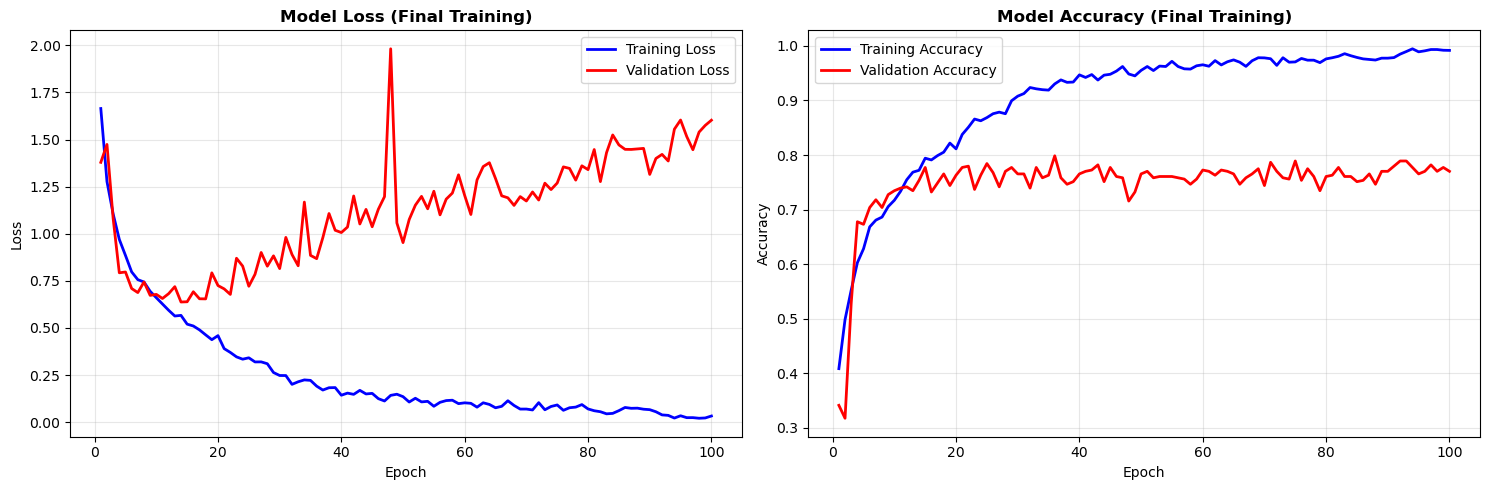


FINAL TRAINING METRICS (Epoch 100):
  Training Loss:      0.0327
  Training Accuracy:  0.9918
  Val Loss:          1.6024
  Val Accuracy:      0.7701
Evaluating final 4-cluster model on test data...
Making predictions on test data...

FINAL 4-CLUSTER MODEL TEST RESULTS

TEST SET PERFORMANCE:
  Balanced Accuracy: 0.7237
  Macro F1 Score:      0.7193
  Standard Accuracy:  0.7274

DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

   Cluster 0     0.7647    0.7400    0.7522       527
   Cluster 1     0.6438    0.6667    0.6550       366
   Cluster 2     0.7605    0.7622    0.7614       450
   Cluster 3     0.6923    0.7258    0.7087        62

    accuracy                         0.7274      1405
   macro avg     0.7153    0.7237    0.7193      1405
weighted avg     0.7287    0.7274    0.7279      1405


TEST SET DISTRIBUTION:
  Cluster 0: 527 true, 510 predicted
  Cluster 1: 366 true, 379 predicted
  Cluster 2: 450 true, 451 predicted
  Cluster 3: 62 

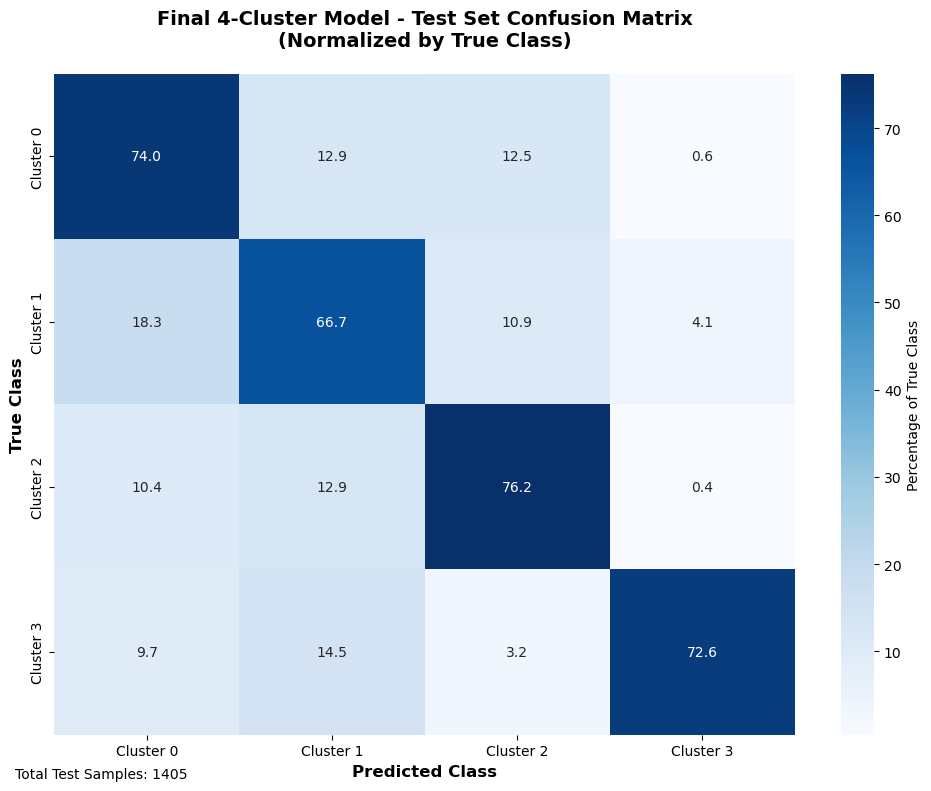


CONFUSION MATRIX SUMMARY:
  Cluster 0: 390/527 (74.0%)
  Cluster 1: 244/366 (66.7%)
  Cluster 2: 343/450 (76.2%)
  Cluster 3: 45/62 (72.6%)
Overall Accuracy: 72.7%

✅ Final 4-cluster model pipeline completed successfully!
📊 Final model trained on all balanced training data!
🎯 Evaluated on independent test set!
📈 Check plots and metrics above for performance assessment!


In [14]:
classifier = HeatmapCNNClassifier(data_dir="../Data")
classifier.run_final_4cluster_pipeline()

# save final model
final_model_path = os.path.join(classifier.data_dir, 'final_4cluster_model.h5')
classifier.final_model.save(final_model_path)

### SHAP analysis of final 4-cluster model

📁 Loading data and preprocessing...
Loading data assignments...
Train/test DataFrame shape: (5619, 3)
Clusters DataFrame shape: (5619, 2)
Train/test columns: ['Profile_id', 'data_type', 'CV_fold']
Clusters columns:  ['Profile_id', 'cluster']
Loaded assignments for 5619 profiles
Loaded cluster assignments for 5619 profiles
Sample train/test data for profile s033:  {'data_type': 'test', 'CV_fold': ''}
Sample cluster data for profile s033:  6
Loading heatmap images...
Found 5619 PNG files in ..\Data\heatmaps
Sample filenames: ['0000a_WMO5906623_recovery_profiles.png', '0002a_WMO5906623_recovery_profiles.png', '0003a_WMO5906623_recovery_profiles.png', '0003a_WMO6904139_recovery.png', '0004a_WMO6903096.png']
Sample extracted profile IDs: ['0000a_WMO5906623_recovery_profiles', '0002a_WMO5906623_recovery_profiles', '0003a_WMO5906623_recovery_profiles', '0003a_WMO6904139_recovery', '0004a_WMO6903096']
Available profile IDs from filenames: 5619
Profile IDs with train/test data: 5619
Profile IDs

🤖 Loading saved final model...
✅ Model loaded from: ..\Data\final_4cluster_model.h5
🚀 Starting ENHANCED SHAP analysis for ALL samples with automatic saving...
📁 Created save directory: ../Data\shap_results_20260106_111032
🧠 Setting up SHAP explainer with 200 background samples from ALL data...
✅ SHAP explainer setup completed with enhanced background!
📊 Calculating SHAP values for ALL samples with automatic saving...

🔍 Processing Cluster 0 (ALL SAMPLES)...
  📈 Calculating SHAP values for ALL 2108 samples...
  💾 Will save checkpoints every 10 batches
    Processing batch 1/43 (50 samples)...
      🔧 Fixing:  Extracting cluster 0 from last dimension
    Processing batch 2/43 (50 samples)...
      🔧 Fixing:  Extracting cluster 0 from last dimension
    Processing batch 3/43 (50 samples)...
      🔧 Fixing:  Extracting cluster 0 from last dimension
    Processing batch 4/43 (50 samples)...
      🔧 Fixing:  Extracting cluster 0 from last dimension
    Processing batch 5/43 (50 samples)...
 

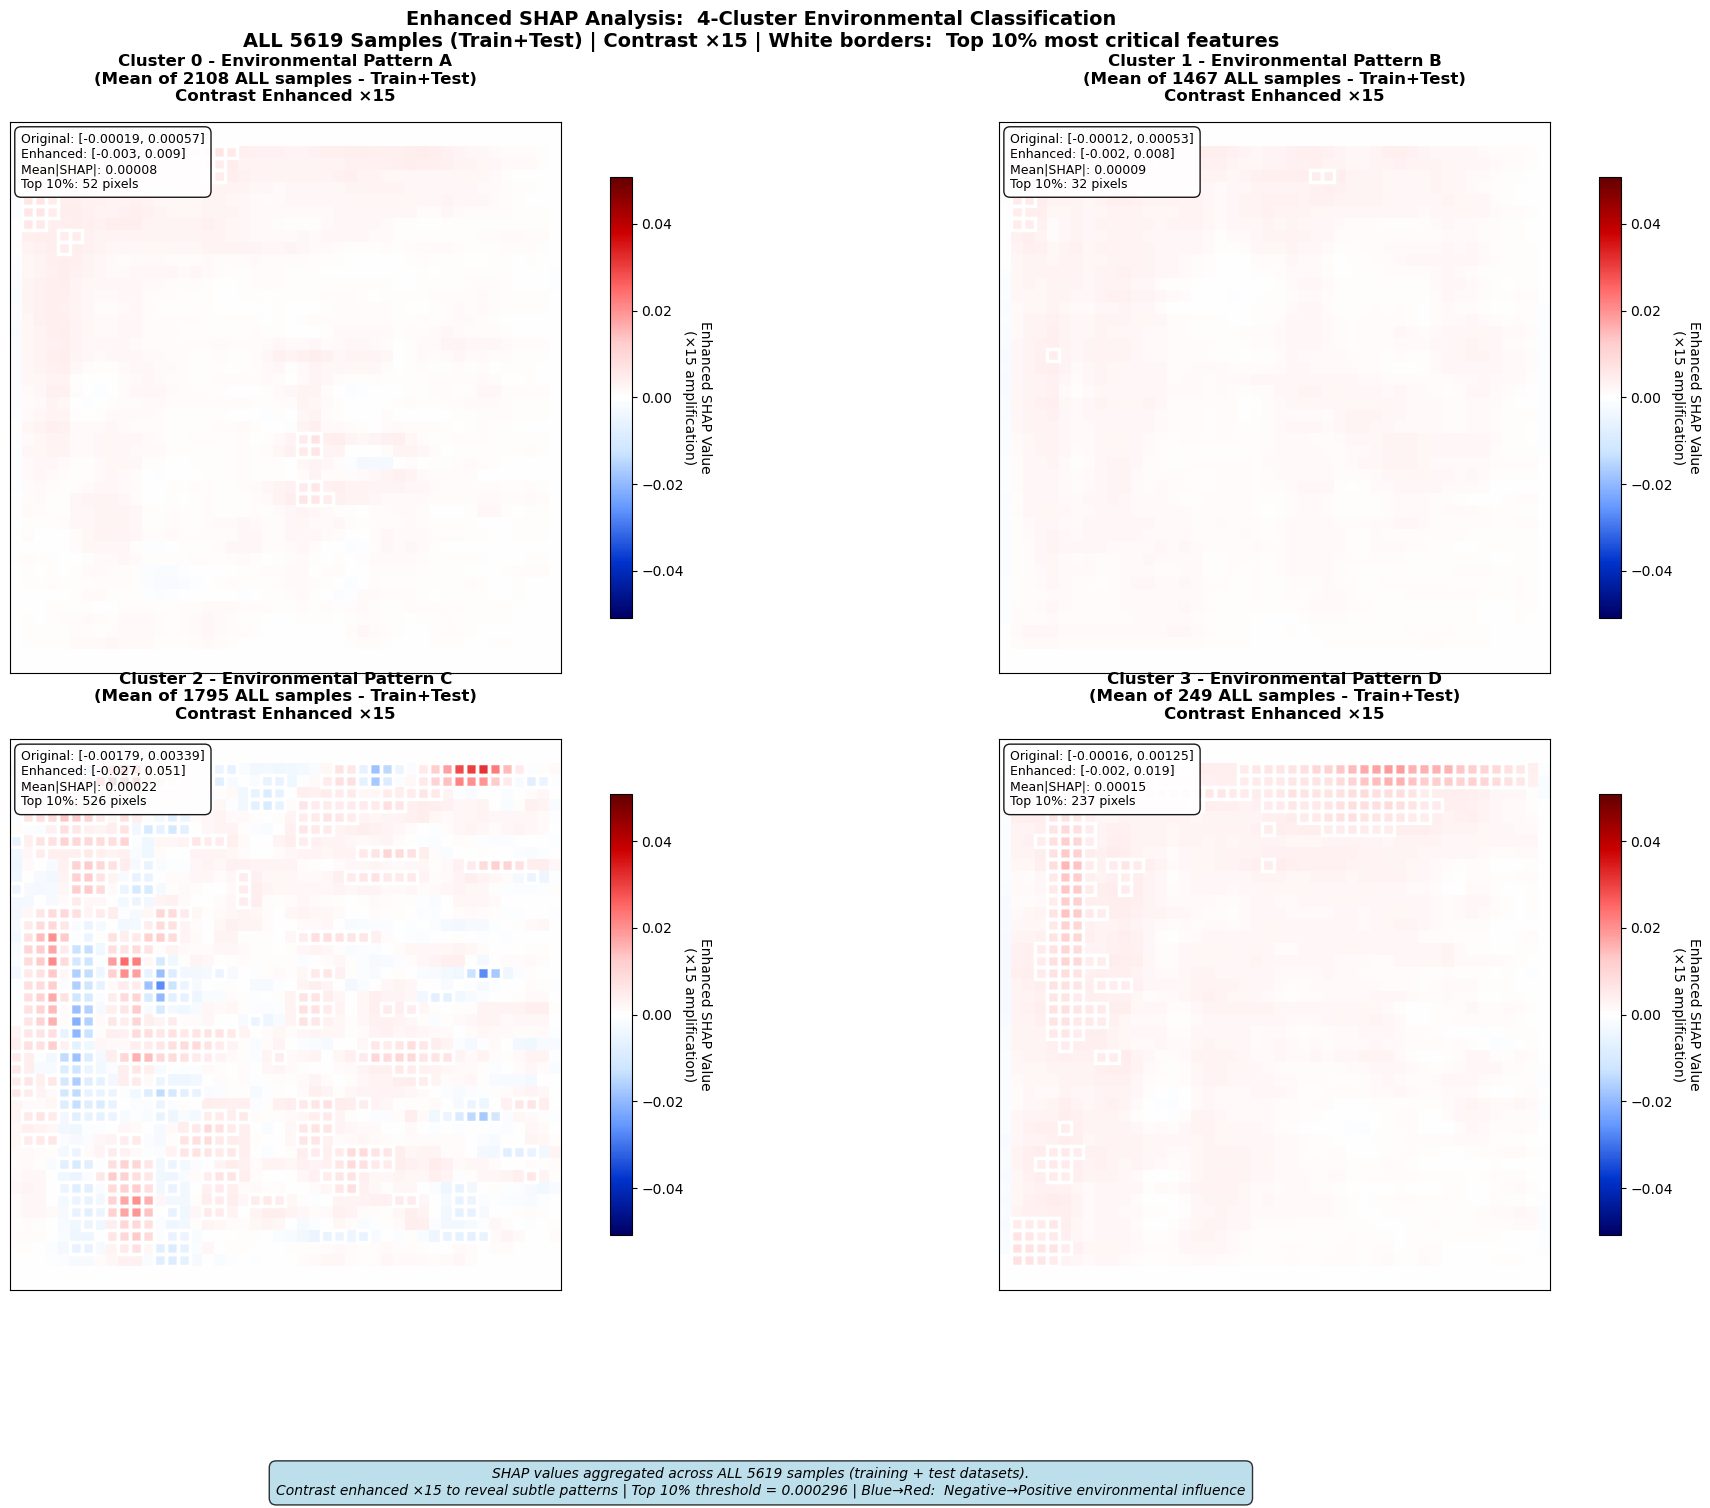


📊 ENHANCED SHAP ANALYSIS SUMMARY (ALL SAMPLES):

Cluster 0:
  Total samples analyzed: 2108 (Train + Test)
  Mean |SHAP|: 0.000084
  SHAP range: [-0.000190, 0.000567]
  Top 10% features: 212 pixels
  Max importance: 0.000567
  Shape: (46, 46)

Cluster 1:
  Total samples analyzed: 1467 (Train + Test)
  Mean |SHAP|: 0.000092
  SHAP range: [-0.000117, 0.000531]
  Top 10% features: 212 pixels
  Max importance: 0.000531
  Shape: (46, 46)

Cluster 2:
  Total samples analyzed: 1795 (Train + Test)
  Mean |SHAP|: 0.000219
  SHAP range: [-0.001785, 0.003386]
  Top 10% features: 212 pixels
  Max importance: 0.003386
  Shape: (46, 46)

Cluster 3:
  Total samples analyzed: 249 (Train + Test)
  Mean |SHAP|: 0.000146
  SHAP range: [-0.000158, 0.001254]
  Top 10% features: 212 pixels
  Max importance: 0.001254
  Shape: (46, 46)

✅ ENHANCED SHAP analysis completed!
📊 Successful clusters: 4/4
📈 Total samples analyzed: 5619 (Train + Test)
💾 All results saved in: ../Data\shap_results_20260106_111032
🎨 Hea

In [27]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import shap
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from sklearn.preprocessing import StandardScaler
from collections import Counter
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# COMPLETE SHAP ANALYSIS WITH ALL SAMPLES + AUTOMATIC SAVING
# ============================================================================

# Initialize classifier and load saved model
classifier = HeatmapCNNClassifier(data_dir="../Data")

# Load the necessary data and preprocessing
print("📁 Loading data and preprocessing...")
classifier.load_data_assignments()
classifier.load_heatmaps()
classifier.split_train_test()

# Load hierarchy info for 4-cluster analysis
print("🔗 Loading 4-cluster hierarchy information...")
with open("../Data/cnn_hierarchy_config.pkl", 'rb') as f:
    hierarchy_info = pickle.load(f)

# Convert 10-cluster labels to 4-cluster labels
def map_to_4clusters(y_fine, hierarchy_info):
    """Map 10-cluster labels to 4-cluster labels"""
    target_level = 'level_2_groups'  # 4 clusters
    hierarchy_mapping = hierarchy_info['level_mappings'][target_level]
    
    cluster_4_labels = []
    for label in y_fine:
        label_key = int(label) if hasattr(label, 'item') else label
        mapped_value = None
        for k, v in hierarchy_mapping.items():
            if int(k) == label_key:
                mapped_value = int(v)
                break
        if mapped_value is not None:
            cluster_4_labels.append(mapped_value)
        else:
            cluster_4_labels.append(0)
    return np.array(cluster_4_labels)

# Prepare 4-cluster labels for ALL data (train + test)
print("🔄 Converting labels to 4-cluster format for ALL samples...")
classifier.y_train_4cluster = map_to_4clusters(classifier.y_train, hierarchy_info)
classifier.y_test_4cluster = map_to_4clusters(classifier.y_test, hierarchy_info)

print(f"Training 4-cluster distribution: {Counter(classifier.y_train_4cluster)}")
print(f"Test 4-cluster distribution: {Counter(classifier.y_test_4cluster)}")

# Combine ALL data (train + test)
print("🔗 Combining train and test data...")
X_all = np.concatenate([classifier.X_train, classifier.X_test], axis=0)
y_all_4cluster = np.concatenate([classifier.y_train_4cluster, classifier.y_test_4cluster], axis=0)

print(f"Combined dataset shape: {X_all.shape}")
print(f"Combined 4-cluster distribution: {Counter(y_all_4cluster)}")

# Scale ALL data consistently
print("📏 Scaling ALL data...")
n_all_samples = X_all.shape[0]
X_all_reshaped = X_all.reshape(n_all_samples, -1)
scaler = StandardScaler()
# Fit scaler on training data only, then transform all data
X_train_reshaped = classifier.X_train.reshape(classifier.X_train.shape[0], -1)
scaler.fit(X_train_reshaped)
X_all_scaled = scaler.transform(X_all_reshaped)
X_all_final_scaled = X_all_scaled.reshape(X_all.shape)

# Load the saved final model
print("🤖 Loading saved final model...")
final_model_path = os.path.join(classifier.data_dir, 'final_4cluster_model.h5')
classifier.final_model = tf.keras.models.load_model(final_model_path)
print(f"✅ Model loaded from: {final_model_path}")

# ============================================================================
# ENHANCED SAVING FUNCTIONS
# ============================================================================

def create_save_directory():
    """Create timestamped save directory for SHAP results"""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_dir = os.path.join("../Data", f"shap_results_{timestamp}")
    os.makedirs(save_dir, exist_ok=True)
    
    print(f"📁 Created save directory: {save_dir}")
    return save_dir, timestamp

def save_batch_checkpoint(save_dir, cluster_id, batch_num, cluster_samples, 
                         partial_shap_values, metadata):
    """Save checkpoint every 10 batches"""
    checkpoint_data = {
        'cluster_id': cluster_id,
        'batch_num': batch_num,
        'cluster_samples': cluster_samples,
        'partial_shap_values': partial_shap_values,
        'metadata': metadata,
        'timestamp': datetime.now().isoformat()
    }
    
    checkpoint_file = os.path.join(save_dir, f'checkpoint_cluster_{cluster_id}_batch_{batch_num: 03d}.pkl')
    
    with open(checkpoint_file, 'wb') as f:
        pickle.dump(checkpoint_data, f, protocol=pickle.HIGHEST_PROTOCOL)
    
    file_size_mb = os.path.getsize(checkpoint_file) / 1024 / 1024
    print(f"    💾 Checkpoint saved: {checkpoint_file} ({file_size_mb:.1f} MB)")

def save_cluster_completion(save_dir, cluster_id, cluster_samples, cluster_shap_values):
    """Save complete cluster results"""
    cluster_data = {
        'cluster_id': cluster_id,
        'cluster_samples': cluster_samples,
        'cluster_shap_values':  cluster_shap_values,
        'completion_timestamp': datetime.now().isoformat(),
        'shape':  cluster_shap_values.shape,
        'value_range': [cluster_shap_values.min(), cluster_shap_values.max()],
        'n_samples': len(cluster_samples)
    }
    
    cluster_file = os.path.join(save_dir, f'cluster_{cluster_id}_complete.pkl')
    
    with open(cluster_file, 'wb') as f:
        pickle.dump(cluster_data, f, protocol=pickle.HIGHEST_PROTOCOL)
    
    file_size_mb = os.path.getsize(cluster_file) / 1024 / 1024
    print(f"  ✅ Cluster {cluster_id} complete data saved: {cluster_file} ({file_size_mb:.1f} MB)")

def save_final_results(save_dir, timestamp, all_cluster_samples, all_cluster_shap_values, 
                      aggregated_shap_values):
    """Save final comprehensive results"""
    print("\n💾 Saving final comprehensive SHAP results...")
    
    # Prepare metadata
    metadata = {
        'timestamp': timestamp,
        'completion_time': datetime.now().isoformat(),
        'total_samples':  sum(len(samples) for samples in all_cluster_samples.values()),
        'cluster_sample_counts': {cid: len(samples) for cid, samples in all_cluster_samples.items()},
        'cluster_shap_shapes': {cid: shap_vals.shape for cid, shap_vals in all_cluster_shap_values.items()},
        'aggregated_shapes': {cid: agg_vals.shape for cid, agg_vals in aggregated_shap_values.items()},
        'value_ranges': {
            'raw':  {cid: [vals.min(), vals.max()] for cid, vals in all_cluster_shap_values.items()},
            'aggregated': {cid: [vals.min(), vals.max()] for cid, vals in aggregated_shap_values.items()}
        }
    }
    
    # Save main results
    main_results = {
        'metadata': metadata,
        'cluster_samples': all_cluster_samples,
        'cluster_shap_values': all_cluster_shap_values,
        'aggregated_shap_values': aggregated_shap_values
    }
    
    main_file = os.path.join(save_dir, f'complete_shap_results_{timestamp}.pkl')
    with open(main_file, 'wb') as f:
        pickle.dump(main_results, f, protocol=pickle.HIGHEST_PROTOCOL)
    
    # Save aggregated values separately (for quick loading)
    aggregated_file = os.path.join(save_dir, f'aggregated_shap_only_{timestamp}.pkl')
    with open(aggregated_file, 'wb') as f:
        pickle.dump(aggregated_shap_values, f, protocol=pickle.HIGHEST_PROTOCOL)
    
    # Save human-readable summary
    summary_file = os.path.join(save_dir, f'shap_analysis_summary_{timestamp}.txt')
    with open(summary_file, 'w') as f:
        f.write("ENHANCED SHAP ANALYSIS RESULTS SUMMARY\n")
        f.write("=" * 60 + "\n")
        f.write(f"Analysis Timestamp: {timestamp}\n")
        f.write(f"Completion Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Total Samples Analyzed: {metadata['total_samples']}\n\n")
        
        f.write("CLUSTER BREAKDOWN:\n")
        for cid in range(4):
            if cid in metadata['cluster_sample_counts']: 
                n_samples = metadata['cluster_sample_counts'][cid]
                shap_shape = metadata['cluster_shap_shapes'][cid]
                agg_shape = metadata['aggregated_shapes'][cid]
                val_range = metadata['value_ranges']['aggregated'][cid]
                
                f.write(f"  Cluster {cid}:\n")
                f.write(f"    Samples: {n_samples}\n")
                f.write(f"    Raw SHAP shape: {shap_shape}\n")
                f.write(f"    Aggregated shape: {agg_shape}\n")
                f.write(f"    Value range: [{val_range[0]:.6f}, {val_range[1]:.6f}]\n")
            else:
                f.write(f"  Cluster {cid}: No data\n")
        
        f.write(f"\nFILES SAVED:\n")
        f.write(f"  Complete results: {main_file}\n")
        f.write(f"  Aggregated only: {aggregated_file}\n")
        f.write(f"  Summary: {summary_file}\n")
        f.write(f"  Directory: {save_dir}\n")
    
    # Calculate file sizes
    main_size = os.path.getsize(main_file) / 1024 / 1024
    agg_size = os.path.getsize(aggregated_file) / 1024 / 1024
    
    print(f"  📄 Complete results:  {main_file} ({main_size:.1f} MB)")
    print(f"  📊 Aggregated only: {aggregated_file} ({agg_size:.1f} MB)")
    print(f"  📝 Summary: {summary_file}")
    print(f"  💽 Total size: {main_size + agg_size:.1f} MB")
    
    return main_file, aggregated_file, summary_file

# ============================================================================
# ENHANCED SHAP ANALYSIS FUNCTIONS WITH SAVING
# ============================================================================

def setup_shap_explainer_all_data(classifier, X_all_final_scaled, background_samples=200):
    """Setup SHAP explainer using samples from all data"""
    print(f"🧠 Setting up SHAP explainer with {background_samples} background samples from ALL data...")
    
    # Select background samples from all available data
    np.random.seed(42)
    background_indices = np.random.choice(
        len(X_all_final_scaled), 
        size=min(background_samples, len(X_all_final_scaled)), 
        replace=False
    )
    
    background_data = X_all_final_scaled[background_indices]
    explainer = shap.DeepExplainer(classifier.final_model, background_data)
    
    print("✅ SHAP explainer setup completed with enhanced background!")
    return explainer

def calculate_all_samples_shap_values_with_saving(explainer, X_all_final_scaled, y_all_4cluster, save_dir):
    """Calculate SHAP values for ALL samples with automatic saving every 10 batches"""
    print("📊 Calculating SHAP values for ALL samples with automatic saving...")
    
    all_cluster_samples = {}
    all_cluster_shap_values = {}
    save_interval = 10  # Save every 10 batches
    
    for cluster_id in range(4):
        print(f"\n🔍 Processing Cluster {cluster_id} (ALL SAMPLES)...")
        
        # Find ALL samples for this cluster (train + test)
        cluster_mask = y_all_4cluster == cluster_id
        cluster_indices = np.where(cluster_mask)[0]
        
        if len(cluster_indices) == 0:
            print(f"  ⚠️ No samples found for Cluster {cluster_id}")
            continue
        
        # Use ALL samples for this cluster
        n_samples = len(cluster_indices)
        all_cluster_samples[cluster_id] = X_all_final_scaled[cluster_indices]
        
        print(f"  📈 Calculating SHAP values for ALL {n_samples} samples...")
        print(f"  💾 Will save checkpoints every {save_interval} batches")
        
        # Process in batches to manage memory
        batch_size = 50
        all_shap_values = []
        
        total_batches = (n_samples - 1) // batch_size + 1
        
        for i in range(0, n_samples, batch_size):
            batch_end = min(i + batch_size, n_samples)
            batch_samples = all_cluster_samples[cluster_id][i:batch_end]
            batch_number = i // batch_size + 1
            
            print(f"    Processing batch {batch_number}/{total_batches} ({len(batch_samples)} samples)...")
            
            # Calculate SHAP values for this batch
            batch_shap_values = explainer.shap_values(batch_samples)
            
            # Handle multi-output format
            if isinstance(batch_shap_values, list):
                batch_shap_target = batch_shap_values[cluster_id]
            else:  
                batch_shap_target = batch_shap_values
            
            # Fix shape if needed
            expected_batch_shape = (len(batch_samples), 46, 46, 3)
            if batch_shap_target.shape != expected_batch_shape:
                if batch_shap_target.shape == (len(batch_samples), 46, 46, 3, 4):
                    print(f"      🔧 Fixing:  Extracting cluster {cluster_id} from last dimension")
                    batch_shap_target = batch_shap_target[:, :, :, : , cluster_id]
                else:  
                    print(f"      ❌ Cannot fix shape {batch_shap_target.shape}")
                    continue
            
            all_shap_values.append(batch_shap_target)
            
            # Save checkpoint every 10 batches
            if batch_number % save_interval == 0 or batch_number == total_batches: 
                # Concatenate current progress
                current_shap_values = np.concatenate(all_shap_values, axis=0)
                
                metadata = {
                    'cluster_id': cluster_id,
                    'total_batches': total_batches,
                    'completed_batches': batch_number,
                    'samples_processed': current_shap_values.shape[0],
                    'total_samples': n_samples,
                    'progress_percent': (batch_number / total_batches) * 100,
                    'current_shape': current_shap_values.shape,
                    'value_range': [current_shap_values.min(), current_shap_values.max()]
                }
                
                save_batch_checkpoint(
                    save_dir, cluster_id, batch_number, 
                    all_cluster_samples[cluster_id][: current_shap_values.shape[0]], 
                    current_shap_values, metadata
                )
        
        if all_shap_values:
            # Concatenate all batches for final cluster result
            all_cluster_shap_values[cluster_id] = np.concatenate(all_shap_values, axis=0)
            
            final_shape = all_cluster_shap_values[cluster_id].shape
            print(f"  ✅ Final SHAP values shape: {final_shape}")
            print(f"  📊 SHAP value range: [{all_cluster_shap_values[cluster_id].min():.6f}, {all_cluster_shap_values[cluster_id].max():.6f}]")
            
            # Save complete cluster data
            save_cluster_completion(save_dir, cluster_id, all_cluster_samples[cluster_id], all_cluster_shap_values[cluster_id])
        else:
            print(f"  ❌ No valid SHAP values computed for cluster {cluster_id}")
    
    return all_cluster_samples, all_cluster_shap_values

def aggregate_all_samples_shap_values(all_cluster_shap_values):
    """Aggregate SHAP values across ALL samples for each cluster"""
    print("\n📈 Aggregating SHAP values across ALL samples (train + test)...")
    
    aggregated_shap_values = {}
    
    for cluster_id in range(4):
        if cluster_id not in all_cluster_shap_values:
            print(f"Cluster {cluster_id}:  No SHAP values available")
            continue
            
        shap_vals = all_cluster_shap_values[cluster_id]
        print(f"\nCluster {cluster_id}:")
        print(f"  Input SHAP shape: {shap_vals.shape}")
        
        # Aggregate across samples (axis=0)
        if shap_vals.ndim == 4 and shap_vals.shape[1: ] == (46, 46, 3):
            aggregated = np.mean(shap_vals, axis=0)
            print(f"  ✅ Aggregated across {shap_vals.shape[0]} samples")
        else:
            print(f"  ❌ Unexpected shape: {shap_vals.shape}")
            continue
        
        aggregated_shap_values[cluster_id] = aggregated
        
        print(f"  Final aggregated shape: {aggregated.shape}")
        print(f"  SHAP value range: [{aggregated.min():.6f}, {aggregated.max():.6f}]")
        print(f"  Mean absolute SHAP: {np.abs(aggregated).mean():.6f}")
    
    return aggregated_shap_values

def create_enhanced_oceanographic_colormap():
    """Create enhanced oceanographic SHAP colormap with better contrast"""
    colors = [
        '#000066',  # Deep navy (strong negative)
        '#0033CC',  # Strong blue
        '#6699FF',  # Medium blue  
        '#CCE5FF',  # Light blue
        '#FFFFFF',  # White (neutral)
        '#FFCCCC',  # Light red
        '#FF6666',  # Medium red
        '#CC0000',  # Strong red
        '#660000'   # Deep maroon (strong positive)
    ]
    return LinearSegmentedColormap.from_list('enhanced_ocean_shap', colors, N=256)

def plot_enhanced_contrast_shap_heatmaps(aggregated_shap_values, all_cluster_samples, 
                                       contrast_multiplier=10, highlight_percentile=90, 
                                       figsize=(20, 16), save_plots=True):
    """Plot contrast-enhanced SHAP heatmaps highlighting top 10% most important regions"""
    
    print(f"🎨 Creating CONTRAST-ENHANCED SHAP heatmaps (highlighting top {100-highlight_percentile}%)...")
    
    # Create enhanced colormap
    enhanced_cmap = create_enhanced_oceanographic_colormap()
    
    # Prepare data (use mean across RGB channels)
    plot_data = {}
    enhanced_data = {}
    all_abs_values = []
    
    for cluster_id in range(4):
        if cluster_id not in aggregated_shap_values:
            continue
            
        shap_heatmap = aggregated_shap_values[cluster_id]
        
        # Convert RGB to grayscale by averaging channels
        if shap_heatmap.shape[-1] == 3:
            original_2d = np.mean(shap_heatmap, axis=-1)
        else:
            original_2d = shap_heatmap.squeeze()
        
        # Apply contrast enhancement
        enhanced_2d = original_2d * contrast_multiplier
        
        plot_data[cluster_id] = original_2d
        enhanced_data[cluster_id] = enhanced_2d
        
        # Collect absolute values for threshold calculation
        all_abs_values.extend(np.abs(original_2d).flatten())
    
    # Calculate threshold for top 10% highlighting
    if len(all_abs_values) == 0:
        print("❌ No SHAP data available!")
        return {}
    
    threshold = np.percentile(all_abs_values, highlight_percentile)
    print(f"📊 Highlighting threshold (top {100-highlight_percentile}%): {threshold:.6f}")
    
    # Determine enhanced color scale
    all_enhanced_values = np.concatenate([data.flatten() for data in enhanced_data.values()])
    finite_values = all_enhanced_values[np.isfinite(all_enhanced_values)]
    abs_max = np.abs(finite_values).max() if len(finite_values) > 0 else 1
    vmin, vmax = -abs_max, abs_max
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()
    
    cluster_names = [
        'Cluster 0 - Environmental Pattern A',
        'Cluster 1 - Environmental Pattern B', 
        'Cluster 2 - Environmental Pattern C',
        'Cluster 3 - Environmental Pattern D'
    ]
    
    for cluster_id in range(4):
        ax = axes[cluster_id]
        
        if cluster_id in enhanced_data:
            original_data = plot_data[cluster_id]
            enhanced = enhanced_data[cluster_id]
            
            # Create enhanced heatmap
            im = ax.imshow(enhanced, cmap=enhanced_cmap, vmin=vmin, vmax=vmax, 
                         aspect='equal', origin='upper')
            
            # Add colorbar
            cbar = plt.colorbar(im, ax=ax, shrink=0.8)
            cbar.set_label(f'Enhanced SHAP Value\n(×{contrast_multiplier} amplification)', 
                          rotation=270, labelpad=20)
            
            # Highlight top 10% most important pixels (based on original values)
            highlight_mask = np.abs(original_data) > threshold
            
            if highlight_mask.any():
                rows, cols = np.where(highlight_mask)
                
                # Add white borders for highlighting
                for r, c in zip(rows, cols):
                    rect = Rectangle(
                        (c-0.5, r-0.5), 1, 1, 
                        fill=False, 
                        edgecolor='white',
                        linewidth=2.5,
                        clip_on=False
                    )
                    ax.add_patch(rect)
                
                n_highlighted = len(rows)
                percent_highlighted = (n_highlighted / original_data.size) * 100
                
                print(f"Cluster {cluster_id}:  {n_highlighted} pixels highlighted ({percent_highlighted:.1f}%)")
            
            # Add enhanced statistics
            original_min, original_max = original_data.min(), original_data.max()
            enhanced_min, enhanced_max = enhanced.min(), enhanced.max()
            mean_abs_original = np.abs(original_data).mean()
            n_above_threshold = np.sum(np.abs(original_data) > threshold)
            
            stats_text = (f'Original: [{original_min:.5f}, {original_max:.5f}]\n'
                        f'Enhanced: [{enhanced_min:.3f}, {enhanced_max:.3f}]\n'
                        f'Mean|SHAP|: {mean_abs_original:.5f}\n'
                        f'Top 10%: {n_above_threshold} pixels')
            
            ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
                   fontsize=9, verticalalignment='top',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9))
            
            # Title with enhanced sample count
            n_samples = len(all_cluster_samples.get(cluster_id, []))
            ax.set_title(f'{cluster_names[cluster_id]}\n'
                        f'(Mean of {n_samples} ALL samples - Train+Test)\n'
                        f'Contrast Enhanced ×{contrast_multiplier}', 
                        fontsize=12, fontweight='bold', pad=15)
        else:
            ax.text(0.5, 0.5, f'No data for\n{cluster_names[cluster_id]}',
                   transform=ax.transAxes, ha='center', va='center',
                   fontsize=14, fontweight='bold')
            ax.set_title(cluster_names[cluster_id], fontsize=12, fontweight='bold')
        
        ax.set_xticks([])
        ax.set_yticks([])
    
    # Enhanced main title
    n_clusters_with_data = len(enhanced_data)
    total_samples = sum(len(all_cluster_samples.get(i, [])) for i in range(4))
    
    suptitle = (f'Enhanced SHAP Analysis:  4-Cluster Environmental Classification\n'
               f'ALL {total_samples} Samples (Train+Test) | Contrast ×{contrast_multiplier} | '
               f'White borders:  Top {100-highlight_percentile}% most critical features')
    
    fig.suptitle(suptitle, fontsize=14, fontweight='bold', y=0.95)
    
    # Enhanced methodology explanation
    method_text = (
        f"SHAP values aggregated across ALL {total_samples} samples (training + test datasets).\n"
        f"Contrast enhanced ×{contrast_multiplier} to reveal subtle patterns | "
        f"Top {100-highlight_percentile}% threshold = {threshold:.6f} | "
        f"Blue→Red:  Negative→Positive environmental influence"
    )
    
    fig.text(0.5, 0.02, method_text, ha='center', va='bottom', 
            fontsize=10, style='italic',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8))
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.88, bottom=0.15)
    
    if save_plots:
        filename = f'enhanced_4cluster_shap_ALL_SAMPLES_contrast{contrast_multiplier}_top{100-highlight_percentile}pct.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"💾 Enhanced plot saved as:  {filename}")
    
    plt.show()
    
    return enhanced_data

# ============================================================================
# MAIN EXECUTION WITH COMPREHENSIVE SAVING
# ============================================================================

print("🚀 Starting ENHANCED SHAP analysis for ALL samples with automatic saving...")

# Create save directory with timestamp
save_dir, timestamp = create_save_directory()

try:
    # Step 1: Setup enhanced SHAP explainer with more background samples
    explainer = setup_shap_explainer_all_data(classifier, X_all_final_scaled, background_samples=200)

    # Step 2: Calculate SHAP values for ALL samples in each cluster WITH SAVING
    all_cluster_samples, all_cluster_shap_values = calculate_all_samples_shap_values_with_saving(
        explainer, X_all_final_scaled, y_all_4cluster, save_dir
    )

    # Step 3: Aggregate SHAP values across ALL samples
    aggregated_shap_values = aggregate_all_samples_shap_values(all_cluster_shap_values)

    # Step 4: Save final comprehensive results
    final_files = save_final_results(save_dir, timestamp, all_cluster_samples, 
                                   all_cluster_shap_values, aggregated_shap_values)

    # Step 5: Create enhanced contrast heatmaps highlighting top 10%
    print(f"\n🎨 Creating final visualization...")
    enhanced_plot_data = plot_enhanced_contrast_shap_heatmaps(
        aggregated_shap_values, 
        all_cluster_samples,
        contrast_multiplier=15,     # 15x contrast enhancement
        highlight_percentile=90,    # Top 10% most important pixels
        figsize=(20, 16),
        save_plots=True
    )

except Exception as e:
    print(f"\n❌ Error occurred during SHAP analysis: {str(e)}")
    print(f"💾 Partial results may be saved in: {save_dir}")
    print("🔄 You can recover from the most recent checkpoint")
    raise

# ============================================================================
# COMPREHENSIVE RESULTS SUMMARY
# ============================================================================

print("\n📊 ENHANCED SHAP ANALYSIS SUMMARY (ALL SAMPLES):")
print("=" * 70)

total_samples_analyzed = 0
successful_clusters = 0

for cluster_id in range(4):
    if cluster_id in aggregated_shap_values: 
        shap_data = aggregated_shap_values[cluster_id]
        if shap_data.shape[-1] == 3:
            shap_summary = np.mean(shap_data, axis=-1)
        else:
            shap_summary = shap_data.squeeze()
        
        n_samples = len(all_cluster_samples.get(cluster_id, []))
        total_samples_analyzed += n_samples
        successful_clusters += 1
        abs_mean = np.abs(shap_summary).mean()
        shap_range = [shap_summary.min(), shap_summary.max()]
        
        # Calculate statistics for top features
        abs_shap = np.abs(shap_summary)
        top_10_threshold = np.percentile(abs_shap.flatten(), 90)
        n_top_features = np.sum(abs_shap > top_10_threshold)
        
        print(f"\nCluster {cluster_id}:")
        print(f"  Total samples analyzed: {n_samples} (Train + Test)")
        print(f"  Mean |SHAP|: {abs_mean:.6f}")
        print(f"  SHAP range: [{shap_range[0]:.6f}, {shap_range[1]:.6f}]")
        print(f"  Top 10% features: {n_top_features} pixels")
        print(f"  Max importance: {abs_shap.max():.6f}")
        print(f"  Shape: {shap_summary.shape}")
    else:
        print(f"\nCluster {cluster_id}:  ❌ FAILED - No valid SHAP values")

print(f"\n✅ ENHANCED SHAP analysis completed!")
print(f"📊 Successful clusters: {successful_clusters}/4")
print(f"📈 Total samples analyzed: {total_samples_analyzed} (Train + Test)")
print(f"💾 All results saved in: {save_dir}")
print(f"🎨 Heatmaps show contrast-enhanced SHAP patterns")
print(f"🔍 White borders highlight TOP 10% most critical environmental features")
print(f"🌊 Analysis reveals environmental patterns distinguishing ocean clusters")

print(f"\n📁 SAVED FILES SUMMARY:")
print(f"  📂 Main directory: {save_dir}")
print(f"  💾 Complete results: complete_shap_results_{timestamp}.pkl")
print(f"  📊 Quick access: aggregated_shap_only_{timestamp}.pkl") 
print(f"  📝 Human summary: shap_analysis_summary_{timestamp}.txt")
print(f"  🔄 Checkpoints: checkpoint_cluster_*_batch_*.pkl")
print(f"  ✅ Cluster completions: cluster_*_complete.pkl")

🎨 SHAP Visualization with Configurable Parameters
📊 Configuration:
  • Top pixels to analyze: 20
  • Highlight percentile: 95% (top 5%)
  • Subsample size: All samples
  • Stats box position: bottom_right
  • Figure size: (20, 10)
  • DPI: 300
📁 Loading SHAP results from:  ../Data\shap_results_20260106_111032
📊 Aggregated file: aggregated_shap_only_20260106_111032.pkl
💾 Complete file: complete_shap_results_20260106_111032.pkl
✅ Loaded SHAP results for 4 clusters
📈 Total samples: 5619
📊 Using ALL samples for display

🚀 Creating enhanced visualizations...
📊 Using original aggregated SHAP values (computed from ALL samples)
🎨 Creating cluster-specific visualizations...
  📊 Highlight threshold: Top 5% (percentile 95)
  📈 Using pre-computed aggregated SHAP values (from all samples)
Cluster 0: Mean|SHAP|=0.000084, Max=0.000567
Cluster 1: Mean|SHAP|=0.000092, Max=0.000531
Cluster 2: Mean|SHAP|=0.000219, Max=0.003386
Cluster 3: Mean|SHAP|=0.000146, Max=0.001254
  Cluster 0:  weak signal, using 

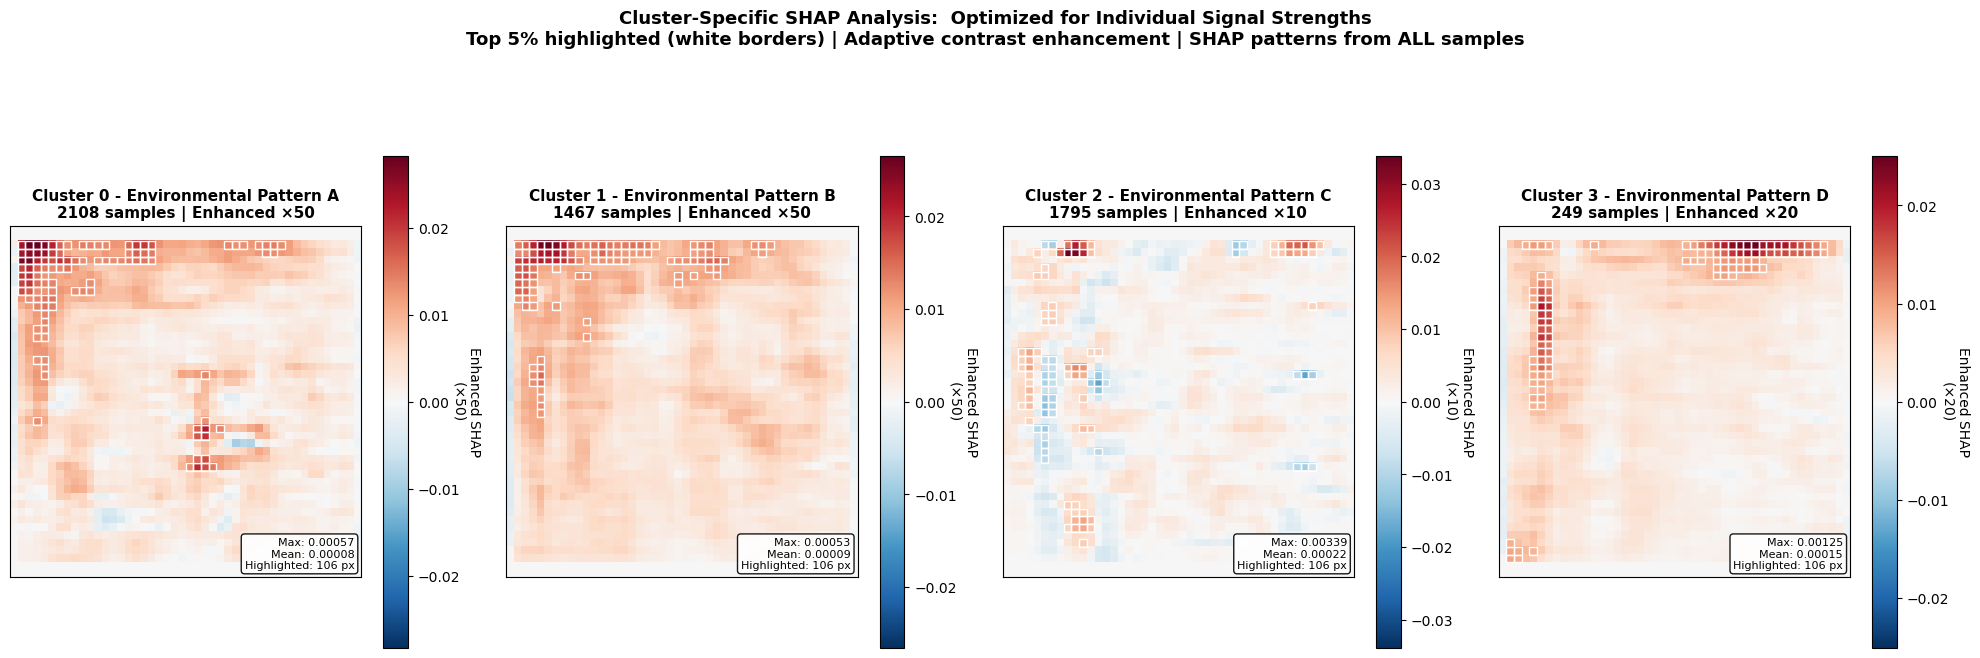

📊 Creating comparative importance analysis...
💾 Comparative analysis saved: comparative_importance_analysis_20260106_111032_allsamples_top5pct.png


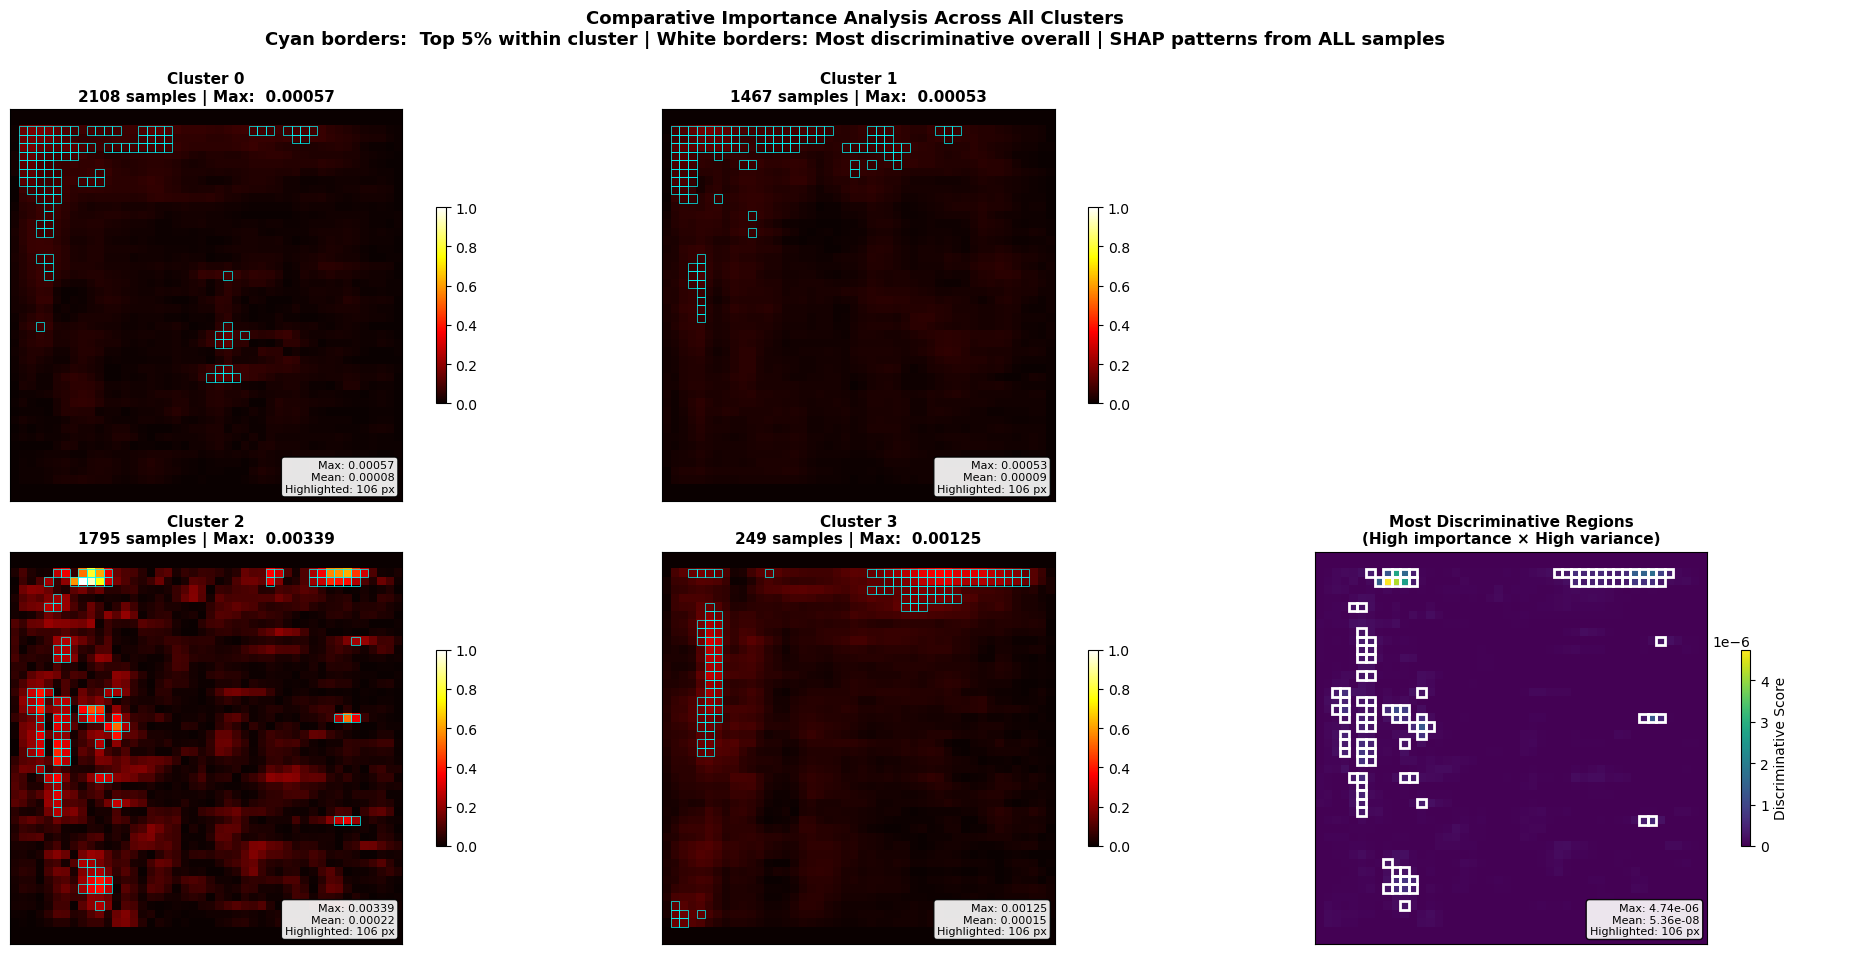


✅ Enhanced visualizations completed!
🎨 Created 2 comprehensive analysis plots:
  1. Cluster-specific optimized heatmaps (single row)
  2. Comparative analysis (2x3 grid, properly filled)
📊 All visualizations use SHAP patterns computed from complete dataset


In [46]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from scipy import ndimage
import seaborn as sns

# ============================================================================
# CONFIGURABLE PARAMETERS - ADJUST HERE
# ============================================================================

# Analysis Parameters
TOP_N_PIXELS = 20              # Number of top pixels to analyze per cluster
HIGHLIGHT_PERCENTILE = 95      # Percentile for highlighting (95 = top 5 %)
SUBSAMPLE_SIZE = None          # Number of samples to randomly subsample per cluster (None = use all)

# Visualization Parameters  
FIGURE_SIZE = (20, 10)         # Size of the main figure
DPI = 300                      # Resolution for saved plots
CONTRAST_MULTIPLIERS = {       # Contrast enhancement per cluster type
    'weak': 50,                # For clusters with very low SHAP values
    'medium':  20,              # For clusters with medium SHAP values  
    'strong': 10               # For clusters with strong SHAP values
}
WEAK_SIGNAL_THRESHOLD = 0.0001 # Threshold to classify as weak signal
MEDIUM_SIGNAL_THRESHOLD = 0.0002 # Threshold to classify as medium signal

# Layout Parameters
STATS_BOX_POSITION = 'bottom_right'  # Position for statistics box
COLORBAR_SHRINK = 0.5               # Size of colorbars
FONT_SIZES = {
    'title': 11,
    'subtitle': 9,
    'stats': 8,
    'suptitle': 13
}

# ============================================================================
# LOAD SAVED SHAP RESULTS
# ============================================================================

def load_latest_shap_results(save_dir="../Data"):
    """Load the most recent SHAP results"""
    from glob import glob
    
    # Find all SHAP result directories
    pattern = os.path.join(save_dir, "shap_results_*")
    shap_dirs = glob(pattern)
    
    if not shap_dirs:
        print("❌ No saved SHAP results found!")
        return None, None, None, None
    
    # Get the most recent directory
    latest_dir = max(shap_dirs, key=os.path.getctime)
    
    # Find the aggregated results file in that directory
    agg_files = glob(os.path.join(latest_dir, "aggregated_shap_only_*.pkl"))
    complete_files = glob(os.path.join(latest_dir, "complete_shap_results_*.pkl"))
    
    if not agg_files or not complete_files: 
        print("❌ SHAP files not found in directory!")
        return None, None, None, None
    
    agg_file = agg_files[0]
    complete_file = complete_files[0]
    
    print(f"📁 Loading SHAP results from:  {latest_dir}")
    print(f"📊 Aggregated file: {os.path.basename(agg_file)}")
    print(f"💾 Complete file: {os. path.basename(complete_file)}")
    
    # Load aggregated results
    with open(agg_file, 'rb') as f:
        aggregated_shap_values = pickle.load(f)
    
    # Load complete results  
    with open(complete_file, 'rb') as f:
        complete_results = pickle.load(f)
    
    all_cluster_samples = complete_results['cluster_samples']
    all_cluster_shap_values = complete_results['cluster_shap_values']
    metadata = complete_results['metadata']
    
    print(f"✅ Loaded SHAP results for {len(aggregated_shap_values)} clusters")
    print(f"📈 Total samples: {metadata['total_samples']}")
    
    return all_cluster_samples, all_cluster_shap_values, aggregated_shap_values, metadata

def get_display_sample_counts(all_cluster_samples, subsample_size):
    """Get sample counts for display (subsampled or full)"""
    
    display_counts = {}
    
    if subsample_size is None: 
        print("📊 Using ALL samples for display")
        for cluster_id, samples in all_cluster_samples.items():
            display_counts[cluster_id] = len(samples)
    else:
        print(f"🎲 Display counts based on {subsample_size} subsample per cluster")
        np.random.seed(42)  # For reproducible display
        
        for cluster_id, samples in all_cluster_samples.items():
            n_available = len(samples)
            n_display = min(subsample_size, n_available)
            display_counts[cluster_id] = n_display
            
            if n_display < n_available:
                print(f"  Cluster {cluster_id}: showing {n_display}/{n_available} samples")
            else:
                print(f"  Cluster {cluster_id}:  showing all {n_available} samples")
    
    return display_counts

# ============================================================================
# ENHANCED VISUALIZATION FUNCTIONS
# ============================================================================

def add_stats_box(ax, stats_dict, position='bottom_right'):
    """Add statistics box to plot"""
    
    stats_text = '\n'.join([f'{key}: {value}' for key, value in stats_dict.items()])
    
    # Determine position
    if position == 'bottom_right':
        x, y = 0.98, 0.02
        ha, va = 'right', 'bottom'
    elif position == 'top_right':
        x, y = 0.98, 0.98  
        ha, va = 'right', 'top'
    elif position == 'bottom_left':  
        x, y = 0.02, 0.02
        ha, va = 'left', 'bottom'
    else:  # top_left
        x, y = 0.02, 0.98
        ha, va = 'left', 'top'
    
    ax.text(x, y, stats_text, transform=ax.transAxes, fontsize=FONT_SIZES['stats'],
           horizontalalignment=ha, verticalalignment=va,
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))

def create_cluster_specific_visualizations(aggregated_shap_values, display_counts, metadata):
    """Create optimized visualizations for each cluster"""
    
    print(f"🎨 Creating cluster-specific visualizations...")
    print(f"  📊 Highlight threshold: Top {100-HIGHLIGHT_PERCENTILE}% (percentile {HIGHLIGHT_PERCENTILE})")
    print(f"  📈 Using pre-computed aggregated SHAP values (from all samples)")
    
    # Analyze signal strength per cluster
    cluster_stats = {}
    for cluster_id, shap_data in aggregated_shap_values.items():
        shap_2d = np.mean(shap_data, axis=-1) if shap_data.shape[-1] == 3 else shap_data.squeeze()
        
        cluster_stats[cluster_id] = {
            'mean_abs':  np.abs(shap_2d).mean(),
            'max_abs': np.abs(shap_2d).max(),
            'std':  np.abs(shap_2d).std(),
            'range': [shap_2d.min(), shap_2d.max()],
            'data':  shap_2d
        }
        
        print(f"Cluster {cluster_id}: Mean|SHAP|={cluster_stats[cluster_id]['mean_abs']:.6f}, "
              f"Max={cluster_stats[cluster_id]['max_abs']:.6f}")
    
    # Create single row of cluster visualizations  
    fig, axes = plt.subplots(1, 4, figsize=FIGURE_SIZE)
    
    cluster_names = [
        'Cluster 0 - Environmental Pattern A',
        'Cluster 1 - Environmental Pattern B', 
        'Cluster 2 - Environmental Pattern C',
        'Cluster 3 - Environmental Pattern D'
    ]
    
    for cluster_id in range(4):
        if cluster_id not in cluster_stats:
            continue
            
        ax = axes[cluster_id]
        stats = cluster_stats[cluster_id]
        shap_2d = stats['data']
        
        # Determine contrast multiplier based on signal strength
        if stats['mean_abs'] < WEAK_SIGNAL_THRESHOLD:
            contrast_multiplier = CONTRAST_MULTIPLIERS['weak']
            signal_type = 'weak'
        elif stats['mean_abs'] < MEDIUM_SIGNAL_THRESHOLD:  
            contrast_multiplier = CONTRAST_MULTIPLIERS['medium']
            signal_type = 'medium'
        else: 
            contrast_multiplier = CONTRAST_MULTIPLIERS['strong']
            signal_type = 'strong'
        
        print(f"  Cluster {cluster_id}:  {signal_type} signal, using {contrast_multiplier}× contrast")
        
        # Apply contrast enhancement
        enhanced_shap = shap_2d * contrast_multiplier
        vmax_enhanced = np.abs(enhanced_shap).max()
        
        # Create plot
        im = ax.imshow(enhanced_shap, cmap='RdBu_r', vmin=-vmax_enhanced, vmax=vmax_enhanced,
                      aspect='equal', origin='upper')
        
        # Add highlighting for most important pixels
        threshold = np.percentile(np.abs(shap_2d).flatten(), HIGHLIGHT_PERCENTILE)
        highlight_mask = np.abs(shap_2d) > threshold
        
        n_highlighted = 0
        if highlight_mask.any():
            rows, cols = np.where(highlight_mask)
            for r, c in zip(rows, cols):
                rect = Rectangle((c-0.5, r-0.5), 1, 1, fill=False, 
                               edgecolor='white', linewidth=1.0, clip_on=False)
                ax.add_patch(rect)
            
            n_highlighted = len(rows)
        
        # Colorbar
        cbar = plt.colorbar(im, ax=ax, shrink=COLORBAR_SHRINK)
        cbar.set_label(f'Enhanced SHAP\n(×{contrast_multiplier})', rotation=270, labelpad=15)
        
        # Title with display sample count
        n_display = display_counts.get(cluster_id, 0)
        total_samples = metadata['cluster_sample_counts'].get(cluster_id, 0)
        
        if SUBSAMPLE_SIZE and n_display < total_samples:
            sample_text = f'{n_display}/{total_samples} samples'
        else:
            sample_text = f'{total_samples} samples'
            
        ax.set_title(f'{cluster_names[cluster_id]}\n{sample_text} | Enhanced ×{contrast_multiplier}', 
                     fontsize=FONT_SIZES['title'], fontweight='bold')
        
        # Statistics box in bottom right
        stats_dict = {
            f'Max':  f'{stats["max_abs"]:.5f}',
            f'Mean': f'{stats["mean_abs"]:.5f}',
            f'Highlighted': f'{n_highlighted} px'
        }
        add_stats_box(ax, stats_dict, STATS_BOX_POSITION)
        
        ax.set_xticks([])
        ax.set_yticks([])
    
    # Main title
    subtitle = f'Top {100-HIGHLIGHT_PERCENTILE}% highlighted (white borders) | Adaptive contrast enhancement'
    subtitle += f' | SHAP patterns from ALL samples'  # Clarify that SHAP is from all samples
        
    fig.suptitle(f'Cluster-Specific SHAP Analysis:  Optimized for Individual Signal Strengths\n{subtitle}', 
                fontsize=FONT_SIZES['suptitle'], fontweight='bold', y=0.9)
    
    plt.tight_layout()
    plt.subplots_adjust(top=1.0)
    
    # Save plot
    # timestamp = metadata.get('timestamp', 'unknown')
    # subsample_suffix = f'_display{SUBSAMPLE_SIZE}' if SUBSAMPLE_SIZE else '_allsamples'
    # filename = f'cluster_specific_shap_analysis_{timestamp}{subsample_suffix}_top{100-HIGHLIGHT_PERCENTILE}pct.png'
    # plt.savefig(filename, dpi=DPI, bbox_inches='tight')
    # print(f"💾 Cluster-specific analysis saved:  {filename}")
    
    plt.show()
    
    return cluster_stats


def create_comparative_importance_analysis(aggregated_shap_values, display_counts, metadata):
    """Create comparative analysis showing relative importance across clusters"""
    
    print("📊 Creating comparative importance analysis...")
    
    # Calculate importance matrices for each cluster
    cluster_importance = {}
    max_importance_overall = 0
    
    for cluster_id, shap_data in aggregated_shap_values.items():
        shap_2d = np.mean(shap_data, axis=-1) if shap_data.shape[-1] == 3 else shap_data. squeeze()
        importance = np.abs(shap_2d)
        cluster_importance[cluster_id] = importance
        max_importance_overall = max(max_importance_overall, importance.max())
    
    # Create 2x3 grid for the 4 clusters + 1 comparison plot
    fig, axes = plt.subplots(2, 3, figsize=FIGURE_SIZE)
    
    # Individual cluster plots (normalized to global scale)
    for cluster_id in range(4):
        if cluster_id not in cluster_importance: 
            continue
            
        row = cluster_id // 2
        col = cluster_id % 2
        ax = axes[row, col]
        
        importance = cluster_importance[cluster_id]
        
        # Normalize to global scale for fair comparison
        normalized_importance = importance / max_importance_overall
        
        im = ax.imshow(normalized_importance, cmap='hot', vmin=0, vmax=1,
                      aspect='equal', origin='upper')
        
        # Find and highlight top pixels based on HIGHLIGHT_PERCENTILE
        threshold = np.percentile(importance.flatten(), HIGHLIGHT_PERCENTILE)
        highlight_mask = importance > threshold
        
        n_highlighted = 0
        if highlight_mask.any():
            rows, cols = np.where(highlight_mask)
            for r, c in zip(rows, cols):
                rect = Rectangle((c-0.5, r-0.5), 1, 1, fill=False, 
                               edgecolor='cyan', linewidth=0.5, clip_on=False)
                ax.add_patch(rect)
            n_highlighted = len(rows)
        
        # Get sample information
        n_display = display_counts.get(cluster_id, 0)
        total_samples = metadata['cluster_sample_counts'].get(cluster_id, 0)
        max_val = importance.max()
        
        if SUBSAMPLE_SIZE and n_display < total_samples:
            sample_text = f'{n_display}/{total_samples} samples'
        else:
            sample_text = f'{total_samples} samples'
        
        ax.set_title(f'Cluster {cluster_id}\n{sample_text} | Max:  {max_val:.5f}', 
                    fontsize=FONT_SIZES['title'], fontweight='bold')
        
        # Add colorbar
        plt.colorbar(im, ax=ax, shrink=COLORBAR_SHRINK)
        
        # Statistics box
        mean_val = importance.mean()
        stats_dict = {
            'Max': f'{max_val:.5f}',
            'Mean': f'{mean_val:.5f}',
            'Highlighted': f'{n_highlighted} px'
        }
        add_stats_box(ax, stats_dict, STATS_BOX_POSITION)
        
        ax.set_xticks([])
        ax.set_yticks([])
    
    # Turn off the empty subplot [0,2]
    axes[0, 2].axis('off')
    
    # Overall comparison plot in position [1,2]
    ax_comp = axes[1, 2]
    
    # Create difference map (most discriminative regions)
    all_importance = np.stack([cluster_importance[i] for i in range(4) if i in cluster_importance])
    
    # Find pixels that are highly important for one cluster but not others
    max_per_pixel = np.max(all_importance, axis=0)
    std_per_pixel = np.std(all_importance, axis=0)
    
    # Discriminative score:  high max importance AND high variance across clusters
    discriminative_score = max_per_pixel * std_per_pixel
    
    im_comp = ax_comp.imshow(discriminative_score, cmap='viridis', 
                           aspect='equal', origin='upper')
    
    # Highlight most discriminative regions
    disc_threshold = np.percentile(discriminative_score.flatten(), HIGHLIGHT_PERCENTILE)
    disc_mask = discriminative_score > disc_threshold
    
    n_disc_highlighted = 0
    if disc_mask.any():
        rows, cols = np.where(disc_mask)
        for r, c in zip(rows, cols):
            rect = Rectangle((c-0.5, r-0.5), 1, 1, fill=False, 
                           edgecolor='white', linewidth=2, clip_on=False)
            ax_comp.add_patch(rect)
        n_disc_highlighted = len(rows)
    
    ax_comp.set_title('Most Discriminative Regions\n(High importance × High variance)', 
                     fontsize=FONT_SIZES['title'], fontweight='bold')
    plt.colorbar(im_comp, ax=ax_comp, shrink=COLORBAR_SHRINK, label='Discriminative Score')
    
    # Statistics for discriminative plot
    disc_stats = {
        'Max': f'{discriminative_score.max():.2e}',
        'Mean': f'{discriminative_score.mean():.2e}',
        'Highlighted': f'{n_disc_highlighted} px'
    }
    add_stats_box(ax_comp, disc_stats, STATS_BOX_POSITION)
    
    ax_comp.set_xticks([])
    ax_comp.set_yticks([])
    
    # Main title
    fig.suptitle(f'Comparative Importance Analysis Across All Clusters\n'
                f'Cyan borders:  Top {100-HIGHLIGHT_PERCENTILE}% within cluster | '
                f'White borders: Most discriminative overall | SHAP patterns from ALL samples', 
                fontsize=FONT_SIZES['suptitle'], fontweight='bold', y=0.95)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    
    # Save plot
    timestamp = metadata.get('timestamp', 'unknown')
    subsample_suffix = f'_display{SUBSAMPLE_SIZE}' if SUBSAMPLE_SIZE else '_allsamples'
    filename = f'comparative_importance_analysis_{timestamp}{subsample_suffix}_top{100-HIGHLIGHT_PERCENTILE}pct.png'
    plt.savefig(filename, dpi=DPI, bbox_inches='tight')
    print(f"💾 Comparative analysis saved: {filename}")
    
    plt.show()
    
    return discriminative_score

# ============================================================================
# MAIN EXECUTION
# ============================================================================

print("🎨 SHAP Visualization with Configurable Parameters")
print("=" * 60)
print(f"📊 Configuration:")
print(f"  • Top pixels to analyze: {TOP_N_PIXELS}")
print(f"  • Highlight percentile: {HIGHLIGHT_PERCENTILE}% (top {100-HIGHLIGHT_PERCENTILE}%)")
print(f"  • Subsample size: {SUBSAMPLE_SIZE if SUBSAMPLE_SIZE else 'All samples'}")
print(f"  • Stats box position: {STATS_BOX_POSITION}")
print(f"  • Figure size: {FIGURE_SIZE}")
print(f"  • DPI: {DPI}")
print("=" * 60)

# Load the saved SHAP results
all_cluster_samples, all_cluster_shap_values, aggregated_shap_values, metadata = load_latest_shap_results()

if aggregated_shap_values is not None:
    
    # Get display sample counts (for titles/labels only)
    display_counts = get_display_sample_counts(all_cluster_samples, SUBSAMPLE_SIZE)
    
    print("\n🚀 Creating enhanced visualizations...")
    print("📊 Using original aggregated SHAP values (computed from ALL samples)")
    
    # 1. Cluster-specific optimized visualizations
    cluster_stats = create_cluster_specific_visualizations(
        aggregated_shap_values, display_counts, metadata
    )
    
    # 2. Comparative importance analysis
    discriminative_regions = create_comparative_importance_analysis(
        aggregated_shap_values, display_counts, metadata
    )
    
    print("\n✅ Enhanced visualizations completed!")
    print("🎨 Created 2 comprehensive analysis plots:")
    print("  1. Cluster-specific optimized heatmaps (single row)")
    print("  2. Comparative analysis (2x3 grid, properly filled)")
    print("📊 All visualizations use SHAP patterns computed from complete dataset")
    
else:
    print("❌ Could not load SHAP results.  Please check the file path.")

### reshape to original data structure

📁 Loading SHAP results from: ../Data\shap_results_20260106_111032
📊 Aggregated file: aggregated_shap_only_20260106_111032.pkl
💾 Complete file: complete_shap_results_20260106_111032.pkl
✅ Loaded SHAP results for 4 clusters
📈 Total samples: 5619
📊 Using ALL samples for display

🚀 Creating oceanographic SHAP analysis...
🔄 Reshaping from 46×46 image back to 40×15 original data dimensions
🌊 Adding proper oceanographic axis labels:
   • X-axis: 15 ESD size classes (0.20-6.50 mm)
   • Y-axis: 40 depth bins (17.5-992.5 m)
🎨 Creating SHAP analysis in original data shape (15 size classes × 40 depth bins)...
Cluster 0: Shape (40, 15), Mean|SHAP|=0.000084, Max=0.000502
Cluster 1: Shape (40, 15), Mean|SHAP|=0.000095, Max=0.000408
Cluster 2: Shape (40, 15), Mean|SHAP|=0.000198, Max=0.000970
Cluster 3: Shape (40, 15), Mean|SHAP|=0.000143, Max=0.000828
  Cluster 0: weak signal, using 50× contrast
  Cluster 1: weak signal, using 50× contrast
  Cluster 2: medium signal, using 20× contrast
  Cluster 3: m

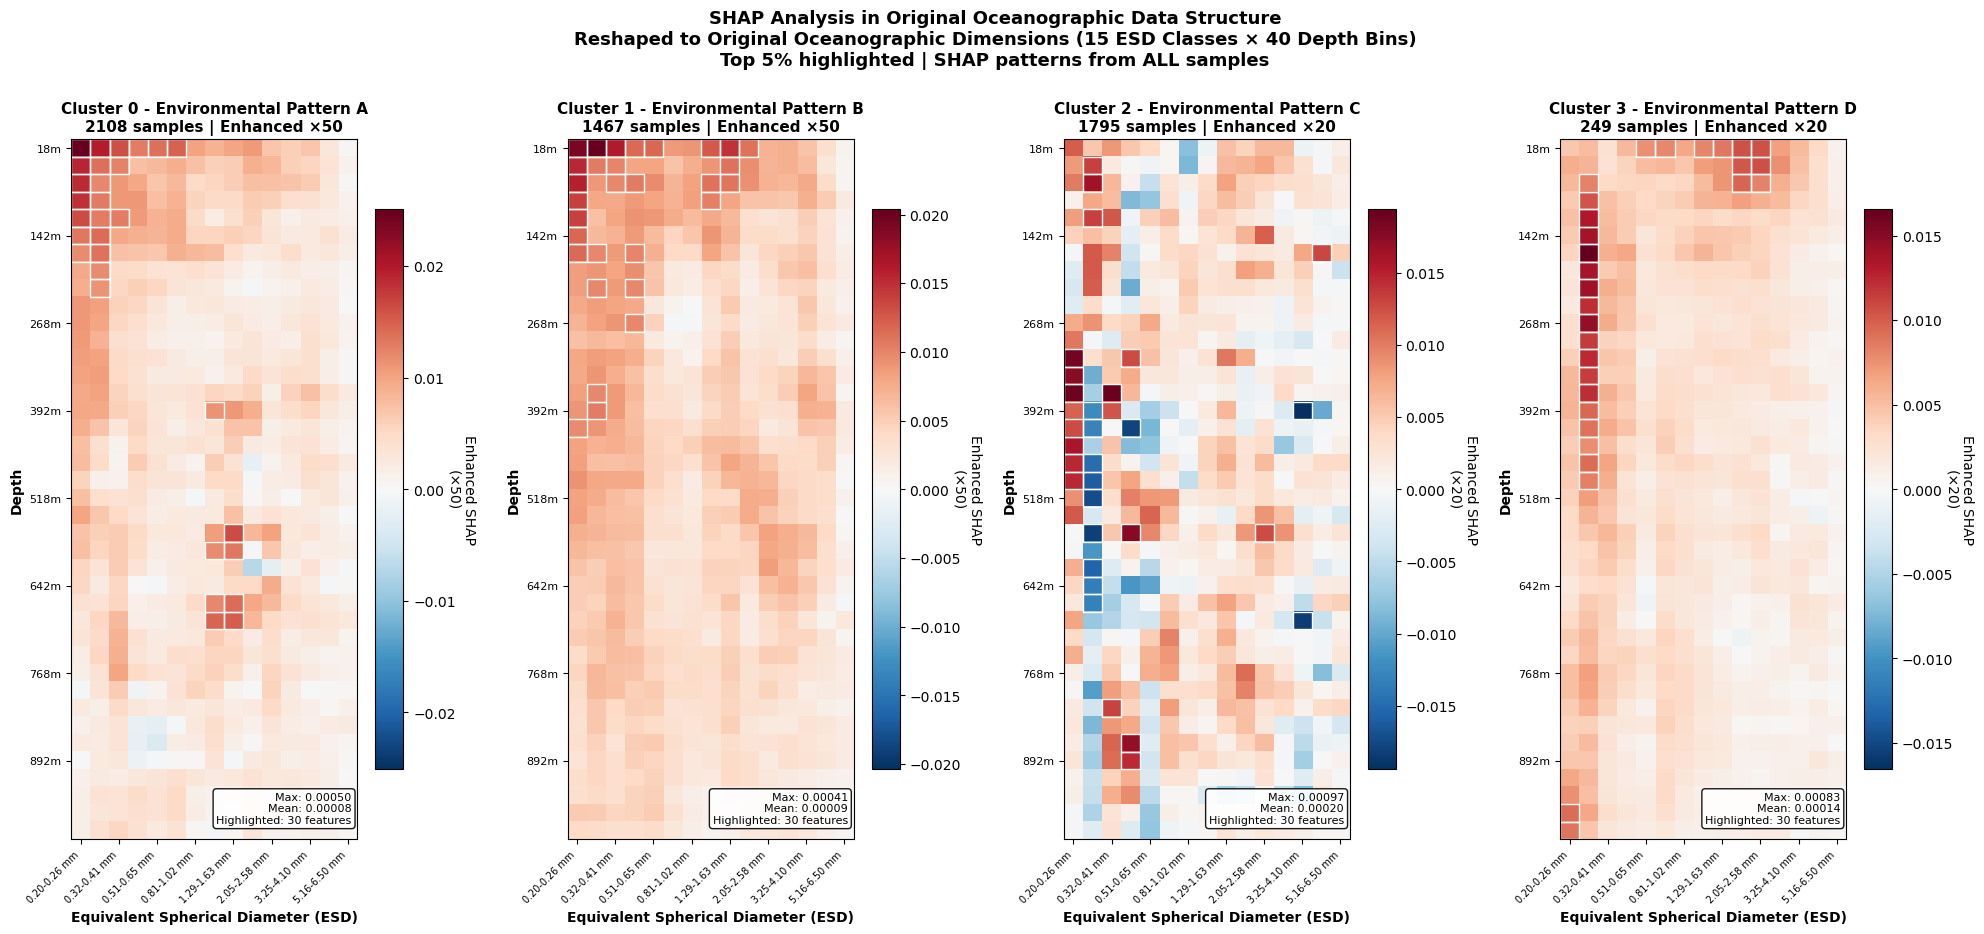


✅ Oceanographic SHAP analysis completed!
📊 SHAP values now displayed with proper scientific context:
  • Equivalent Spherical Diameter (ESD) ranges for plankton sizes
  • Actual depth measurements in meters
🌊 Ready for oceanographic interpretation!


In [67]:
def reshape_shap_to_original_data(shap_2d):
    """
    Reshape SHAP values from 46x46 image back to original data structure
    
    Correct structure based on your image creation:
    - Original data: ~40 depth bins × 15 size classes  
    - Padded:   added rows/cols, then size classes expanded to 3 pixels each
    - Final:   40 depth bins × 15 size classes (after padding adjustments)
    """
    
    # Step 1: Remove padding (adjust based on actual padding used)
    # Your image shows 40x15 final structure, so extract that region
    unpadded = shap_2d[4: 44, 1:46]  # Get 40 rows × 45 cols
    
    # Step 2: Average every 3 horizontal pixels (size classes)  
    h, w = unpadded.shape  # Should be 40 × 45
    reshaped = unpadded.reshape(h, w//3, 3).mean(axis=2)  # 40 × 15
    
    # No transpose needed - already in correct orientation:  
    # 40 depth bins (rows) × 15 size classes (cols)
    
    return reshaped  # 40×15 shape

def create_original_shape_shap_analysis(aggregated_shap_values, display_counts, metadata):
    """Create SHAP analysis in original data shape (40×15)"""
    
    print("🎨 Creating SHAP analysis in original data shape (15 size classes × 40 depth bins)...")
    
    # Define oceanographic labels
    depth_labels = [f"{17.5 + i*25:.0f}m" for i in range(40)]  # 17.5m, 42.5m, 67.5m, .. ., 992.5m
    
    size_labels = [
        "0.20-0.26 mm",
        "0.26-0.32 mm", 
        "0.32-0.41 mm",
        "0.41-0.51 mm",
        "0.51-0.65 mm",
        "0.65-0.81 mm",
        "0.81-1.02 mm",
        "1.02-1.29 mm",
        "1.29-1.63 mm", 
        "1.63-2.05 mm",
        "2.05-2.58 mm",
        "2.58-3.25 mm",
        "3.25-4.10 mm",
        "4.10-5.16 mm",
        "5.16-6.50 mm"
    ]
    
    # Calculate cluster stats and reshape
    cluster_stats = {}
    cluster_original_shapes = {}
    
    for cluster_id, shap_data in aggregated_shap_values.items():
        shap_2d = np.mean(shap_data, axis=-1) if shap_data.shape[-1] == 3 else shap_data.  squeeze()
        
        # Reshape to original data dimensions
        original_shape = reshape_shap_to_original_data(shap_2d)
        cluster_original_shapes[cluster_id] = original_shape
        
        cluster_stats[cluster_id] = {
            'mean_abs':   np.abs(original_shape).mean(),
            'max_abs':  np.abs(original_shape).max(),
            'std':  np.abs(original_shape).std(),
            'range': [original_shape.min(), original_shape.max()],
            'data':   original_shape
        }
        
        print(f"Cluster {cluster_id}: Shape {original_shape.shape}, Mean|SHAP|={cluster_stats[cluster_id]['mean_abs']:.6f}, "
              f"Max={cluster_stats[cluster_id]['max_abs']:.6f}")
    
    # Create figure with original data shape
    fig, axes = plt.subplots(1, 4, figsize=(20, 10))  # Increased width for better label visibility
    
    cluster_names = [
        'Cluster 0 - Environmental Pattern A',
        'Cluster 1 - Environmental Pattern B', 
        'Cluster 2 - Environmental Pattern C',
        'Cluster 3 - Environmental Pattern D'
    ]
    
    for cluster_id in range(4):
        if cluster_id not in cluster_stats:
            continue
            
        ax = axes[cluster_id]
        stats = cluster_stats[cluster_id]
        original_data = stats['data']
        
        # Determine contrast multiplier based on signal strength
        if stats['mean_abs'] < WEAK_SIGNAL_THRESHOLD:  
            contrast_multiplier = CONTRAST_MULTIPLIERS['weak']
            signal_type = 'weak'
        elif stats['mean_abs'] < MEDIUM_SIGNAL_THRESHOLD:  
            contrast_multiplier = CONTRAST_MULTIPLIERS['medium'] 
            signal_type = 'medium'
        else: 
            contrast_multiplier = CONTRAST_MULTIPLIERS['strong']
            signal_type = 'strong'
        
        print(f"  Cluster {cluster_id}: {signal_type} signal, using {contrast_multiplier}× contrast")
        
        # Apply contrast enhancement
        enhanced_data = original_data * contrast_multiplier
        vmax_enhanced = np.abs(enhanced_data).max()
        
        # Create plot with original aspect ratio
        im = ax.imshow(enhanced_data, cmap='RdBu_r', vmin=-vmax_enhanced, vmax=vmax_enhanced,
                      aspect='auto', origin='upper')  # aspect='auto' for 40×15 shape
        
        # Add highlighting for most important features
        threshold = np.percentile(np.abs(original_data).flatten(), HIGHLIGHT_PERCENTILE)
        highlight_mask = np.abs(original_data) > threshold
        
        n_highlighted = 0
        if highlight_mask.any():
            rows, cols = np.where(highlight_mask)
            for r, c in zip(rows, cols):
                rect = Rectangle((c-0.5, r-0.5), 1, 1, fill=False, 
                               edgecolor='white', linewidth=1.0, clip_on=False)
                ax.add_patch(rect)
            n_highlighted = len(rows)
        
        # Colorbar
        cbar = plt. colorbar(im, ax=ax, shrink=0.8)
        cbar.set_label(f'Enhanced SHAP\n(×{contrast_multiplier})', rotation=270, labelpad=15)
        
        # Enhanced title
        n_display = display_counts. get(cluster_id, 0)
        total_samples = metadata['cluster_sample_counts']. get(cluster_id, 0)
        
        if SUBSAMPLE_SIZE and n_display < total_samples:
            sample_text = f'{n_display}/{total_samples} samples'
        else:
            sample_text = f'{total_samples} samples'
        
        ax.set_title(f'{cluster_names[cluster_id]}\n{sample_text} | Enhanced ×{contrast_multiplier}', 
                     fontsize=FONT_SIZES['title'], fontweight='bold')
        
        # Add oceanographic axis labels
        ax.set_xlabel('Equivalent Spherical Diameter (ESD)', fontsize=10, fontweight='bold')
        ax.set_ylabel('Depth', fontsize=10, fontweight='bold')
        
        # Set detailed tick labels
        # X-axis: Size classes (show every other one to avoid crowding)
        x_tick_positions = np.arange(0, 15, 2)  # Show every 2nd size class
        x_tick_labels = [size_labels[i] for i in x_tick_positions]
        ax.set_xticks(x_tick_positions)
        ax.set_xticklabels(x_tick_labels, rotation=45, ha='right', fontsize=7)
        
        # Y-axis: Depth bins (show every 5th depth)
        y_tick_positions = np.arange(0, 40, 5)  # Show every 5th depth bin
        y_tick_labels = [depth_labels[i] for i in y_tick_positions]
        ax.set_yticks(y_tick_positions)
        ax.set_yticklabels(y_tick_labels, fontsize=8)
        
        # # Add grid for better readability
        # ax.grid(True, alpha=0.3, linewidth=0.5)
        
        # Statistics box in bottom right
        stats_dict = {
            f'Max':   f'{stats["max_abs"]:.5f}',
            f'Mean':  f'{stats["mean_abs"]:.5f}',
            f'Highlighted': f'{n_highlighted} features'
        }
        add_stats_box(ax, stats_dict, STATS_BOX_POSITION)
    
    # Enhanced main title
    subtitle = (f'Reshaped to Original Oceanographic Dimensions (15 ESD Classes × 40 Depth Bins)\n'
               f'Top {100-HIGHLIGHT_PERCENTILE}% highlighted | SHAP patterns from ALL samples')
    
    fig.suptitle(f'SHAP Analysis in Original Oceanographic Data Structure\n{subtitle}', 
                fontsize=FONT_SIZES['suptitle'], fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.85, bottom=0.15)  # More bottom space for rotated labels
    
    # Save plot
    timestamp = metadata. get('timestamp', 'unknown')
    subsample_suffix = f'_display{SUBSAMPLE_SIZE}' if SUBSAMPLE_SIZE else '_allsamples'
    filename = f'oceanographic_shap_analysis_{timestamp}{subsample_suffix}_top{100-HIGHLIGHT_PERCENTILE}pct.png'
    plt.savefig(filename, dpi=DPI, bbox_inches='tight')
    print(f"💾 Oceanographic SHAP analysis saved:  {filename}")
    
    plt.show()
    
    return cluster_original_shapes

# ============================================================================
# USAGE
# ============================================================================

# Load the saved SHAP results  
all_cluster_samples, all_cluster_shap_values, aggregated_shap_values, metadata = load_latest_shap_results()

if aggregated_shap_values is not None:
    # Get display sample counts
    display_counts = get_display_sample_counts(all_cluster_samples, SUBSAMPLE_SIZE)
    
    print("\n🚀 Creating oceanographic SHAP analysis...")
    print("🔄 Reshaping from 46×46 image back to 40×15 original data dimensions")
    print("🌊 Adding proper oceanographic axis labels:")
    print("   • X-axis: 15 ESD size classes (0.20-6.50 mm)")
    print("   • Y-axis: 40 depth bins (17.5-992.5 m)")
    
    # Create the original shape visualization
    cluster_original_shapes = create_original_shape_shap_analysis(
        aggregated_shap_values, display_counts, metadata
    )
    
    print("\n✅ Oceanographic SHAP analysis completed!")
    print("📊 SHAP values now displayed with proper scientific context:")
    print("  • Equivalent Spherical Diameter (ESD) ranges for plankton sizes")
    print("  • Actual depth measurements in meters")
    print("🌊 Ready for oceanographic interpretation!")
    
else:
    print("❌ Could not load SHAP results.  Please check the file path.")

🎨 SHAP + Biovolume Combined Analysis (FIXED VERSION)
📊 Configuration:
  • Highlight percentile: 95% (top 5%)
  • Subsample size: All samples
  • Stats box position: bottom_right
  • Figure size: (20, 12)
  • DPI: 300
📁 Loading SHAP results from: ../Data\shap_results_20260106_111032
📊 Aggregated file: aggregated_shap_only_20260106_111032.pkl
💾 Complete file: complete_shap_results_20260106_111032.pkl
✅ Loaded SHAP results for 4 clusters
📈 Total samples: 5619
📊 Using ALL samples for display

🚀 Creating combined SHAP and biovolume analysis...  (FIXED VERSION)
🔄 Loading original biovolume data and cluster assignments
📊 Computing mean biovolume patterns per cluster
🎨 Creating combined SHAP and biovolume analysis...
📊 Loading original biovolume data and cluster assignments...
✅ Loaded 224760 biovolume records
✅ Loaded cluster assignments for 5619 profiles
📊 Sample biovolume columns: ['Biovolume norm [ppm mm-1] (ESD: 0.203-0.256 mm)', 'Biovolume norm [ppm mm-1] (ESD: 0.256-0.323 mm)', 'Biovolu

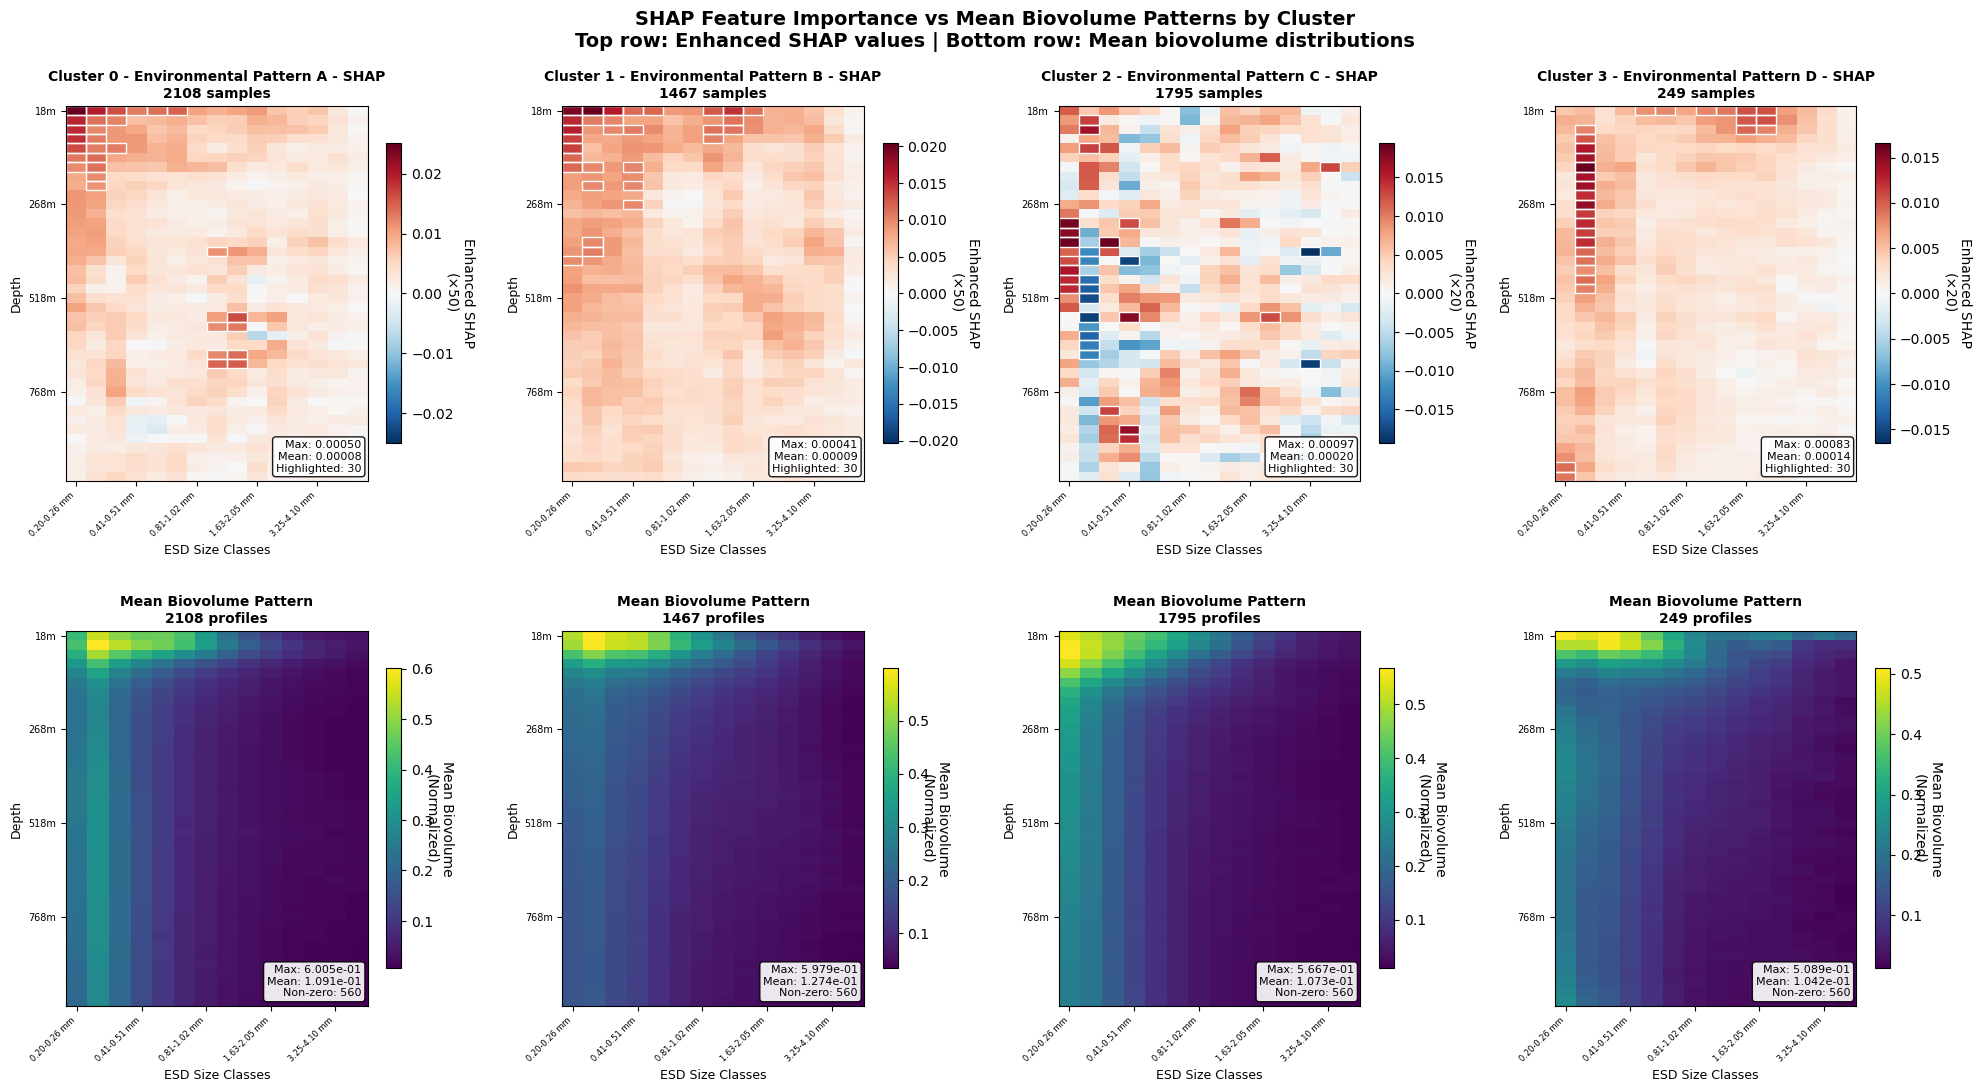


✅ Combined analysis completed!
🎨 Created comprehensive comparison:
  • Top row:  SHAP feature importance (what the model learned)
  • Bottom row:  Actual mean biovolume patterns (ground truth)
🔍 Compare patterns to validate model interpretability!
🌊 Ready for oceanographic interpretation!


In [77]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib. colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from scipy import ndimage
import seaborn as sns
import pandas as pd

# ============================================================================
# CONFIGURABLE PARAMETERS - ADJUST HERE
# ============================================================================

# Analysis Parameters
TOP_N_PIXELS = 20              # Number of top pixels to analyze per cluster
HIGHLIGHT_PERCENTILE = 95      # Percentile for highlighting (95 = top 5%)
SUBSAMPLE_SIZE = None          # Number of samples to randomly subsample per cluster (None = use all)

# Visualization Parameters  
FIGURE_SIZE = (20, 10)         # Size of the main figure
DPI = 300                      # Resolution for saved plots
CONTRAST_MULTIPLIERS = {       # Contrast enhancement per cluster type
    'weak': 50,                # For clusters with very low SHAP values
    'medium': 20,              # For clusters with medium SHAP values  
    'strong': 10               # For clusters with strong SHAP values
}
WEAK_SIGNAL_THRESHOLD = 0.0001 # Threshold to classify as weak signal
MEDIUM_SIGNAL_THRESHOLD = 0.0002 # Threshold to classify as medium signal

# Layout Parameters
STATS_BOX_POSITION = 'bottom_right'  # Position for statistics box
COLORBAR_SHRINK = 0.8               # Size of colorbars
FONT_SIZES = {
    'title': 11,
    'subtitle': 9,
    'stats': 8,
    'suptitle': 13
}

# ============================================================================
# LOAD SAVED SHAP RESULTS
# ============================================================================

def load_latest_shap_results(save_dir="../Data"):
    """Load the most recent SHAP results"""
    from glob import glob
    
    # Find all SHAP result directories
    pattern = os.path.join(save_dir, "shap_results_*")
    shap_dirs = glob(pattern)
    
    if not shap_dirs:
        print("❌ No saved SHAP results found!")
        return None, None, None, None
    
    # Get the most recent directory
    latest_dir = max(shap_dirs, key=os.path.getctime)
    
    # Find the aggregated results file in that directory
    agg_files = glob(os.path.join(latest_dir, "aggregated_shap_only_*.pkl"))
    complete_files = glob(os.path.join(latest_dir, "complete_shap_results_*.pkl"))
    
    if not agg_files or not complete_files:  
        print("❌ SHAP files not found in directory!")
        return None, None, None, None
    
    agg_file = agg_files[0]
    complete_file = complete_files[0]
    
    print(f"📁 Loading SHAP results from: {latest_dir}")
    print(f"📊 Aggregated file: {os.path.basename(agg_file)}")
    print(f"💾 Complete file: {os.path.basename(complete_file)}")
    
    # Load aggregated results
    with open(agg_file, 'rb') as f:
        aggregated_shap_values = pickle.load(f)
    
    # Load complete results  
    with open(complete_file, 'rb') as f:
        complete_results = pickle.load(f)
    
    all_cluster_samples = complete_results['cluster_samples']
    all_cluster_shap_values = complete_results['cluster_shap_values']
    metadata = complete_results['metadata']
    
    print(f"✅ Loaded SHAP results for {len(aggregated_shap_values)} clusters")
    print(f"📈 Total samples: {metadata['total_samples']}")
    
    return all_cluster_samples, all_cluster_shap_values, aggregated_shap_values, metadata

def get_display_sample_counts(all_cluster_samples, subsample_size):
    """Get sample counts for display (subsampled or full)"""
    
    display_counts = {}
    
    if subsample_size is None:  
        print("📊 Using ALL samples for display")
        for cluster_id, samples in all_cluster_samples.items():
            display_counts[cluster_id] = len(samples)
    else:
        print(f"🎲 Display counts based on {subsample_size} subsample per cluster")
        np.random.seed(42)  # For reproducible display
        
        for cluster_id, samples in all_cluster_samples.items():
            n_available = len(samples)
            n_display = min(subsample_size, n_available)
            display_counts[cluster_id] = n_display
            
            if n_display < n_available:
                print(f"  Cluster {cluster_id}: showing {n_display}/{n_available} samples")
            else:
                print(f"  Cluster {cluster_id}:  showing all {n_available} samples")
    
    return display_counts

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def add_stats_box(ax, stats_dict, position='bottom_right'):
    """Add statistics box to plot"""
    
    stats_text = '\n'.join([f'{key}: {value}' for key, value in stats_dict.items()])
    
    # Determine position
    if position == 'bottom_right':
        x, y = 0.98, 0.02
        ha, va = 'right', 'bottom'
    elif position == 'top_right':
        x, y = 0.98, 0.98  
        ha, va = 'right', 'top'
    elif position == 'bottom_left':      
        x, y = 0.02, 0.02
        ha, va = 'left', 'bottom'
    else:  # top_left
        x, y = 0.02, 0.98
        ha, va = 'left', 'top'
    
    ax.text(x, y, stats_text, transform=ax.transAxes, fontsize=FONT_SIZES['stats'],
           horizontalalignment=ha, verticalalignment=va,
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))

def reshape_shap_to_original_data(shap_2d):
    """
    Reshape SHAP values from 46x46 image back to original data structure
    
    Correct structure based on your image creation:
    - Original data: ~40 depth bins × 15 size classes  
    - Padded:  added rows/cols, then size classes expanded to 3 pixels each
    - Final:  40 depth bins × 15 size classes (after padding adjustments)
    """
    
    # Step 1: Remove padding (adjust based on actual padding used)
    # Your image shows 40x15 final structure, so extract that region
    unpadded = shap_2d[4:44, 1:46]  # Get 40 rows × 45 cols
    
    # Step 2: Average every 3 horizontal pixels (size classes)  
    h, w = unpadded.shape  # Should be 40 × 45
    reshaped = unpadded.reshape(h, w//3, 3).mean(axis=2)  # 40 × 15
    
    # No transpose needed - already in correct orientation:     
    # 40 depth bins (rows) × 15 size classes (cols)
    
    return reshaped  # 40×15 shape

# ============================================================================
# BIOVOLUME DATA LOADING AND PROCESSING
# ============================================================================

def normalize_by_profile_global_max(df, group_col, columns):
    """
    Normalize biovolume data by profile global max
    (This function matches your original normalization)
    """
    # 1. Relevante Spalten extrahieren
    sub = df[columns]
    
    # 2. Pro Gruppe (Profile) das Spaltenmaximum bestimmen
    group_col_max = df.groupby(group_col)[columns].transform("max")
    
    # 3. Aus diesen Spaltenmaxima das globale Maximum pro Gruppe ableiten
    profile_max = group_col_max.max(axis=1)
    
    # 4. Division durch 0 vermeiden (Profil komplett 0)
    denom = profile_max.replace(0, 1)
    
    # 5. Alles durch diesen Skalar teilen
    normalized = sub.div(denom, axis=0)
    
    # 6. Zurück ins Original-DataFrame schreiben
    df_norm = df.copy()
    df_norm[columns] = normalized
    
    return df_norm

def load_cluster_biovolume_data_fixed():
    """Load original biovolume data and cluster assignments - FIXED VERSION"""
    
    print("📊 Loading original biovolume data and cluster assignments...")
    
    # Load biovolume data
    df = pd.read_pickle('../Data/Biovolume_per_size_class_and_depth_updated.pkl')
    
    # Load hierarchy mapping
    with open('../Data/cnn_hierarchy_config.pkl', 'rb') as f:
        hierarchy_info = pickle.load(f)
    
    # Load cluster assignments - FIXED:  It's a DataFrame, not a dictionary!  
    with open('../Data/Profile_id_to_clusters_v3.pkl', 'rb') as f:
        cluster_data = pickle.load(f)
    
    # Extract the actual data from the DataFrame structure
    profile_ids = cluster_data['Profile_id'].values
    cluster_10_labels = cluster_data['cluster'].values
    
    # Create the actual dictionary mapping
    cluster_assignments = dict(zip(profile_ids, cluster_10_labels))
    
    print(f"✅ Loaded {len(df)} biovolume records")
    print(f"✅ Loaded cluster assignments for {len(cluster_assignments)} profiles")
    print(f"📊 Sample biovolume columns: {[col for col in df.columns if 'Biovolume' in col][: 3]}")
    print(f"📊 Sample Profile_ids in biovolume data: {df['Profile_id'].unique()[:5]}")
    print(f"📊 Sample cluster assignments: {dict(list(cluster_assignments.items())[:5])}")
    
    # Check overlap between biovolume Profile_ids and cluster assignment keys
    biovolume_profiles = set(df['Profile_id'].unique())
    cluster_profiles = set(cluster_assignments.keys())
    overlap = biovolume_profiles.intersection(cluster_profiles)
    print(f"📊 Profiles in biovolume data: {len(biovolume_profiles)}")
    print(f"📊 Profiles in cluster assignments: {len(cluster_profiles)}")  
    print(f"📊 Overlapping profiles: {len(overlap)}")
    
    # Debug hierarchy info
    print("🔍 Hierarchy info structure:")
    if 'level_mappings' in hierarchy_info: 
        for level, mapping in hierarchy_info['level_mappings'].items():
            print(f"  {level}: {dict(list(mapping.items())[:5])}")
    
    return df, hierarchy_info, cluster_assignments

def map_to_4clusters_fixed(cluster_10_value, hierarchy_info):
    """Map single 10-cluster label to 4-cluster label - FIXED VERSION"""
    target_level = 'level_2_groups'  # 4 clusters
    hierarchy_mapping = hierarchy_info['level_mappings'][target_level]
    
    # Convert to int for lookup (cluster values are integers)
    cluster_10_int = int(cluster_10_value)
    
    # Find mapping in hierarchy - keys are numpy. int32, values are numpy.int32
    for k, v in hierarchy_mapping.items():
        if int(k) == cluster_10_int:
            return int(v)
    
    # Default to cluster 0 if not found
    print(f"⚠️ Warning: Could not map cluster {cluster_10_int}, defaulting to cluster 0")
    return 0

def calculate_cluster_biovolume_means_fixed(df, hierarchy_info, cluster_assignments):
    """Calculate mean biovolume profiles for each 4-cluster - FIXED VERSION"""
    
    print("🧮 Calculating mean biovolume profiles per cluster...")
    
    # Get biovolume columns - FIXED: Use actual column names
    size_cols = [col for col in df.columns if 'Biovolume norm' in col]
    size_cols = size_cols[:-3]  # Remove three largest size bins
    
    print(f"Using {len(size_cols)} biovolume size classes")
    print(f"Size columns: {size_cols[: 2]}...  {size_cols[-2:]}")
    
    # Check available depth bins
    depth_bins = sorted(df['depth_bin'].unique())
    print(f"Available depth bins: {len(depth_bins)} bins, range: {min(depth_bins)} to {max(depth_bins)}")
    
    # Map profile IDs to 4-clusters
    profile_to_4cluster = {}
    mapping_debug = {}
    successful_mappings = 0
    
    for profile_id, cluster_10 in cluster_assignments.items():
        try:
            cluster_4 = map_to_4clusters_fixed(cluster_10, hierarchy_info)
            profile_to_4cluster[profile_id] = cluster_4
            successful_mappings += 1
            
            # Debug:  Track mapping
            if cluster_10 not in mapping_debug:
                mapping_debug[cluster_10] = cluster_4
                
        except Exception as e:  
            print(f"⚠️ Error mapping profile {profile_id}: {e}")
            continue
    
    print(f"Successfully mapped {successful_mappings}/{len(cluster_assignments)} profiles")
    print(f"Cluster mapping summary (10-cluster → 4-cluster): {mapping_debug}")
    
    # Add cluster labels to dataframe
    df['cluster_4'] = df['Profile_id'].map(profile_to_4cluster)
    
    # Remove profiles that couldn't be mapped and check what we have
    df_before = len(df)
    df_mapped = df. dropna(subset=['cluster_4'])
    df_mapped['cluster_4'] = df_mapped['cluster_4'].astype(int)
    
    print(f"Biovolume records:  {df_before} → {len(df_mapped)} after cluster mapping")
    if len(df_mapped) > 0:
        print(f"Cluster distribution in biovolume data: {df_mapped['cluster_4'].value_counts().sort_index()}")
    else:
        print("❌ No biovolume data could be mapped to clusters!")
        return {0: None, 1: None, 2: None, 3: None}, profile_to_4cluster
    
    # Calculate mean biovolume by depth and size for each cluster
    cluster_means = {}
    
    for cluster_id in range(4):
        cluster_data = df_mapped[df_mapped['cluster_4'] == cluster_id]
        
        if len(cluster_data) == 0:
            print(f"⚠️ No biovolume data for cluster {cluster_id}")
            cluster_means[cluster_id] = None
            continue
        
        print(f"Cluster {cluster_id}: {len(cluster_data)} biovolume records from {len(cluster_data['Profile_id'].unique())} profiles")
        
        # Group by depth_bin and calculate mean biovolume
        depth_means = cluster_data.groupby('depth_bin')[size_cols].mean()
        
        print(f"  Depth bins available: {len(depth_means)} (range: {depth_means.index.min()} to {depth_means.index.max()})")
        
        # Ensure we have 40 depth bins (pad if necessary) 
        all_depths = range(40)  # Assuming 40 depth bins
        depth_means_full = depth_means.reindex(all_depths, fill_value=0)
        
        # Convert to array and take first 15 size classes to match SHAP
        biovolume_array = depth_means_full[size_cols[: 15]].values  # 40 x 15
        
        cluster_means[cluster_id] = biovolume_array
        
        print(f"  Final biovolume array shape: {biovolume_array.shape}")
        print(f"  Biovolume range: [{biovolume_array. min():.2e}, {biovolume_array. max():.2e}]")
        print(f"  Non-zero values: {np.count_nonzero(biovolume_array)}/{biovolume_array.size}")
    
    return cluster_means, profile_to_4cluster

# ============================================================================
# MAIN VISUALIZATION FUNCTION  
# ============================================================================

def create_combined_shap_biovolume_analysis_fixed(aggregated_shap_values, display_counts, metadata):
    """Create SHAP analysis with biovolume means side by side - FIXED VERSION"""
    
    print("🎨 Creating combined SHAP and biovolume analysis...")
    
    # Load biovolume data - FIXED VERSION
    df, hierarchy_info, cluster_assignments = load_cluster_biovolume_data_fixed()
    
    # Apply normalization like in your original code
    size_cols = [col for col in df.columns if 'Biovolume norm' in col]
    size_cols = size_cols[:-3]  # Remove three largest size bins
    
    print("🔄 Applying biovolume normalization...")
    df = normalize_by_profile_global_max(df, "Profile_id", size_cols)
    
    cluster_biovolume_means, profile_to_4cluster = calculate_cluster_biovolume_means_fixed(df, hierarchy_info, cluster_assignments)
    
    # Define oceanographic labels
    depth_labels = [f"{17.5 + i*25:.0f}m" for i in range(40)]
    size_labels = [
        "0.20-0.26 mm", "0.26-0.32 mm", "0.32-0.41 mm", "0.41-0.51 mm",
        "0.51-0.65 mm", "0.65-0.81 mm", "0.81-1.02 mm", "1.02-1.29 mm",
        "1.29-1.63 mm", "1.63-2.05 mm", "2.05-2.58 mm", "2.58-3.25 mm",
        "3.25-4.10 mm", "4.10-5.16 mm", "5.16-6.50 mm"
    ]
    
    # Calculate cluster stats and reshape
    cluster_stats = {}
    cluster_original_shapes = {}
    
    for cluster_id, shap_data in aggregated_shap_values.items():
        shap_2d = np.mean(shap_data, axis=-1) if shap_data.shape[-1] == 3 else shap_data. squeeze()
        
        # Reshape to original data dimensions
        original_shape = reshape_shap_to_original_data(shap_2d)
        cluster_original_shapes[cluster_id] = original_shape
        
        cluster_stats[cluster_id] = {
            'mean_abs':  np.abs(original_shape).mean(),
            'max_abs': np.abs(original_shape).max(),
            'std':  np.abs(original_shape).std(),
            'range': [original_shape.min(), original_shape.max()],
            'data':  original_shape
        }
        
        print(f"Cluster {cluster_id}: Shape {original_shape.shape}, Mean|SHAP|={cluster_stats[cluster_id]['mean_abs']:.6f}")
    
    # Create figure with 2 rows per cluster (SHAP + Biovolume)
    fig, axes = plt.subplots(2, 4, figsize=(20, 12))
    
    cluster_names = [
        'Cluster 0 - Environmental Pattern A',
        'Cluster 1 - Environmental Pattern B', 
        'Cluster 2 - Environmental Pattern C',
        'Cluster 3 - Environmental Pattern D'
    ]
    
    for cluster_id in range(4):
        if cluster_id not in cluster_stats:
            continue
        
        # SHAP subplot (top row)
        ax_shap = axes[0, cluster_id]
        stats = cluster_stats[cluster_id]
        original_data = stats['data']
        
        # Determine contrast multiplier
        if stats['mean_abs'] < WEAK_SIGNAL_THRESHOLD:     
            contrast_multiplier = CONTRAST_MULTIPLIERS['weak']
        elif stats['mean_abs'] < MEDIUM_SIGNAL_THRESHOLD:  
            contrast_multiplier = CONTRAST_MULTIPLIERS['medium']
        else:
            contrast_multiplier = CONTRAST_MULTIPLIERS['strong']
        
        # Apply contrast enhancement
        enhanced_data = original_data * contrast_multiplier
        vmax_enhanced = np.abs(enhanced_data).max()
        
        # Create SHAP plot
        im_shap = ax_shap.imshow(enhanced_data, cmap='RdBu_r', vmin=-vmax_enhanced, vmax=vmax_enhanced,
                                aspect='auto', origin='upper')
        
        # Add highlighting for most important features
        threshold = np.percentile(np.abs(original_data).flatten(), HIGHLIGHT_PERCENTILE)
        highlight_mask = np.abs(original_data) > threshold
        
        n_highlighted = 0
        if highlight_mask.any():
            rows, cols = np.where(highlight_mask)
            for r, c in zip(rows, cols):
                rect = Rectangle((c-0.5, r-0.5), 1, 1, fill=False, 
                               edgecolor='white', linewidth=1.0, clip_on=False)
                ax_shap.add_patch(rect)
            n_highlighted = len(rows)
        
        # SHAP colorbar
        cbar_shap = plt.colorbar(im_shap, ax=ax_shap, shrink=0.8)
        cbar_shap.set_label(f'Enhanced SHAP\n(×{contrast_multiplier})', rotation=270, labelpad=15)
        
        # SHAP title
        n_display = display_counts. get(cluster_id, 0)
        total_samples = metadata['cluster_sample_counts'].get(cluster_id, 0)
        
        if SUBSAMPLE_SIZE and n_display < total_samples:
            sample_text = f'{n_display}/{total_samples} samples'
        else:
            sample_text = f'{total_samples} samples'
        
        ax_shap.set_title(f'{cluster_names[cluster_id]} - SHAP\n{sample_text}', 
                         fontsize=10, fontweight='bold')
        
        # SHAP axis labels and ticks
        ax_shap.set_xlabel('ESD Size Classes', fontsize=9)
        ax_shap.set_ylabel('Depth', fontsize=9)
        
        x_tick_positions = np.arange(0, 15, 3)
        x_tick_labels = [size_labels[i] for i in x_tick_positions]
        ax_shap.set_xticks(x_tick_positions)
        ax_shap.set_xticklabels(x_tick_labels, rotation=45, ha='right', fontsize=6)
        
        y_tick_positions = np.arange(0, 40, 10)
        y_tick_labels = [depth_labels[i] for i in y_tick_positions]
        ax_shap.set_yticks(y_tick_positions)
        ax_shap.set_yticklabels(y_tick_labels, fontsize=7)
        
        # SHAP statistics box
        stats_dict = {
            'Max': f'{stats["max_abs"]:.5f}',
            'Mean': f'{stats["mean_abs"]:.5f}',
            'Highlighted': f'{n_highlighted}'
        }
        add_stats_box(ax_shap, stats_dict, 'bottom_right')
        
        # Biovolume subplot (bottom row)
        ax_bio = axes[1, cluster_id]
        
        if cluster_biovolume_means[cluster_id] is not None:  
            biovolume_data = cluster_biovolume_means[cluster_id]
            
            print(f"📊 Plotting biovolume for cluster {cluster_id}:  shape {biovolume_data.shape}, range [{biovolume_data.min():.3e}, {biovolume_data.max():.3e}]")
            
            # Create biovolume plot
            im_bio = ax_bio.imshow(biovolume_data, cmap='viridis', aspect='auto', origin='upper')
            
            # Biovolume colorbar
            cbar_bio = plt.colorbar(im_bio, ax=ax_bio, shrink=0.8)
            cbar_bio. set_label('Mean Biovolume\n(Normalized)', rotation=270, labelpad=15)
            
            # Count unique profiles for this cluster
            cluster_profiles = [pid for pid, cid in profile_to_4cluster.items() if cid == cluster_id]
            
            ax_bio.set_title(f'Mean Biovolume Pattern\n{len(cluster_profiles)} profiles', 
                            fontsize=10, fontweight='bold')
            
            # Biovolume axis labels and ticks
            ax_bio.set_xlabel('ESD Size Classes', fontsize=9)
            ax_bio.set_ylabel('Depth', fontsize=9)
            ax_bio.set_xticks(x_tick_positions)
            ax_bio.set_xticklabels(x_tick_labels, rotation=45, ha='right', fontsize=6)
            ax_bio.set_yticks(y_tick_positions)
            ax_bio.set_yticklabels(y_tick_labels, fontsize=7)
            
            # Biovolume statistics
            bio_stats = {
                'Max':  f'{biovolume_data. max():.3e}',
                'Mean': f'{biovolume_data.mean():.3e}',
                'Non-zero': f'{np.count_nonzero(biovolume_data)}'
            }
            add_stats_box(ax_bio, bio_stats, 'bottom_right')
            
        else:
            ax_bio.text(0.5, 0.5, 'No biovolume\ndata available', 
                       ha='center', va='center', transform=ax_bio.transAxes, fontsize=12)
            ax_bio.set_title(f'Mean Biovolume Pattern\n(No data)', fontsize=10, fontweight='bold')
            ax_bio.axis('off')
    
    # Main title
    fig.suptitle('SHAP Feature Importance vs Mean Biovolume Patterns by Cluster\n'
                f'Top row: Enhanced SHAP values | Bottom row: Mean biovolume distributions', 
                fontsize=14, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.90, bottom=0.15, hspace=0.4)
    
    # Save plot
    timestamp = metadata. get('timestamp', 'unknown')
    subsample_suffix = f'_display{SUBSAMPLE_SIZE}' if SUBSAMPLE_SIZE else '_allsamples'
    filename = f'combined_shap_biovolume_analysis_fixed_{timestamp}{subsample_suffix}.png'
    plt.savefig(filename, dpi=DPI, bbox_inches='tight')
    print(f"💾 Combined SHAP-biovolume analysis saved:  {filename}")
    
    plt.show()
    
    return cluster_original_shapes, cluster_biovolume_means

# ============================================================================
# USAGE
# ============================================================================

print("🎨 SHAP + Biovolume Combined Analysis (FIXED VERSION)")
print("=" * 60)
print(f"📊 Configuration:")
print(f"  • Highlight percentile: {HIGHLIGHT_PERCENTILE}% (top {100-HIGHLIGHT_PERCENTILE}%)")
print(f"  • Subsample size: {SUBSAMPLE_SIZE if SUBSAMPLE_SIZE else 'All samples'}")
print(f"  • Stats box position: {STATS_BOX_POSITION}")
print(f"  • Figure size: (20, 12)")
print(f"  • DPI: {DPI}")
print("=" * 60)

# Load the saved SHAP results
all_cluster_samples, all_cluster_shap_values, aggregated_shap_values, metadata = load_latest_shap_results()

if aggregated_shap_values is not None:
    # Get display sample counts
    display_counts = get_display_sample_counts(all_cluster_samples, SUBSAMPLE_SIZE)
    
    print("\n🚀 Creating combined SHAP and biovolume analysis...  (FIXED VERSION)")
    print("🔄 Loading original biovolume data and cluster assignments")
    print("📊 Computing mean biovolume patterns per cluster")
    
    # Create the combined visualization
    cluster_original_shapes, cluster_biovolume_means = create_combined_shap_biovolume_analysis_fixed(
        aggregated_shap_values, display_counts, metadata
    )
    
    print("\n✅ Combined analysis completed!")
    print("🎨 Created comprehensive comparison:")
    print("  • Top row:  SHAP feature importance (what the model learned)")
    print("  • Bottom row:  Actual mean biovolume patterns (ground truth)")
    print("🔍 Compare patterns to validate model interpretability!")
    print("🌊 Ready for oceanographic interpretation!")
    
else:
    print("❌ Could not load SHAP results.  Please check the file path.")

🎨 SHAP + Biovolume Range Frequency Analysis
📊 Configuration:
  • Lower threshold: None
  • Upper threshold: None
  • Lower percentile: 70
  • Upper percentile: 100
  • Highlight percentile: 95% (top 5%)
  • Subsample size: All samples
  • Figure size: (20, 12)
  • DPI: 300
📁 Loading SHAP results from:  ../Data\shap_results_20260106_111032
📊 Aggregated file: aggregated_shap_only_20260106_111032.pkl
💾 Complete file: complete_shap_results_20260106_111032.pkl
✅ Loaded SHAP results for 4 clusters
📈 Total samples: 5619
📊 Using ALL samples for display

🚀 Creating combined SHAP and biovolume range frequency analysis...
🔄 Loading original biovolume data and cluster assignments
📊 Computing frequency of profiles within biovolume range per cluster
🎨 Creating combined SHAP and biovolume range frequency analysis...
📊 Loading original biovolume data and cluster assignments...
✅ Loaded 224760 biovolume records
✅ Loaded cluster assignments for 5619 profiles
📊 Sample biovolume columns: ['Biovolume norm 

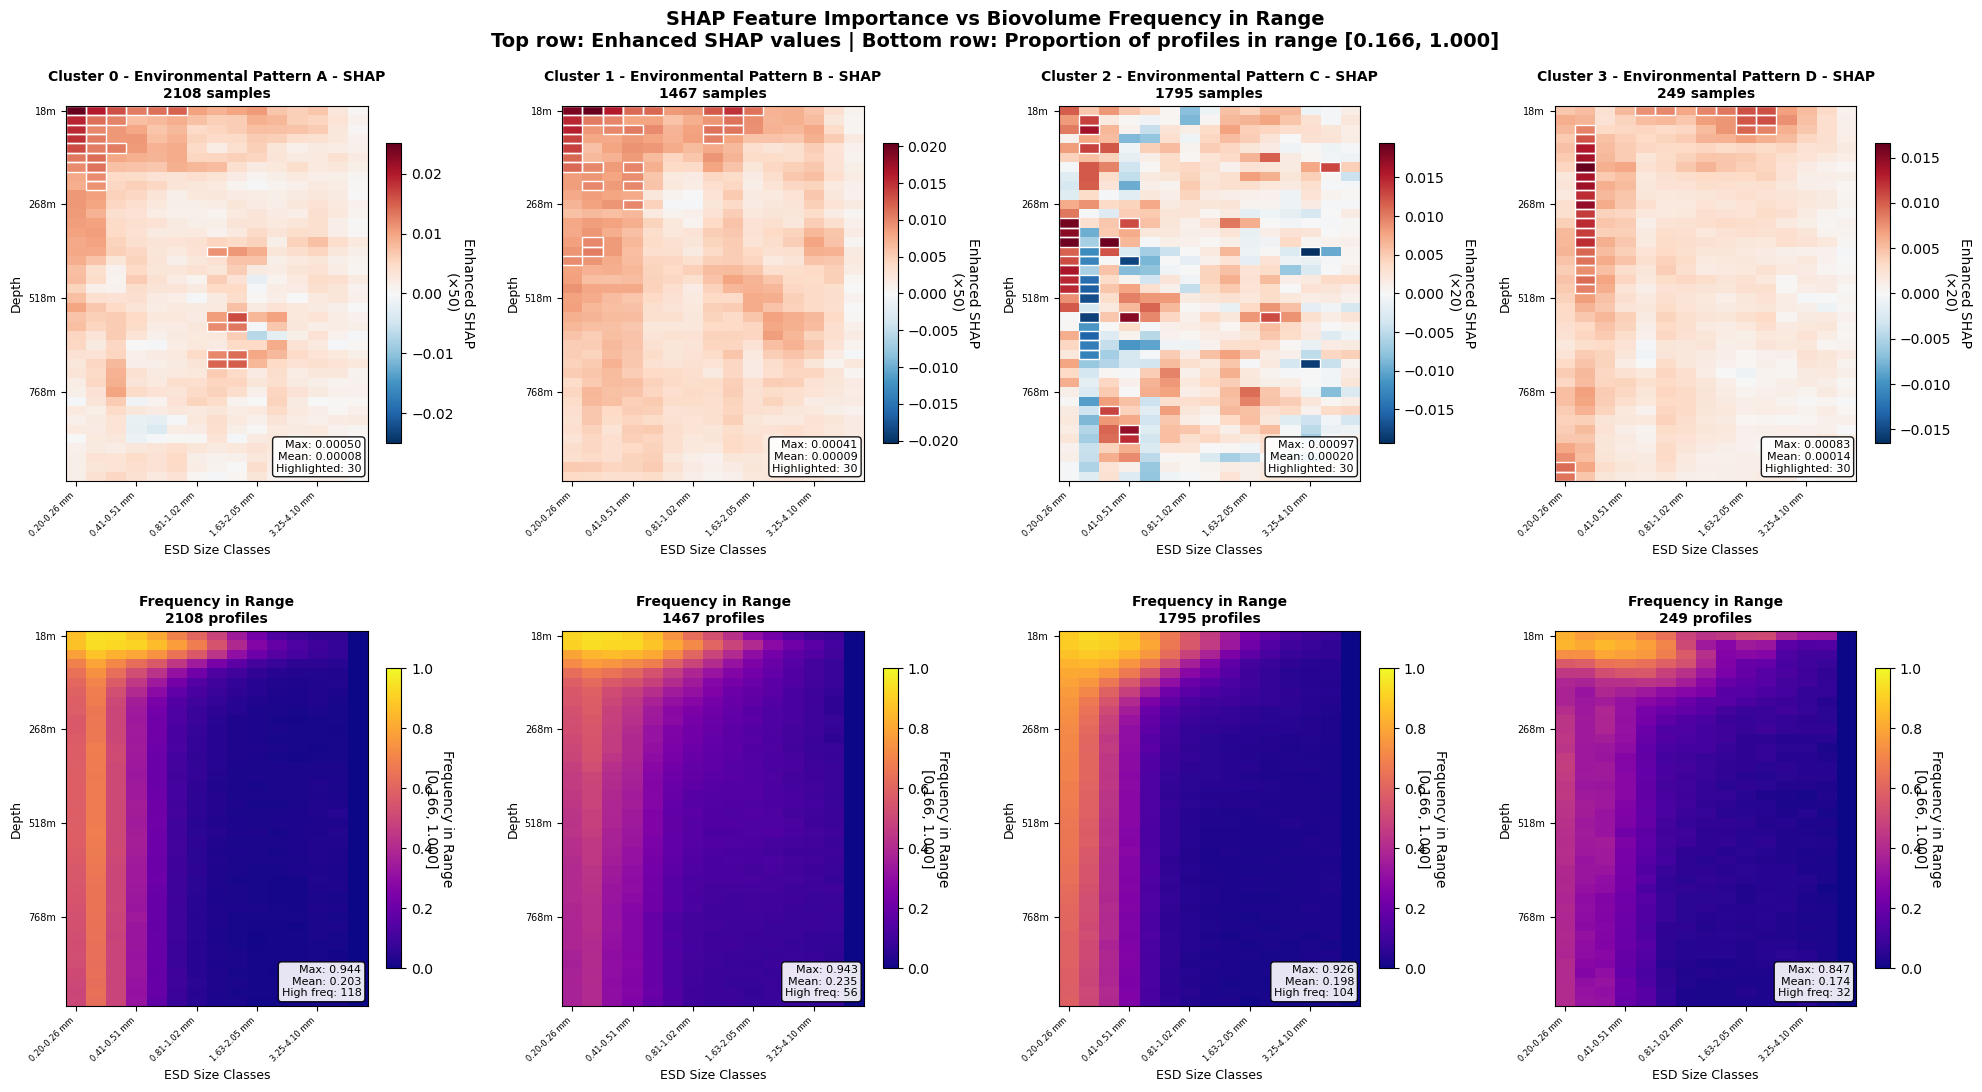


✅ Combined analysis completed with range [0.1659, 1.0000]!
🎨 Created comprehensive comparison:
  • Top row:   SHAP feature importance (what the model learned)
  • Bottom row: Frequency of profiles within biovolume range
🔍 Compare patterns to validate model interpretability!
🌊 Ready for oceanographic interpretation!

📈 Range Frequency Analysis Summary:
  Cluster 0: Mean frequency = 0.203, Max frequency = 0.944
  Cluster 1: Mean frequency = 0.235, Max frequency = 0.943
  Cluster 2: Mean frequency = 0.198, Max frequency = 0.926
  Cluster 3: Mean frequency = 0.174, Max frequency = 0.847


In [88]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from scipy import ndimage
import seaborn as sns
import pandas as pd

# ============================================================================
# CONFIGURABLE PARAMETERS - ADJUST HERE
# ============================================================================

# Analysis Parameters
TOP_N_PIXELS = 20              # Number of top pixels to analyze per cluster
HIGHLIGHT_PERCENTILE = 95      # Percentile for highlighting (95 = top 5%)
SUBSAMPLE_SIZE = None          # Number of samples to randomly subsample per cluster (None = use all)

# NEW:  Biovolume Threshold Parameters
BIOVOLUME_THRESHOLD_LOWER = None  # Lower threshold for biovolume range
BIOVOLUME_THRESHOLD_UPPER = None   # Upper threshold for biovolume range
THRESHOLD_PERCENTILE_LOWER = 70   # Alternative:  use percentile-based lower threshold (e.g., 25 for 25th percentile)
THRESHOLD_PERCENTILE_UPPER = 100   # Alternative: use percentile-based upper threshold (e.g., 75 for 75th percentile)

# Visualization Parameters  
FIGURE_SIZE = (20, 10)         # Size of the main figure
DPI = 300                      # Resolution for saved plots
CONTRAST_MULTIPLIERS = {       # Contrast enhancement per cluster type
    'weak': 50,                # For clusters with very low SHAP values
    'medium': 20,              # For clusters with medium SHAP values  
    'strong': 10               # For clusters with strong SHAP values
}
WEAK_SIGNAL_THRESHOLD = 0.0001 # Threshold to classify as weak signal
MEDIUM_SIGNAL_THRESHOLD = 0.0002 # Threshold to classify as medium signal

# Layout Parameters
STATS_BOX_POSITION = 'bottom_right'  # Position for statistics box
COLORBAR_SHRINK = 0.8               # Size of colorbars
FONT_SIZES = {
    'title': 11,
    'subtitle': 9,
    'stats': 8,
    'suptitle': 13
}

# ============================================================================
# LOAD SAVED SHAP RESULTS
# ============================================================================

def load_latest_shap_results(save_dir="../Data"):
    """Load the most recent SHAP results"""
    from glob import glob
    
    # Find all SHAP result directories
    pattern = os.path.join(save_dir, "shap_results_*")
    shap_dirs = glob(pattern)
    
    if not shap_dirs:
        print("❌ No saved SHAP results found!")
        return None, None, None, None
    
    # Get the most recent directory
    latest_dir = max(shap_dirs, key=os.path. getctime)
    
    # Find the aggregated results file in that directory
    agg_files = glob(os.path.join(latest_dir, "aggregated_shap_only_*.pkl"))
    complete_files = glob(os.path.join(latest_dir, "complete_shap_results_*.pkl"))
    
    if not agg_files or not complete_files:  
        print("❌ SHAP files not found in directory!")
        return None, None, None, None
    
    agg_file = agg_files[0]
    complete_file = complete_files[0]
    
    print(f"📁 Loading SHAP results from:  {latest_dir}")
    print(f"📊 Aggregated file: {os.path.basename(agg_file)}")
    print(f"💾 Complete file: {os. path.basename(complete_file)}")
    
    # Load aggregated results
    with open(agg_file, 'rb') as f:
        aggregated_shap_values = pickle.load(f)
    
    # Load complete results  
    with open(complete_file, 'rb') as f:
        complete_results = pickle.load(f)
    
    all_cluster_samples = complete_results['cluster_samples']
    all_cluster_shap_values = complete_results['cluster_shap_values']
    metadata = complete_results['metadata']
    
    print(f"✅ Loaded SHAP results for {len(aggregated_shap_values)} clusters")
    print(f"📈 Total samples: {metadata['total_samples']}")
    
    return all_cluster_samples, all_cluster_shap_values, aggregated_shap_values, metadata

def get_display_sample_counts(all_cluster_samples, subsample_size):
    """Get sample counts for display (subsampled or full)"""
    
    display_counts = {}
    
    if subsample_size is None:  
        print("📊 Using ALL samples for display")
        for cluster_id, samples in all_cluster_samples.items():
            display_counts[cluster_id] = len(samples)
    else:
        print(f"🎲 Display counts based on {subsample_size} subsample per cluster")
        np.random.seed(42)  # For reproducible display
        
        for cluster_id, samples in all_cluster_samples.items():
            n_available = len(samples)
            n_display = min(subsample_size, n_available)
            display_counts[cluster_id] = n_display
            
            if n_display < n_available:
                print(f"  Cluster {cluster_id}: showing {n_display}/{n_available} samples")
            else:
                print(f"  Cluster {cluster_id}:   showing all {n_available} samples")
    
    return display_counts

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def add_stats_box(ax, stats_dict, position='bottom_right'):
    """Add statistics box to plot"""
    
    stats_text = '\n'.join([f'{key}: {value}' for key, value in stats_dict.items()])
    
    # Determine position
    if position == 'bottom_right':
        x, y = 0.98, 0.02
        ha, va = 'right', 'bottom'
    elif position == 'top_right':
        x, y = 0.98, 0.98  
        ha, va = 'right', 'top'
    elif position == 'bottom_left':         
        x, y = 0.02, 0.02
        ha, va = 'left', 'bottom'
    else:  # top_left
        x, y = 0.02, 0.98
        ha, va = 'left', 'top'
    
    ax.text(x, y, stats_text, transform=ax.transAxes, fontsize=FONT_SIZES['stats'],
           horizontalalignment=ha, verticalalignment=va,
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))

def reshape_shap_to_original_data(shap_2d):
    """
    Reshape SHAP values from 46x46 image back to original data structure
    
    Correct structure based on your image creation:
    - Original data: ~40 depth bins × 15 size classes  
    - Padded:   added rows/cols, then size classes expanded to 3 pixels each
    - Final:   40 depth bins × 15 size classes (after padding adjustments)
    """
    
    # Step 1: Remove padding (adjust based on actual padding used)
    # Your image shows 40x15 final structure, so extract that region
    unpadded = shap_2d[4: 44, 1:46]  # Get 40 rows × 45 cols
    
    # Step 2: Average every 3 horizontal pixels (size classes)  
    h, w = unpadded.shape  # Should be 40 × 45
    reshaped = unpadded.reshape(h, w//3, 3).mean(axis=2)  # 40 × 15
    
    # No transpose needed - already in correct orientation:        
    # 40 depth bins (rows) × 15 size classes (cols)
    
    return reshaped  # 40×15 shape

# ============================================================================
# BIOVOLUME DATA LOADING AND PROCESSING
# ============================================================================

def normalize_by_profile_global_max(df, group_col, columns):
    """
    Normalize biovolume data by profile global max
    (This function matches your original normalization)
    """
    # 1. Relevante Spalten extrahieren
    sub = df[columns]
    
    # 2. Pro Gruppe (Profile) das Spaltenmaximum bestimmen
    group_col_max = df.groupby(group_col)[columns].transform("max")
    
    # 3. Aus diesen Spaltenmaxima das globale Maximum pro Gruppe ableiten
    profile_max = group_col_max.max(axis=1)
    
    # 4. Division durch 0 vermeiden (Profil komplett 0)
    denom = profile_max.replace(0, 1)
    
    # 5. Alles durch diesen Skalar teilen
    normalized = sub.div(denom, axis=0)
    
    # 6. Zurück ins Original-DataFrame schreiben
    df_norm = df.copy()
    df_norm[columns] = normalized
    
    return df_norm

def load_cluster_biovolume_data_fixed():
    """Load original biovolume data and cluster assignments - FIXED VERSION"""
    
    print("📊 Loading original biovolume data and cluster assignments...")
    
    # Load biovolume data
    df = pd.read_pickle('../Data/Biovolume_per_size_class_and_depth_updated.pkl')
    
    # Load hierarchy mapping
    with open('../Data/cnn_hierarchy_config.pkl', 'rb') as f:
        hierarchy_info = pickle.load(f)
    
    # Load cluster assignments - FIXED:   It's a DataFrame, not a dictionary!     
    with open('../Data/Profile_id_to_clusters_v3.pkl', 'rb') as f:
        cluster_data = pickle.load(f)
    
    # Extract the actual data from the DataFrame structure
    profile_ids = cluster_data['Profile_id'].values
    cluster_10_labels = cluster_data['cluster']. values
    
    # Create the actual dictionary mapping
    cluster_assignments = dict(zip(profile_ids, cluster_10_labels))
    
    print(f"✅ Loaded {len(df)} biovolume records")
    print(f"✅ Loaded cluster assignments for {len(cluster_assignments)} profiles")
    print(f"📊 Sample biovolume columns: {[col for col in df.columns if 'Biovolume' in col][: 3]}")
    print(f"📊 Sample Profile_ids in biovolume data: {df['Profile_id'].unique()[:5]}")
    print(f"📊 Sample cluster assignments: {dict(list(cluster_assignments.items())[:5])}")
    
    # Check overlap between biovolume Profile_ids and cluster assignment keys
    biovolume_profiles = set(df['Profile_id'].unique())
    cluster_profiles = set(cluster_assignments.keys())
    overlap = biovolume_profiles.intersection(cluster_profiles)
    print(f"📊 Profiles in biovolume data: {len(biovolume_profiles)}")
    print(f"📊 Profiles in cluster assignments: {len(cluster_profiles)}")  
    print(f"📊 Overlapping profiles: {len(overlap)}")
    
    return df, hierarchy_info, cluster_assignments

def map_to_4clusters_fixed(cluster_10_value, hierarchy_info):
    """Map single 10-cluster label to 4-cluster label - FIXED VERSION"""
    target_level = 'level_2_groups'  # 4 clusters
    hierarchy_mapping = hierarchy_info['level_mappings'][target_level]
    
    # Convert to int for lookup (cluster values are integers)
    cluster_10_int = int(cluster_10_value)
    
    # Find mapping in hierarchy - keys are numpy. int32, values are numpy.int32
    for k, v in hierarchy_mapping.items():
        if int(k) == cluster_10_int:
            return int(v)
    
    # Default to cluster 0 if not found
    print(f"⚠️ Warning: Could not map cluster {cluster_10_int}, defaulting to cluster 0")
    return 0

def calculate_biovolume_frequency_in_range(df, hierarchy_info, cluster_assignments, 
                                          threshold_lower=None, threshold_upper=None,
                                          threshold_percentile_lower=None, threshold_percentile_upper=None):
    """Calculate frequency of profiles with biovolume in specified range - RANGE VERSION"""
    
    print("🧮 Calculating biovolume frequency within range per cluster...")
    
    # Get biovolume columns
    size_cols = [col for col in df. columns if 'Biovolume norm' in col]
    size_cols = size_cols[:-3]  # Remove three largest size bins
    
    print(f"Using {len(size_cols)} biovolume size classes")
    
    # Determine thresholds
    all_biovolume_data = df[size_cols]. values
    positive_biovolume = all_biovolume_data[all_biovolume_data > 0]
    
    if threshold_percentile_lower is not None:
        threshold_lower_value = np.percentile(positive_biovolume, threshold_percentile_lower)
        print(f"Using {threshold_percentile_lower}th percentile lower threshold:  {threshold_lower_value:.4f}")
    else:
        threshold_lower_value = threshold_lower if threshold_lower is not None else BIOVOLUME_THRESHOLD_LOWER
        print(f"Using fixed lower threshold: {threshold_lower_value:.4f}")
    
    if threshold_percentile_upper is not None:
        threshold_upper_value = np.percentile(positive_biovolume, threshold_percentile_upper)
        print(f"Using {threshold_percentile_upper}th percentile upper threshold: {threshold_upper_value:.4f}")
    else:
        threshold_upper_value = threshold_upper if threshold_upper is not None else BIOVOLUME_THRESHOLD_UPPER
        print(f"Using fixed upper threshold: {threshold_upper_value:.4f}")
    
    # Validate thresholds
    if threshold_lower_value >= threshold_upper_value:
        print(f"⚠️ Warning: Lower threshold ({threshold_lower_value:.4f}) >= Upper threshold ({threshold_upper_value:.4f})")
        print("   Adjusting upper threshold to be 10x lower threshold")
        threshold_upper_value = threshold_lower_value * 10
    
    print(f"📊 Final threshold range: [{threshold_lower_value:.4f}, {threshold_upper_value:.4f}]")
    
    # Check available depth bins
    depth_bins = sorted(df['depth_bin'].unique())
    print(f"Available depth bins: {len(depth_bins)} bins, range: {min(depth_bins)} to {max(depth_bins)}")
    
    # Map profile IDs to 4-clusters
    profile_to_4cluster = {}
    mapping_debug = {}
    successful_mappings = 0
    
    for profile_id, cluster_10 in cluster_assignments.items():
        try:
            cluster_4 = map_to_4clusters_fixed(cluster_10, hierarchy_info)
            profile_to_4cluster[profile_id] = cluster_4
            successful_mappings += 1
            
            # Debug: Track mapping
            if cluster_10 not in mapping_debug:
                mapping_debug[cluster_10] = cluster_4
                
        except Exception as e:  
            print(f"⚠️ Error mapping profile {profile_id}: {e}")
            continue
    
    print(f"Successfully mapped {successful_mappings}/{len(cluster_assignments)} profiles")
    print(f"Cluster mapping summary (10-cluster → 4-cluster): {mapping_debug}")
    
    # Add cluster labels to dataframe
    df['cluster_4'] = df['Profile_id'].map(profile_to_4cluster)
    
    # Remove profiles that couldn't be mapped and check what we have
    df_before = len(df)
    df_mapped = df. dropna(subset=['cluster_4'])
    df_mapped['cluster_4'] = df_mapped['cluster_4'].astype(int)
    
    print(f"Biovolume records:   {df_before} → {len(df_mapped)} after cluster mapping")
    if len(df_mapped) > 0:
        print(f"Cluster distribution in biovolume data: {df_mapped['cluster_4'].value_counts().sort_index()}")
    else:
        print("❌ No biovolume data could be mapped to clusters!")
        return {0: None, 1: None, 2: None, 3: None}, profile_to_4cluster, threshold_lower_value, threshold_upper_value
    
    # Calculate frequency of profiles within threshold range for each cluster
    cluster_frequencies = {}
    
    for cluster_id in range(4):
        cluster_data = df_mapped[df_mapped['cluster_4'] == cluster_id]
        
        if len(cluster_data) == 0:
            print(f"⚠️ No biovolume data for cluster {cluster_id}")
            cluster_frequencies[cluster_id] = None
            continue
        
        unique_profiles = cluster_data['Profile_id'].unique()
        n_profiles = len(unique_profiles)
        
        print(f"Cluster {cluster_id}: {len(cluster_data)} biovolume records from {n_profiles} profiles")
        
        # For each depth bin and size class, calculate frequency of profiles within threshold range
        frequency_array = np.zeros((40, 15))  # 40 depth bins × 15 size classes
        
        for depth_idx in range(40):
            depth_data = cluster_data[cluster_data['depth_bin'] == depth_idx]
            
            if len(depth_data) == 0:
                continue
            
            for size_idx, size_col in enumerate(size_cols[: 15]):
                # Get biovolume values for this depth-size combination
                biovolume_values = depth_data[size_col].values
                
                # Count profiles within threshold range
                in_range_mask = (biovolume_values >= threshold_lower_value) & (biovolume_values <= threshold_upper_value)
                n_in_range = np.sum(in_range_mask)
                
                # Calculate frequency (proportion)
                frequency = n_in_range / len(biovolume_values) if len(biovolume_values) > 0 else 0
                frequency_array[depth_idx, size_idx] = frequency
        
        cluster_frequencies[cluster_id] = frequency_array
        
        print(f"  Final frequency array shape: {frequency_array.shape}")
        print(f"  Frequency range: [{frequency_array.min():.3f}, {frequency_array.max():.3f}]")
        print(f"  Mean frequency:  {frequency_array.mean():.3f}")
        print(f"  Non-zero frequencies: {np.count_nonzero(frequency_array)}/{frequency_array.size}")
    
    return cluster_frequencies, profile_to_4cluster, threshold_lower_value, threshold_upper_value

# ============================================================================
# MAIN VISUALIZATION FUNCTION  
# ============================================================================

def create_combined_shap_range_frequency_analysis(aggregated_shap_values, display_counts, metadata, 
                                                 threshold_lower=None, threshold_upper=None,
                                                 threshold_percentile_lower=None, threshold_percentile_upper=None):
    """Create SHAP analysis with biovolume frequency in range - RANGE VERSION"""
    
    print("🎨 Creating combined SHAP and biovolume range frequency analysis...")
    
    # Load biovolume data
    df, hierarchy_info, cluster_assignments = load_cluster_biovolume_data_fixed()
    
    # Apply normalization like in your original code
    size_cols = [col for col in df.columns if 'Biovolume norm' in col]
    size_cols = size_cols[:-3]  # Remove three largest size bins
    
    print("🔄 Applying biovolume normalization...")
    df = normalize_by_profile_global_max(df, "Profile_id", size_cols)
    
    cluster_frequencies, profile_to_4cluster, threshold_lower_value, threshold_upper_value = calculate_biovolume_frequency_in_range(
        df, hierarchy_info, cluster_assignments, threshold_lower, threshold_upper, threshold_percentile_lower, threshold_percentile_upper)
    
    # Define oceanographic labels
    depth_labels = [f"{17.5 + i*25:.0f}m" for i in range(40)]
    size_labels = [
        "0.20-0.26 mm", "0.26-0.32 mm", "0.32-0.41 mm", "0.41-0.51 mm",
        "0.51-0.65 mm", "0.65-0.81 mm", "0.81-1.02 mm", "1.02-1.29 mm",
        "1.29-1.63 mm", "1.63-2.05 mm", "2.05-2.58 mm", "2.58-3.25 mm",
        "3.25-4.10 mm", "4.10-5.16 mm", "5.16-6.50 mm"
    ]
    
    # Calculate cluster stats and reshape
    cluster_stats = {}
    cluster_original_shapes = {}
    
    for cluster_id, shap_data in aggregated_shap_values.items():
        shap_2d = np.mean(shap_data, axis=-1) if shap_data.shape[-1] == 3 else shap_data. squeeze()
        
        # Reshape to original data dimensions
        original_shape = reshape_shap_to_original_data(shap_2d)
        cluster_original_shapes[cluster_id] = original_shape
        
        cluster_stats[cluster_id] = {
            'mean_abs':   np.abs(original_shape).mean(),
            'max_abs':  np.abs(original_shape).max(),
            'std':   np.abs(original_shape).std(),
            'range': [original_shape.min(), original_shape.max()],
            'data':   original_shape
        }
        
        print(f"Cluster {cluster_id}: Shape {original_shape.shape}, Mean|SHAP|={cluster_stats[cluster_id]['mean_abs']:.6f}")
    
    # Create figure with 2 rows per cluster (SHAP + Frequency)
    fig, axes = plt.subplots(2, 4, figsize=(20, 12))
    
    cluster_names = [
        'Cluster 0 - Environmental Pattern A',
        'Cluster 1 - Environmental Pattern B', 
        'Cluster 2 - Environmental Pattern C',
        'Cluster 3 - Environmental Pattern D'
    ]
    
    for cluster_id in range(4):
        if cluster_id not in cluster_stats:
            continue
        
        # SHAP subplot (top row)
        ax_shap = axes[0, cluster_id]
        stats = cluster_stats[cluster_id]
        original_data = stats['data']
        
        # Determine contrast multiplier
        if stats['mean_abs'] < WEAK_SIGNAL_THRESHOLD:      
            contrast_multiplier = CONTRAST_MULTIPLIERS['weak']
        elif stats['mean_abs'] < MEDIUM_SIGNAL_THRESHOLD:  
            contrast_multiplier = CONTRAST_MULTIPLIERS['medium']
        else:
            contrast_multiplier = CONTRAST_MULTIPLIERS['strong']
        
        # Apply contrast enhancement
        enhanced_data = original_data * contrast_multiplier
        vmax_enhanced = np.abs(enhanced_data).max()
        
        # Create SHAP plot
        im_shap = ax_shap. imshow(enhanced_data, cmap='RdBu_r', vmin=-vmax_enhanced, vmax=vmax_enhanced,
                                aspect='auto', origin='upper')
        
        # Add highlighting for most important features
        threshold_shap = np.percentile(np.abs(original_data).flatten(), HIGHLIGHT_PERCENTILE)
        highlight_mask = np.abs(original_data) > threshold_shap
        
        n_highlighted = 0
        if highlight_mask.any():
            rows, cols = np.where(highlight_mask)
            for r, c in zip(rows, cols):
                rect = Rectangle((c-0.5, r-0.5), 1, 1, fill=False, 
                               edgecolor='white', linewidth=1.0, clip_on=False)
                ax_shap.add_patch(rect)
            n_highlighted = len(rows)
        
        # SHAP colorbar
        cbar_shap = plt.colorbar(im_shap, ax=ax_shap, shrink=0.8)
        cbar_shap.set_label(f'Enhanced SHAP\n(×{contrast_multiplier})', rotation=270, labelpad=15)
        
        # SHAP title
        n_display = display_counts. get(cluster_id, 0)
        total_samples = metadata['cluster_sample_counts'].get(cluster_id, 0)
        
        if SUBSAMPLE_SIZE and n_display < total_samples:
            sample_text = f'{n_display}/{total_samples} samples'
        else:
            sample_text = f'{total_samples} samples'
        
        ax_shap.set_title(f'{cluster_names[cluster_id]} - SHAP\n{sample_text}', 
                         fontsize=10, fontweight='bold')
        
        # SHAP axis labels and ticks
        ax_shap.set_xlabel('ESD Size Classes', fontsize=9)
        ax_shap.set_ylabel('Depth', fontsize=9)
        
        x_tick_positions = np.arange(0, 15, 3)
        x_tick_labels = [size_labels[i] for i in x_tick_positions]
        ax_shap.set_xticks(x_tick_positions)
        ax_shap.set_xticklabels(x_tick_labels, rotation=45, ha='right', fontsize=6)
        
        y_tick_positions = np.arange(0, 40, 10)
        y_tick_labels = [depth_labels[i] for i in y_tick_positions]
        ax_shap.set_yticks(y_tick_positions)
        ax_shap.set_yticklabels(y_tick_labels, fontsize=7)
        
        # SHAP statistics box
        stats_dict = {
            'Max':   f'{stats["max_abs"]:.5f}',
            'Mean':  f'{stats["mean_abs"]:.5f}',
            'Highlighted': f'{n_highlighted}'
        }
        add_stats_box(ax_shap, stats_dict, 'bottom_right')
        
        # Frequency subplot (bottom row)
        ax_freq = axes[1, cluster_id]
        
        if cluster_frequencies[cluster_id] is not None:  
            frequency_data = cluster_frequencies[cluster_id]
            
            print(f"📊 Plotting frequency for cluster {cluster_id}:   shape {frequency_data.shape}, range [{frequency_data.min():.3f}, {frequency_data.max():.3f}]")
            
            # Create frequency plot with different colormap for better visibility
            im_freq = ax_freq.imshow(frequency_data, cmap='plasma', aspect='auto', origin='upper', vmin=0, vmax=1)
            
            # Frequency colorbar
            cbar_freq = plt.colorbar(im_freq, ax=ax_freq, shrink=0.8)
            cbar_freq.set_label(f'Frequency in Range\n[{threshold_lower_value:.3f}, {threshold_upper_value:.3f}]', 
                               rotation=270, labelpad=15)
            
            # Count unique profiles for this cluster
            cluster_profiles = [pid for pid, cid in profile_to_4cluster.items() if cid == cluster_id]
            
            ax_freq.set_title(f'Frequency in Range\n{len(cluster_profiles)} profiles', 
                            fontsize=10, fontweight='bold')
            
            # Frequency axis labels and ticks
            ax_freq.set_xlabel('ESD Size Classes', fontsize=9)
            ax_freq.set_ylabel('Depth', fontsize=9)
            ax_freq.set_xticks(x_tick_positions)
            ax_freq.set_xticklabels(x_tick_labels, rotation=45, ha='right', fontsize=6)
            ax_freq.set_yticks(y_tick_positions)
            ax_freq.set_yticklabels(y_tick_labels, fontsize=7)
            
            # Frequency statistics
            freq_stats = {
                'Max':  f'{frequency_data.max():.3f}',
                'Mean':   f'{frequency_data.mean():.3f}',
                'High freq': f'{np.sum(frequency_data > 0.5)}'
            }
            add_stats_box(ax_freq, freq_stats, 'bottom_right')
            
        else:
            ax_freq.text(0.5, 0.5, 'No biovolume\ndata available', 
                       ha='center', va='center', transform=ax_freq.transAxes, fontsize=12)
            ax_freq.set_title(f'Frequency in Range\n(No data)', fontsize=10, fontweight='bold')
            ax_freq.axis('off')
    
    # Main title
    range_text = f"[{threshold_lower_value:.3f}, {threshold_upper_value:.3f}]"
    fig.suptitle(f'SHAP Feature Importance vs Biovolume Frequency in Range\n'
                f'Top row: Enhanced SHAP values | Bottom row: Proportion of profiles in range {range_text}', 
                fontsize=14, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.90, bottom=0.15, hspace=0.4)
    
    # Save plot
    timestamp = metadata.get('timestamp', 'unknown')
    subsample_suffix = f'_display{SUBSAMPLE_SIZE}' if SUBSAMPLE_SIZE else '_allsamples'
    range_suffix = f'_range{threshold_lower_value:.3f}to{threshold_upper_value:.3f}'. replace('.', 'p')
    filename = f'combined_shap_range_frequency_analysis_{timestamp}{subsample_suffix}{range_suffix}.png'
    plt.savefig(filename, dpi=DPI, bbox_inches='tight')
    print(f"💾 Combined SHAP-range frequency analysis saved:   {filename}")
    
    plt.show()
    
    return cluster_original_shapes, cluster_frequencies, threshold_lower_value, threshold_upper_value

# ============================================================================
# USAGE
# ============================================================================

print("🎨 SHAP + Biovolume Range Frequency Analysis")
print("=" * 60)
print(f"📊 Configuration:")
print(f"  • Lower threshold: {BIOVOLUME_THRESHOLD_LOWER}")
print(f"  • Upper threshold: {BIOVOLUME_THRESHOLD_UPPER}")
print(f"  • Lower percentile: {THRESHOLD_PERCENTILE_LOWER}")
print(f"  • Upper percentile: {THRESHOLD_PERCENTILE_UPPER}")
print(f"  • Highlight percentile: {HIGHLIGHT_PERCENTILE}% (top {100-HIGHLIGHT_PERCENTILE}%)")
print(f"  • Subsample size: {SUBSAMPLE_SIZE if SUBSAMPLE_SIZE else 'All samples'}")
print(f"  • Figure size: (20, 12)")
print(f"  • DPI: {DPI}")
print("=" * 60)

# Load the saved SHAP results
all_cluster_samples, all_cluster_shap_values, aggregated_shap_values, metadata = load_latest_shap_results()

if aggregated_shap_values is not None:
    # Get display sample counts
    display_counts = get_display_sample_counts(all_cluster_samples, SUBSAMPLE_SIZE)
    
    print("\n🚀 Creating combined SHAP and biovolume range frequency analysis...")
    print("🔄 Loading original biovolume data and cluster assignments")
    print("📊 Computing frequency of profiles within biovolume range per cluster")
    
    # Create the combined visualization
    cluster_original_shapes, cluster_frequencies, used_lower, used_upper = create_combined_shap_range_frequency_analysis(
        aggregated_shap_values, display_counts, metadata, 
        threshold_lower=BIOVOLUME_THRESHOLD_LOWER, threshold_upper=BIOVOLUME_THRESHOLD_UPPER,
        threshold_percentile_lower=THRESHOLD_PERCENTILE_LOWER, threshold_percentile_upper=THRESHOLD_PERCENTILE_UPPER
    )
    
    print(f"\n✅ Combined analysis completed with range [{used_lower:.4f}, {used_upper:.4f}]!")
    print("🎨 Created comprehensive comparison:")
    print("  • Top row:   SHAP feature importance (what the model learned)")
    print("  • Bottom row: Frequency of profiles within biovolume range")
    print("🔍 Compare patterns to validate model interpretability!")
    print("🌊 Ready for oceanographic interpretation!")
    
    # Print some summary statistics
    print(f"\n📈 Range Frequency Analysis Summary:")
    for cluster_id in range(4):
        if cluster_frequencies[cluster_id] is not None: 
            freq_data = cluster_frequencies[cluster_id]
            print(f"  Cluster {cluster_id}: Mean frequency = {freq_data.mean():.3f}, Max frequency = {freq_data.max():.3f}")
    
else:
    print("❌ Could not load SHAP results.   Please check the file path.")


🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬
   COMPREHENSIVE SHAP FEATURE ANALYSIS
🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬
🔍 Analyzing Top 10 SHAP Features for Each Cluster

📊 CLUSTER 0 - Top 10 Most Important Features:
--------------------------------------------------
   1.      18m × 0.20-0.26 mm | SHAP: +0.00050 | Positive effect
   2.      18m × 0.26-0.32 mm | SHAP: +0.00039 | Positive effect
   3.      42m × 0.20-0.26 mm | SHAP: +0.00038 | Positive effect
   4.      68m × 0.20-0.26 mm | SHAP: +0.00037 | Positive effect
   5.      92m × 0.20-0.26 mm | SHAP: +0.00037 | Positive effect
   6.     118m × 0.20-0.26 mm | SHAP: +0.00033 | Positive effect
   7.     568m × 1.29-1.63 mm | SHAP: +0.00033 | Positive effect
   8.      18m × 0.32-0.41 mm | SHAP: +0.00032 | Positive effect
   9.     692m × 1.29-1.63 mm | SHAP: +0.00030 | Positive effect
  10.      18m × 0.65-0.81 mm | SHAP: +0.00030 | Positive effect

     Summary: 10 positive, 0 negative effects
     SHAP ran

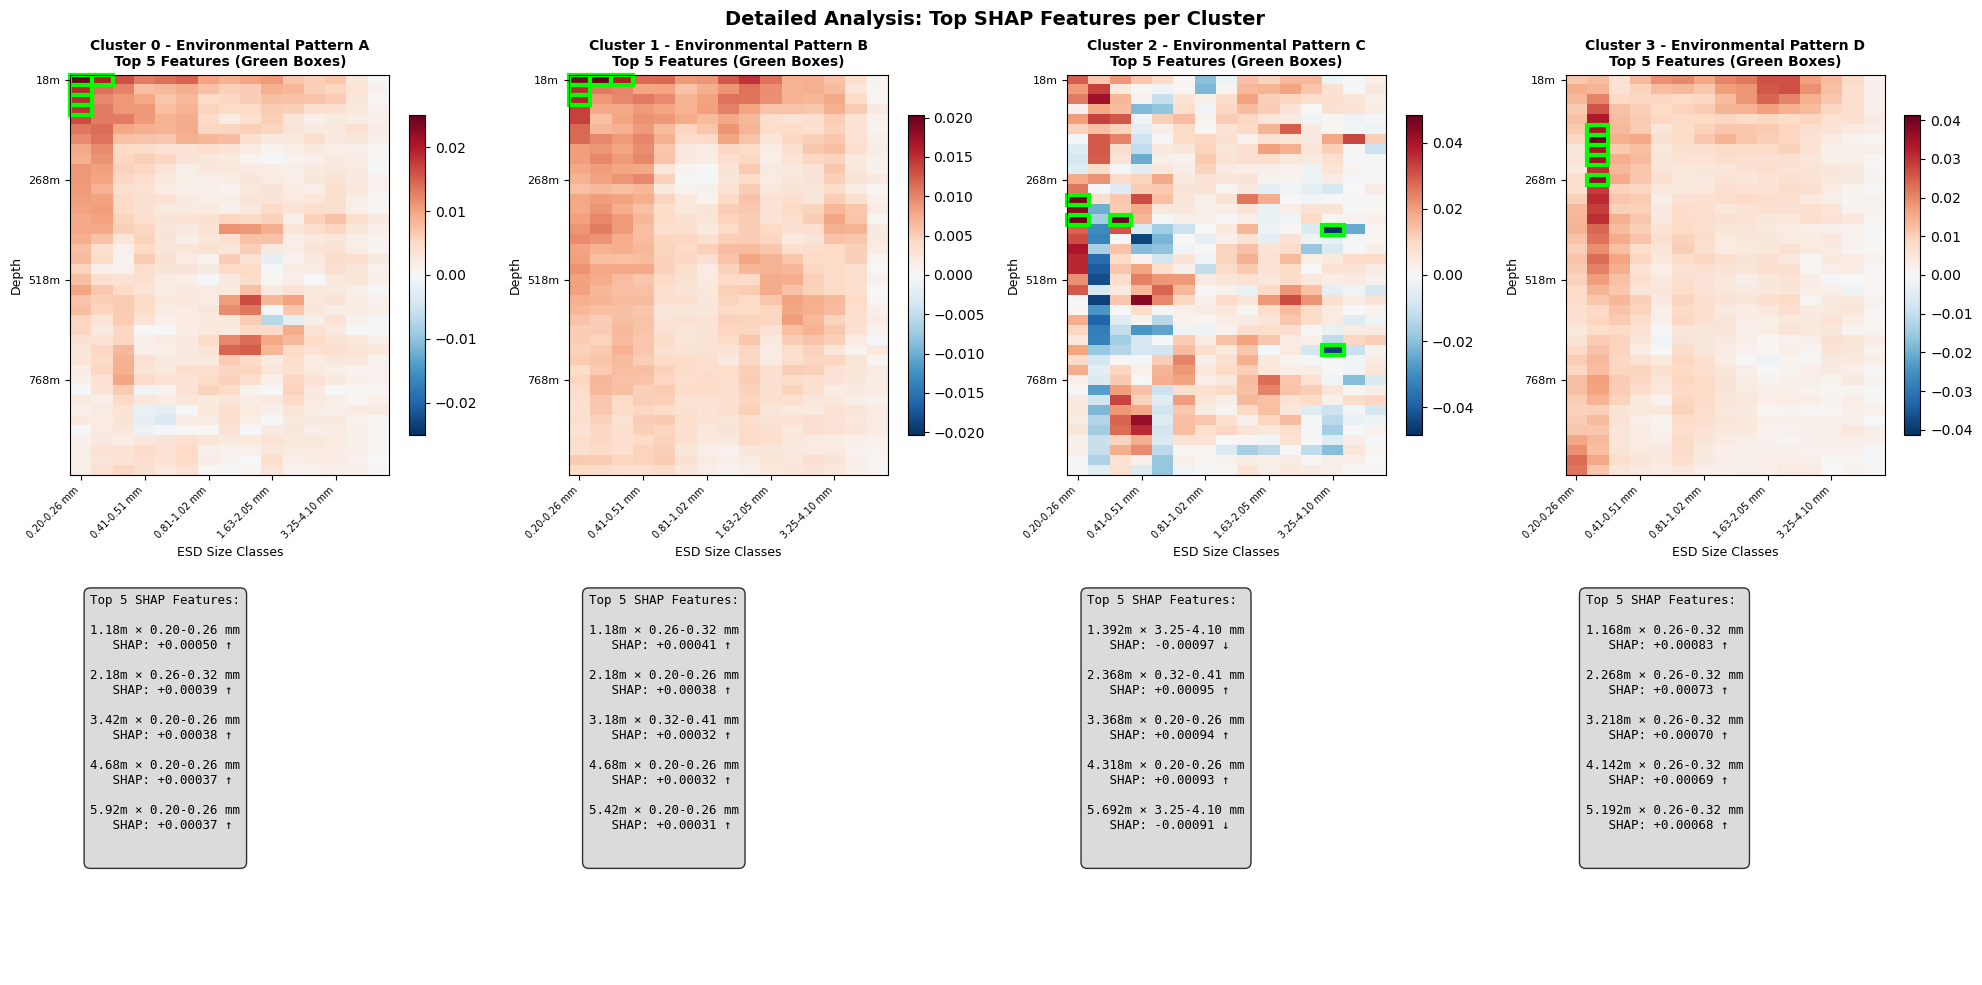

In [90]:
def analyze_top_shap_features(aggregated_shap_values, top_n=10):
    """Analyze the top SHAP features for each cluster in detail"""
    
    print(f"🔍 Analyzing Top {top_n} SHAP Features for Each Cluster")
    print("=" * 70)
    
    # Define oceanographic labels
    depth_labels = [f"{17.5 + i*25:.0f}m" for i in range(40)]
    size_labels = [
        "0.20-0.26 mm", "0.26-0.32 mm", "0.32-0.41 mm", "0.41-0.51 mm",
        "0.51-0.65 mm", "0.65-0.81 mm", "0.81-1.02 mm", "1.02-1.29 mm",
        "1.29-1.63 mm", "1.63-2.05 mm", "2.05-2.58 mm", "2.58-3.25 mm",
        "3.25-4.10 mm", "4.10-5.16 mm", "5.16-6.50 mm"
    ]
    
    cluster_top_features = {}
    
    for cluster_id, shap_data in aggregated_shap_values.items():
        print(f"\n📊 CLUSTER {cluster_id} - Top {top_n} Most Important Features:")
        print("-" * 50)
        
        # Reshape to original data dimensions
        shap_2d = np.mean(shap_data, axis=-1) if shap_data.shape[-1] == 3 else shap_data. squeeze()
        original_shape = reshape_shap_to_original_data(shap_2d)
        
        # Get absolute SHAP values
        abs_shap = np.abs(original_shape)
        
        # Find top N features
        flat_indices = np.argpartition(abs_shap. flatten(), -top_n)[-top_n:]
        top_indices = np.unravel_index(flat_indices, abs_shap.shape)
        
        # Sort by SHAP value magnitude
        sort_order = np.argsort(abs_shap[top_indices])[::-1]
        
        top_features = []
        
        for i, idx in enumerate(sort_order):
            depth_idx = top_indices[0][idx]
            size_idx = top_indices[1][idx]
            
            shap_value = original_shape[depth_idx, size_idx]
            abs_shap_value = abs_shap[depth_idx, size_idx]
            
            feature_info = {
                'rank': i + 1,
                'depth_idx': depth_idx,
                'size_idx': size_idx,
                'depth_label': depth_labels[depth_idx] if depth_idx < len(depth_labels) else f"D{depth_idx}",
                'size_label': size_labels[size_idx] if size_idx < len(size_labels) else f"S{size_idx}",
                'shap_value': shap_value,
                'abs_shap_value': abs_shap_value,
                'effect':  'Positive' if shap_value > 0 else 'Negative'
            }
            
            top_features.append(feature_info)
            
            print(f"  {i+1:2d}. {feature_info['depth_label']: >8} × {feature_info['size_label']:<12} | "
                  f"SHAP: {shap_value:>+8.5f} | {feature_info['effect']} effect")
        
        cluster_top_features[cluster_id] = top_features
        
        # Summary statistics
        positive_count = sum(1 for f in top_features if f['shap_value'] > 0)
        negative_count = len(top_features) - positive_count
        
        print(f"\n     Summary: {positive_count} positive, {negative_count} negative effects")
        print(f"     SHAP range: {min(f['shap_value'] for f in top_features):+.5f} to {max(f['shap_value'] for f in top_features):+.5f}")
    
    return cluster_top_features

def compare_top_features_across_clusters(cluster_top_features):
    """Compare top features across all clusters"""
    
    print(f"\n🔄 CROSS-CLUSTER COMPARISON")
    print("=" * 70)
    
    # Find common depth and size ranges
    all_depths = set()
    all_sizes = set()
    
    for cluster_id, features in cluster_top_features.items():
        for feature in features: 
            all_depths.add(feature['depth_idx'])
            all_sizes.add(feature['size_idx'])
    
    print(f"🌊 Most important depth levels across all clusters: {sorted(all_depths)}")
    print(f"🦠 Most important size classes across all clusters: {sorted(all_sizes)}")
    
    # Find unique vs shared important features
    print(f"\n📋 Cluster-specific vs Shared Important Features:")
    
    for cluster_id, features in cluster_top_features.items():
        cluster_coords = {(f['depth_idx'], f['size_idx']) for f in features[: 5]}  # Top 5
        
        unique_to_cluster = []
        shared_with_others = []
        
        for coord in cluster_coords:
            other_clusters_with_coord = []
            for other_id, other_features in cluster_top_features.items():
                if other_id != cluster_id: 
                    other_coords = {(f['depth_idx'], f['size_idx']) for f in other_features[: 5]}
                    if coord in other_coords:
                        other_clusters_with_coord.append(other_id)
            
            if other_clusters_with_coord: 
                shared_with_others.append((coord, other_clusters_with_coord))
            else:
                unique_to_cluster.append(coord)
        
        print(f"\n  Cluster {cluster_id}:")
        print(f"    Unique features: {len(unique_to_cluster)}")
        for coord in unique_to_cluster: 
            depth_idx, size_idx = coord
            print(f"      - Depth {depth_idx} × Size {size_idx}")
        
        print(f"    Shared features: {len(shared_with_others)}")
        for coord, shared_with in shared_with_others:
            depth_idx, size_idx = coord
            print(f"      - Depth {depth_idx} × Size {size_idx} (also important in clusters {shared_with})")

def extract_biovolume_at_top_shap_features_detailed():
    """Extract biovolume values at top SHAP locations - STANDALONE VERSION"""
    
    print(f"\n🧬 BIOVOLUME VALUES AT TOP SHAP FEATURES")
    print("=" * 70)
    
    # Load fresh data to get the mapping
    df, hierarchy_info, cluster_assignments = load_cluster_biovolume_data_fixed()
    
    # Apply normalization
    size_cols = [col for col in df. columns if 'Biovolume norm' in col]
    size_cols = size_cols[:-3]
    df = normalize_by_profile_global_max(df, "Profile_id", size_cols)
    
    # Recreate profile mapping
    profile_to_4cluster = {}
    for profile_id, cluster_10 in cluster_assignments.items():
        try:
            cluster_4 = map_to_4clusters_fixed(cluster_10, hierarchy_info)
            profile_to_4cluster[profile_id] = cluster_4
        except: 
            continue
    
    df['cluster_4'] = df['Profile_id'].map(profile_to_4cluster)
    df_mapped = df.dropna(subset=['cluster_4'])
    df_mapped['cluster_4'] = df_mapped['cluster_4'].astype(int)
    
    return df_mapped, size_cols, profile_to_4cluster

def analyze_biovolume_at_shap_features(cluster_top_features, top_n=5):
    """Analyze biovolume values at top SHAP feature locations"""
    
    df_mapped, size_cols, profile_to_4cluster = extract_biovolume_at_top_shap_features_detailed()
    
    for cluster_id, features in cluster_top_features.items():
        print(f"\n📊 CLUSTER {cluster_id} - Biovolume at Top {top_n} SHAP Features:")
        print("-" * 60)
        
        # Get profiles for this cluster
        cluster_data = df_mapped[df_mapped['cluster_4'] == cluster_id]
        
        for i, feature in enumerate(features[: top_n]):
            depth_idx = feature['depth_idx']
            size_idx = feature['size_idx']
            
            if size_idx < len(size_cols):
                size_col = size_cols[size_idx]
                
                # Get biovolume values for this depth-size combination
                depth_size_data = cluster_data[
                    (cluster_data['depth_bin'] == depth_idx)
                ][size_col]
                
                if len(depth_size_data) > 0:
                    stats = {
                        'count': len(depth_size_data),
                        'mean': depth_size_data.mean(),
                        'median': depth_size_data.median(),
                        'std': depth_size_data.std(),
                        'min': depth_size_data.min(),
                        'max': depth_size_data.max(),
                        'nonzero_count': (depth_size_data > 0).sum(),
                        'nonzero_fraction': (depth_size_data > 0).mean()
                    }
                    
                    print(f"  {i+1}.{feature['depth_label']} × {feature['size_label']} (SHAP: {feature['shap_value']:+.5f})")
                    print(f"     Profiles: {stats['count']}, Mean: {stats['mean']:.4f}, Median: {stats['median']:.4f}")
                    print(f"     Non-zero: {stats['nonzero_count']}/{stats['count']} ({stats['nonzero_fraction']:.1%})")
                    print(f"     Range: [{stats['min']:.4f}, {stats['max']:.4f}], Std: {stats['std']:.4f}")
                else:
                    print(f"  {i+1}.{feature['depth_label']} × {feature['size_label']} (SHAP: {feature['shap_value']:+.5f})")
                    print(f"     No data available for this depth-size combination")

def visualize_top_shap_heatmap(cluster_top_features, aggregated_shap_values, top_n=5):
    """Create focused heatmap of just the top SHAP features"""
    
    print(f"\n🎨 Creating focused visualization of top {top_n} SHAP features per cluster...")
    
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    cluster_names = [
        'Cluster 0 - Environmental Pattern A',
        'Cluster 1 - Environmental Pattern B', 
        'Cluster 2 - Environmental Pattern C',
        'Cluster 3 - Environmental Pattern D'
    ]
    
    depth_labels = [f"{17.5 + i*25:.0f}m" for i in range(40)]
    size_labels = [
        "0.20-0.26 mm", "0.26-0.32 mm", "0.32-0.41 mm", "0.41-0.51 mm",
        "0.51-0.65 mm", "0.65-0.81 mm", "0.81-1.02 mm", "1.02-1.29 mm",
        "1.29-1.63 mm", "1.63-2.05 mm", "2.05-2.58 mm", "2.58-3.25 mm",
        "3.25-4.10 mm", "4.10-5.16 mm", "5.16-6.50 mm"
    ]
    
    for cluster_id in range(4):
        if cluster_id not in cluster_top_features: 
            continue
        
        # Original SHAP heatmap (top row)
        ax_shap = axes[0, cluster_id]
        shap_2d = np.mean(aggregated_shap_values[cluster_id], axis=-1) if aggregated_shap_values[cluster_id].shape[-1] == 3 else aggregated_shap_values[cluster_id].squeeze()
        original_shape = reshape_shap_to_original_data(shap_2d)
        
        # Enhanced contrast
        enhanced_data = original_shape * 50  # Use strong contrast
        vmax_enhanced = np.abs(enhanced_data).max()
        
        im_shap = ax_shap. imshow(enhanced_data, cmap='RdBu_r', vmin=-vmax_enhanced, vmax=vmax_enhanced,
                                aspect='auto', origin='upper')
        
        # Highlight top features
        features = cluster_top_features[cluster_id][: top_n]
        for feature in features:
            rect = Rectangle((feature['size_idx']-0.5, feature['depth_idx']-0.5), 1, 1, 
                           fill=False, edgecolor='lime', linewidth=3, clip_on=False)
            ax_shap.add_patch(rect)
        
        ax_shap.set_title(f'{cluster_names[cluster_id]}\nTop {top_n} Features (Green Boxes)', 
                         fontsize=10, fontweight='bold')
        ax_shap.set_xlabel('ESD Size Classes', fontsize=9)
        ax_shap.set_ylabel('Depth', fontsize=9)
        
        # Tick labels
        x_ticks = np.arange(0, 15, 3)
        y_ticks = np.arange(0, 40, 10)
        ax_shap.set_xticks(x_ticks)
        ax_shap.set_xticklabels([size_labels[i] for i in x_ticks], rotation=45, ha='right', fontsize=7)
        ax_shap.set_yticks(y_ticks)
        ax_shap.set_yticklabels([depth_labels[i] for i in y_ticks], fontsize=8)
        
        plt.colorbar(im_shap, ax=ax_shap, shrink=0.8)
        
        # Feature list (bottom row)
        ax_list = axes[1, cluster_id]
        ax_list.axis('off')
        
        # Create text list of top features
        feature_text = f"Top {top_n} SHAP Features:\n\n"
        for i, feature in enumerate(features):
            effect_symbol = "↑" if feature['shap_value'] > 0 else "↓"
            feature_text += f"{i+1}.{feature['depth_label']} × {feature['size_label']}\n"
            feature_text += f"   SHAP: {feature['shap_value']:+.5f} {effect_symbol}\n\n"
        
        ax_list.text(0.05, 0.95, feature_text, transform=ax_list.transAxes, 
                    fontsize=9, verticalalignment='top', fontfamily='monospace',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8))
    
    fig.suptitle('Detailed Analysis: Top SHAP Features per Cluster', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

def create_complete_shap_analysis(aggregated_shap_values, top_n=10):
    """Complete SHAP analysis - STANDALONE VERSION"""
    
    print("\n" + "🔬" * 50)
    print("   COMPREHENSIVE SHAP FEATURE ANALYSIS")
    print("🔬" * 50)
    
    # Step 1: Analyze top features
    cluster_top_features = analyze_top_shap_features(aggregated_shap_values, top_n)
    
    # Step 2: Compare across clusters
    compare_top_features_across_clusters(cluster_top_features)
    
    # Step 3: Analyze biovolume at top SHAP locations
    analyze_biovolume_at_shap_features(cluster_top_features, top_n=5)
    
    # Step 4: Create focused visualization
    visualize_top_shap_heatmap(cluster_top_features, aggregated_shap_values, top_n=5)
    
    return cluster_top_features

# Run the analysis
if aggregated_shap_values is not None: 
    cluster_top_features = create_complete_shap_analysis(aggregated_shap_values, top_n=10)
else:
    print("❌ Please run the SHAP loading code first.")

# Hyperparameter Tuning

[Discuss any hyperparameter tuning methods you've applied, such as Grid Search or Random Search, and the rationale behind them.]


in anaconda prompt, install ray tune: pip install "ray[tune]" optuna

In [ ]:
######################## Initialize classifier and load all data ###############################

print("🚀 Initializing HeatmapCNNClassifier and loading data...")

# Initialize the classifier
classifier = HeatmapCNNClassifier()

# Load data assignments (pickle files)
print("\n📁 Step 1: Loading data assignments...")
classifier.load_data_assignments()

# Load heatmap images
print("\n🖼️ Step 2: Loading heatmap images...")
classifier.load_heatmaps()

# Split into train/test sets
print("\n📊 Step 3: Splitting train/test data...")
classifier.split_train_test()

# Balance classes per fold
print("\n⚖️ Step 4: Balancing classes per fold...")
# Choose one of the balancing methods:
# Option 1: Simple over/undersampling (faster, more predictable)
classifier.balance_classes_per_fold_simple()

# Option 2:  SMOTE-Tomek (more sophisticated but slower)
# classifier.balance_classes_per_fold_SMOTETomek()

# Scale the data
print("\n📏 Step 5: Scaling pixel data...")
classifier.scale_data()

# Verify everything is set up correctly
print("\n✅ Data setup verification:")
print(f"  Training data shape: {classifier.X_train_scaled.shape}")
print(f"  Test data shape: {classifier.X_test_scaled.shape}")
print(f"  Number of classes: {classifier.n_classes}")
print(f"  Class labels: {classifier.label_encoder.classes_}")
print(f"  CV folds available: {list(classifier.fold_balanced_data.keys())}")
print(f"  fold_balanced_data structure: ✅ Ready for optimization")

# Show sample fold data to verify structure
sample_fold = list(classifier.fold_balanced_data.keys())[0]
sample_data = classifier.fold_balanced_data[sample_fold]
print(f"\n📋 Sample fold ({sample_fold}) data:")
print(f"  X_train_scaled shape: {sample_data['X_train_scaled'].shape}")
print(f"  y_train shape: {sample_data['y_train'].shape}")
print(f"  X_val_scaled shape: {sample_data['X_val_scaled'].shape}")
print(f"  y_val shape: {sample_data['y_val'].shape}")

print("\n🎯 Classifier is now ready for hyperparameter optimization!")
print("You can now run:")
print("  best_config, results = classifier.optimize_hyperparameters_smart()")

🚀 Initializing HeatmapCNNClassifier and loading data...

📁 Step 1: Loading data assignments...
Loading data assignments...
Train/test DataFrame shape: (5619, 3)
Clusters DataFrame shape: (5619, 4)
Train/test columns: ['Profile_id', 'data_type', 'CV_fold']
Clusters columns:  ['Profile_id', 'cluster', 'cluster_4', 'cluster_6']
Loaded assignments for 5619 profiles
Loaded cluster assignments for 5619 profiles
Sample train/test data for profile s033:  {'data_type': 'test', 'CV_fold': ''}
Sample cluster data for profile s033:  {'cluster': 1, 'cluster_4': 1, 'cluster_6': 2}

🖼️ Step 2: Loading heatmap images...
Loading heatmap images...
Found 5619 PNG files in ..\Data\heatmaps
Sample filenames: ['0000a_WMO5906623_recovery_profiles.png', '0002a_WMO5906623_recovery_profiles.png', '0003a_WMO5906623_recovery_profiles.png', '0003a_WMO6904139_recovery.png', '0004a_WMO6903096.png']
Sample extracted profile IDs: ['0000a_WMO5906623_recovery_profiles', '0002a_WMO5906623_recovery_profiles', '0003a_WMO59

Starting Heatmap CNN Classification Pipeline
Loading data assignments...
Train/test DataFrame shape: (5619, 3)
Clusters DataFrame shape: (5619, 4)
Train/test columns: ['Profile_id', 'data_type', 'CV_fold']
Clusters columns:  ['Profile_id', 'cluster', 'cluster_4', 'cluster_6']
Loaded assignments for 5619 profiles
Loaded cluster assignments for 5619 profiles
Sample train/test data for profile s033:  {'data_type': 'test', 'CV_fold': ''}
Sample cluster data for profile s033:  {'cluster': 1, 'cluster_4': 1, 'cluster_6': 2}
Loading heatmap images...
Found 5619 PNG files in ..\Data\heatmaps
Sample filenames: ['0000a_WMO5906623_recovery_profiles.png', '0002a_WMO5906623_recovery_profiles.png', '0003a_WMO5906623_recovery_profiles.png', '0003a_WMO6904139_recovery.png', '0004a_WMO6903096.png']
Sample extracted profile IDs: ['0000a_WMO5906623_recovery_profiles', '0002a_WMO5906623_recovery_profiles', '0003a_WMO5906623_recovery_profiles', '0003a_WMO6904139_recovery', '0004a_WMO6903096']
Available pro

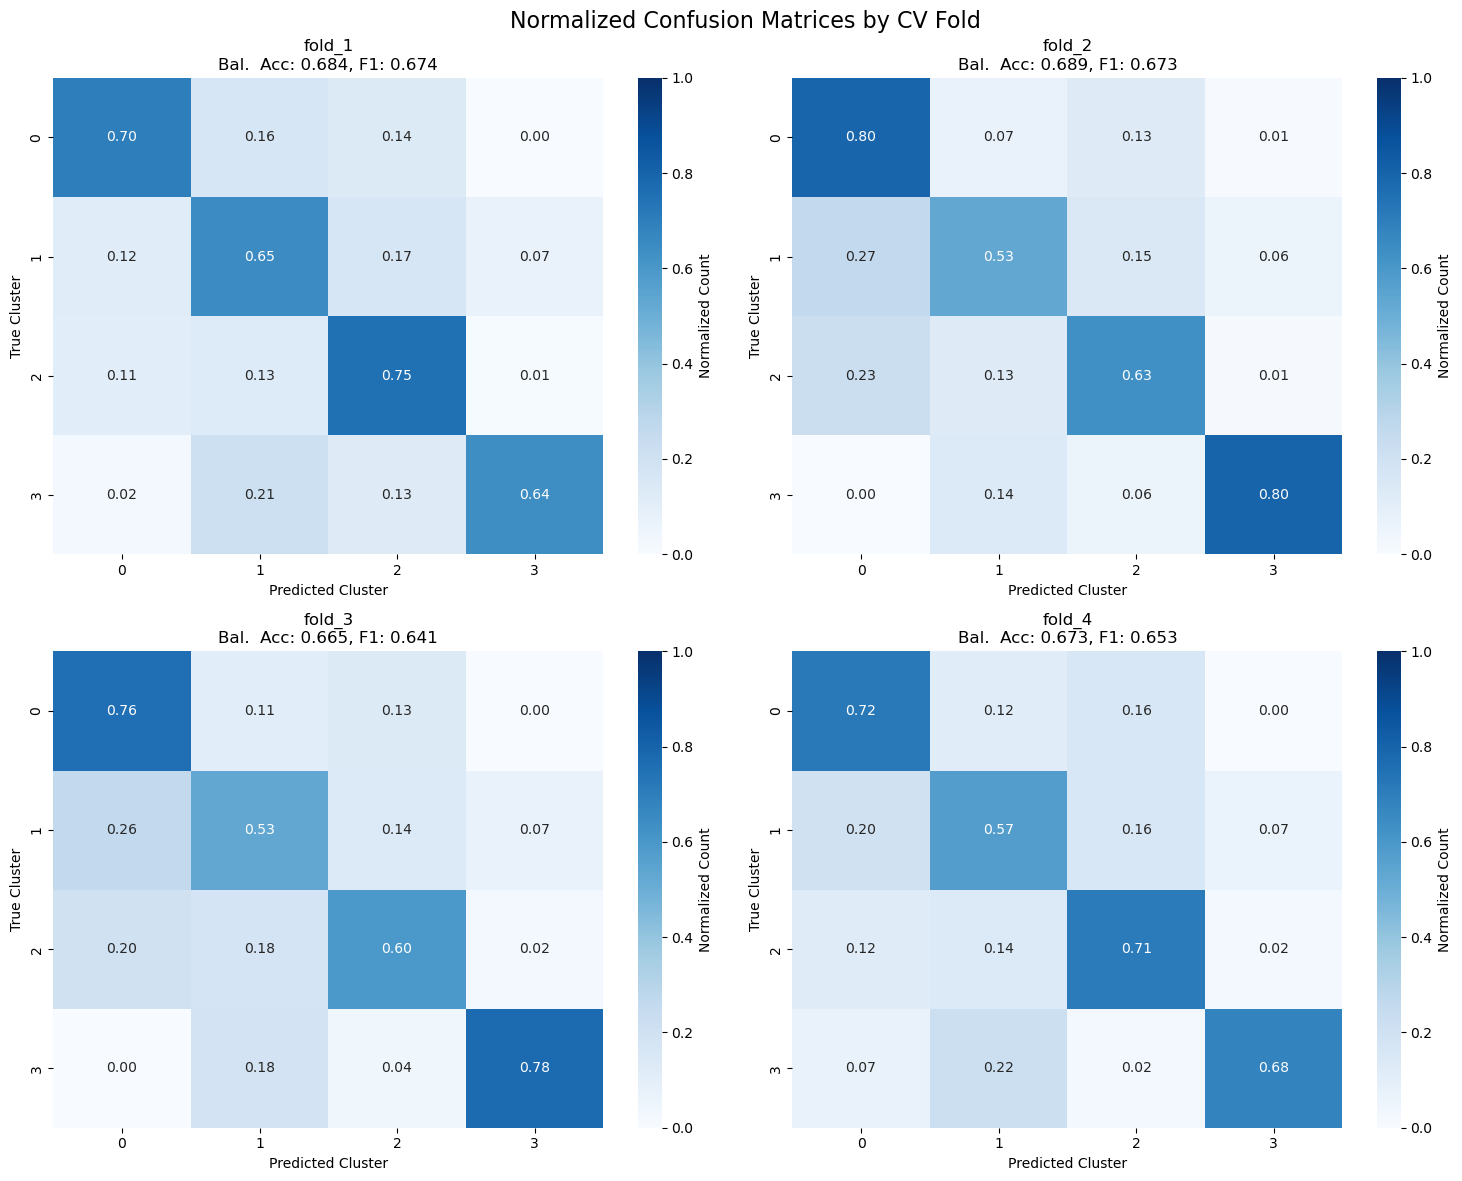


OVERALL CV SUMMARY
Mean Balanced Accuracy: 0.678 ± 0.010
Mean Macro F1: 0.660 ± 0.014

Pipeline completed successfully!


In [17]:
# 1. Run your baseline pipeline first
classifier = HeatmapCNNClassifier() 
classifier.run_full_pipeline()

### Functions for Ray Tune optuna tuning

In [30]:
######################## Complete Pure Optuna CNN Optimization ###############################

import optuna
import numpy as np
import pandas as pd
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense
from sklearn.metrics import balanced_accuracy_score, f1_score
import uuid
import gc

######################## Optimized CNN model creation for Optuna ###############################

def create_optuna_cnn_model(self, input_shape, config):
    """Create CNN model with Optuna-optimized hyperparameters"""
    
    print(f"Creating Optuna CNN model with input shape: {input_shape}")
    
    model = Sequential([
        # Input layer with optimized noise augmentation
        BlockGaussianNoise(config["noise_level"], config["block_size"], seed=42, input_shape=input_shape),

        # First convolutional block with optimized filters
        Conv2D(config["conv_filters_1"], (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(config["conv_filters_1"], (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(config["dropout_rate_conv"]),
        
        # Second convolutional block with optimized filters
        Conv2D(config["conv_filters_2"], (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(config["conv_filters_2"], (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(config["dropout_rate_conv"]),
        
        # Third convolutional block with optimized filters
        Conv2D(config["conv_filters_3"], (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(config["conv_filters_3"], (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(config["dropout_rate_conv"]),
        
        # Fully connected layers with optimized sizes
        Flatten(),
        Dense(config["dense_units_1"], activation='relu'),
        BatchNormalization(),
        Dropout(config["dropout_rate_dense"]),

        Dense(config["dense_units_2"], activation='relu'),
        Dropout(config["dropout_rate_dense"]),

        Dense(self.n_classes, activation='softmax')
    ])
    
    return model

# Add to class
HeatmapCNNClassifier.create_optuna_cnn_model = create_optuna_cnn_model

######################## Pure Optuna optimization function ###############################

def optimize_cnn_with_optuna(self, num_trials=30, max_epochs=25, cv_fold=None, timeout_minutes=60):
    """
    Pure Optuna CNN hyperparameter optimization
    
    Parameters:
    -----------
    num_trials : int
        Number of trials to run
    max_epochs : int
        Maximum epochs per trial
    cv_fold : str or None
        Specific CV fold to use, or None for first fold
    timeout_minutes : int
        Maximum time to run optimization (in minutes)
    """
    
    print("🎯 Starting Pure Optuna CNN Optimization...")
    print(f"  Trials: {num_trials}")
    print(f"  Max epochs per trial: {max_epochs}")
    print(f"  Timeout: {timeout_minutes} minutes")
    
    # Prepare data
    if not hasattr(self, 'fold_balanced_data') or not self.fold_balanced_data:
        raise ValueError("No fold_balanced_data found.  Run the full pipeline first.")
    
    # Select fold for optimization
    if cv_fold is None:
        fold_key = list(self.fold_balanced_data.keys())[0]
    else:
        fold_key = cv_fold
        if fold_key not in self.fold_balanced_data:
            raise ValueError(f"Fold {cv_fold} not found.  Available:  {list(self.fold_balanced_data.keys())}")
    
    fold_data = self.fold_balanced_data[fold_key]
    
    X_train = fold_data['X_train_scaled']
    y_train = fold_data['y_train']
    X_val = fold_data['X_val_scaled']
    y_val = fold_data['y_val']
    
    print(f"Using fold:  {fold_key}")
    print(f"Training data:  {X_train.shape}")
    print(f"Validation data: {X_val.shape}")
    print(f"Number of classes: {self.n_classes}")
    
    # Convert labels to categorical
    y_train_cat = to_categorical(y_train, self.n_classes)
    y_val_cat = to_categorical(y_val, self.n_classes)
    
    # Define Optuna objective function
    def objective(trial):
        """Optuna objective function for CNN hyperparameter optimization"""
        
        trial_num = trial.number + 1
        print(f"\n🔬 Trial {trial_num}/{num_trials}")
        
        # Suggest hyperparameters
        config = {
            # Core training parameters
            "learning_rate":  trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True),
            "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64, 128]),
            
            # Dropout parameters
            "dropout_rate_conv": trial.suggest_float("dropout_rate_conv", 0.1, 0.5),
            "dropout_rate_dense": trial.suggest_float("dropout_rate_dense", 0.3, 0.7),
            
            # Architecture parameters - Conv layers
            "conv_filters_1": trial.suggest_categorical("conv_filters_1", [16, 24, 32, 48]),
            "conv_filters_2":  trial.suggest_categorical("conv_filters_2", [32, 48, 64, 96]),
            "conv_filters_3": trial.suggest_categorical("conv_filters_3", [64, 96, 128, 192]),
            
            # Architecture parameters - Dense layers
            "dense_units_1": trial.suggest_categorical("dense_units_1", [256, 384, 512, 768]),
            "dense_units_2": trial.suggest_categorical("dense_units_2", [128, 192, 256, 384]),
            
            # Augmentation parameters
            "noise_level": trial.suggest_float("noise_level", 0.01, 0.15),
            "block_size":  trial.suggest_categorical("block_size", [2, 3, 4]),
            
            # Learning rate schedule parameters
            "lr_reduction_factor": trial.suggest_float("lr_reduction_factor", 0.3, 0.7),
            "lr_patience": trial.suggest_categorical("lr_patience", [3, 5, 7, 10]),
            "early_stop_patience": trial.suggest_categorical("early_stop_patience", [8, 10, 12, 15]),
        }
        
        print(f"  LR: {config['learning_rate']:.6f}")
        print(f"  Batch size: {config['batch_size']}")
        print(f"  Conv filters: [{config['conv_filters_1']}, {config['conv_filters_2']}, {config['conv_filters_3']}]")
        print(f"  Dense units: [{config['dense_units_1']}, {config['dense_units_2']}]")
        print(f"  Dropout:  Conv={config['dropout_rate_conv']:.3f}, Dense={config['dropout_rate_dense']:.3f}")
        
        try:
            # Create model with current configuration
            model = self.create_optuna_cnn_model(X_train.shape[1:], config)
            
            # Compile model with suggested parameters
            optimizer = Adam(learning_rate=config["learning_rate"])
            model.compile(
                optimizer=optimizer,
                loss='categorical_crossentropy',
                metrics=['accuracy']
            )
            
            # Setup callbacks with suggested parameters
            callbacks = [
                EarlyStopping(
                    monitor='val_loss',
                    patience=config["early_stop_patience"],
                    restore_best_weights=True,
                    verbose=0
                ),
                ReduceLROnPlateau(
                    monitor='val_loss',
                    factor=config["lr_reduction_factor"],
                    patience=config["lr_patience"],
                    min_lr=1e-7,
                    verbose=0
                )
            ]
            
            # Train model
            print(f"  Training for up to {max_epochs} epochs...")
            history = model.fit(
                X_train, y_train_cat,
                validation_data=(X_val, y_val_cat),
                epochs=max_epochs,
                batch_size=config["batch_size"],
                callbacks=callbacks,
                verbose=0
            )
            
            # Calculate metrics
            if len(history.history['val_loss']) == 0:
                print(f"  ❌ No training history available")
                return 0.0
            
            # Get predictions
            y_pred_proba = model.predict(X_val, verbose=0)
            y_pred = np.argmax(y_pred_proba, axis=1)
            
            # Calculate performance metrics
            balanced_acc = balanced_accuracy_score(y_val, y_pred)
            macro_f1 = f1_score(y_val, y_pred, average='macro')
            best_val_loss = min(history.history['val_loss'])
            epochs_trained = len(history.history['loss'])
            
            # Calculate overfitting metric
            final_train_loss = history.history['loss'][-1]
            final_val_loss = history.history['val_loss'][-1]
            overfitting_gap = final_val_loss - final_train_loss
            
            print(f"  ✅ Results:  Acc={balanced_acc:.4f}, F1={macro_f1:.4f}, Loss={best_val_loss:.4f}")
            print(f"     Epochs:  {epochs_trained}, Overfitting gap: {overfitting_gap:.4f}")
            
            # Store additional metrics in trial user attributes for later analysis
            trial.set_user_attr('macro_f1', macro_f1)
            trial.set_user_attr('val_loss', best_val_loss)
            trial.set_user_attr('epochs_trained', epochs_trained)
            trial.set_user_attr('overfitting_gap', overfitting_gap)
            
            # Cleanup model to free memory
            del model
            gc.collect()
            
            # Return balanced accuracy as the optimization target
            return balanced_acc
            
        except Exception as e: 
            print(f"  ❌ Trial failed: {str(e)}")
            # Cleanup in case of error
            try:
                del model
                gc.collect()
            except:
                pass
            return 0.0
    
    # Create and configure Optuna study
    study_name = f'cnn_optimization_{uuid.uuid4().hex[:8]}'
    
    # Use MedianPruner to stop unpromising trials early
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,      # Don't prune first 5 trials
        n_warmup_steps=5,        # Wait 5 steps before starting to prune
        interval_steps=2         # Check every 2 steps
    )
    
    study = optuna.create_study(
        direction='maximize',
        study_name=study_name,
        storage=None,  # In-memory storage
        pruner=pruner
    )
    
    print(f"\n🚀 Starting optimization study: {study_name}")
    
    # Run optimization
    try:
        study.optimize(
            objective, 
            n_trials=num_trials,
            timeout=timeout_minutes * 60,  # Convert to seconds
            show_progress_bar=True,
            gc_after_trial=True  # Force garbage collection after each trial
        )
        
    except KeyboardInterrupt:
        print("\n⚠️  Optimization interrupted by user")
    except Exception as e:
        print(f"\n❌ Optimization failed: {e}")
        return None, None
    
    # Analyze results
    print(f"\n📊 OPTIMIZATION COMPLETED")
    print(f"  Completed trials: {len(study.trials)}")
    print(f"  Pruned trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])}")
    print(f"  Failed trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.FAIL])}")
    
    if study.best_trial is None:
        print("❌ No successful trials found")
        return None, None
    
    # Get best results
    best_trial = study. best_trial
    best_params = best_trial.params
    best_score = best_trial.value
    
    print(f"\n🏆 BEST CONFIGURATION FOUND:")
    print(f"  Balanced Accuracy: {best_score:.4f}")
    if 'macro_f1' in best_trial.user_attrs:
        print(f"  Macro F1: {best_trial.user_attrs['macro_f1']:.4f}")
        print(f"  Validation Loss: {best_trial.user_attrs['val_loss']:.4f}")
        print(f"  Epochs Trained: {best_trial.user_attrs['epochs_trained']}")
        print(f"  Overfitting Gap: {best_trial.user_attrs['overfitting_gap']:.4f}")
    
    print(f"\n🎯 OPTIMIZED HYPERPARAMETERS:")
    for key, value in best_params. items():
        print(f"  {key}: {value}")
    
    # Show parameter importance
    if len(study.trials) >= 10:  # Need enough trials for importance analysis
        try:
            importance = optuna.importance.get_param_importances(study)
            print(f"\n📈 PARAMETER IMPORTANCE (top 5):")
            for param, imp in sorted(importance.items(), key=lambda x: x[1], reverse=True)[:5]:
                print(f"  {param}: {imp:.3f}")
        except Exception as e:
            print(f"  Could not calculate parameter importance: {e}")
    
    # Show top 5 trials
    successful_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    if len(successful_trials) >= 5:
        top_trials = sorted(successful_trials, key=lambda t: t.value or 0, reverse=True)[:5]
        print(f"\n🏅 TOP 5 TRIALS:")
        for i, trial in enumerate(top_trials):
            score = trial.value or 0
            f1 = trial.user_attrs.get('macro_f1', 'N/A')
            epochs = trial.user_attrs.get('epochs_trained', 'N/A')
            print(f"  {i+1}. Trial #{trial.number}:  Acc={score:.4f}, F1={f1}, Epochs={epochs}")
    
    # Store results in classifier
    self.optuna_study = study
    self.best_optuna_params = best_params
    self.best_optuna_config = best_params  # For compatibility
    
    print(f"\n✅ Optimization complete!  Use train_with_optuna_config() to apply results.")
    
    return best_params, study

######################## Function to apply optimized parameters ###############################

def train_with_optuna_config(self, config=None, run_full_cv=True):
    """Train model with Optuna-optimized hyperparameters"""
    
    if config is None:
        if not hasattr(self, 'best_optuna_params'):
            raise ValueError("No optimized parameters found. Run optimize_cnn_with_optuna() first.")
        config = self.best_optuna_params
    
    print("🚀 Training CNN with Optuna-optimized hyperparameters...")
    
    # Display the configuration
    print("\nOptimized configuration:")
    for key, value in config.items():
        print(f"  {key}: {value}")
    
    # Update global parameters for cross-validation
    global learning_rate, dropout_rate_conv, dropout_rate_dense, batch_size
    global noise_level, block_size, patience
    
    learning_rate = config["learning_rate"]
    dropout_rate_conv = config["dropout_rate_conv"]
    dropout_rate_dense = config["dropout_rate_dense"]
    batch_size = config["batch_size"]
    noise_level = config["noise_level"]
    block_size = config["block_size"]
    patience = config["early_stop_patience"]
    
    # Store config for model creation
    self.current_optuna_config = config
    
    if run_full_cv:
        print("\nRunning optimized cross-validation...")
        self.cross_validate_with_optuna()
    else:
        print("Skipping cross-validation. Set run_full_cv=True to run CV.")

def cross_validate_with_optuna(self):
    """Cross-validation using Optuna-optimized hyperparameters"""
    
    print("Starting Optuna-optimized cross-validation...")
    
    unique_folds = list(self.fold_balanced_data.keys())
    print(f"Cross-validation folds: {unique_folds}")
    
    cv_results = {
        'balanced_accuracy': [],
        'macro_f1': [],
        'fold_predictions': [],
        'fold_true_labels': [],
        'train_loss': [],
        'train_accuracy': [],
        'val_loss': [],
        'val_accuracy': []
    }
    
    self.cv_fold_results_optuna = []
    
    for fold in unique_folds:
        print(f"\nProcessing fold: {fold}")
        
        fold_data = self.fold_balanced_data[fold]
        X_train_fold = fold_data['X_train_scaled']
        y_train_fold = fold_data['y_train']
        X_val_fold = fold_data['X_val_scaled']
        y_val_fold = fold_data['y_val']
        
        print(f"  Fold {fold} - Train: {len(X_train_fold)}, Val: {len(X_val_fold)}")
        
        # Convert to categorical
        y_train_fold_cat = to_categorical(y_train_fold, self.n_classes)
        y_val_fold_cat = to_categorical(y_val_fold, self.n_classes)
        
        # Create optimized model
        model = self.create_optuna_cnn_model(X_train_fold.shape[1:], self.current_optuna_config)
        
        # Compile with optimized parameters
        optimizer = Adam(learning_rate=self.current_optuna_config["learning_rate"])
        model.compile(
            optimizer=optimizer,
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        
        # Setup optimized callbacks
        callbacks = [
            EarlyStopping(
                monitor='val_loss',
                patience=self.current_optuna_config["early_stop_patience"],
                restore_best_weights=True
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=self.current_optuna_config["lr_reduction_factor"],
                patience=self.current_optuna_config["lr_patience"],
                min_lr=1e-7
            )
        ]
        
        # Train with optimized parameters
        history = model.fit(
            X_train_fold, y_train_fold_cat,
            validation_data=(X_val_fold, y_val_fold_cat),
            epochs=epochs,  # Use global epochs setting
            batch_size=self. current_optuna_config["batch_size"],
            callbacks=callbacks,
            verbose=verbose_val
        )
        
        # Extract metrics
        final_train_loss = history.history['loss'][-1]
        final_train_accuracy = history.history['accuracy'][-1]
        final_val_loss = history.history['val_loss'][-1]
        final_val_accuracy = history.history['val_accuracy'][-1]
        
        cv_results['train_loss'].append(final_train_loss)
        cv_results['train_accuracy'].append(final_train_accuracy)
        cv_results['val_loss'].append(final_val_loss)
        cv_results['val_accuracy'].append(final_val_accuracy)
        
        # Predictions and metrics
        y_pred_proba = model.predict(X_val_fold, verbose=verbose_val)
        y_pred = np.argmax(y_pred_proba, axis=1)
        
        bal_acc = balanced_accuracy_score(y_val_fold, y_pred)
        macro_f1 = f1_score(y_val_fold, y_pred, average='macro')
        
        cv_results['balanced_accuracy'].append(bal_acc)
        cv_results['macro_f1'].append(macro_f1)
        cv_results['fold_predictions'].extend(y_pred)
        cv_results['fold_true_labels'].extend(y_val_fold)
        
        # Training metrics
        y_train_pred_proba = model.predict(X_train_fold, verbose=verbose_val)
        y_train_pred = np.argmax(y_train_pred_proba, axis=1)
        train_bal_acc = balanced_accuracy_score(y_train_fold, y_train_pred)
        train_macro_f1 = f1_score(y_train_fold, y_train_pred, average='macro')
        
        # Store fold results
        fold_result = {
            'fold_name': fold,
            'y_true': y_val_fold,
            'y_pred':  y_pred,
            'balanced_accuracy': bal_acc,
            'macro_f1': macro_f1,
            'n_samples': len(y_val_fold),
            'train_loss': final_train_loss,
            'train_accuracy': final_train_accuracy,
            'train_balanced_accuracy': train_bal_acc,
            'train_macro_f1': train_macro_f1,
            'val_loss': final_val_loss,
            'val_accuracy': final_val_accuracy
        }
        self.cv_fold_results_optuna.append(fold_result)
        
        print(f"  Results - Train: Loss={final_train_loss:.4f}, Acc={final_train_accuracy:.4f}")
        print(f"           Val: Loss={final_val_loss:.4f}, Acc={bal_acc:.4f}, F1={macro_f1:.4f}")
    
    self.cv_results_optuna = cv_results
    self.print_optuna_cv_results()

def print_optuna_cv_results(self):
    """Print Optuna-optimized cross-validation results with comparison"""
    
    print("\n" + "="*80)
    print("OPTUNA-OPTIMIZED CROSS-VALIDATION RESULTS")
    print("="*80)
    
    # Calculate optimized metrics
    bal_acc_mean = np.mean(self. cv_results_optuna['balanced_accuracy'])
    bal_acc_std = np.std(self.cv_results_optuna['balanced_accuracy'])
    f1_mean = np.mean(self.cv_results_optuna['macro_f1'])
    f1_std = np.std(self.cv_results_optuna['macro_f1'])
    val_loss_mean = np.mean(self.cv_results_optuna['val_loss'])
    val_loss_std = np. std(self.cv_results_optuna['val_loss'])
    
    print("OPTUNA-OPTIMIZED METRICS:")
    print(f"  Balanced Accuracy:    {bal_acc_mean:.4f} ± {bal_acc_std:.4f}")
    print(f"  Macro F1 Score:      {f1_mean:.4f} ± {f1_std:.4f}")
    print(f"  Validation Loss:     {val_loss_mean:.4f} ± {val_loss_std:.4f}")
    
    # Compare with baseline if available
    if hasattr(self, 'cv_results'):
        baseline_bal_acc = np.mean(self.cv_results['balanced_accuracy'])
        baseline_f1 = np.mean(self.cv_results['macro_f1'])
        baseline_loss = np.mean(self.cv_results['val_loss'])
        
        print(f"\n📈 IMPROVEMENT OVER BASELINE:")
        acc_improvement = bal_acc_mean - baseline_bal_acc
        f1_improvement = f1_mean - baseline_f1
        loss_improvement = baseline_loss - val_loss_mean  # Lower loss is better
        
        print(f"  Balanced Accuracy:  {bal_acc_mean:.4f} vs {baseline_bal_acc:.4f} ({acc_improvement:+.4f})")
        print(f"  Macro F1 Score:      {f1_mean:.4f} vs {baseline_f1:.4f} ({f1_improvement:+.4f})")
        print(f"  Validation Loss:    {val_loss_mean:.4f} vs {baseline_loss:.4f} ({loss_improvement:+.4f})")
        
        if acc_improvement > 0:
            print("  ✅ Accuracy improved!")
        if f1_improvement > 0:
            print("  ✅ F1 score improved!")
        if loss_improvement > 0:
            print("  ✅ Loss improved!")
    
    # Per-fold breakdown
    print(f"\nPER-FOLD RESULTS:")
    print("Fold      | Bal Acc | F1 Score | Val Loss | Epochs")
    print("-" * 50)
    for fold_result in self.cv_fold_results_optuna:
        fold_name = fold_result['fold_name']
        bal_acc = fold_result['balanced_accuracy']
        f1 = fold_result['macro_f1']
        val_loss = fold_result['val_loss']
        print(f"{fold_name:<9} | {bal_acc:.4f}  | {f1:.4f}   | {val_loss:.4f}  |")

# Add all functions to the class
HeatmapCNNClassifier.create_optuna_cnn_model = create_optuna_cnn_model
HeatmapCNNClassifier.optimize_cnn_with_optuna = optimize_cnn_with_optuna
HeatmapCNNClassifier.train_with_optuna_config = train_with_optuna_config
HeatmapCNNClassifier.cross_validate_with_optuna = cross_validate_with_optuna
HeatmapCNNClassifier.print_optuna_cv_results = print_optuna_cv_results

######################## Ready to run - Usage Example ###############################

print("✅ Pure Optuna CNN optimization loaded!")
print("\n🚀 Ready to optimize your CNN!")
print("\nTo run optimization:")
print("  best_params, study = classifier.optimize_cnn_with_optuna()")
print("\nTo train with optimized parameters:")
print("  classifier.train_with_optuna_config()")

# You can now run: 
# best_params, study = classifier.optimize_cnn_with_optuna(num_trials=30, max_epochs=25)
# classifier.train_with_optuna_config()

✅ Pure Optuna CNN optimization loaded!

🚀 Ready to optimize your CNN!

To run optimization:
  best_params, study = classifier.optimize_cnn_with_optuna()

To train with optimized parameters:
  classifier.train_with_optuna_config()


In [26]:
# Run the optimization (this will take a while)
best_params, study = classifier.optimize_cnn_with_optuna(
    num_trials=30,        # Number of different configurations to try
    max_epochs=25,        # Maximum epochs per trial
    timeout_minutes=120   # Stop after 2 hours max
)

[I 2026-01-07 14:04:52,925] A new study created in memory with name: cnn_optimization_594d2e43


🎯 Starting Pure Optuna CNN Optimization...
  Trials: 30
  Max epochs per trial: 25
  Timeout: 120 minutes
Using fold:  fold_1
Training data:  (3148, 46, 46, 3)
Validation data: (1063, 46, 46, 3)
Number of classes: 4

🚀 Starting optimization study: cnn_optimization_594d2e43


  0%|          | 0/30 [00:00<?, ?it/s]


🔬 Trial 1/30
  LR: 0.008759
  Batch size: 32
  Conv filters: [32, 32, 64]
  Dense units: [768, 384]
  Dropout:  Conv=0.399, Dense=0.397
Creating Optuna CNN model with input shape: (46, 46, 3)
  Training for up to 25 epochs...


  0%|          | 0/30 [01:10<?, ?it/s]

...


🔬 Trial 30/30
  LR: 0.003134
  Batch size: 32
  Conv filters: [32, 32, 64]
  Dense units: [768, 384]
  Dropout:  Conv=0.321, Dense=0.401
Creating Optuna CNN model with input shape: (46, 46, 3)
  Training for up to 25 epochs...


Best trial: 22. Best value: 0.702529:  97%|█████████▋| 29/30 [59:15<01:58, 118.21s/it, 3473.19/7200 seconds]

  ✅ Results:  Acc=0.6964, F1=0.6897, Loss=0.7661
     Epochs:  25, Overfitting gap: 0.2711
[I 2026-01-07 15:04:08,576] Trial 29 finished with value: 0.6963932940028517 and parameters: {'learning_rate': 0.003133633175256458, 'batch_size': 32, 'dropout_rate_conv': 0.32148237053464257, 'dropout_rate_dense': 0.4006642034855502, 'conv_filters_1': 32, 'conv_filters_2': 32, 'conv_filters_3': 64, 'dense_units_1': 768, 'dense_units_2': 384, 'noise_level': 0.13476114084285973, 'block_size': 3, 'lr_reduction_factor': 0.4407726704491698, 'lr_patience': 10, 'early_stop_patience': 15}. Best is trial 22 with value: 0.702529053767261.


Best trial: 22. Best value: 0.702529: 100%|██████████| 30/30 [59:16<00:00, 118.55s/it, 3556.36/7200 seconds]



📊 OPTIMIZATION COMPLETED
  Completed trials: 30
  Pruned trials: 0
  Failed trials: 0

🏆 BEST CONFIGURATION FOUND:
  Balanced Accuracy: 0.7025
  Macro F1: 0.6738
  Validation Loss: 0.7515
  Epochs Trained: 25
  Overfitting Gap: 0.2428

🎯 OPTIMIZED HYPERPARAMETERS:
  learning_rate: 0.0001992020152615974
  batch_size: 16
  dropout_rate_conv: 0.19513130555193567
  dropout_rate_dense: 0.43185696811710184
  conv_filters_1: 48
  conv_filters_2: 48
  conv_filters_3: 96
  dense_units_1: 384
  dense_units_2: 384
  noise_level: 0.13110381486571537
  block_size: 4
  lr_reduction_factor: 0.3969187716995002
  lr_patience: 3
  early_stop_patience: 10

📈 PARAMETER IMPORTANCE (top 5):
  learning_rate: 0.232
  lr_reduction_factor: 0.208
  batch_size: 0.114
  block_size: 0.112
  early_stop_patience: 0.101

🏅 TOP 5 TRIALS:
  1. Trial #22:  Acc=0.7025, F1=0.6738325684221207, Epochs=25
  2. Trial #29:  Acc=0.6964, F1=0.6896623652426838, Epochs=25
  3. Trial #4:  Acc=0.6963, F1=0.6840122499141494, Epochs=2

In [31]:
# 3. Train with optimized parameters
classifier.train_with_optuna_config(run_full_cv=True)

🚀 Training CNN with Optuna-optimized hyperparameters...

Optimized configuration:
  learning_rate: 0.0001992020152615974
  batch_size: 16
  dropout_rate_conv: 0.19513130555193567
  dropout_rate_dense: 0.43185696811710184
  conv_filters_1: 48
  conv_filters_2: 48
  conv_filters_3: 96
  dense_units_1: 384
  dense_units_2: 384
  noise_level: 0.13110381486571537
  block_size: 4
  lr_reduction_factor: 0.3969187716995002
  lr_patience: 3
  early_stop_patience: 10

Running optimized cross-validation...
Starting Optuna-optimized cross-validation...
Cross-validation folds: [np.str_('fold_1'), np.str_('fold_2'), np.str_('fold_3'), np.str_('fold_4')]

Processing fold: fold_1
  Fold fold_1 - Train: 3148, Val: 1063
Creating Optuna CNN model with input shape: (46, 46, 3)
Epoch 1/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.3564 - loss: 1.7022 - val_accuracy: 0.3321 - val_loss: 1.2248 - learning_rate: 1.9920e-04
Epoch 2/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.4498 -

In [36]:
######################## Train with optimized parameters and evaluate on test set ###############################

def train_and_evaluate_on_test_set(self, config=None, use_full_training=True, verbose=True):
    """
    Train model with optimized hyperparameters on training set and evaluate on test set
    
    Parameters:
    -----------
    config : dict or None
        Configuration to use.  If None, uses stored best_optuna_params
    use_full_training :  bool
        If True, train on full balanced training set. If False, train on single fold. 
    verbose : bool
        Whether to show detailed output
    """
    
    print("🚀 Training optimized model and evaluating on test set...")
    
    # Get configuration
    if config is None:
        if not hasattr(self, 'best_optuna_params'):
            raise ValueError("No optimized parameters found. Run optimize_cnn_with_optuna() first.")
        config = self.best_optuna_params
    
    if verbose:
        print("\nUsing optimized configuration:")
        for key, value in config.items():
            print(f"  {key}: {value}")
    
    # Prepare training data
    if use_full_training:
        # Combine all training folds for maximum training data
        print("\n📊 Preparing combined training data from all CV folds...")
        
        X_train_combined = []
        y_train_combined = []
        
        for fold_name, fold_data in self.fold_balanced_data.items():
            X_train_combined.append(fold_data['X_train_scaled'])
            y_train_combined.append(fold_data['y_train'])
            print(f"  Fold {fold_name}: {len(fold_data['X_train_scaled'])} samples")
        
        X_train_final = np.vstack(X_train_combined)
        y_train_final = np.concatenate(y_train_combined)
        
        print(f"Combined training data: {X_train_final.shape}")
        
    else:
        # Use single fold (first fold) 
        first_fold = list(self.fold_balanced_data.keys())[0]
        fold_data = self.fold_balanced_data[first_fold]
        X_train_final = fold_data['X_train_scaled']
        y_train_final = fold_data['y_train']
        print(f"Using single fold training data: {X_train_final.shape}")
    
    # Prepare test data
    if not hasattr(self, 'X_test_scaled'):
        raise ValueError("No test data found. Make sure you ran the full pipeline with train/test split.")
    
    X_test = self.X_test_scaled
    y_test = self.y_test_encoded
    
    print(f"Test data: {X_test.shape}")
    print(f"Training classes distribution:")
    for i, class_name in enumerate(self.label_encoder.classes_):
        count = np.sum(y_train_final == i)
        print(f"  {class_name}: {count} samples")
    
    # Convert to categorical
    y_train_final_cat = to_categorical(y_train_final, self.n_classes)
    y_test_cat = to_categorical(y_test, self.n_classes)
    
    print(f"\n🏗️ Building optimized model...")
    
    # Create model with optimized architecture
    model = self.create_optuna_cnn_model(X_train_final. shape[1:], config)
    
    # Compile with optimized parameters
    optimizer = Adam(learning_rate=config["learning_rate"])
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    if verbose:
        print("\nModel architecture summary:")
        model.summary()
    
    # Setup optimized callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=config["early_stop_patience"],
            restore_best_weights=True,
            verbose=1 if verbose else 0
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=config["lr_reduction_factor"],
            patience=config["lr_patience"],
            min_lr=1e-7,
            verbose=1 if verbose else 0
        )
    ]
    
    # Use a portion of training data for validation during training
    from sklearn.model_selection import train_test_split
    X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
        X_train_final, y_train_final_cat,
        test_size=0.15,  # Use 15% for validation during training
        random_state=42,
        stratify=y_train_final
    )
    
    print(f"\n🔥 Training model...")
    print(f"  Training set:  {X_train_split.shape}")
    print(f"  Validation set: {X_val_split.shape}")
    print(f"  Test set: {X_test.shape}")
    
    # Train model
    history = model.fit(
        X_train_split, y_train_split,
        validation_data=(X_val_split, y_val_split),
        epochs=epochs,  # Use global epochs setting
        batch_size=config["batch_size"],
        callbacks=callbacks,
        verbose=1 if verbose else 0
    )
    
    print(f"\n📊 Training completed after {len(history.history['loss'])} epochs")
    
    # Evaluate on test set
    print(f"\n🎯 Evaluating on test set...")
    
    # Test set predictions
    test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
    y_test_pred_proba = model.predict(X_test, verbose=0)
    y_test_pred = np.argmax(y_test_pred_proba, axis=1)
    
    # Calculate comprehensive test metrics
    test_balanced_acc = balanced_accuracy_score(y_test, y_test_pred)
    test_macro_f1 = f1_score(y_test, y_test_pred, average='macro')
    test_micro_f1 = f1_score(y_test, y_test_pred, average='micro')
    
    # Per-class metrics
    from sklearn.metrics import classification_report, confusion_matrix
    
    test_report = classification_report(
        y_test, y_test_pred,
        target_names=self.label_encoder.classes_,
        output_dict=True
    )
    
    test_cm = confusion_matrix(y_test, y_test_pred)
    
    # Store results
    self.test_results_optimized = {
        'model':  model,
        'history': history,
        'test_loss': test_loss,
        'test_accuracy': test_accuracy,
        'test_balanced_accuracy': test_balanced_acc,
        'test_macro_f1': test_macro_f1,
        'test_micro_f1': test_micro_f1,
        'y_true': y_test,
        'y_pred': y_test_pred,
        'y_pred_proba': y_test_pred_proba,
        'classification_report': test_report,
        'confusion_matrix': test_cm,
        'config_used': config
    }
    
    print(f"\n🏆 FINAL TEST SET RESULTS:")
    print(f"  Test Loss: {test_loss:.4f}")
    print(f"  Test Accuracy: {test_accuracy:.4f}")
    print(f"  Test Balanced Accuracy: {test_balanced_acc:.4f}")
    print(f"  Test Macro F1: {test_macro_f1:.4f}")
    print(f"  Test Micro F1: {test_micro_f1:.4f}")
    
    # Compare with baseline if available
    if hasattr(self, 'cv_results'):
        baseline_val_acc = np.mean(self.cv_results['balanced_accuracy'])
        baseline_val_f1 = np.mean(self.cv_results['macro_f1'])
        
        print(f"\n📈 COMPARISON WITH BASELINE CV RESULTS:")
        print(f"  Baseline CV Bal.  Acc: {baseline_val_acc:.4f}")
        print(f"  Optimized Test Bal. Acc: {test_balanced_acc:.4f}")
        print(f"  Difference: {test_balanced_acc - baseline_val_acc:+.4f}")
        print(f"  Baseline CV F1: {baseline_val_f1:.4f}")
        print(f"  Optimized Test F1: {test_macro_f1:.4f}") 
        print(f"  Difference: {test_macro_f1 - baseline_val_f1:+.4f}")
    
    # Per-class performance
    print(f"\n📋 PER-CLASS PERFORMANCE ON TEST SET:")
    print("Class". ljust(15), "Precision".ljust(10), "Recall".ljust(10), "F1-Score".ljust(10), "Support")
    print("-" * 60)
    for class_name in self.label_encoder.classes_:
        metrics = test_report[class_name]
        print(f"{class_name}". ljust(15), 
              f"{metrics['precision']:.3f}".ljust(10),
              f"{metrics['recall']:.3f}".ljust(10), 
              f"{metrics['f1-score']:.3f}".ljust(10),
              f"{int(metrics['support'])}")
    
    return self.test_results_optimized

######################## Function to plot test results ###############################

def plot_test_results(self, figsize=(15, 10)):
    """Plot comprehensive test results"""
    
    if not hasattr(self, 'test_results_optimized'):
        print("No test results found. Run train_and_evaluate_on_test_set() first.")
        return
    
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    results = self.test_results_optimized
    
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    fig.suptitle('Optimized Model Test Set Results', fontsize=16)
    
    # 1. Training history
    ax1 = axes[0, 0]
    history = results['history']. history
    epochs = range(1, len(history['loss']) + 1)
    
    ax1.plot(epochs, history['loss'], 'b-', label='Training Loss')
    ax1.plot(epochs, history['val_loss'], 'r-', label='Validation Loss')
    ax1.set_title('Training History')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # 2. Accuracy history
    ax2 = axes[0, 1] 
    ax2.plot(epochs, history['accuracy'], 'b-', label='Training Accuracy')
    ax2.plot(epochs, history['val_accuracy'], 'r-', label='Validation Accuracy')
    ax2.set_title('Accuracy History')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    # 3. Test confusion matrix
    ax3 = axes[0, 2]
    cm_normalized = results['confusion_matrix'].astype('float') / results['confusion_matrix'].sum(axis=1)[: , np.newaxis]
    
    sns.heatmap(cm_normalized, 
                annot=True, 
                fmt='.3f',
                cmap='Blues',
                ax=ax3,
                xticklabels=self.label_encoder.classes_,
                yticklabels=self.label_encoder.classes_)
    ax3.set_title(f'Test Confusion Matrix\n(Bal. Acc: {results["test_balanced_accuracy"]:.3f})')
    ax3.set_xlabel('Predicted')
    ax3.set_ylabel('True')
    
    # 4. Per-class metrics
    ax4 = axes[1, 0]
    class_names = self.label_encoder.classes_
    report = results['classification_report']
    
    precisions = [report[cls]['precision'] for cls in class_names]
    recalls = [report[cls]['recall'] for cls in class_names]
    f1_scores = [report[cls]['f1-score'] for cls in class_names]
    
    x = np.arange(len(class_names))
    width = 0.25
    
    ax4.bar(x - width, precisions, width, label='Precision', alpha=0.8)
    ax4.bar(x, recalls, width, label='Recall', alpha=0.8)
    ax4.bar(x + width, f1_scores, width, label='F1-Score', alpha=0.8)
    
    ax4.set_xlabel('Classes')
    ax4.set_ylabel('Score')
    ax4.set_title('Per-Class Metrics')
    ax4.set_xticks(x)
    ax4.set_xticklabels(class_names, rotation=45)
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # 5. Prediction confidence distribution
    ax5 = axes[1, 1]
    max_probs = np.max(results['y_pred_proba'], axis=1)
    
    ax5.hist(max_probs, bins=20, alpha=0.7, edgecolor='black')
    ax5.set_xlabel('Max Prediction Probability')
    ax5.set_ylabel('Frequency')
    ax5.set_title('Prediction Confidence Distribution')
    ax5.axvline(np.mean(max_probs), color='red', linestyle='--', 
                label=f'Mean: {np.mean(max_probs):.3f}')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # 6. Test metrics summary
    ax6 = axes[1, 2]
    ax6.axis('off')
    
    metrics_text = f"""
    TEST SET METRICS:
    
    Samples: {len(results['y_true'])}
    
    Accuracy: {results['test_accuracy']:.4f}
    Balanced Accuracy: {results['test_balanced_accuracy']:.4f}
    
    Macro F1: {results['test_macro_f1']:.4f}
    Micro F1: {results['test_micro_f1']:.4f}
    
    Loss: {results['test_loss']:.4f}
    
    Epochs Trained: {len(results['history']. history['loss'])}
    """
    
    ax6.text(0.1, 0.9, metrics_text, transform=ax6.transAxes, fontsize=11,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

######################## Function to compare all results ###############################

def compare_all_results(self):
    """Compare baseline CV, optimized CV, and optimized test results"""
    
    print("\n" + "="*80)
    print("COMPREHENSIVE RESULTS COMPARISON")
    print("="*80)
    
    # Gather all results
    results_data = []
    
    # Baseline CV results
    if hasattr(self, 'cv_results'):
        baseline_acc = np.mean(self.cv_results['balanced_accuracy'])
        baseline_f1 = np.mean(self.cv_results['macro_f1'])
        baseline_loss = np.mean(self.cv_results['val_loss'])
        results_data.append(['Baseline CV', baseline_acc, baseline_f1, baseline_loss])
    
    # Optimized CV results
    if hasattr(self, 'cv_results_optuna'):
        opt_cv_acc = np.mean(self.cv_results_optuna['balanced_accuracy'])
        opt_cv_f1 = np. mean(self.cv_results_optuna['macro_f1'])
        opt_cv_loss = np.mean(self.cv_results_optuna['val_loss'])
        results_data.append(['Optimized CV', opt_cv_acc, opt_cv_f1, opt_cv_loss])
    
    # Optimized test results
    if hasattr(self, 'test_results_optimized'):
        test_acc = self.test_results_optimized['test_balanced_accuracy']
        test_f1 = self. test_results_optimized['test_macro_f1']
        test_loss = self.test_results_optimized['test_loss']
        results_data.append(['Optimized Test', test_acc, test_f1, test_loss])
    
    # Create comparison table
    if results_data:
        print("Method".ljust(20), "Bal. Accuracy".ljust(15), "Macro F1".ljust(12), "Loss")
        print("-" * 60)
        
        for method, acc, f1, loss in results_data:
            print(f"{method}".ljust(20), 
                  f"{acc:.4f}".ljust(15), 
                  f"{f1:.4f}".ljust(12), 
                  f"{loss:.4f}")
        
        # Calculate improvements
        if len(results_data) >= 2:
            print(f"\n📈 IMPROVEMENTS:")
            baseline = results_data[0]
            for i, (method, acc, f1, loss) in enumerate(results_data[1:], 1):
                acc_change = acc - baseline[1]
                f1_change = f1 - baseline[2] 
                loss_change = loss - baseline[3]  # Note: lower loss is better
                
                print(f"\n{method} vs {baseline[0]}:")
                print(f"  Accuracy: {acc_change:+.4f} ({'✅' if acc_change > 0 else '❌' if acc_change < 0 else '➡️'})")
                print(f"  F1 Score: {f1_change:+.4f} ({'✅' if f1_change > 0 else '❌' if f1_change < 0 else '➡️'})")  
                print(f"  Loss: {loss_change:+.4f} ({'✅' if loss_change < 0 else '❌' if loss_change > 0 else '➡️'})")

# Add all functions to class
HeatmapCNNClassifier.train_and_evaluate_on_test_set = train_and_evaluate_on_test_set
HeatmapCNNClassifier.plot_test_results = plot_test_results
HeatmapCNNClassifier.compare_all_results = compare_all_results

######################## Usage Example ###############################

print("✅ Test evaluation functions loaded!")
print("\nTo train with optimized parameters and evaluate on test set:")
print("  test_results = classifier.train_and_evaluate_on_test_set()")
print("\nTo plot comprehensive test results:")
print("  classifier.plot_test_results()")
print("\nTo compare all results:")
print("  classifier.compare_all_results()")

"""
# Usage example: 

# 1. Train with optimized parameters and evaluate on test set
test_results = classifier.train_and_evaluate_on_test_set(
    use_full_training=True,  # Use all CV folds for training
    verbose=True
)

# 2. Plot comprehensive results
classifier.plot_test_results()

# 3. Compare all approaches
classifier.compare_all_results()
"""

✅ Test evaluation functions loaded!

To train with optimized parameters and evaluate on test set:
  test_results = classifier.train_and_evaluate_on_test_set()

To plot comprehensive test results:
  classifier.plot_test_results()

To compare all results:
  classifier.compare_all_results()


'\n# Usage example: \n\n# 1. Train with optimized parameters and evaluate on test set\ntest_results = classifier.train_and_evaluate_on_test_set(\n    use_full_training=True,  # Use all CV folds for training\n    verbose=True\n)\n\n# 2. Plot comprehensive results\nclassifier.plot_test_results()\n\n# 3. Compare all approaches\nclassifier.compare_all_results()\n'

In [33]:
test_results = classifier.train_and_evaluate_on_test_set(
    use_full_training=True,  # Use all CV folds for training
    verbose=True
)

🚀 Training optimized model and evaluating on test set...

Using optimized configuration:
  learning_rate: 0.0001992020152615974
  batch_size: 16
  dropout_rate_conv: 0.19513130555193567
  dropout_rate_dense: 0.43185696811710184
  conv_filters_1: 48
  conv_filters_2: 48
  conv_filters_3: 96
  dense_units_1: 384
  dense_units_2: 384
  noise_level: 0.13110381486571537
  block_size: 4
  lr_reduction_factor: 0.3969187716995002
  lr_patience: 3
  early_stop_patience: 10

📊 Preparing combined training data from all CV folds...
  Fold fold_1: 3148 samples
  Fold fold_2: 3148 samples
  Fold fold_3: 3148 samples
  Fold fold_4: 3188 samples
Combined training data: (12632, 46, 46, 3)
Test data: (1405, 46, 46, 3)
Training classes distribution:
  0: 3158 samples
  1: 3158 samples
  2: 3158 samples
  3: 3158 samples

🏗️ Building optimized model...
Creating Optuna CNN model with input shape: (46, 46, 3)

Model architecture summary:


Model: "sequential_42"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block_gaussian_noise_42         │ (None, 46, 46, 3)      │             0 │
│ (BlockGaussianNoise)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_252 (Conv2D)             │ (None, 46, 46, 48)     │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_168         │ (None, 46, 46, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_253 (Conv2D)             │ (None, 46, 46, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_126               │ (None, 23, 23, 48)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_210 (Dropout)           │ (None, 23, 23, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_254 (Conv2D)             │ (None, 23, 23, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_169         │ (None, 23, 23, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_255 (Conv2D)             │ (None, 23, 23, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_127               │ (None, 11, 11, 48)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_211 (Dropout)           │ (None, 11, 11, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_256 (Conv2D)             │ (None, 11, 11, 96)     │        41,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_170         │ (None, 11, 11, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_257 (Conv2D)             │ (None, 11, 11, 96)     │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_128               │ (None, 5, 5, 96)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_212 (Dropout)           │ (None, 5, 5, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_42 (Flatten)            │ (None, 2400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_126 (Dense)               │ (None, 384)            │       921,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_171         │ (None, 384)            │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_213 (Dropout)           │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_127 (Dense)               │ (None, 384)            │       147,84

 Total params: 1,261,972 (4.81 MB)

 Trainable params: 1,260,820 (4.81 MB)

 Non-trainable params: 1,152 (4.50 KB)


🔥 Training model...
  Training set:  (10737, 46, 46, 3)
  Validation set: (1895, 46, 46, 3)
  Test set: (1405, 46, 46, 3)
Epoch 1/100
672/672 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.4191 - loss: 1.4775 - val_accuracy: 0.4670 - val_loss: 1.1798 - learning_rate: 1.9920e-04
Epoch 2/100
672/672 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.5317 - loss: 1.1222 - val_accuracy: 0.4823 - val_loss: 1.1795 - learning_rate: 1.9920e-04
Epoch 3/100
672/672 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.6037 - loss: 0.9544 - val_accuracy: 0.6575 - val_loss: 0.8074 - learning_rate: 1.9920e-04
Epoch 4/100
672/672 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.6501 - loss: 0.8344 - val_accuracy: 0.7113 - val_loss: 0.6782 - learning_rate: 1.9920e-04
Epoch 5/100
672/672 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.6797 - loss: 0.7622 - val_accuracy: 0.7356 - val_loss: 0.6291 - learning_rate: 1.9920e-04
Epoch 6/100
672/672 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.7116 - loss: 

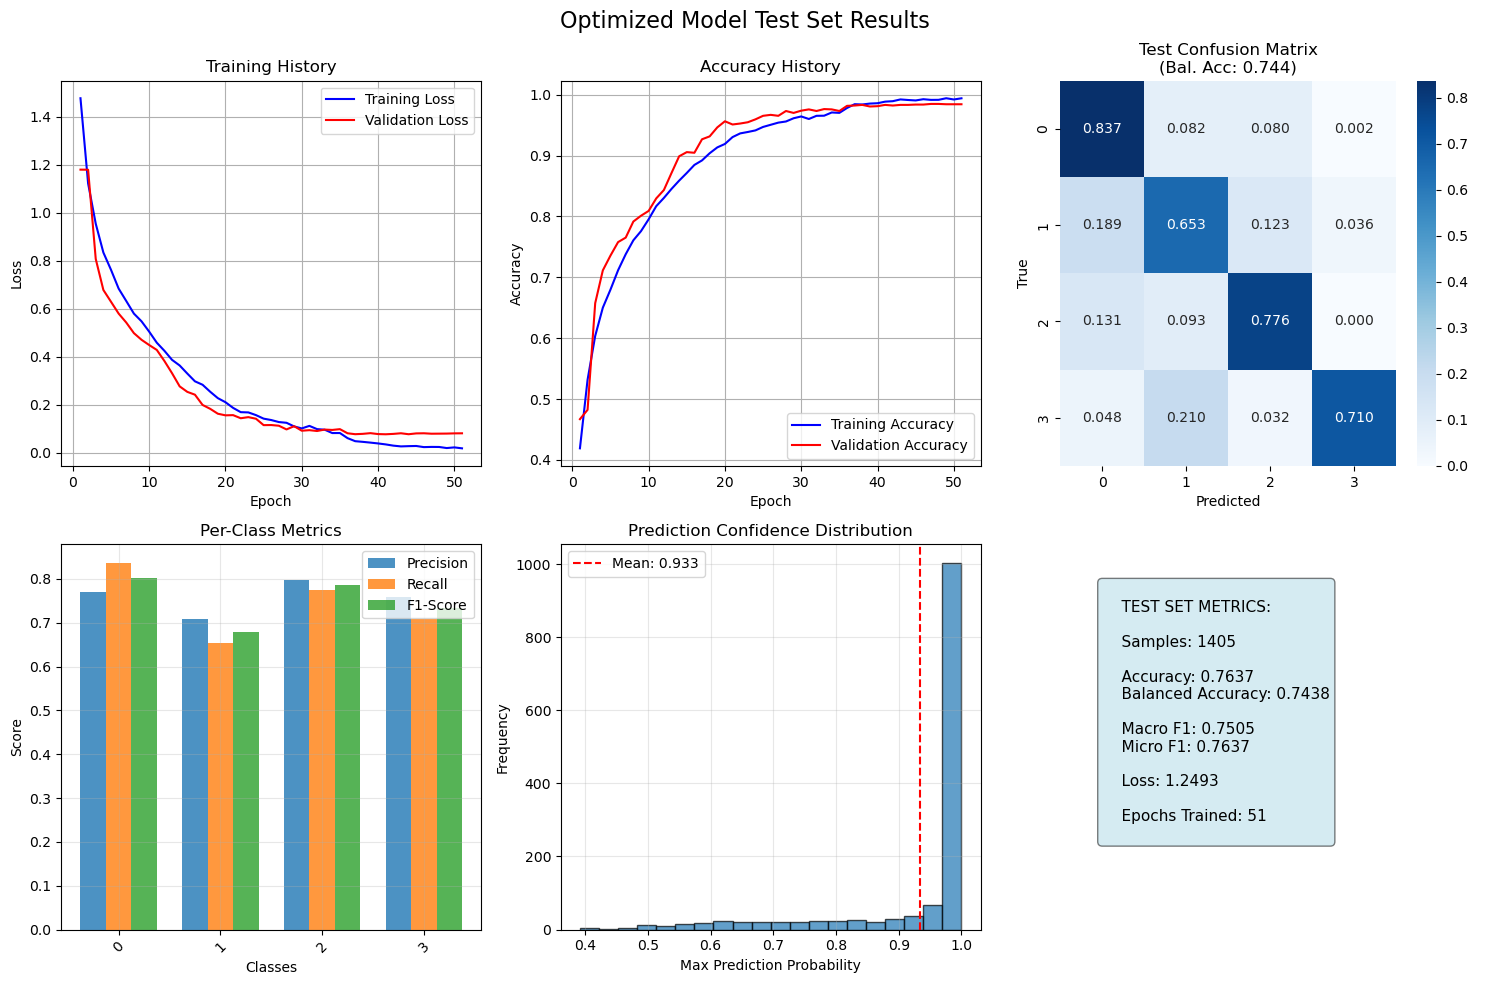

In [34]:
classifier.plot_test_results()

In [37]:
classifier.compare_all_results()


COMPREHENSIVE RESULTS COMPARISON
Method               Bal. Accuracy   Macro F1     Loss
------------------------------------------------------------
Baseline CV          0.6778          0.6602       0.9674
Optimized CV         0.6375          0.6379       0.8368
Optimized Test       0.7438          0.7505       1.2493

📈 IMPROVEMENTS:

Optimized CV vs Baseline CV:
  Accuracy: -0.0402 (❌)
  F1 Score: -0.0223 (❌)
  Loss: -0.1305 (✅)

Optimized Test vs Baseline CV:
  Accuracy: +0.0660 (✅)
  F1 Score: +0.0903 (✅)
  Loss: +0.2819 (❌)


In [39]:
# Save the trained model for future use: 
model = classifier.test_results_optimized['model']
save_directory = '../Data/'
model.save(save_directory + 'optimized_oceanographic_cnn.h5')

# Save the configuration: 
import pickle
with open(save_directory + 'optimal_config.pkl', 'wb') as f:
    pickle.dump(classifier.best_optuna_params, f)

### SHAP analysis of final model

In [45]:
######################## Adapted Comprehensive SHAP Analysis with Saving ###############################

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import shap
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from sklearn.preprocessing import StandardScaler
from collections import Counter
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# ENHANCED SAVING FUNCTIONS (Adapted)
# ============================================================================

def create_save_directory():
    """Create timestamped save directory for SHAP results"""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_dir = f"shap_results_{timestamp}"
    os.makedirs(save_dir, exist_ok=True)
    
    print(f"📁 Created save directory: {save_dir}")
    return save_dir, timestamp

def save_batch_checkpoint(save_dir, cluster_id, batch_num, cluster_samples, 
                         partial_shap_values, metadata):
    """Save checkpoint every 10 batches"""
    checkpoint_data = {
        'cluster_id': cluster_id,
        'batch_num': batch_num,
        'cluster_samples': cluster_samples,
        'partial_shap_values': partial_shap_values,
        'metadata': metadata,
        'timestamp':  datetime.now().isoformat()
    }
    
    checkpoint_file = os.path.join(save_dir, f'checkpoint_cluster_{cluster_id}_batch_{batch_num: 03d}.pkl')
    
    with open(checkpoint_file, 'wb') as f:
        pickle.dump(checkpoint_data, f, protocol=pickle.HIGHEST_PROTOCOL)
    
    file_size_mb = os.path.getsize(checkpoint_file) / 1024 / 1024
    print(f"    💾 Checkpoint saved: {checkpoint_file} ({file_size_mb:.1f} MB)")

def save_cluster_completion(save_dir, cluster_id, cluster_samples, cluster_shap_values):
    """Save complete cluster results"""
    cluster_data = {
        'cluster_id': cluster_id,
        'cluster_samples': cluster_samples,
        'cluster_shap_values': cluster_shap_values,
        'completion_timestamp': datetime.now().isoformat(),
        'shape': cluster_shap_values. shape,
        'value_range': [cluster_shap_values.min(), cluster_shap_values. max()],
        'n_samples': len(cluster_samples)
    }
    
    cluster_file = os.path.join(save_dir, f'cluster_{cluster_id}_complete.pkl')
    
    with open(cluster_file, 'wb') as f:
        pickle.dump(cluster_data, f, protocol=pickle.HIGHEST_PROTOCOL)
    
    file_size_mb = os.path.getsize(cluster_file) / 1024 / 1024
    print(f"  ✅ Cluster {cluster_id} complete data saved: {cluster_file} ({file_size_mb:.1f} MB)")

def save_final_results(save_dir, timestamp, all_cluster_samples, all_cluster_shap_values, 
                      aggregated_shap_values):
    """Save final comprehensive results"""
    print("\n💾 Saving final comprehensive SHAP results...")
    
    # Prepare metadata
    metadata = {
        'timestamp': timestamp,
        'completion_time': datetime.now().isoformat(),
        'total_samples': sum(len(samples) for samples in all_cluster_samples.values()),
        'cluster_sample_counts': {cid: len(samples) for cid, samples in all_cluster_samples.items()},
        'cluster_shap_shapes': {cid: shap_vals.shape for cid, shap_vals in all_cluster_shap_values.items()},
        'aggregated_shapes': {cid: agg_vals.shape for cid, agg_vals in aggregated_shap_values.items()},
        'value_ranges': {
            'raw':  {cid: [vals. min(), vals.max()] for cid, vals in all_cluster_shap_values.items()},
            'aggregated': {cid: [vals.min(), vals.max()] for cid, vals in aggregated_shap_values.items()}
        }
    }
    
    # Save main results
    main_results = {
        'metadata': metadata,
        'cluster_samples': all_cluster_samples,
        'cluster_shap_values': all_cluster_shap_values,
        'aggregated_shap_values': aggregated_shap_values
    }
    
    main_file = os.path.join(save_dir, f'complete_shap_results_{timestamp}.pkl')
    with open(main_file, 'wb') as f:
        pickle.dump(main_results, f, protocol=pickle.HIGHEST_PROTOCOL)
    
    # Save aggregated values separately (for quick loading)
    aggregated_file = os.path.join(save_dir, f'aggregated_shap_only_{timestamp}.pkl')
    with open(aggregated_file, 'wb') as f:
        pickle.dump(aggregated_shap_values, f, protocol=pickle.HIGHEST_PROTOCOL)
    
    # Save human-readable summary
    summary_file = os.path.join(save_dir, f'shap_analysis_summary_{timestamp}.txt')
    with open(summary_file, 'w') as f:
        f.write("ENHANCED SHAP ANALYSIS RESULTS SUMMARY\n")
        f.write("=" * 60 + "\n")
        f.write(f"Analysis Timestamp: {timestamp}\n")
        f.write(f"Completion Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Total Samples Analyzed: {metadata['total_samples']}\n\n")
        
        f. write("CLUSTER BREAKDOWN:\n")
        for cid in range(4):
            if cid in metadata['cluster_sample_counts']: 
                n_samples = metadata['cluster_sample_counts'][cid]
                shap_shape = metadata['cluster_shap_shapes'][cid]
                agg_shape = metadata['aggregated_shapes'][cid]
                val_range = metadata['value_ranges']['aggregated'][cid]
                
                f.write(f"  Cluster {cid}:\n")
                f.write(f"    Samples: {n_samples}\n")
                f.write(f"    Raw SHAP shape: {shap_shape}\n")
                f.write(f"    Aggregated shape: {agg_shape}\n")
                f.write(f"    Value range: [{val_range[0]:.6f}, {val_range[1]:.6f}]\n")
            else:
                f.write(f"  Cluster {cid}:  No data\n")
        
        f.write(f"\nFILES SAVED:\n")
        f.write(f"  Complete results: {main_file}\n")
        f.write(f"  Aggregated only: {aggregated_file}\n")
        f.write(f"  Summary: {summary_file}\n")
        f.write(f"  Directory: {save_dir}\n")
    
    # Calculate file sizes
    main_size = os.path.getsize(main_file) / 1024 / 1024
    agg_size = os.path.getsize(aggregated_file) / 1024 / 1024
    
    print(f"  📄 Complete results:  {main_file} ({main_size:.1f} MB)")
    print(f"  📊 Aggregated only: {aggregated_file} ({agg_size:.1f} MB)")
    print(f"  📝 Summary: {summary_file}")
    print(f"  💽 Total size: {main_size + agg_size:.1f} MB")
    
    return main_file, aggregated_file, summary_file

# ============================================================================
# ADAPTED SHAP ANALYSIS FUNCTIONS 
# ============================================================================

def setup_shap_explainer_all_data(self, background_samples=200):
    """Setup SHAP explainer using samples from all data"""
    print(f"🧠 Setting up SHAP explainer with {background_samples} background samples from ALL data...")
    
    # Get the optimized model
    if not hasattr(self, 'test_results_optimized'):
        raise ValueError("No optimized model found. Run train_and_evaluate_on_test_set() first.")
    
    model = self.test_results_optimized['model']
    
    # Combine ALL data (train + test)
    X_all = np.concatenate([self.X_train_scaled, self.X_test_scaled], axis=0)
    y_all = np.concatenate([self.y_train_encoded, self.y_test_encoded], axis=0)
    
    print(f"Combined dataset shape: {X_all.shape}")
    print(f"Combined labels shape: {y_all.shape}")
    print(f"Combined label distribution: {Counter(y_all)}")
    
    # Select background samples from all available data
    np.random.seed(42)
    background_indices = np.random.choice(
        len(X_all), 
        size=min(background_samples, len(X_all)), 
        replace=False
    )
    
    background_data = X_all[background_indices]
    explainer = shap.DeepExplainer(model, background_data)
    
    # Store combined data for later use
    self.X_all_combined = X_all
    self.y_all_combined = y_all
    
    print("✅ SHAP explainer setup completed with enhanced background!")
    return explainer

def calculate_all_samples_shap_values_with_saving(self, explainer, save_dir):
    """Calculate SHAP values for ALL samples with automatic saving every 10 batches"""
    print("📊 Calculating SHAP values for ALL samples with automatic saving...")
    
    X_all = self.X_all_combined
    y_all = self.y_all_combined
    
    all_cluster_samples = {}
    all_cluster_shap_values = {}
    save_interval = 10  # Save every 10 batches
    
    for cluster_id in range(4):
        print(f"\n🔍 Processing Cluster {cluster_id} (ALL SAMPLES)...")
        
        # Find ALL samples for this cluster (train + test)
        cluster_mask = y_all == cluster_id
        cluster_indices = np.where(cluster_mask)[0]
        
        if len(cluster_indices) == 0:
            print(f"  ⚠️ No samples found for Cluster {cluster_id}")
            continue
        
        # Use ALL samples for this cluster
        n_samples = len(cluster_indices)
        all_cluster_samples[cluster_id] = X_all[cluster_indices]
        
        print(f"  📈 Calculating SHAP values for ALL {n_samples} samples...")
        print(f"  💾 Will save checkpoints every {save_interval} batches")
        
        # Process in batches to manage memory
        batch_size = 50
        all_shap_values = []
        
        total_batches = (n_samples - 1) // batch_size + 1
        
        for i in range(0, n_samples, batch_size):
            batch_end = min(i + batch_size, n_samples)
            batch_samples = all_cluster_samples[cluster_id][i:batch_end]
            batch_number = i // batch_size + 1
            
            print(f"    Processing batch {batch_number}/{total_batches} ({len(batch_samples)} samples)...")
            
            # Calculate SHAP values for this batch
            batch_shap_values = explainer.shap_values(batch_samples)
            
            # Handle multi-output format
            if isinstance(batch_shap_values, list):
                batch_shap_target = batch_shap_values[cluster_id]
            else: 
                batch_shap_target = batch_shap_values
            
            # Fix shape if needed
            expected_batch_shape = (len(batch_samples), 46, 46, 3)
            if batch_shap_target.shape != expected_batch_shape:
                if len(batch_shap_target.shape) == 5 and batch_shap_target.shape[-1] == 4:
                    print(f"      🔧 Fixing:  Extracting cluster {cluster_id} from last dimension")
                    batch_shap_target = batch_shap_target[:, :, :, : , cluster_id]
                else:
                    print(f"      ❌ Cannot fix shape {batch_shap_target.shape}")
                    continue
            
            all_shap_values.append(batch_shap_target)
            
            # Save checkpoint every 10 batches
            if batch_number % save_interval == 0 or batch_number == total_batches: 
                # Concatenate current progress
                current_shap_values = np.concatenate(all_shap_values, axis=0)
                
                metadata = {
                    'cluster_id': cluster_id,
                    'total_batches': total_batches,
                    'completed_batches': batch_number,
                    'samples_processed': current_shap_values.shape[0],
                    'total_samples': n_samples,
                    'progress_percent': (batch_number / total_batches) * 100,
                    'current_shape': current_shap_values.shape,
                    'value_range': [current_shap_values.min(), current_shap_values.max()]
                }
                
                save_batch_checkpoint(
                    save_dir, cluster_id, batch_number, 
                    all_cluster_samples[cluster_id][: current_shap_values.shape[0]], 
                    current_shap_values, metadata
                )
        
        if all_shap_values:
            # Concatenate all batches for final cluster result
            all_cluster_shap_values[cluster_id] = np.concatenate(all_shap_values, axis=0)
            
            final_shape = all_cluster_shap_values[cluster_id].shape
            print(f"  ✅ Final SHAP values shape: {final_shape}")
            print(f"  📊 SHAP value range: [{all_cluster_shap_values[cluster_id].min():.6f}, {all_cluster_shap_values[cluster_id].max():.6f}]")
            
            # Save complete cluster data
            save_cluster_completion(save_dir, cluster_id, all_cluster_samples[cluster_id], all_cluster_shap_values[cluster_id])
        else:
            print(f"  ❌ No valid SHAP values computed for cluster {cluster_id}")
    
    return all_cluster_samples, all_cluster_shap_values

def aggregate_all_samples_shap_values(all_cluster_shap_values):
    """Aggregate SHAP values across ALL samples for each cluster"""
    print("\n📈 Aggregating SHAP values across ALL samples (train + test)...")
    
    aggregated_shap_values = {}
    
    for cluster_id in range(4):
        if cluster_id not in all_cluster_shap_values:
            print(f"Cluster {cluster_id}: No SHAP values available")
            continue
            
        shap_vals = all_cluster_shap_values[cluster_id]
        print(f"\nCluster {cluster_id}:")
        print(f"  Input SHAP shape: {shap_vals.shape}")
        
        # Aggregate across samples (axis=0)
        if shap_vals.ndim == 4 and shap_vals.shape[1: ] == (46, 46, 3):
            aggregated = np.mean(shap_vals, axis=0)
            print(f"  ✅ Aggregated across {shap_vals.shape[0]} samples")
        else:
            print(f"  ❌ Unexpected shape: {shap_vals.shape}")
            continue
        
        aggregated_shap_values[cluster_id] = aggregated
        
        print(f"  Final aggregated shape: {aggregated.shape}")
        print(f"  SHAP value range: [{aggregated.min():.6f}, {aggregated.max():.6f}]")
        print(f"  Mean absolute SHAP: {np.abs(aggregated).mean():.6f}")
    
    return aggregated_shap_values

def create_enhanced_oceanographic_colormap():
    """Create enhanced oceanographic SHAP colormap with better contrast"""
    colors = [
        '#000066',  # Deep navy (strong negative)
        '#0033CC',  # Strong blue
        '#6699FF',  # Medium blue  
        '#CCE5FF',  # Light blue
        '#FFFFFF',  # White (neutral)
        '#FFCCCC',  # Light red
        '#FF6666',  # Medium red
        '#CC0000',  # Strong red
        '#660000'   # Deep maroon (strong positive)
    ]
    return LinearSegmentedColormap.from_list('enhanced_ocean_shap', colors, N=256)

def plot_enhanced_contrast_shap_heatmaps(self, aggregated_shap_values, all_cluster_samples, 
                                       contrast_multiplier=10, highlight_percentile=90, 
                                       figsize=(20, 16), save_plots=True):
    """Plot contrast-enhanced SHAP heatmaps highlighting top 10% most important regions"""
    
    print(f"🎨 Creating CONTRAST-ENHANCED SHAP heatmaps (highlighting top {100-highlight_percentile}%)...")
    
    # Create enhanced colormap
    enhanced_cmap = create_enhanced_oceanographic_colormap()
    
    # Prepare data (use mean across RGB channels)
    plot_data = {}
    enhanced_data = {}
    all_abs_values = []
    
    for cluster_id in range(4):
        if cluster_id not in aggregated_shap_values:
            continue
            
        shap_heatmap = aggregated_shap_values[cluster_id]
        
        # Convert RGB to grayscale by averaging channels
        if shap_heatmap.shape[-1] == 3:
            original_2d = np.mean(shap_heatmap, axis=-1)
        else:
            original_2d = shap_heatmap.squeeze()
        
        # Apply contrast enhancement
        enhanced_2d = original_2d * contrast_multiplier
        
        plot_data[cluster_id] = original_2d
        enhanced_data[cluster_id] = enhanced_2d
        
        # Collect absolute values for threshold calculation
        all_abs_values.extend(np.abs(original_2d).flatten())
    
    # Calculate threshold for top 10% highlighting
    if len(all_abs_values) == 0:
        print("❌ No SHAP data available!")
        return {}
    
    threshold = np.percentile(all_abs_values, highlight_percentile)
    print(f"📊 Highlighting threshold (top {100-highlight_percentile}%): {threshold:.6f}")
    
    # Determine enhanced color scale
    all_enhanced_values = np.concatenate([data.flatten() for data in enhanced_data.values()])
    finite_values = all_enhanced_values[np.isfinite(all_enhanced_values)]
    abs_max = np.abs(finite_values).max() if len(finite_values) > 0 else 1
    vmin, vmax = -abs_max, abs_max
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()
    
    cluster_names = [f'Cluster {self.label_encoder.classes_[i]}' for i in range(len(self.label_encoder.classes_))]
    
    for cluster_id in range(4):
        ax = axes[cluster_id]
        
        if cluster_id in enhanced_data:
            original_data = plot_data[cluster_id]
            enhanced = enhanced_data[cluster_id]
            
            # Create enhanced heatmap
            im = ax.imshow(enhanced, cmap=enhanced_cmap, vmin=vmin, vmax=vmax, 
                         aspect='equal', origin='upper')
            
            # Add colorbar
            cbar = plt.colorbar(im, ax=ax, shrink=0.8)
            cbar.set_label(f'Enhanced SHAP Value\n(×{contrast_multiplier} amplification)', 
                          rotation=270, labelpad=20)
            
            # Highlight top 10% most important pixels
            highlight_mask = np.abs(original_data) > threshold
            
            if highlight_mask.any():
                rows, cols = np.where(highlight_mask)
                
                # Add white borders for highlighting
                for r, c in zip(rows, cols):
                    rect = Rectangle(
                        (c-0.5, r-0.5), 1, 1, 
                        fill=False, 
                        edgecolor='white',
                        linewidth=2.5,
                        clip_on=False
                    )
                    ax.add_patch(rect)
                
                n_highlighted = len(rows)
                percent_highlighted = (n_highlighted / original_data.size) * 100
                
                print(f"Cluster {cluster_id}: {n_highlighted} pixels highlighted ({percent_highlighted:.1f}%)")
            
            # Add enhanced statistics
            original_min, original_max = original_data.min(), original_data.max()
            enhanced_min, enhanced_max = enhanced.min(), enhanced.max()
            mean_abs_original = np.abs(original_data).mean()
            n_above_threshold = np.sum(np.abs(original_data) > threshold)
            
            stats_text = (f'Original: [{original_min:.5f}, {original_max:.5f}]\n'
                        f'Enhanced: [{enhanced_min:.3f}, {enhanced_max:.3f}]\n'
                        f'Mean|SHAP|: {mean_abs_original:.5f}\n'
                        f'Top 10%: {n_above_threshold} pixels')
            
            ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
                   fontsize=9, verticalalignment='top',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9))
            
            # Title with enhanced sample count
            n_samples = len(all_cluster_samples.get(cluster_id, []))
            ax.set_title(f'{cluster_names[cluster_id]}\n'
                        f'(Mean of {n_samples} ALL samples - Train+Test)\n'
                        f'Contrast Enhanced ×{contrast_multiplier}', 
                        fontsize=12, fontweight='bold', pad=15)
        else:
            ax.text(0.5, 0.5, f'No data for\n{cluster_names[cluster_id]}',
                   transform=ax.transAxes, ha='center', va='center',
                   fontsize=14, fontweight='bold')
            ax.set_title(cluster_names[cluster_id], fontsize=12, fontweight='bold')
        
        # Add depth and size labels
        ax.set_xlabel('Size Classes', fontsize=11)
        ax.set_ylabel('Depth Bins', fontsize=11)
    
    # Enhanced main title
    n_clusters_with_data = len(enhanced_data)
    total_samples = sum(len(all_cluster_samples.get(i, [])) for i in range(4))
    
    suptitle = (f'Enhanced SHAP Analysis:  Oceanographic Classification\n'
               f'ALL {total_samples} Samples (Train+Test) | Contrast ×{contrast_multiplier} | '
               f'White borders:  Top {100-highlight_percentile}% most critical features')
    
    fig.suptitle(suptitle, fontsize=14, fontweight='bold', y=0.95)
    
    # Enhanced methodology explanation
    method_text = (
        f"SHAP values aggregated across ALL {total_samples} samples (training + test datasets).\n"
        f"Contrast enhanced ×{contrast_multiplier} to reveal subtle patterns | "
        f"Top {100-highlight_percentile}% threshold = {threshold:.6f} | "
        f"Blue→Red:  Negative→Positive environmental influence"
    )
    
    fig.text(0.5, 0.02, method_text, ha='center', va='bottom', 
            fontsize=10, style='italic',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8))
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.88, bottom=0.15)
    
    if save_plots:
        filename = f'enhanced_oceanographic_shap_ALL_SAMPLES_contrast{contrast_multiplier}_top{100-highlight_percentile}pct.png'
        plt. savefig(filename, dpi=300, bbox_inches='tight')
        print(f"💾 Enhanced plot saved as: {filename}")
    
    plt.show()
    
    return enhanced_data

def run_comprehensive_shap_analysis(self, background_samples=200, contrast_multiplier=15, 
                                  highlight_percentile=90, figsize=(20, 16)):
    """
    Run complete comprehensive SHAP analysis with all samples
    """
    
    print("🚀 Starting COMPREHENSIVE SHAP analysis for ALL samples with automatic saving...")
    
    # Create save directory with timestamp
    save_dir, timestamp = create_save_directory()
    
    try:
        # Step 1: Setup enhanced SHAP explainer
        explainer = self.setup_shap_explainer_all_data(background_samples)

        # Step 2: Calculate SHAP values for ALL samples WITH SAVING
        all_cluster_samples, all_cluster_shap_values = self.calculate_all_samples_shap_values_with_saving(
            explainer, save_dir
        )

        # Step 3: Aggregate SHAP values across ALL samples
        aggregated_shap_values = aggregate_all_samples_shap_values(all_cluster_shap_values)

        # Step 4: Save final comprehensive results
        final_files = save_final_results(save_dir, timestamp, all_cluster_samples, 
                                       all_cluster_shap_values, aggregated_shap_values)

        # Step 5: Create enhanced contrast heatmaps
        print(f"\n🎨 Creating final visualization...")
        enhanced_plot_data = self.plot_enhanced_contrast_shap_heatmaps(
            aggregated_shap_values, 
            all_cluster_samples,
            contrast_multiplier=contrast_multiplier,
            highlight_percentile=highlight_percentile,
            figsize=figsize,
            save_plots=True
        )
        
        # Store results in classifier for future use
        self.comprehensive_shap_results = {
            'save_dir': save_dir,
            'timestamp': timestamp,
            'all_cluster_samples': all_cluster_samples,
            'all_cluster_shap_values': all_cluster_shap_values,
            'aggregated_shap_values': aggregated_shap_values,
            'enhanced_plot_data': enhanced_plot_data
        }
        
        # Print comprehensive summary
        self._print_comprehensive_shap_summary(aggregated_shap_values, all_cluster_samples, save_dir, timestamp)
        
        return aggregated_shap_values, enhanced_plot_data

    except Exception as e:
        print(f"\n❌ Error occurred during SHAP analysis: {str(e)}")
        print(f"💾 Partial results may be saved in: {save_dir}")
        print("🔄 You can recover from the most recent checkpoint")
        raise

def _print_comprehensive_shap_summary(self, aggregated_shap_values, all_cluster_samples, save_dir, timestamp):
    """Print comprehensive summary of SHAP analysis"""
    
    print("\n📊 COMPREHENSIVE SHAP ANALYSIS SUMMARY (ALL SAMPLES):")
    print("=" * 70)

    total_samples_analyzed = 0
    successful_clusters = 0

    for cluster_id in range(4):
        if cluster_id in aggregated_shap_values:
            shap_data = aggregated_shap_values[cluster_id]
            if shap_data.shape[-1] == 3:
                shap_summary = np.mean(shap_data, axis=-1)
            else:
                shap_summary = shap_data.squeeze()
            
            n_samples = len(all_cluster_samples.get(cluster_id, []))
            total_samples_analyzed += n_samples
            successful_clusters += 1
            abs_mean = np.abs(shap_summary).mean()
            shap_range = [shap_summary.min(), shap_summary.max()]
            
            # Calculate statistics for top features
            abs_shap = np.abs(shap_summary)
            top_10_threshold = np.percentile(abs_shap.flatten(), 90)
            n_top_features = np.sum(abs_shap > top_10_threshold)
            
            cluster_name = self.label_encoder.classes_[cluster_id]
            
            print(f"\nCluster {cluster_id} ({cluster_name}):")
            print(f"  Total samples analyzed: {n_samples} (Train + Test)")
            print(f"  Mean |SHAP|: {abs_mean:.6f}")
            print(f"  SHAP range: [{shap_range[0]:.6f}, {shap_range[1]:.6f}]")
            print(f"  Top 10% features: {n_top_features} pixels")
            print(f"  Max importance: {abs_shap.max():.6f}")
            print(f"  Shape: {shap_summary.shape}")
        else:
            print(f"\nCluster {cluster_id}:  ❌ FAILED - No valid SHAP values")

    print(f"\n✅ COMPREHENSIVE SHAP analysis completed!")
    print(f"📊 Successful clusters: {successful_clusters}/4")
    print(f"📈 Total samples analyzed: {total_samples_analyzed} (Train + Test)")
    print(f"💾 All results saved in: {save_dir}")
    print(f"🎨 Heatmaps show contrast-enhanced SHAP patterns")
    print(f"🔍 White borders highlight TOP 10% most critical environmental features")
    print(f"🌊 Analysis reveals environmental patterns distinguishing ocean clusters")

    print(f"\n📁 SAVED FILES SUMMARY:")
    print(f"  📂 Main directory: {save_dir}")
    print(f"  💾 Complete results: complete_shap_results_{timestamp}.pkl")
    print(f"  📊 Quick access: aggregated_shap_only_{timestamp}.pkl") 
    print(f"  📝 Human summary: shap_analysis_summary_{timestamp}.txt")
    print(f"  🔄 Checkpoints: checkpoint_cluster_*_batch_*.pkl")
    print(f"  ✅ Cluster completions: cluster_*_complete.pkl")

# Add all functions to the class
HeatmapCNNClassifier.setup_shap_explainer_all_data = setup_shap_explainer_all_data
HeatmapCNNClassifier.calculate_all_samples_shap_values_with_saving = calculate_all_samples_shap_values_with_saving
HeatmapCNNClassifier.plot_enhanced_contrast_shap_heatmaps = plot_enhanced_contrast_shap_heatmaps
HeatmapCNNClassifier.run_comprehensive_shap_analysis = run_comprehensive_shap_analysis
HeatmapCNNClassifier._print_comprehensive_shap_summary = _print_comprehensive_shap_summary

print("✅ Comprehensive SHAP analysis functions loaded!")
print("\nTo run the complete comprehensive analysis:")
print("aggregated_shap, enhanced_plots = classifier.run_comprehensive_shap_analysis()")

"""
# Usage: 
aggregated_shap, enhanced_plots = classifier.run_comprehensive_shap_analysis(
    background_samples=200,      # Background samples for explainer
    contrast_multiplier=15,      # Contrast enhancement factor
    highlight_percentile=90,     # Highlight top 10% features
    figsize=(20, 16)            # Figure size
)
"""

✅ Comprehensive SHAP analysis functions loaded!

To run the complete comprehensive analysis:
aggregated_shap, enhanced_plots = classifier.run_comprehensive_shap_analysis()


'\n# Usage: \naggregated_shap, enhanced_plots = classifier.run_comprehensive_shap_analysis(\n    background_samples=200,      # Background samples for explainer\n    contrast_multiplier=15,      # Contrast enhancement factor\n    highlight_percentile=90,     # Highlight top 10% features\n    figsize=(20, 16)            # Figure size\n)\n'

In [46]:
aggregated_shap, enhanced_plots = classifier.run_comprehensive_shap_analysis(
    background_samples=200,      # Background samples for explainer
    contrast_multiplier=15,      # Contrast enhancement factor
    highlight_percentile=90,     # Highlight top 10% features
    figsize=(20, 16)            # Figure size
)

🚀 Starting COMPREHENSIVE SHAP analysis for ALL samples with automatic saving...
📁 Created save directory: shap_results_20260107_164032
🧠 Setting up SHAP explainer with 200 background samples from ALL data...
Combined dataset shape: (5619, 46, 46, 3)
Combined labels shape: (5619,)
Combined label distribution: Counter({np.int64(0): 2108, np.int64(2): 1795, np.int64(1): 1467, np.int64(3): 249})
✅ SHAP explainer setup completed with enhanced background!
📊 Calculating SHAP values for ALL samples with automatic saving...

🔍 Processing Cluster 0 (ALL SAMPLES)...
  📈 Calculating SHAP values for ALL 2108 samples...
  💾 Will save checkpoints every 10 batches
    Processing batch 1/43 (50 samples)...


KeyboardInterrupt: 

### preliminary - only 100 profiles

In [ ]:
######################## Quick SHAP Analysis with 100 Samples per Cluster ###############################

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

def quick_shap_analysis_100_samples(self, samples_per_cluster=100, background_samples=50, 
                                  random_state=42, save_plots=True):
    """
    Quick SHAP analysis using only 100 random samples per cluster
    
    Parameters:
    -----------
    samples_per_cluster : int
        Number of random samples to use per cluster (default 100)
    background_samples :  int  
        Number of background samples for SHAP explainer (default 50)
    random_state : int
        Random seed for reproducible sampling
    save_plots : bool
        Whether to save the generated plots
    """
    
    print(f"🚀 Starting QUICK SHAP analysis with {samples_per_cluster} samples per cluster...")
    
    # Check if we have the optimized model
    if not hasattr(self, 'test_results_optimized'):
        raise ValueError("No optimized model found.  Run train_and_evaluate_on_test_set() first.")
    
    model = self.test_results_optimized['model']
    
    # Combine ALL data (train + test) for sampling
    X_all = np.concatenate([self.X_train_scaled, self.X_test_scaled], axis=0)
    y_all = np.concatenate([self. y_train_encoded, self. y_test_encoded], axis=0)
    
    print(f"📊 Total available data: {X_all.shape}")
    print(f"📊 Label distribution: {Counter(y_all)}")
    
    np.random.seed(random_state)
    
    # Step 1: Setup SHAP explainer with background samples
    print(f"\n🧠 Setting up SHAP explainer with {background_samples} background samples...")
    
    # Select random background samples from all data
    background_indices = np. random.choice(len(X_all), size=background_samples, replace=False)
    background_data = X_all[background_indices]
    
    explainer = shap.DeepExplainer(model, background_data)
    print("✅ SHAP explainer ready!")
    
    # Step 2: Sample data for each cluster
    print(f"\n📋 Sampling {samples_per_cluster} samples per cluster...")
    
    cluster_samples = {}
    cluster_sample_indices = {}
    
    for cluster_id in range(4):
        # Find all samples for this cluster
        cluster_mask = y_all == cluster_id
        cluster_indices = np.where(cluster_mask)[0]
        
        if len(cluster_indices) == 0:
            print(f"  ⚠️ Cluster {cluster_id}:  No samples found")
            continue
        
        # Sample up to samples_per_cluster random samples
        n_available = len(cluster_indices)
        n_to_sample = min(samples_per_cluster, n_available)
        
        sampled_indices = np.random. choice(cluster_indices, size=n_to_sample, replace=False)
        cluster_sample_indices[cluster_id] = sampled_indices
        cluster_samples[cluster_id] = X_all[sampled_indices]
        
        cluster_name = self.label_encoder.classes_[cluster_id] if hasattr(self, 'label_encoder') else str(cluster_id)
        print(f"  ✅ Cluster {cluster_id} ({cluster_name}): {n_to_sample}/{n_available} samples")
    
    # Step 3: Calculate SHAP values for sampled data
    print(f"\n🔍 Calculating SHAP values for sampled data...")
    
    cluster_shap_values = {}
    
    for cluster_id, samples in cluster_samples.items():
        print(f"  Processing Cluster {cluster_id} ({len(samples)} samples)...")
        
        try:
            # Calculate SHAP values
            shap_values = explainer.shap_values(samples)
            
            # Handle multi-output format
            if isinstance(shap_values, list):
                # For multi-class, we want SHAP values explaining this cluster
                cluster_shap = shap_values[cluster_id]
            else:
                cluster_shap = shap_values
            
            # Check and fix shape if needed
            expected_shape = (len(samples), 46, 46, 3)
            if cluster_shap.shape != expected_shape:
                if len(cluster_shap. shape) == 5 and cluster_shap.shape[-1] == 4:
                    print(f"    🔧 Extracting cluster {cluster_id} from multi-output")
                    cluster_shap = cluster_shap[: , :, :, : , cluster_id]
                else: 
                    print(f"    ❌ Unexpected shape: {cluster_shap.shape}")
                    continue
            
            cluster_shap_values[cluster_id] = cluster_shap
            print(f"    ✅ SHAP shape: {cluster_shap.shape}")
            print(f"    📊 Value range: [{cluster_shap.min():.6f}, {cluster_shap. max():.6f}]")
            
        except Exception as e:
            print(f"    ❌ Failed:  {e}")
            continue
    
    # Step 4: Aggregate SHAP values per cluster
    print(f"\n📈 Aggregating SHAP values...")
    
    aggregated_shap = {}
    
    for cluster_id, shap_vals in cluster_shap_values. items():
        # Average across samples and RGB channels to get (height, width) heatmap
        aggregated = np.mean(np.abs(shap_vals), axis=(0, -1))  # Average over samples and channels
        aggregated_shap[cluster_id] = aggregated
        
        cluster_name = self.label_encoder.classes_[cluster_id] if hasattr(self, 'label_encoder') else str(cluster_id)
        print(f"  ✅ Cluster {cluster_id} ({cluster_name}): {aggregated. shape}")
        print(f"    Mean importance: {aggregated.mean():.6f}")
        print(f"    Max importance: {aggregated.max():.6f}")
    
    # Step 5: Create enhanced heatmap visualization
    print(f"\n🎨 Creating enhanced SHAP heatmaps...")
    
    enhanced_data = self._plot_quick_enhanced_heatmaps(
        aggregated_shap, cluster_samples, 
        samples_per_cluster, save_plots
    )
    
    # Store results
    self.quick_shap_results = {
        'aggregated_shap': aggregated_shap,
        'cluster_samples': cluster_samples,
        'cluster_sample_indices':  cluster_sample_indices,
        'cluster_shap_values':  cluster_shap_values,
        'enhanced_data': enhanced_data,
        'samples_per_cluster': samples_per_cluster,
        'background_samples': background_samples
    }
    
    # Print summary
    self._print_quick_shap_summary(aggregated_shap, cluster_samples)
    
    print(f"\n✅ Quick SHAP analysis complete! Results stored in classifier.quick_shap_results")
    
    return aggregated_shap, enhanced_data

def _plot_quick_enhanced_heatmaps(self, aggregated_shap, cluster_samples, 
                                samples_per_cluster, save_plots=True, 
                                contrast_multiplier=10, highlight_percentile=90,
                                figsize=(20, 16)):
    """Create enhanced heatmap visualization for quick SHAP analysis"""
    
    print(f"🎨 Creating enhanced heatmaps with ×{contrast_multiplier} contrast...")
    
    # Enhanced colormap
    colors = [
        '#000066', '#0033CC', '#6699FF', '#CCE5FF', '#FFFFFF',  
        '#FFCCCC', '#FF6666', '#CC0000', '#660000'
    ]
    enhanced_cmap = LinearSegmentedColormap.from_list('ocean_shap', colors, N=256)
    
    # Prepare data for plotting
    plot_data = {}
    enhanced_data = {}
    all_abs_values = []
    
    for cluster_id, shap_heatmap in aggregated_shap.items():
        # Apply contrast enhancement
        enhanced_2d = shap_heatmap * contrast_multiplier
        
        plot_data[cluster_id] = shap_heatmap
        enhanced_data[cluster_id] = enhanced_2d
        all_abs_values.extend(np.abs(shap_heatmap).flatten())
    
    # Calculate threshold for highlighting
    if len(all_abs_values) > 0:
        threshold = np.percentile(all_abs_values, highlight_percentile)
        print(f"📊 Highlighting threshold (top {100-highlight_percentile}%): {threshold:.6f}")
    else:
        threshold = 0
    
    # Determine color scale
    if enhanced_data: 
        all_enhanced_values = np.concatenate([data. flatten() for data in enhanced_data.values()])
        finite_values = all_enhanced_values[np.isfinite(all_enhanced_values)]
        abs_max = np.abs(finite_values).max() if len(finite_values) > 0 else 1
        vmin, vmax = -abs_max, abs_max
    else: 
        vmin, vmax = -1, 1
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()
    
    # Plot each cluster
    for cluster_id in range(4):
        ax = axes[cluster_id]
        
        if cluster_id in enhanced_data:
            original_data = plot_data[cluster_id]
            enhanced = enhanced_data[cluster_id]
            
            # Create heatmap
            im = ax. imshow(enhanced, cmap=enhanced_cmap, vmin=vmin, vmax=vmax, 
                         aspect='equal', origin='upper')
            
            # Add colorbar
            cbar = plt. colorbar(im, ax=ax, shrink=0.8)
            cbar.set_label(f'Enhanced SHAP Value\n(×{contrast_multiplier} amplification)', 
                          rotation=270, labelpad=20)
            
            # Highlight top percentile features
            highlight_mask = np.abs(original_data) > threshold
            
            if highlight_mask.any():
                rows, cols = np.where(highlight_mask)
                
                # Add white borders
                for r, c in zip(rows, cols):
                    rect = Rectangle((c-0.5, r-0.5), 1, 1, fill=False, 
                                   edgecolor='white', linewidth=2.5)
                    ax.add_patch(rect)
                
                n_highlighted = len(rows)
                percent_highlighted = (n_highlighted / original_data.size) * 100
                print(f"  Cluster {cluster_id}:  {n_highlighted} pixels highlighted ({percent_highlighted:.1f}%)")
            
            # Add statistics
            n_samples = len(cluster_samples. get(cluster_id, []))
            mean_shap = np.abs(original_data).mean()
            max_shap = np.abs(original_data).max()
            n_above_threshold = np.sum(np.abs(original_data) > threshold)
            
            stats_text = (f'Samples: {n_samples}/{samples_per_cluster}\n'
                        f'Mean|SHAP|: {mean_shap:.5f}\n'
                        f'Max|SHAP|:  {max_shap:.5f}\n'
                        f'Top {100-highlight_percentile}%: {n_above_threshold} pixels')
            
            ax.text(0.98, 0.02, stats_text, transform=ax.transAxes, ###################################################################################
                   fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9))
            
            # Title
            cluster_name = self.label_encoder.classes_[cluster_id] if hasattr(self, 'label_encoder') else f'Cluster {cluster_id}'
            ax.set_title(f'{cluster_name}\n({n_samples} Random Samples)', 
                        fontsize=14, fontweight='bold', pad=15)
            
        else:
            # No data for this cluster
            cluster_name = self.label_encoder.classes_[cluster_id] if hasattr(self, 'label_encoder') else f'Cluster {cluster_id}'
            ax.text(0.5, 0.5, f'No data for\n{cluster_name}', 
                   transform=ax.transAxes, ha='center', va='center',
                   fontsize=14, fontweight='bold')
            ax.set_title(cluster_name, fontsize=14, fontweight='bold')
        
        # Labels
        ax.set_xlabel('Size Classes', fontsize=12)
        ax.set_ylabel('Depth Bins', fontsize=12)
    
    # Main title
    total_samples = sum(len(samples) for samples in cluster_samples. values())
    suptitle = (f'Quick SHAP Analysis:  Oceanographic Classification\n'
               f'{total_samples} Random Samples | Contrast ×{contrast_multiplier} | '
               f'White borders:  Top {100-highlight_percentile}% critical features')
    
    fig.suptitle(suptitle, fontsize=16, fontweight='bold', y=0.95)
    
    # Methodology note
    method_text = (f"SHAP values from {samples_per_cluster} random samples per cluster | "
                  f"Contrast enhanced ×{contrast_multiplier} | "
                  f"Blue→Red:  Negative→Positive feature influence")
    
    fig.text(0.5, 0.02, method_text, ha='center', va='bottom', 
            fontsize=11, style='italic',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8))
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.88, bottom=0.15)
    
    if save_plots:
        filename = f'quick_shap_oceanographic_{samples_per_cluster}samples_contrast{contrast_multiplier}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"💾 Quick SHAP plot saved as:  {filename}")
    
    plt.show()
    
    return enhanced_data

def _print_quick_shap_summary(self, aggregated_shap, cluster_samples):
    """Print summary of quick SHAP analysis"""
    
    print(f"\n📊 QUICK SHAP ANALYSIS SUMMARY:")
    print("="*60)
    
    total_samples = 0
    
    for cluster_id in range(4):
        cluster_name = self.label_encoder. classes_[cluster_id] if hasattr(self, 'label_encoder') else str(cluster_id)
        
        if cluster_id in aggregated_shap:
            shap_data = aggregated_shap[cluster_id]
            n_samples = len(cluster_samples.get(cluster_id, []))
            total_samples += n_samples
            
            # Calculate statistics
            mean_importance = shap_data.mean()
            max_importance = shap_data.max()
            
            # Find most important locations
            flat_data = shap_data. flatten()
            top_5_indices = np.argsort(flat_data)[-5:]
            
            print(f"\n🌊 Cluster {cluster_id} ({cluster_name}):")
            print(f"  Samples analyzed: {n_samples}")
            print(f"  Mean importance:  {mean_importance:.6f}")
            print(f"  Max importance: {max_importance:.6f}")
            
            print(f"  Top 5 most important depth×size locations:")
            h, w = shap_data.shape
            for i, flat_idx in enumerate(reversed(top_5_indices)):
                depth_idx = flat_idx // w
                size_idx = flat_idx % w
                importance = flat_data[flat_idx]
                print(f"    {i+1}. Depth {depth_idx: 2d}, Size {size_idx:2d}:  {importance:.6f}")
        else:
            print(f"\n🌊 Cluster {cluster_id} ({cluster_name}): No data")
    
    print(f"\n✅ Analysis complete:  {total_samples} total samples analyzed")

def analyze_quick_shap_patterns(self):
    """Analyze patterns from quick SHAP results"""
    
    if not hasattr(self, 'quick_shap_results'):
        raise ValueError("No quick SHAP results found. Run quick_shap_analysis_100_samples() first.")
    
    aggregated_shap = self.quick_shap_results['aggregated_shap']
    cluster_samples = self.quick_shap_results['cluster_samples']
    
    print(f"\n🔍 OCEANOGRAPHIC PATTERN ANALYSIS (Quick SHAP):")
    print("="*60)
    
    for cluster_id, shap_data in aggregated_shap.items():
        cluster_name = self.label_encoder.classes_[cluster_id] if hasattr(self, 'label_encoder') else str(cluster_id)
        n_samples = len(cluster_samples.get(cluster_id, []))
        
        h, w = shap_data. shape
        
        print(f"\n🌊 CLUSTER {cluster_id} ({cluster_name}) - {n_samples} samples:")
        
        # Depth analysis
        depth_importance = np.mean(shap_data, axis=1)  # Average across size classes
        most_important_depth = np.argmax(depth_importance)
        
        # Size class analysis
        size_importance = np.mean(shap_data, axis=0)  # Average across depths
        most_important_size = np.argmax(size_importance)
        
        print(f"  Key depth bin: {most_important_depth} (importance: {depth_importance[most_important_depth]:.6f})")
        print(f"  Key size class: {most_important_size} (importance: {size_importance[most_important_size]:.6f})")
        
        # Biological interpretation
        if most_important_depth < h // 3:
            depth_zone = "shallow water (surface zone)"
        elif most_important_depth < 2 * h // 3:
            depth_zone = "mid-water (mesopelagic zone)"
        else:
            depth_zone = "deep water (bathypelagic zone)"
        
        if most_important_size < w // 3:
            size_category = "small organisms (microplankton)"
        elif most_important_size < 2 * w // 3:
            size_category = "medium organisms (mesoplankton)" 
        else:
            size_category = "large organisms (macroplankton)"
        
        print(f"  🔬 Interpretation:  Characterized by {size_category} in {depth_zone}")
        
        # Feature concentration analysis
        concentration = np.std(shap_data. flatten()) / (np.mean(shap_data.flatten()) + 1e-8)
        pattern_type = "focused" if concentration > 1.5 else "distributed"
        
        print(f"  📊 Pattern type: {pattern_type} (concentration = {concentration:.3f})")

# Add functions to the class
HeatmapCNNClassifier.quick_shap_analysis_100_samples = quick_shap_analysis_100_samples
HeatmapCNNClassifier._plot_quick_enhanced_heatmaps = _plot_quick_enhanced_heatmaps
HeatmapCNNClassifier._print_quick_shap_summary = _print_quick_shap_summary
HeatmapCNNClassifier.analyze_quick_shap_patterns = analyze_quick_shap_patterns

print("✅ Quick SHAP analysis functions loaded!")
print("\nTo run quick SHAP analysis with 100 samples per cluster:")
print("aggregated_shap, enhanced_plots = classifier.quick_shap_analysis_100_samples()")

"""
# Usage:
aggregated_shap, enhanced_plots = classifier.quick_shap_analysis_100_samples(
    samples_per_cluster=100,    # Use 100 random samples per cluster
    background_samples=50,      # Use 50 background samples  
    random_state=42,           # Reproducible sampling
    save_plots=True            # Save the plots
)

# Analyze patterns: 
classifier.analyze_quick_shap_patterns()
"""

✅ Quick SHAP analysis functions loaded!

To run quick SHAP analysis with 100 samples per cluster:
aggregated_shap, enhanced_plots = classifier.quick_shap_analysis_100_samples()


'\n# Usage:\naggregated_shap, enhanced_plots = classifier.quick_shap_analysis_100_samples(\n    samples_per_cluster=100,    # Use 100 random samples per cluster\n    background_samples=50,      # Use 50 background samples  \n    random_state=42,           # Reproducible sampling\n    save_plots=True            # Save the plots\n)\n\n# Analyze patterns: \nclassifier.analyze_quick_shap_patterns()\n'

🚀 Starting QUICK SHAP analysis with 249 samples per cluster...
📊 Total available data: (5619, 46, 46, 3)
📊 Label distribution: Counter({np.int64(0): 2108, np.int64(2): 1795, np.int64(1): 1467, np.int64(3): 249})

🧠 Setting up SHAP explainer with 50 background samples...
✅ SHAP explainer ready!

📋 Sampling 249 samples per cluster...
  ✅ Cluster 0 (0): 249/2108 samples
  ✅ Cluster 1 (1): 249/1467 samples
  ✅ Cluster 2 (2): 249/1795 samples
  ✅ Cluster 3 (3): 249/249 samples

🔍 Calculating SHAP values for sampled data...
  Processing Cluster 0 (249 samples)...
    🔧 Extracting cluster 0 from multi-output
    ✅ SHAP shape: (249, 46, 46, 3)
    📊 Value range: [-0.082169, 0.035084]
  Processing Cluster 1 (249 samples)...
    🔧 Extracting cluster 1 from multi-output
    ✅ SHAP shape: (249, 46, 46, 3)
    📊 Value range: [-0.132222, 0.215978]
  Processing Cluster 2 (249 samples)...
    🔧 Extracting cluster 2 from multi-output
    ✅ SHAP shape: (249, 46, 46, 3)
    📊 Value range: [-0.075164, 0.0

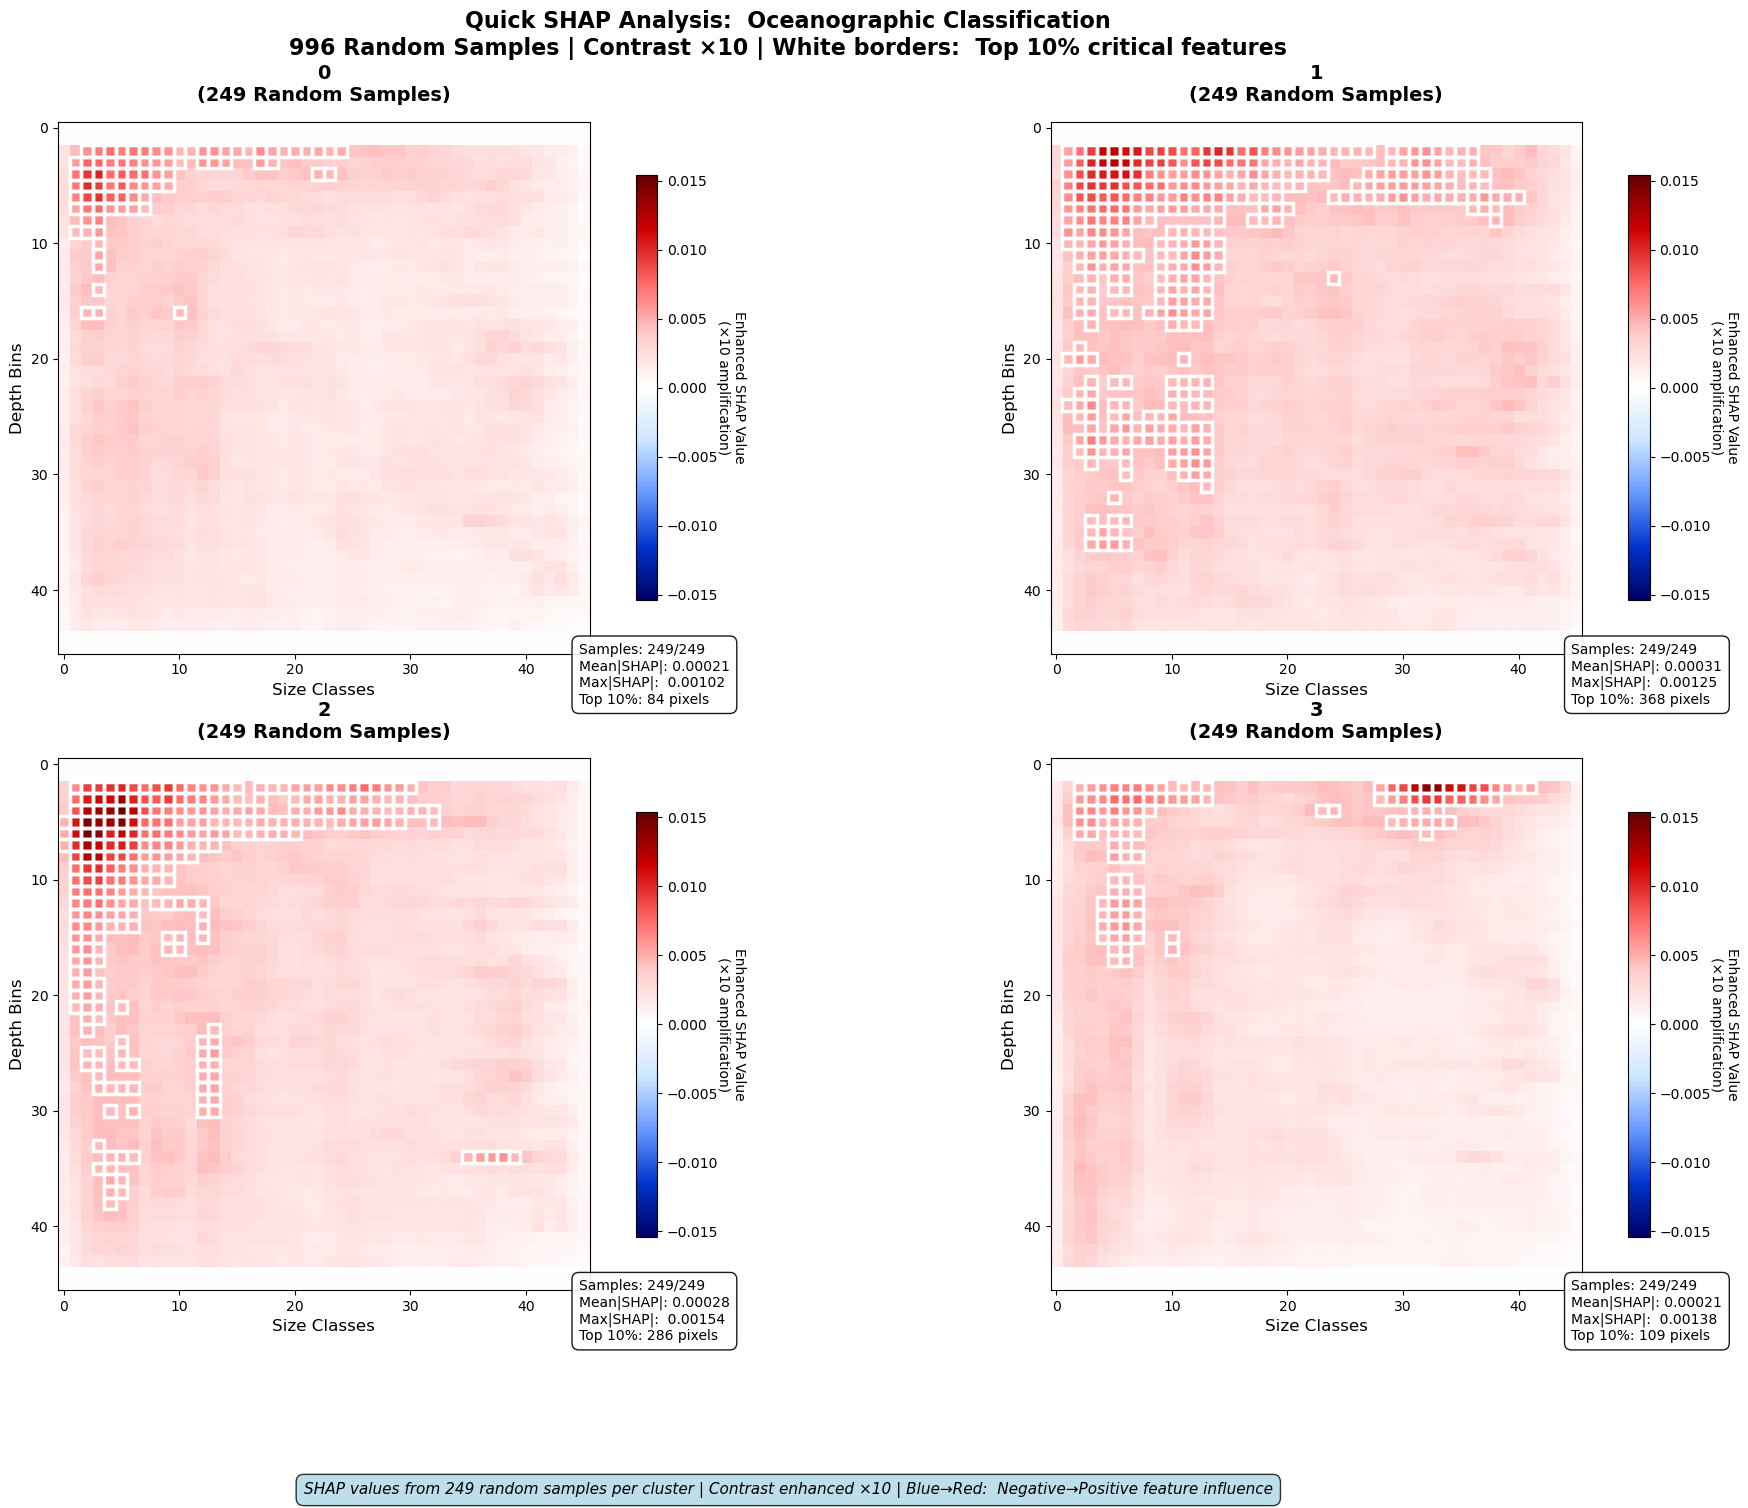


📊 QUICK SHAP ANALYSIS SUMMARY:

🌊 Cluster 0 (0):
  Samples analyzed: 249
  Mean importance:  0.000210
  Max importance: 0.001016
  Top 5 most important depth×size locations:
    1. Depth  4, Size  3:  0.001016
    2. Depth  5, Size  2:  0.000995
    3. Depth  6, Size  3:  0.000964
    4. Depth  4, Size  2:  0.000945
    5. Depth  5, Size  3:  0.000914

🌊 Cluster 1 (1):
  Samples analyzed: 249
  Mean importance:  0.000315
  Max importance: 0.001250
  Top 5 most important depth×size locations:
    1. Depth  3, Size  5:  0.001250
    2. Depth  2, Size  5:  0.001189
    3. Depth  3, Size  4:  0.001180
    4. Depth  2, Size  4:  0.001153
    5. Depth  3, Size  6:  0.001141

🌊 Cluster 2 (2):
  Samples analyzed: 249
  Mean importance:  0.000285
  Max importance: 0.001540
  Top 5 most important depth×size locations:
    1. Depth  4, Size  5:  0.001540
    2. Depth  6, Size  2:  0.001485
    3. Depth  5, Size  2:  0.001455
    4. Depth  5, Size  5:  0.001434
    5. Depth  6, Size  3:  0.001362

In [52]:
aggregated_shap, enhanced_plots = classifier.quick_shap_analysis_100_samples(
    samples_per_cluster=249,    # Use 100 random samples per cluster
    background_samples=50,      # Use 50 background samples  
    random_state=41,           # Reproducible sampling
    save_plots=True            # Save the plots
)

## Implementation

[Implement the final model(s) you've selected based on the above steps.]


In [ ]:
# Implement the final model(s)
# Example: model = YourChosenModel(best_hyperparameters)
# model.fit(X_train, y_train)


## Evaluation Metrics

[Clearly specify which metrics you'll use to evaluate the model performance, and why you've chosen these metrics.]


In [ ]:
# Evaluate the model using your chosen metrics
# Example for classification
# y_pred = model.predict(X_test)
# print(classification_report(y_test, y_pred))

# Example for regression
# mse = mean_squared_error(y_test, y_pred)

# Your evaluation code here


## Comparative Analysis

[Compare the performance of your model(s) against the baseline model. Discuss any improvements or setbacks and the reasons behind them.]


In [ ]:
# Comparative Analysis code (if applicable)
# Example: comparing accuracy of the baseline model and the new model
# print(f"Baseline Model Accuracy: {baseline_accuracy}, New Model Accuracy: {new_model_accuracy}")
